# Complete Consolidated Notebook

### About This Notebook
This notebook consolidates the complete analytical pipeline for our submission, covering all four workstreams end-to-end: 

1. **WS1: Data Acquisition, Cleaning & Exploratory Data Analysis**
2. **WS2: Predictive Model (Panel Fixed-Effects + XGBoost Comparison)**
3. **WS3: Insurance Claims Analysis: Thailand vs Philippines**
4. **WS4: Stress Test & NDC-Aligned Mitigation Scenario to 2030**
4. **WS5: Interactive Dashboard**

Each workstream is clearly demarcated with markdown section headers and runs sequentially from raw data ingestion through to final 2030 projections.

### Recommended Way to Read This Submission

* For the best reading experience, please refer to our **GitHub repository**, where the code is split into four separate, modular notebooks (one per workstream) with cleaner navigation and richer visualisations:

🔗 **GitHub Repository:** https://github.com/tanentong/Hakathon_momo 

### Reproducibility

To re-run the full pipeline, please follow the setup instructions in the **`README.md`** file. The README is included in:
- The GitHub repository 
- Team_momo_Suporting_Document.docx

# Workstream 1: Data Preprocessing, Indicator Selection & EDA

**Target:** Total GHG excl LULUCF (Mt CO₂e)
<br> **Window:** 2000–2024
<br> **Data:** 135 countries (data-driven completeness gates)
<br> **Framework:** STIRPAT 
<br> **Output:** `WS1_Data_Imputed.csv` (for WS2 modelling)

| Step | What | Output |
|-------|------|--------|
| **1 Load Raw Data** | (A) Load WDI CSV, keep needed columns; <br>(B) Filter to aggregate-total rows; <br>(C) Special Treatment for Urban% indicator code | Raw data |
2 Data Quality Gates** | (A) Keep **Countries** with Sufficient Data (≥80% target, ≥50% predictors); <br>(B) Grade each **indicator** by Completeness (GREEN / AMBER / RED); <br>(C) Remove Unsuitable Indicators | 135 countries, predictor pool |
| **3 Reshape Dataframe & Fill Gaps** | (A) Pivot into country×year table; <br>(B) Fill gaps i.e. missing data (interpolation, forward fill, extrapolation); <br>(C) Add COVID dummy (2020–2021) | `Data_Df` |
| **4 Screening & Indicator Selection** | (A) Correlation heatmaps: Identify which predictors move with GHG; <br>(B) Bar chart: Apply abs(r) ≥ 0.30 cutoff; <br>(C) Three screens indicator selection (Correlation → VIF → STIRPAT); <br>(D) Kaya validation regression | 7 predictors + target |
| **5 Focused EDA** | (A) Time Trends (2000–2024); <br> (B) GHG Composition; <br> (C) Scatter plots (final predictors vs GHG); <br> (D) Income-Stratified EKC; <br> (E) Southeast Asia Trajectory; <br> (F) Outlier Scan; <br> (G) Country clustering | Charts in Output_WS1 |
| **6 Export** | (A) Shape, stationarity, correlation checks; <br>(B) Save final data | `WS1_Data_Imputed.csv` |

## Working Directory
Set `Drive_Path` to your local project folder. (only things need to change)
<br> All other paths derive from it.

In [1]:
from pathlib import Path
import os

## Only change this line: 
Drive_Path = Path.home() / "Desktop/MASAHKT2026/Model"

In [2]:
# Define subdirectories
Data_Path = Drive_Path / "Data"
Code_Path = Drive_Path / "Code"
Output_Path = Drive_Path / "Output"
Output_WS1 = Output_Path / "Output_WS1"
Output_WS2 = Output_Path / "Output_WS2"
Output_WS3 = Output_Path / "Output_WS3"
Output_WS4 = Output_Path / "Output_WS4"
Output_WS5 = Output_Path / "Output_WS5"

# Define input file name
WDI_Filename = 'WB_WDI_WIDEF.csv'
Data_Filename = 'WS1_Data_Imputed.csv'
EMDAT_Filename = 'EMDAT_THA_PHL.csv'
# Source note for data (Chart footnote)
WDI_Source = 'Source: World Bank WDI (Wide Format), accessed 2026-04-26' 
EMDAT_Source = 'Source: EM-DAT, CRED (Thailand & Philippines), accessed 2026-04-27'
Model_Source = 'Source: Projections using FE coefficients from WS2'

# Create folders if they don't exist
for p in [Data_Path, Code_Path, Output_Path,Output_WS1, Output_WS2, Output_WS3, Output_WS4, Output_WS5]:
    p.mkdir(parents=True, exist_ok=True)

## Setup
* Import libraries; 
* Set constants; and 
* Define 25 candidate WDI indicators: 14 potential predictors + 11 emissions/target variables used for context and decomposition

An **emissions-exclusion set** is also defined here:  
* CO₂, methane, and N₂O are components of Total GHG (the target), so they are excluded from the predictor list to prevent circular prediction.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # for plotting
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats # for statistical tests
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist
from statsmodels.tsa.stattools import adfuller  #for regression
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif'})
sns.set_theme(style='whitegrid', font_scale=0.9)

# Analysis window 
Years     = [str(y) for y in range(2000, 2025)]
Int_Years = list(range(2000, 2025))

# Target variable 
Target = 'WB_WDI_EN_GHG_ALL_MT_CE_AR5'

# Emissions exclusion set 
# - Sub-components and derivatives of Total GHG
# - Total GHG = CO2 + CH4 + N2O + F-gases.
# These are excluded from predictors to avoid circular prediction

Emissions_Exclude = {
    Target,
    'WB_WDI_EN_GHG_CO2_MT_CE_AR5',       # CO2 — subset of target
    'WB_WDI_EN_GHG_CH4_MT_CE_AR5',       # methane — subset of target
    'WB_WDI_EN_GHG_N2O_MT_CE_AR5',       # N2O — subset of target
    'WB_WDI_EN_GHG_CO2_RT_GDP_KD',       # carbon intensity = target / GDP
    'WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5',    # sectoral CO2 — power
    'WB_WDI_EN_GHG_CO2_TR_MT_CE_AR5',    # sectoral CO2 — transport
    'WB_WDI_EN_GHG_CO2_IC_MT_CE_AR5',    # sectoral CO2 — industrial combustion
    'WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5',    # sectoral CO2 — buildings
    'WB_WDI_EN_GHG_CO2_AG_MT_CE_AR5',    # sectoral CO2 — agriculture
    'WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5',    # sectoral CH4 — agriculture
}

# WDI aggregate REF_AREA codes to exclude
# - They are not sovereign countries
Aggregates = {
    'WLD','EAS','OED','HIC','UMC','LMC','LIC','LMY','MIC','IBD','IDA',
    'FCS','HPC','LDC','ARB','EMU','EUU','SST','OSS','CSS','PSS','CEB',
    'EAR','LTE','PRE','PST','NAC','MEA','LCN','ECS','SAS','SSF','MNA',
    'EAP','ECA','LAC','SSA','AFE','AFW','IBT','IDB','IDX','TEA','TEC',
    'TLA','TMN','TSA','TSS'
}

# 25 Candidate indicators 
# - WDI code, STIRPAT factor, label for fuzzy search
Candidates = [
    # Target & emissions decomposition (audited but excluded from predictor pool)
    (Target,                            'target',             'Total GHG excl LULUCF'),
    ('WB_WDI_EN_GHG_CO2_MT_CE_AR5',     'target',             'CO2 excl LULUCF'),
    ('WB_WDI_EN_GHG_CH4_MT_CE_AR5',     'target',             'Methane emissions'),
    ('WB_WDI_EN_GHG_N2O_MT_CE_AR5',     'target',             'Nitrous oxide emissions'),
    ('WB_WDI_EN_GHG_CO2_RT_GDP_KD',     'target',             'Carbon intensity GDP'),
    ('WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5',  'sectoral',           'Power industry CO2'),
    ('WB_WDI_EN_GHG_CO2_TR_MT_CE_AR5',  'sectoral',           'Transport CO2'),
    ('WB_WDI_EN_GHG_CO2_IC_MT_CE_AR5',  'sectoral',           'Industrial combustion CO2'),
    ('WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5',  'sectoral',           'Buildings CO2'),
    ('WB_WDI_EN_GHG_CO2_AG_MT_CE_AR5',  'sectoral',           'Agriculture CO2'),
    ('WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5',  'sectoral',           'Agriculture CH4'),
    # Energy (STIRPAT Technology factors)
    ('WB_WDI_EG_USE_PCAP_KG_OE',        'technology_energy',  'Energy use per capita'),
    ('WB_WDI_EG_USE_ELEC_KH_PC',        'technology_energy',  'Electric power consumption per capita'),
    ('WB_WDI_EG_FEC_RNEW_ZS',           'technology_carbon',  'Renewable energy consumption'),
    ('WB_WDI_EG_ELC_FOSL_ZS',           'technology_carbon',  'Electricity from fossil fuels'),
    ('WB_WDI_EG_ELC_RNEW_ZS',           'technology_carbon',  'Electricity from renewables'),
    # Socio-economic (STIRPAT Population & Affluence)
    ('WB_WDI_NY_GDP_MKTP_CD',           'affluence',          'GDP current'),
    ('WB_WDI_NY_GDP_PCAP_CD',           'affluence',          'GDP per capita current'),
    ('WB_WDI_NY_GDP_PCAP_PP_KD',        'affluence',          'GDP per capita PPP'),
    ('WB_WDI_SP_POP_TOTL',              'population',         'Population total'),
    ('WB_WDI_SP_URB_TOTL_IN_ZS',        'non_stirpat',        'Urban population percent'),
    ('WB_WDI_NV_IND_TOTL_ZS',           'non_stirpat',        'Industry value added'),
    ('WB_WDI_NV_AGR_TOTL_ZS',           'non_stirpat',        'Agriculture forestry fishing'),
    # Land (non-STIRPAT, physical-risk relevance)
    ('WB_WDI_AG_LND_FRST_ZS',           'non_stirpat',        'Forest area'),
    ('WB_WDI_AG_LND_AGRI_ZS',           'non_stirpat',        'Agricultural land'),
]

# Short display names for charts 
Short = {
    Target:                            'Total_GHG',
    'WB_WDI_EN_GHG_CO2_MT_CE_AR5':     'CO2_Total',
    'WB_WDI_EN_GHG_CH4_MT_CE_AR5':     'CH4_Total',
    'WB_WDI_EN_GHG_N2O_MT_CE_AR5':     'N2O_Total',
    'WB_WDI_EN_GHG_CO2_RT_GDP_KD':     'CO2_Intensity_Per_GDP',
    'WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5':  'CO2_Power',
    'WB_WDI_EN_GHG_CO2_TR_MT_CE_AR5':  'CO2_Transport',
    'WB_WDI_EN_GHG_CO2_IC_MT_CE_AR5':  'CO2_Industrial',
    'WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5':  'CO2_Buildings',
    'WB_WDI_EN_GHG_CO2_AG_MT_CE_AR5':  'CO2_Agriculture',
    'WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5':  'CH4_Agriculture',
    'WB_WDI_EG_USE_PCAP_KG_OE':        'Energy_Per_Capita',
    'WB_WDI_EG_USE_ELEC_KH_PC':        'Elec_Per_Capita',
    'WB_WDI_EG_FEC_RNEW_ZS':           'Renewable_%',
    'WB_WDI_EG_ELC_FOSL_ZS':           'Fossil_Elec_%',
    'WB_WDI_EG_ELC_RNEW_ZS':           'Renew_Elec_%',
    'WB_WDI_NY_GDP_MKTP_CD':           'GDP_Total',
    'WB_WDI_NY_GDP_PCAP_CD':           'GDP_Per_Capita',
    'WB_WDI_NY_GDP_PCAP_PP_KD':        'GDP_Per_Capita_PPP',
    'WB_WDI_SP_POP_TOTL':              'Population',
    'WB_WDI_SP_URB_TOTL_IN_ZS':        'Urban_%',
    'WB_WDI_NV_IND_TOTL_ZS':           'Industry_VA_%',
    'WB_WDI_NV_AGR_TOTL_ZS':           'Agri_VA_%',
    'WB_WDI_AG_LND_FRST_ZS':           'Forest_%',
    'WB_WDI_AG_LND_AGRI_ZS':           'Agri_Land_%',
}

# Short = {
#     Target:                            'Total_GHG',
#     'WB_WDI_EN_GHG_CO2_MT_CE_AR5':     'CO2_Total',
#     'WB_WDI_EN_GHG_CH4_MT_CE_AR5':     'Methane',
#     'WB_WDI_EN_GHG_N2O_MT_CE_AR5':     'N2O',
#     'WB_WDI_EN_GHG_CO2_RT_GDP_KD':     'Carbon_Intensity',
#     'WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5':  'Power_CO2',
#     'WB_WDI_EN_GHG_CO2_TR_MT_CE_AR5':  'Transport_CO2',
#     'WB_WDI_EN_GHG_CO2_IC_MT_CE_AR5':  'Industrial_CO2',
#     'WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5':  'Buildings_CO2',
#     'WB_WDI_EN_GHG_CO2_AG_MT_CE_AR5':  'Agri_CO2',
#     'WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5':  'Agri_CH4',
#     'WB_WDI_EG_USE_PCAP_KG_OE':        'Energy_Per_Cap',
#     'WB_WDI_EG_USE_ELEC_KH_PC':        'Elec_Per_Cap',
#     'WB_WDI_EG_FEC_RNEW_ZS':           'Renewable_Pct',
#     'WB_WDI_EG_ELC_FOSL_ZS':           'Fossil_Elec_Pct',
#     'WB_WDI_EG_ELC_RNEW_ZS':           'Renew_Elec_Pct',
#     'WB_WDI_NY_GDP_MKTP_CD':           'GDP_Total',
#     'WB_WDI_NY_GDP_PCAP_CD':           'GDP_Per_Cap',
#     'WB_WDI_NY_GDP_PCAP_PP_KD':        'GDP_Per_Cap_PPP',
#     'WB_WDI_SP_POP_TOTL':              'Population',
#     'WB_WDI_SP_URB_TOTL_IN_ZS':        'Urban_Pct',
#     'WB_WDI_NV_IND_TOTL_ZS':           'Industry_VA_Pct',
#     'WB_WDI_NV_AGR_TOTL_ZS':           'Agri_VA_Pct',
#     'WB_WDI_AG_LND_FRST_ZS':           'Forest_Pct',
#     'WB_WDI_AG_LND_AGRI_ZS':           'Agri_Land_Pct',
# }

# Reverse lookup: short name --> WDI code
Short_To_Code = {v: k for k, v in Short.items()}

# Variables to log-transform 
# - Level variables spanning many orders of magnitude get log.
# Percentages and bounded ratios stay original (no log)
Log_Vars = {
    Target,
    'WB_WDI_EG_USE_PCAP_KG_OE', 'WB_WDI_EG_USE_ELEC_KH_PC',
    'WB_WDI_NY_GDP_MKTP_CD',    'WB_WDI_NY_GDP_PCAP_CD', 
    'WB_WDI_NY_GDP_PCAP_PP_KD', 'WB_WDI_SP_POP_TOTL',
}

print('Setup complete.')

Setup complete.


## Helper Functions

- **`get_rows`** — Extracts data for one indicator code. Picks the aggregate-total row when the WDI has sub-group duplicates (e.g. male/female breakdowns).
- **`fuzzy_find`** — Fallback search by indicator label when the exact code is missing from the dataset.
- **`compute_vif`** — Variance Inflation Factor for each predictor. Used in Stage 5 to check multicollinearity.
- **`missingness_audit`** — Prints per-indicator missing-data percentages before and after imputation.

In [4]:
def get_rows(data, code):
    """Get headline rows for an indicator, preferring COMP_BREAKDOWN totals."""
    rows = data[data.Indicator == code]
    if rows.empty:
        return rows
    strict = rows[(rows.Comp_Breakdown_1 == '_Z') &
                  (rows.Comp_Breakdown_2 == '_Z') &
                  (rows.Comp_Breakdown_3 == '_Z')]
    return strict if not strict.empty else rows


def fuzzy_find(description, label_ref):
    """Search indicator labels for a fuzzy match when WDI revises codes."""
    words = description.lower().split()[:3]
    if not words:
        return label_ref.iloc[0:0]
    mask = label_ref._lower.str.contains(words[0], regex=False)
    for w in words[1:]:
        mask &= label_ref._lower.str.contains(w, regex=False)
    return label_ref[mask]


def compute_vif(X_df):
    """Compute Variance Inflation Factors for all columns in X_df."""
    vifs = {}
    for col in X_df.columns:
        y     = X_df[col].values
        xvars = np.column_stack([np.ones(len(y)), X_df.drop(columns=[col]).values])
        coef, *_ = np.linalg.lstsq(xvars, y, rcond=None)
        ss_res = np.sum((y - xvars @ coef) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2     = 1 - ss_res / (ss_tot + 1e-12)
        vifs[col] = round(1 / (1 - r2 + 1e-10), 2)
    return pd.Series(vifs).sort_values(ascending=False)


def missingness_audit(df, cols, label=''):
    """Print and return a completeness summary for specified columns."""
    records = []
    for col in cols:
        total    = len(df)
        non_null = df[col].notna().sum()
        pct      = round(non_null / total * 100, 1)
        by_c     = df[df[col].notna()].groupby('Ref_Area')['year']
        first_yr = int(by_c.min().median()) if not by_c.min().empty else None
        last_yr  = int(by_c.max().median()) if not by_c.max().empty else None
        records.append({'indicator': col, 'non_null': non_null, 'total': total,
                        'pct_complete': pct, 'median_first_yr': first_yr,
                        'median_last_yr': last_yr})
    audit_df = pd.DataFrame(records)
    if label:
        print(f'\n=== Missingness Audit: {label} ===')
    print(audit_df.to_string(index=False))
    return audit_df


print('Helpers ready.')

Helpers ready.


## Step 1: Load Raw Data (WDI)

1. Load the WDI wide-format CSV. 
2. Keep only the columns needed for analysis.
3. Filter to aggregate-total rows (`SEX=_T`, `AGE=_T`, `URBANISATION=_T`) to remove sub-group breakdowns (e.g. male/female splits).

**Special case — Urban population %:** 
<br> The WDI file stores most indicators under `URBANISATION = _T` (meaning "all areas combined"). But the Urban % indicator is itself about urbanisation, so the file tags it differently. This means our aggregate filter accidentally removes it. We load it separately and append it back. 
> Urban population % is useful for WS3, this step manually add it back. 

In [5]:
# Load WDI data
WDI = pd.read_csv(
    Data_Path / WDI_Filename,
    # Select only useful columns
    usecols=['REF_AREA', 'INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE_LABEL',
             'SEX', 'AGE', 'URBANISATION',
             'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3'] + Years,
    dtype=str, low_memory=False
    # Capitalised & underscored column names
).rename(columns=lambda c: '_'.join(w.capitalize() for w in c.upper().replace(' ', '_').split('_')))

# Keep aggregate-total rows only (no male/female/urban sub-breakdowns)
WDI = WDI[(WDI.Sex == '_T') & (WDI.Age == '_T') & (WDI.Urbanisation == '_T')]
WDI[Years] = WDI[Years].apply(pd.to_numeric, errors='coerce')

# Urban% is stored under URBANISATION != '_T', load separately and append
WDI_Urban = pd.read_csv(
    Data_Path / WDI_Filename,
    usecols=['REF_AREA', 'INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE_LABEL',
             'SEX', 'AGE', 'URBANISATION',
             'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3'] + Years,
    dtype=str, low_memory=False
).rename(columns=lambda c: '_'.join(w.capitalize() for w in c.upper().replace(' ', '_').split('_')))
WDI_Urban = WDI_Urban[
    (WDI_Urban.Sex == '_T') &
    (WDI_Urban.Age == '_T') &
    (WDI_Urban.Indicator.str.contains('URB_TOTL_IN_ZS', na=False))
]
WDI_Urban[Years] = WDI_Urban[Years].apply(pd.to_numeric, errors='coerce')

WDI = pd.concat([WDI, WDI_Urban], ignore_index=True).drop_duplicates(
    subset=['Ref_Area', 'Indicator'] + Years[:1], keep='first')

# Remove aggregate/regional codes — sovereign countries only
WDI = WDI[~WDI.Ref_Area.isin(Aggregates)]

print(f'Rows after filtering: {len(WDI):,}')
print(f'Sovereign Ref_Area codes: {WDI.Ref_Area.nunique()}')

Rows after filtering: 187,443
Sovereign Ref_Area codes: 217


### Special Case: Find and Rename Urban% Indicator
* The Urban population indicator has a standard code on the World Bank website (`SP.URB.TOTL.IN.ZS`); 
* but the downloaded WDI file may rename it to something like `WB_WDI_SP_URB_TOTL_IN_ZS`. 

> They are the same indicator, just labelled differently. 

This cell searches the file by label text to find the actual code, then updates all references so later steps can find it.

In [6]:
# Look at all unique indicator codes and labels in the dataset
All_Indicators = WDI[['Indicator', 'Indicator_Label']].drop_duplicates()

# Search for any indicator with "urban population" and "%" in its label
Urban_Hits = All_Indicators[
    All_Indicators.Indicator_Label.str.lower().str.contains('urban population', na=False) &
    All_Indicators.Indicator_Label.str.contains('%', na=False)
]
print('Urban population indicators found:')
for _, row in Urban_Hits.iterrows():
    print(f'  {row.Indicator:45s}  {row.Indicator_Label}')

# From result, pick the "% of total" variant
Exact_Match = Urban_Hits[
    Urban_Hits.Indicator_Label.str.lower().str.contains('% of total', na=False)
]

# Update Urban_Code to match the actual file
# - If found, use the actual code from the data. 
# - Otherwise, keep the default guess.
if not Exact_Match.empty:
    Urban_Code = Exact_Match.iloc[0].Indicator
    print(f'\n>>> Resolved Urban% code: {Urban_Code}')
else:
    Urban_Code = 'WB_WDI_SP_URB_TOTL_IN_ZS'
    print(f'\n>>> No exact match, keeping: {Urban_Code}')

# Replace the old assumed code with the correct one everywhere it's used,
# so all later steps find the right data
Candidates = [(Urban_Code, f, d) if c == 'WB_WDI_SP_URB_TOTL_IN_ZS' else (c, f, d)
              for c, f, d in Candidates]
if 'WB_WDI_SP_URB_TOTL_IN_ZS' in Short:
    Short[Urban_Code] = Short.pop('WB_WDI_SP_URB_TOTL_IN_ZS')
else:
    Short[Urban_Code] = 'Urban_%'
Short_To_Code = {v: k for k, v in Short.items()}  # rebuild reverse lookup

Urban population indicators found:
  WB_WDI_SP_URB_TOTL_IN_ZS                       Urban population (% of total population)

>>> Resolved Urban% code: WB_WDI_SP_URB_TOTL_IN_ZS


In [7]:
# Delete use once df/list
del WDI_Urban, All_Indicators, Exact_Match, Urban_Hits

## Step 2: Data Quality Gates

### Step 2(A): Keep Countries with Sufficient Data
The WDI contains 217 economies. Many lack usable data. Two gates reduce the data to 135 countries:

1. **Gate 1 (target):** ≥80% of years (2000–2024) have Total GHG data.
2. **Gate 2 (predictors):** Most candidate indicators also have sufficient coverage for that country.

In [8]:
# Fuzzy label reference for fallback code substitution
Label_Ref = WDI[['Indicator', 'Indicator_Label']].drop_duplicates().copy()
Label_Ref['_lower'] = Label_Ref.Indicator_Label.str.lower().fillna('')

# Gate 1: keep countries with ≥80% target (GHG) coverage
Countries_Target_Ok = (
    get_rows(WDI, Target)
    .groupby('Ref_Area')[Years].mean()
    .pipe(lambda d: d[d.notna().sum(axis=1) / 25 >= 0.8])
    .index.tolist()
)

# Build core predictor list: 
# all candidate indicators except emissions variables (target + sub-components)
Core_Predictors = [code for code, factor, desc in Candidates
                   if code not in Emissions_Exclude
                   and factor not in ('target', 'sectoral')]

# Gate 2: check predictor coverage per country 
Cov_Pass = {}     # binary: did this country pass ≥80% on this predictor?
Cov_Raw  = {}     # raw coverage fraction per predictor
WDI_Gate = WDI[WDI.Ref_Area.isin(Countries_Target_Ok)]

for code in Core_Predictors:
    rows = get_rows(WDI_Gate, code)
    if rows.empty:
        desc = next((d for c, _, d in Candidates if c == code), code)
        hits = fuzzy_find(desc, Label_Ref)
        if not hits.empty:
            rows = get_rows(WDI_Gate, hits.iloc[0].Indicator)
    if rows.empty:
        continue
    pivot = rows.groupby('Ref_Area')[Years].mean().reindex(Countries_Target_Ok)
    frac  = pivot.notna().sum(axis=1) / 25
    Cov_Pass[code] = (frac >= 0.8).astype(int)
    Cov_Raw[code]  = frac

Pass_Count = pd.DataFrame(Cov_Pass).reindex(Countries_Target_Ok).fillna(0).sum(axis=1)
Min_Cov    = pd.DataFrame(Cov_Raw).reindex(Countries_Target_Ok).fillna(0).min(axis=1)

# Keep: ≥8/10 predictors at ≥80% AND every predictor ≥50%
Data = Pass_Count[(Pass_Count >= 8) & (Min_Cov >= 0.50)].index.tolist()
WDI_Data = WDI[WDI.Ref_Area.isin(Data)].copy()


In [9]:
print('=' * 60)
print('     STEP 2(A): COUNTRY FILTER')
print('=' * 60)
print(f'Starting countries:                    217')
print(f'Candidate predictors checked:          {len(Core_Predictors)}')
print(f'  (all non-emissions indicators from the candidate list)')
print(f'')
print(f'Gate 1 — ≥80% GHG data available:      {len(Countries_Target_Ok)} countries pass')
print(f'Gate 2 — sufficient predictor coverage: {len(Data)} countries pass')
print(f'  → Dropped {len(Countries_Target_Ok) - len(Data)} countries (too many missing indicators)')
print(f'')
print(f'Final data: {len(Data)} countries')

     STEP 2(A): COUNTRY FILTER
Starting countries:                    217
Candidate predictors checked:          14
  (all non-emissions indicators from the candidate list)

Gate 1 — ≥80% GHG data available:      203 countries pass
Gate 2 — sufficient predictor coverage: 130 countries pass
  → Dropped 73 countries (too many missing indicators)

Final data: 130 countries


### Step 2(B) Grade Each Indicator by Completeness
For each of the 14 candidate indicators, measure data completeness across the filtered countries and assign a grade:

- **GREEN** — high completeness, ready to use
- **AMBER** — moderate gaps, usable after imputation
- **RED** — too sparse, excluded

In [10]:
# Loop through each candidate indicator to check data quality/completeness
Audit_Records = []
Not_Found     = []
Substituted   = []

for code, factor, description in Candidates:
    rows        = get_rows(WDI_Data, code)
    actual_code = code
    notes       = []

    # If the indicator code is not found, try searching by its label name instead
    if rows.empty:
        hits = fuzzy_find(description, Label_Ref)
        if not hits.empty:
            actual_code = hits.iloc[0].Indicator
            rows = get_rows(WDI_Data, actual_code)
            notes.append(f'substituted -> {actual_code}')
            Substituted.append((code, actual_code))
        # If still not found, mark as RED and skip to the next indicator
        else:
            Not_Found.append(code)
            Audit_Records.append(dict(
                indicator_code=code, indicator_label=description, unit='',
                stirpat_factor=factor, data_completeness_pct=0.0,
                last_year_data_complete=None, usability_flag='RED', notes='NOT FOUND'))
            continue

    # Calculate what % of country-year cells have actual data (not missing)
    pivot        = rows.groupby('Ref_Area')[Years].mean().reindex(Data)
    completeness = round(pivot.notna().sum().sum() / (len(Data) * 25) * 100, 1)

    # Find the most recent year where every country has data
    full_yrs     = [y for y in Years if pivot.notna().all(axis=0).get(y, False)]
    last_full    = int(full_yrs[-1]) if full_yrs else None

    # GREEN = (coverage ≥80% + recent), AMBER (coverage ≥60%), RED (sparse)
    if completeness >= 80 and last_full and last_full >= 2022:
        flag = 'GREEN'
    elif completeness >= 60:
        flag = 'AMBER'
    else:
        flag = 'RED'

    # Save the audit result for this indicator
    Audit_Records.append(dict(
        indicator_code           = actual_code,
        indicator_label          = rows.Indicator_Label.iloc[0],
        unit                     = rows.Unit_Measure_Label.iloc[0],
        stirpat_factor           = factor,
        data_completeness_pct   = completeness,
        last_year_data_complete = last_full,
        usability_flag           = flag,
        notes                    = '; '.join(notes),
    ))

Audit = pd.DataFrame(Audit_Records)

In [11]:
print('=' * 60)
print('   STEP 2(B): INDICATOR QUALITY GRADES')
print('=' * 60)
print(f'Indicators assessed: {len(Audit)}')
print(f'')
print(f'  GREEN  (≥80% complete, recent data): {(Audit.usability_flag == "GREEN").sum()}')
print(f'  AMBER  (≥60% complete, some gaps):   {(Audit.usability_flag == "AMBER").sum()}')
print(f'  RED    (too sparse, excluded):        {(Audit.usability_flag == "RED").sum()}')
if Not_Found:
    print(f'\n  Not found in dataset: {Not_Found}')
if Substituted:
    print(f'  Code substituted:    {Substituted}')

   STEP 2(B): INDICATOR QUALITY GRADES
Indicators assessed: 25

  GREEN  (≥80% complete, recent data): 20
  AMBER  (≥60% complete, some gaps):   5
  RED    (too sparse, excluded):        0


### Step 2(C) Remove Unsuitable Indicators
* From the graded indicators, keep only GREEN and AMBER. 
* Then remove any GHG sub-components (CO₂, methane, N₂O), these are arithmetic parts of the target variable, and would make the model circular.

> The remaining 14 indicators are carried forward to screening in Step 4.

In [12]:
# Keep GREEN/AMBER indicators, exclude GHG components from predictor list
Predictor_Pool = Audit[
    (Audit.usability_flag.isin(['GREEN', 'AMBER'])) &
    (~Audit.indicator_code.isin(Emissions_Exclude))
].copy()

# Also build the STIRPAT factor lookup for Stage 5 screening
Factor_Lookup = dict(zip(Audit.indicator_code, Audit.stirpat_factor))


print('=' * 60)
print('     STEP 2(C): REMOVE UNSUITABLE INDICATORS')
print('=' * 60)
print(f'Started with:           {len(Audit)} candidate indicators')
print(f'Removed RED:            {(Audit.usability_flag == "RED").sum()} (insufficient data)')
print(f'Removed GHG components: {len(Emissions_Exclude)} (parts of target — would be circular)')
print(f'')
print(f'Remaining: {len(Predictor_Pool)} indicators carried forward to screening')
print(f'Remaining: {len(Data)} countries carried forward to screening')

     STEP 2(C): REMOVE UNSUITABLE INDICATORS
Started with:           25 candidate indicators
Removed RED:            0 (insufficient data)
Removed GHG components: 11 (parts of target — would be circular)

Remaining: 14 indicators carried forward to screening
Remaining: 130 countries carried forward to screening


In [13]:
# Delete use once df/list
del Label_Ref, Countries_Target_Ok, Cov_Pass, Cov_Raw, Pass_Count, Min_Cov, WDI_Gate
del Audit_Records, Not_Found, Substituted

## Step 3: Reshape Dataframe and Fill Gaps

Pivot the filtered data into a **country × year** data (one row per country-year, one column per indicator).

Then fill missing values in **predictors only**. The target (Total GHG) is never imputed:
- Linear interpolation for internal gaps (≤2 consecutive years)
- Forward fill for trailing gaps (≤2 years)
- Linear trend extrapolation for 2024 predictors not yet published

A COVID dummy (2020=1, 2021=1, else 0) is added for use in WS2.

In [14]:
# Build country-year × indicator matrix 
# - one row per country-year, one column per indicator
All_Codes = [Target] + Predictor_Pool.indicator_code.tolist()
All_Codes = [c for c in All_Codes if c in Short]

Frames = []
for code in All_Codes:
    rows = get_rows(WDI_Data, code)
    if rows.empty:
        continue
    melted = (rows[['Ref_Area'] + Years]
              .melt(id_vars='Ref_Area', value_vars=Years,
                    var_name='year', value_name=Short[code])
              .assign(year=lambda x: x.year.astype(int))
              .groupby(['Ref_Area', 'year'])[Short[code]].mean()
              .reset_index())
    Frames.append(melted)

# Merge all indicators into a single data
Data_Df = Frames[0]
for f in Frames[1:]:
    Data_Df = Data_Df.merge(f, on=['Ref_Area', 'year'], how='outer')
Data_Df = Data_Df.sort_values(['Ref_Area', 'year']).reset_index(drop=True)

# Define column groups for downstream use
Target_Col = Short[Target]
Pred_Cols  = [Short[c] for c in All_Codes if c != Target and Short[c] in Data_Df.columns]
All_Cols   = [Target_Col] + Pred_Cols

print(f'Raw data: {Data_Df.shape}')
print(f'Target: {Target_Col}')
print(f'Predictors ({len(Pred_Cols)}): {Pred_Cols}')

Raw data: (3250, 17)
Target: Total_GHG
Predictors (14): ['Energy_Per_Capita', 'Elec_Per_Capita', 'Renewable_%', 'Fossil_Elec_%', 'Renew_Elec_%', 'GDP_Total', 'GDP_Per_Capita', 'GDP_Per_Capita_PPP', 'Population', 'Urban_%', 'Industry_VA_%', 'Agri_VA_%', 'Forest_%', 'Agri_Land_%']


In [15]:
# Missingness audit before imputation
Audit_Before = missingness_audit(Data_Df, All_Cols, 'BEFORE imputation')


=== Missingness Audit: BEFORE imputation ===
         indicator  non_null  total  pct_complete  median_first_yr  median_last_yr
         Total_GHG      3250   3250         100.0             2000            2024
 Energy_Per_Capita      3161   3250          97.3             2000            2023
   Elec_Per_Capita      3160   3250          97.2             2000            2023
       Renewable_%      2865   3250          88.2             2000            2021
     Fossil_Elec_%      3049   3250          93.8             2000            2023
      Renew_Elec_%      2803   3250          86.2             2000            2021
         GDP_Total      3247   3250          99.9             2000            2024
    GDP_Per_Capita      3247   3250          99.9             2000            2024
GDP_Per_Capita_PPP      3247   3250          99.9             2000            2024
        Population      3250   3250         100.0             2000            2024
           Urban_%      3250   3250      

In [16]:
# Impute predictors only. Target (GHG) is never filled
for col in Pred_Cols:
    # Linear interpolation within each country (limit=2 consecutive gaps)
    Data_Df[col] = (Data_Df.groupby('Ref_Area')[col]
                     .transform(lambda s: s.interpolate(method='linear', limit=2,
                                                        limit_area='inside')))
    # Forward fill trailing gaps (limit=2 years)
    Data_Df[col] = (Data_Df.groupby('Ref_Area')[col]
                     .transform(lambda s: s.ffill(limit=2)))

# Extrapolate 2024 predictors from 2021–2023 linear trend
for col in Pred_Cols:
    for country in Data_Df.Ref_Area.unique():
        mask = (Data_Df.Ref_Area == country) & (Data_Df.year == 2024)
        if not Data_Df.loc[mask, col].isna().any():
            continue
        recent = Data_Df[(Data_Df.Ref_Area == country) &
                          (Data_Df.year.isin([2021, 2022, 2023]))][['year', col]].dropna()
        if len(recent) >= 2:
            slope, intercept = np.polyfit(recent.year, recent[col], 1)
            proj = intercept + slope * 2024
            if '%' in col or 'pct' in col.lower():
                proj = np.clip(proj, 0, 100)
            else:
                proj = max(proj, recent[col].min() * 0.5)
            Data_Df.loc[mask, col] = proj

# COVID dummy: 1 for 2020–2021, 0 otherwise
Data_Df['COVID'] = Data_Df.year.isin([2020, 2021]).astype(int)


# Missingness audit after imputation
Audit_After = missingness_audit(Data_Df, All_Cols, 'AFTER imputation')

# Summary: Before vs after comparison
Comparison = Audit_Before[['indicator', 'non_null', 'pct_complete']].merge(
    Audit_After[['indicator', 'non_null', 'pct_complete']],
    on='indicator', suffixes=('_before', '_after'))
Comparison['imputed_count'] = Comparison.non_null_after - Comparison.non_null_before
print('\n=== Imputation Summary ===')
print(Comparison.to_string(index=False))

del Audit_Before, Audit_After, Comparison


=== Missingness Audit: AFTER imputation ===
         indicator  non_null  total  pct_complete  median_first_yr  median_last_yr
         Total_GHG      3250   3250         100.0             2000            2024
 Energy_Per_Capita      3250   3250         100.0             2000            2024
   Elec_Per_Capita      3250   3250         100.0             2000            2024
       Renewable_%      3250   3250         100.0             2000            2024
     Fossil_Elec_%      3250   3250         100.0             2000            2024
      Renew_Elec_%      3233   3250          99.5             2000            2024
         GDP_Total      3250   3250         100.0             2000            2024
    GDP_Per_Capita      3250   3250         100.0             2000            2024
GDP_Per_Capita_PPP      3250   3250         100.0             2000            2024
        Population      3250   3250         100.0             2000            2024
           Urban_%      3250   3250       

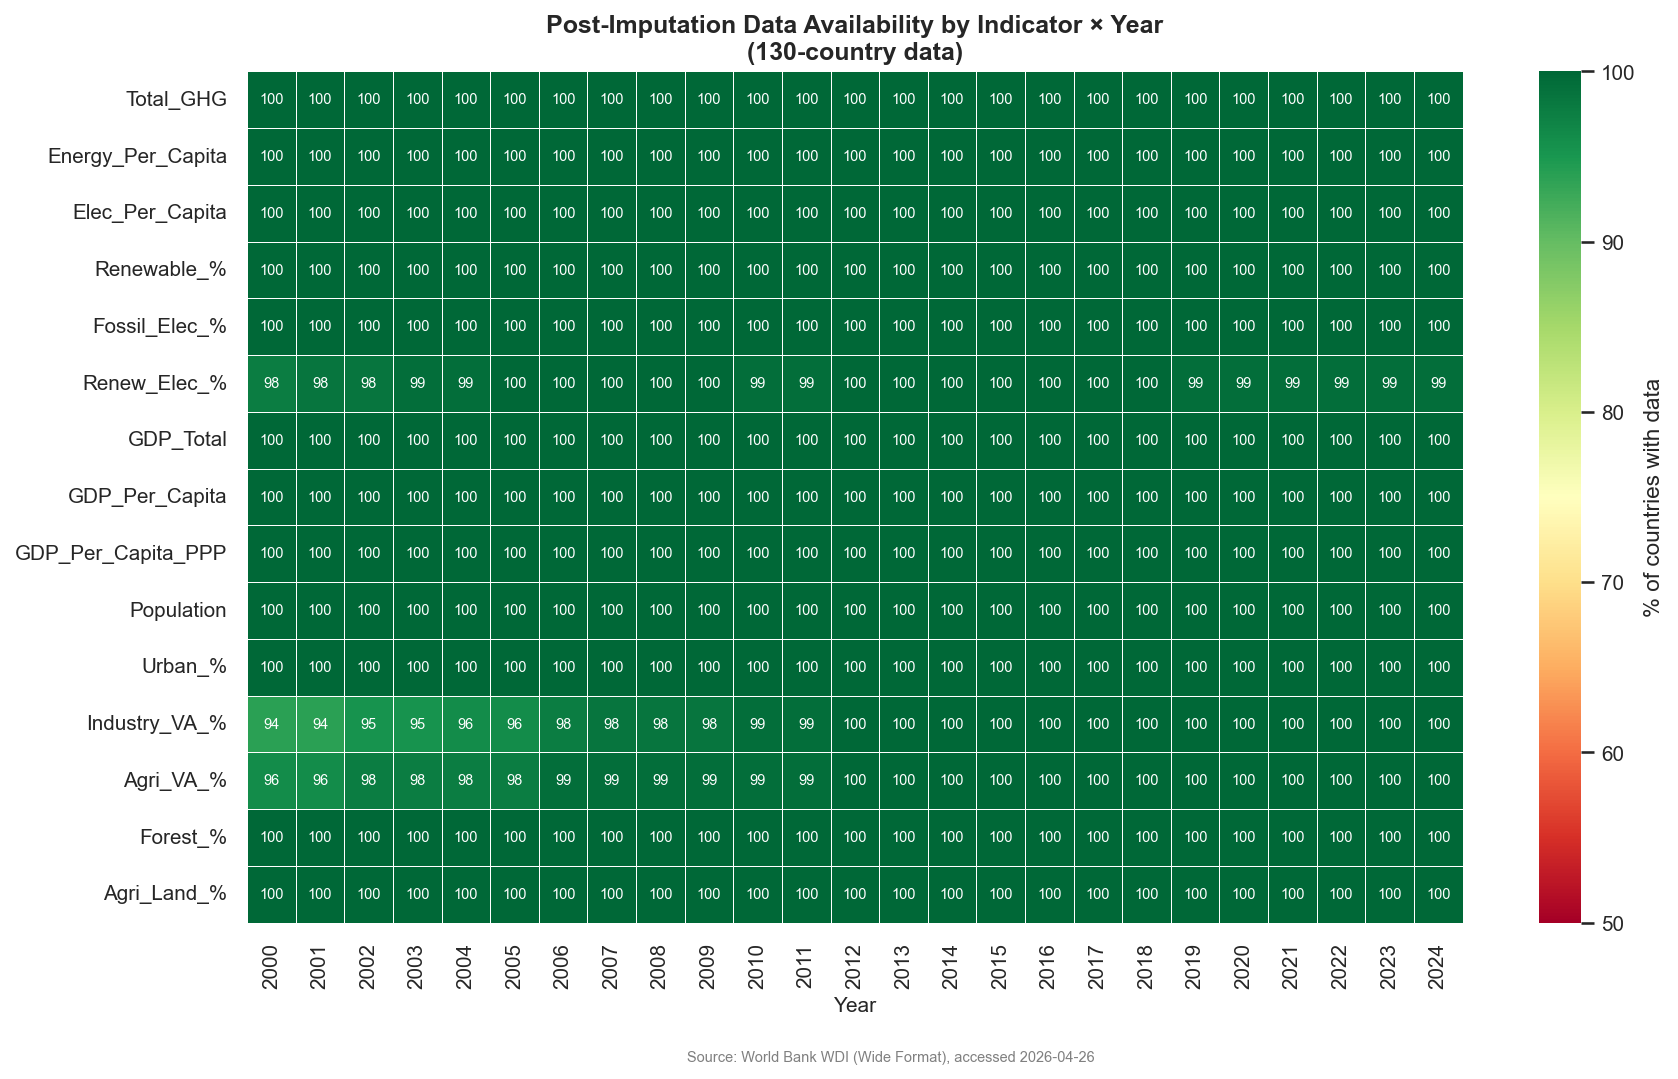

In [17]:
# Missingness heatmap: % of countries with data, by indicator × year
Miss_Matrix = pd.DataFrame(index=Int_Years, columns=All_Cols, dtype=float)
for col in All_Cols:
    if col not in Data_Df.columns:
        continue
    for yr in Int_Years:
        subset = Data_Df[Data_Df.year == yr][col]
        Miss_Matrix.loc[yr, col] = subset.notna().mean() * 100
Miss_Matrix = Miss_Matrix.astype(float)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(Miss_Matrix.T, cmap='RdYlGn', vmin=50, vmax=100,
            annot=True, fmt='.0f', annot_kws={'size': 7}, linewidths=0.3,
            cbar_kws={'label': '% of countries with data'}, ax=ax)
ax.set_title(f'Post-Imputation Data Availability by Indicator × Year\n'
             f'({len(Data)}-country data)', fontsize=12, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('')
plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
plt.show()

In [18]:
# Delete use once df/list
del All_Codes, Frames
del Miss_Matrix

## Step 4: Screening & Indicator Selection

We start with the full predictor pool from Step 2 and narrow it down to the final set using data-driven screens. 

The correlation analysis below serves two purposes: 
1. It reveals which indicators are most informative. 
2. It provides the cutoff criteria for selection. 

### Step 4(A) Correlation Heatmaps (Full Predictor Pool)

Two correlation heatmaps across all predictor pool indicators:

- **Pooled correlation**
<br> Standard Pearson r across all country-years. This captures both *level differences between countries* (e.g. large countries emit more) and *changes over time within countries*. It can be misleading because a predictor might look strongly correlated with GHG simply because big countries score high on both.

- **Within-country correlation** 
<br> Pearson r after subtracting each country's time-series mean. This removes the "big vs small country" effect and isolates the question: *when this indicator goes up within a country, does GHG also go up?* This is the correlation that matters for our fixed-effects model, which estimates within-country relationships.

In [19]:
# Log-transform level variables, then compute correlations
Corr_Codes = [Target] + Predictor_Pool.indicator_code.tolist()
Corr_Codes = [c for c in Corr_Codes if c in Short and Short[c] in Data_Df.columns]

Corr_Df = Data_Df[['Ref_Area', 'year'] + [Short[c] for c in Corr_Codes]].copy()
for c in Corr_Codes:
    sn = Short[c]
    if c in Log_Vars and sn in Corr_Df.columns:
        Corr_Df[sn] = np.log(Corr_Df[sn].clip(lower=1e-9))

Numeric_Cols = [Short[c] for c in Corr_Codes if Short[c] in Corr_Df.columns]

# Pooled Pearson (all country-years stacked)
Corr_Pooled = Corr_Df[Numeric_Cols].corr(method='pearson')

# Within-country Pearson (subtract each country's mean first)
Demeaned    = Corr_Df.groupby('Ref_Area')[Numeric_Cols].transform(lambda x: x - x.mean())
Corr_Within = Demeaned.corr(method='pearson')

# Rank predictors by |within-country r| with target
Top_Within = Corr_Within[Target_Col].drop(Target_Col).abs().sort_values(ascending=False)
print('Top within-country correlators with Total GHG:')
print(Top_Within.round(3).to_string())

Top within-country correlators with Total GHG:
Energy_Per_Capita     0.673
Elec_Per_Capita       0.651
GDP_Total             0.644
Population            0.632
GDP_Per_Capita_PPP    0.593
GDP_Per_Capita        0.575
Renewable_%           0.551
Urban_%               0.438
Agri_VA_%             0.409
Forest_%              0.340
Agri_Land_%           0.246
Fossil_Elec_%         0.233
Renew_Elec_%          0.218
Industry_VA_%         0.140


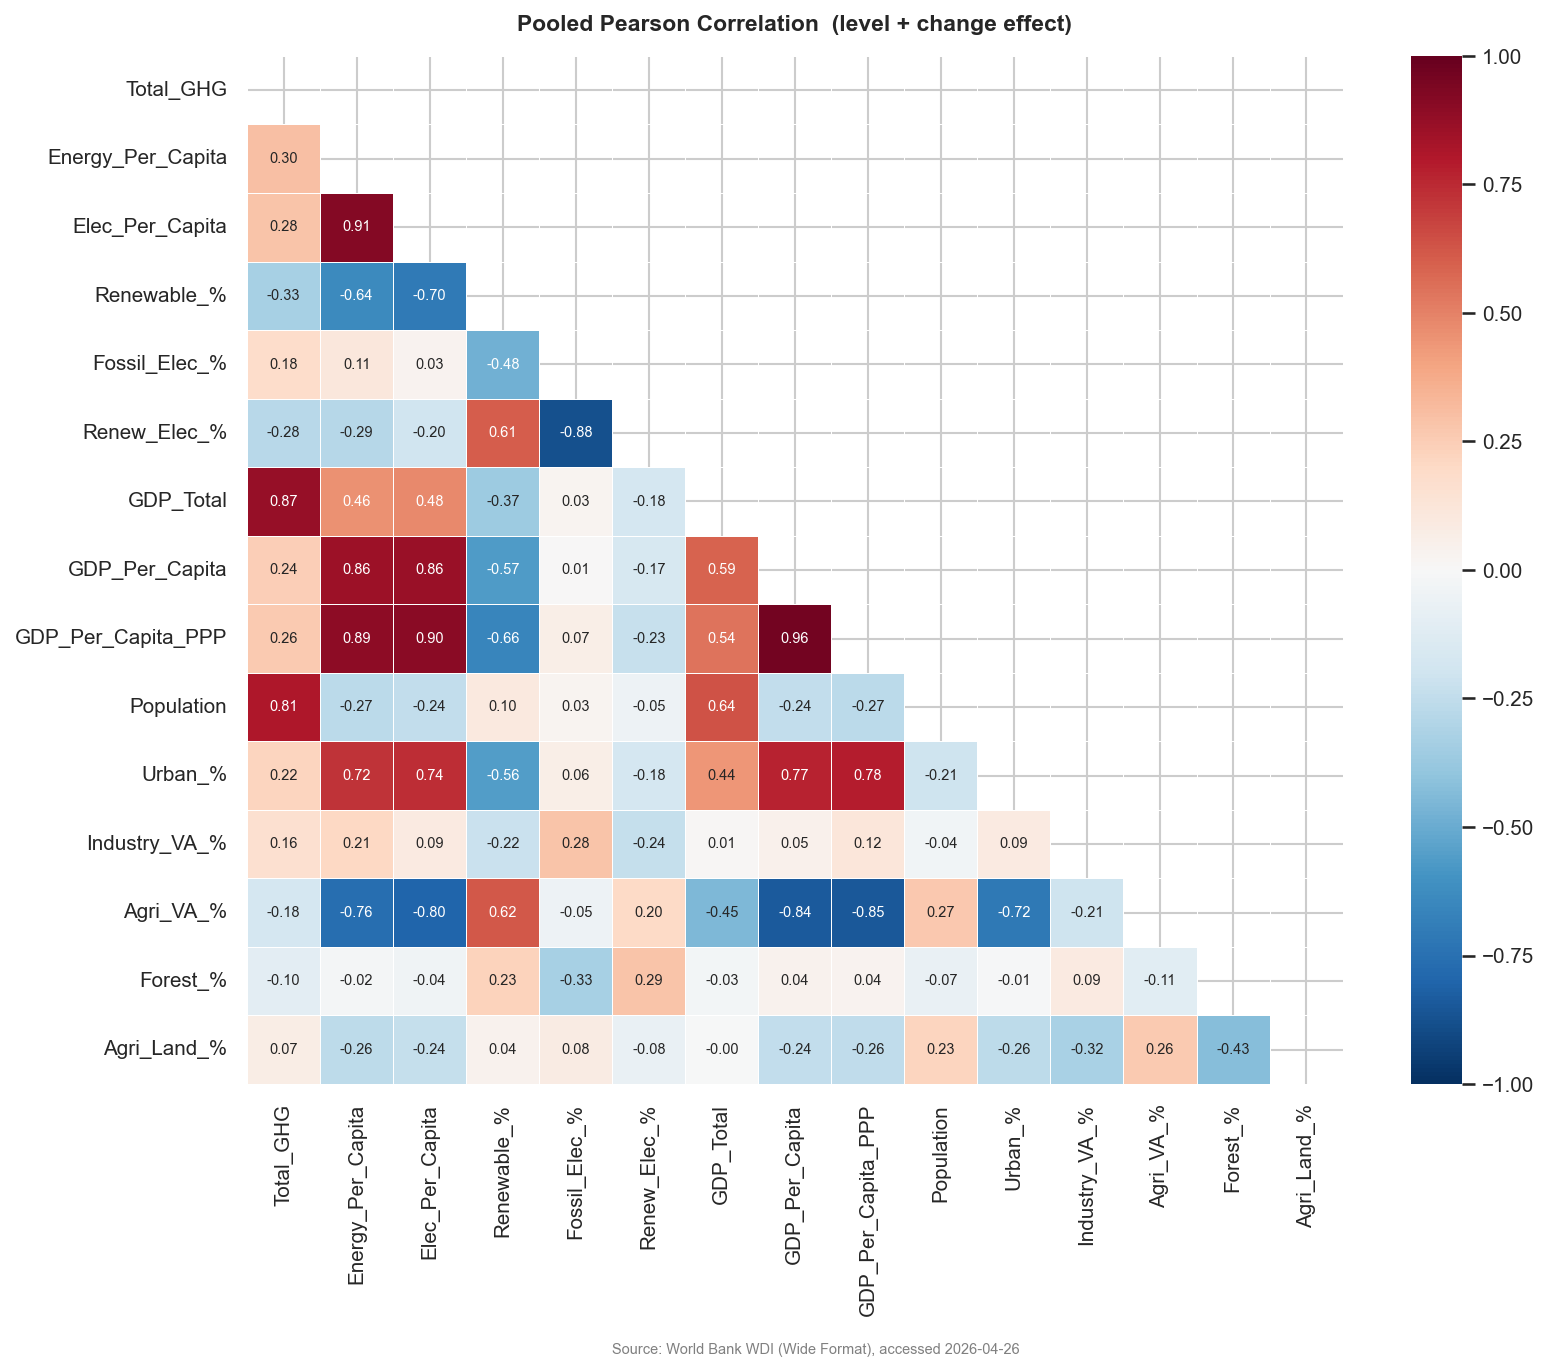

Saved: WS1_Correlation_Pooled.png


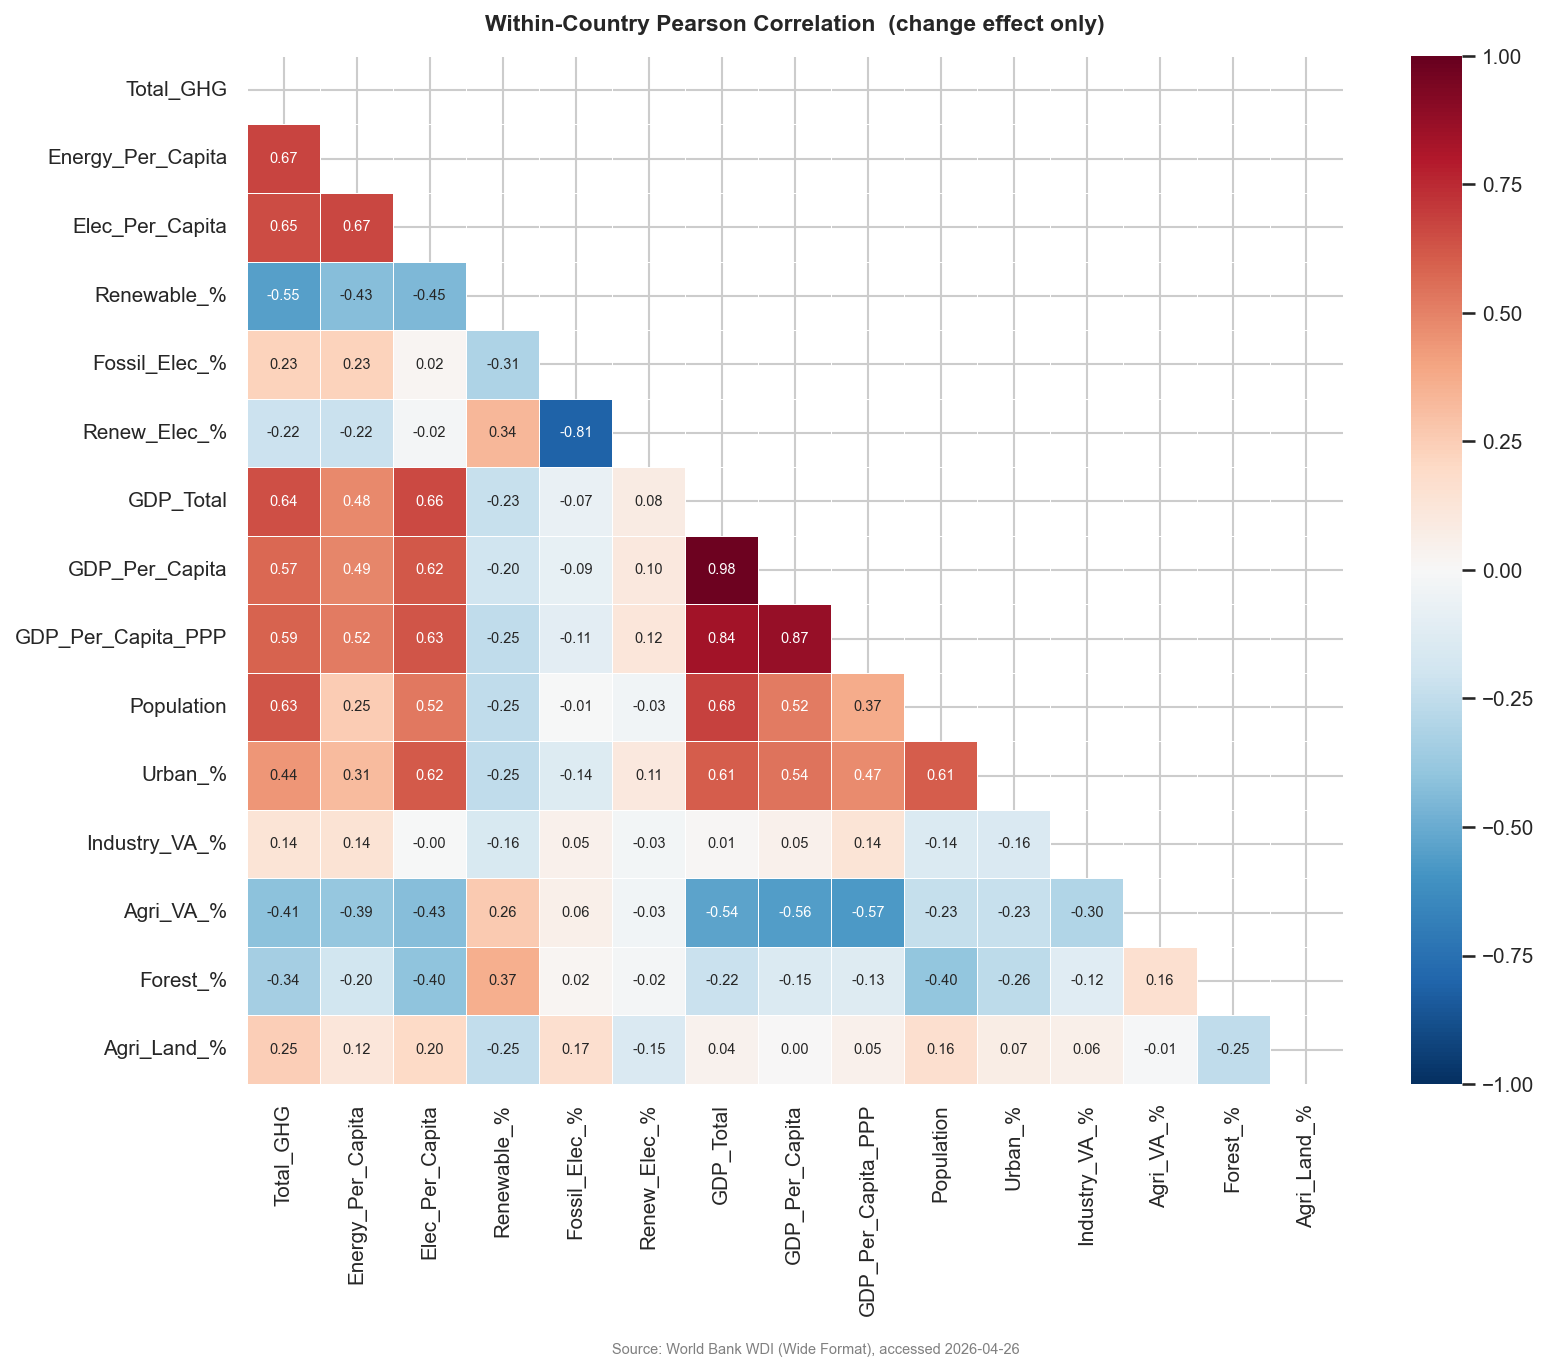

Saved: WS1_Correlation_Within.png


In [20]:
# Plot pooled and within-country correlation heatmaps
Hm_Kwargs = dict(cmap='RdBu_r', vmin=-1, vmax=1, annot=True,
                 fmt='.2f', annot_kws={'size': 7}, linewidths=0.3)

for corr, title, fname in [
    (Corr_Pooled,
     'Pooled Pearson Correlation  (level + change effect)',
     'WS1_Correlation_Pooled.png'),
    (Corr_Within,
     'Within-Country Pearson Correlation  (change effect only)',
     'WS1_Correlation_Within.png'),
]:
    fig, ax = plt.subplots(figsize=(11, 9))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, **Hm_Kwargs)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    plt.figtext(0.5, -0.01, WDI_Source, ha='center', fontsize=7, color='grey')
    plt.tight_layout()
    fig.savefig(Output_WS1 / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

### Step 4(B) Screening Bar Chart

Side-by-side bar chart showing how each predictor correlates with GHG, using both pooled and within-country methods.

**How to read this chart:**
- Each row is one predictor.
- The darker bar is the within-country correlation (the one we care about for modelling).
- The lighter bar is the pooled correlation (shown for comparison).
- Predictors with |within-country r| ≥ 0.30 are coloured — these pass the first screen.
- Predictors below the threshold are greyed out — they will be dropped.

Positive correlation: 
 * The predictor moves in the **same** direction as GHG 
 * e.g. more energy use → more emissions 

Negative correlation:
* The predictor moves in the **opposite** direction as GHG 
* e.g. more renewable energy → less emissions 

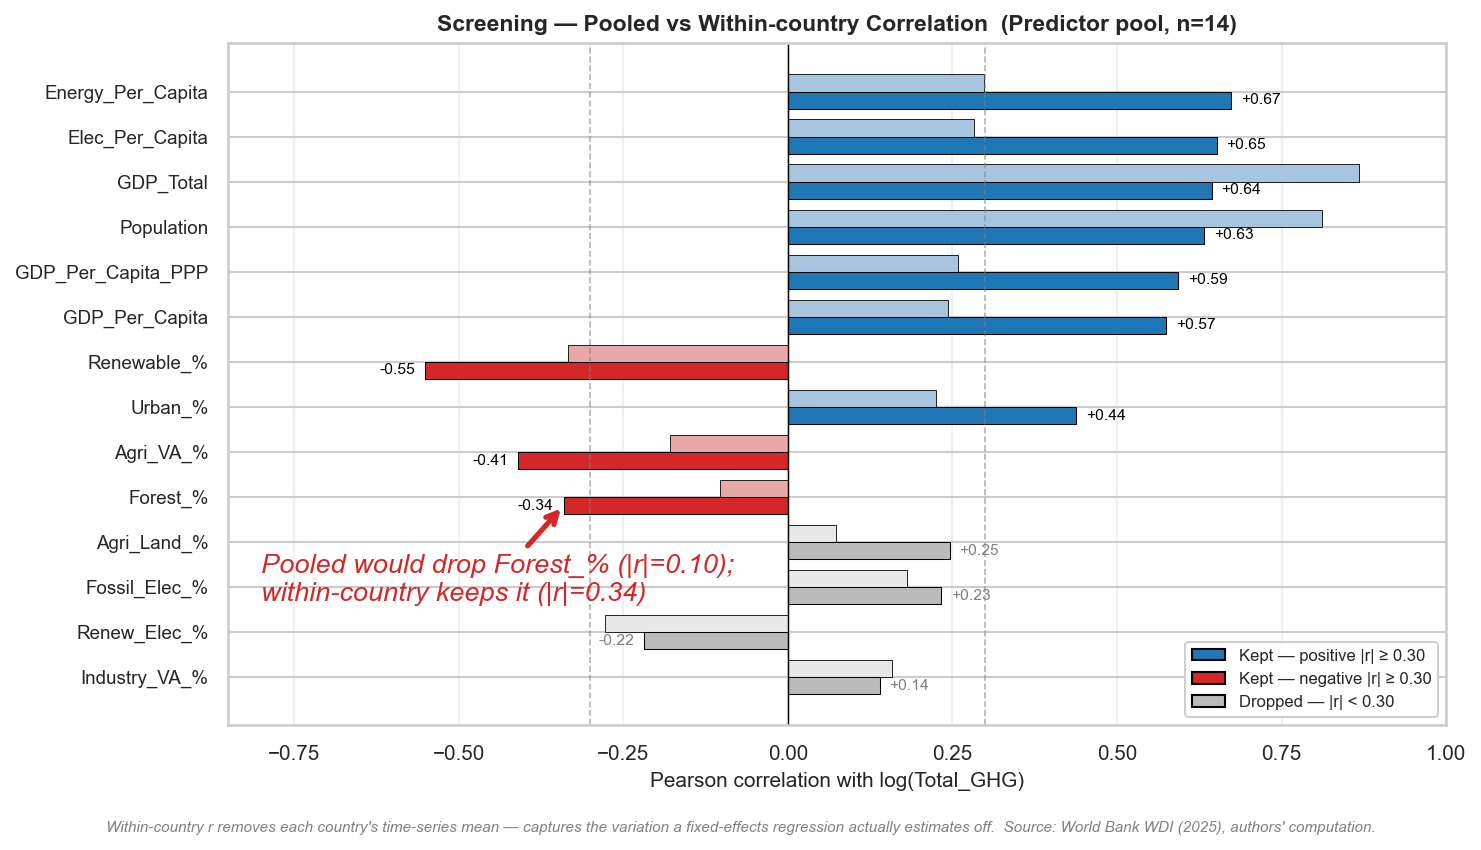


Screen outcome: kept 10 / 14 predictors at |r| ≥ 0.3
  Kept:     Energy_Per_Capita (+0.67), Elec_Per_Capita (+0.65), GDP_Total (+0.64), Population (+0.63), GDP_Per_Capita_PPP (+0.59), GDP_Per_Capita (+0.57), Renewable_% (-0.55), Urban_% (+0.44), Agri_VA_% (-0.41), Forest_% (-0.34)
  Dropped:  Agri_Land_% (+0.25), Fossil_Elec_% (+0.23), Renew_Elec_% (-0.22), Industry_VA_% (+0.14)


In [21]:
# ── Screen 1 bar chart: pooled vs within-country correlation ──────────────────
Screen_Threshold = 0.30

# Extract predictor correlations with target (drop target itself)
Pred_Pooled = Corr_Pooled[Target_Col].drop(Target_Col)
Pred_Within = Corr_Within[Target_Col].drop(Target_Col)

# Sort by |within-country r| descending
Sort_Order    = Pred_Within.abs().sort_values(ascending=False).index.tolist()
Pooled_Values = Pred_Pooled.reindex(Sort_Order).values
Within_Values = Pred_Within.reindex(Sort_Order).values

# Colour coding: kept (|within| ≥ threshold) = colour by sign; dropped = grey
Within_Colours = ['#bbbbbb' if abs(v) < Screen_Threshold else
                  '#1f77b4' if v > 0 else '#d62728'
                  for v in Within_Values]
Pooled_Colours = ['#e8e8e8' if abs(v) < Screen_Threshold else
                  '#a8c5e0' if v > 0 else '#e8a8a8'
                  for v in Within_Values]

# Plot
fig, ax = plt.subplots(figsize=(10, 5.5))
y = np.arange(len(Sort_Order))
h = 0.38

ax.barh(y - h/2, Pooled_Values, h, color=Pooled_Colours,
        edgecolor='black', linewidth=0.4, label='Pooled r (level + change)')
ax.barh(y + h/2, Within_Values, h, color=Within_Colours,
        edgecolor='black', linewidth=0.5, label='Within-country r (change only)')

ax.set_yticks(y)
ax.set_yticklabels(Sort_Order, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.7)
ax.axvline( Screen_Threshold, color='grey', ls='--', lw=0.8, alpha=0.6)
ax.axvline(-Screen_Threshold, color='grey', ls='--', lw=0.8, alpha=0.6)

# Annotate within-country values
for i, v in enumerate(Within_Values):
    ax.text(v + (0.015 if v >= 0 else -0.015), y[i] + h/2,
            f'{v:+.2f}', va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=7.5,
            color='black' if abs(v) >= Screen_Threshold else 'grey')

# Highlight Forest_% if pooled/within disagree on screening
if 'Forest_%' in Sort_Order:
    Fi = Sort_Order.index('Forest_%')
    ax.annotate(
        f'Pooled would drop Forest_% (|r|={abs(Pooled_Values[Fi]):.2f});\n'
        f'within-country keeps it (|r|={abs(Within_Values[Fi]):.2f})',
        xy=(Within_Values[Fi], Fi + h/2),
        xytext=(-0.8, Fi + 2.3),
        fontsize=13, color='#d62728', style='italic',
        arrowprops=dict(arrowstyle='->', color='#d62728', lw=2.5))

ax.set_xlabel(f'Pearson correlation with log({Target_Col})', fontsize=10)
ax.set_title(f'Screening — Pooled vs Within-country Correlation  '
             f'(Predictor pool, n={len(Sort_Order)})',
             fontsize=11, fontweight='bold')
ax.set_xlim(-0.85, 1.0)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#1f77b4', edgecolor='black', label='Kept — positive |r| ≥ 0.30'),
    Patch(facecolor='#d62728', edgecolor='black', label='Kept — negative |r| ≥ 0.30'),
    Patch(facecolor='#bbbbbb', edgecolor='black', label='Dropped — |r| < 0.30'),
], loc='lower right', fontsize=8, framealpha=0.95)

plt.figtext(0.5, -0.02,
            "Within-country r removes each country's time-series mean — "
            "captures the variation a fixed-effects regression actually estimates off.  "
            "Source: World Bank WDI (2025), authors' computation.",
            ha='center', fontsize=7.3, color='grey', style='italic')
plt.tight_layout()
fig.savefig(Output_WS1 / 'WS1_Screening_Chart.png', bbox_inches='tight', dpi=180)
plt.show()

# Summary
Kept = [(lbl, w) for lbl, w in zip(Sort_Order, Within_Values) if abs(w) >= Screen_Threshold]
Drop = [(lbl, w) for lbl, w in zip(Sort_Order, Within_Values) if abs(w) <  Screen_Threshold]
print(f'\nScreen outcome: kept {len(Kept)} / {len(Sort_Order)} predictors at |r| ≥ {Screen_Threshold}')
print('  Kept:    ', ', '.join(f'{l} ({w:+.2f})' for l, w in Kept))
print('  Dropped: ', ', '.join(f'{l} ({w:+.2f})' for l, w in Drop))

### Step 4(C) Three-Screen Indicator Selection

Starting from the predictors that passed the correlation screen above, we apply two more filters:

1. **Screen 1 — Correlation:** 
<br> Already applied above. Drop any predictor with |within-country r| < 0.30.

2. **Screen 2 — Multicollinearity (VIF):**
<br> Drop the highest-VIF predictor until all VIF < 5.0.
<br> A VIF above 5 means that predictor is mostly redundant with others already in the set.

3. **Screen 3 — STIRPAT coverage:** 
<br>  *- STIRPAT-Anchored Indicator Selection -*
<br> 
<br> The STIRPAT framework says national emissions are driven by four factors: 
<br> - Population, Affluence (GDP), Energy intensity, and Carbon intensity of energy. 
<br> We check that at least one predictor represents each factor, so the model has a complete picture.

After screening, **Urban%** is manually added as a predictor for its relevance to insurance exposure analysis in WS3. 
> More urbanisation = more assets in hazard zones

In [22]:
# Collect within-country correlations for all predictor pool indicators
Pred_R = {}
for code in Predictor_Pool.indicator_code:
    if code not in Short:
        continue
    sn = Short[code]
    if sn in Corr_Within.columns:
        Pred_R[sn] = Corr_Within[Target_Col].get(sn, 0.0)

print(f'Predictors entering screening: {len(Pred_R)}')

# Screen 1: drop |within-country r| < 0.30
Candidates_List = list(Pred_R.keys())
Dropped_S1  = [sn for sn in Candidates_List if abs(Pred_R[sn]) < 0.30]
Candidates_List = [sn for sn in Candidates_List if sn not in Dropped_S1]
print(f'\nScreen 1 — |r| ≥ 0.30:  {len(Pred_R)} → {len(Candidates_List)}')
print(f'  Dropped: {Dropped_S1}')

# Screen 2: iteratively remove highest-VIF until all VIF < 5.0
Vif_Threshold = 5.0
print(f'\nScreen 2 — iterative VIF removal (threshold = {Vif_Threshold}):')
iteration = 0
while len(Candidates_List) >= 2:
    vifs = compute_vif(Demeaned[Candidates_List].dropna())
    if vifs.iloc[0] < Vif_Threshold:
        print(f'  All VIFs < {Vif_Threshold}. Stopping.')
        break
    drop = vifs.index[0]
    Candidates_List.remove(drop)
    iteration += 1
    print(f'  Iteration {iteration}: dropped "{drop}" (VIF = {vifs.iloc[0]:.1f})')

print(f'  Survivors: {len(Candidates_List)}')
print('\nFinal VIFs:')
print(compute_vif(Demeaned[Candidates_List].dropna()).round(2).to_string())

# Screen 3: verify STIRPAT factor coverage (P, A, T1, T2)
Groups = {}
for sn in Candidates_List:
    code   = Short_To_Code.get(sn)
    factor = Factor_Lookup.get(code, 'non_stirpat')
    Groups.setdefault(factor, []).append(sn)

print('\nSTIRPAT factor coverage:')
for factor in ['population', 'affluence', 'technology_energy', 'technology_carbon']:
    members = Groups.get(factor, [])
    print(f'  {factor:20s}: {members if members else ">>> MISSING <<<"}')
print(f'  {"non_stirpat":20s}: {Groups.get("non_stirpat", [])}')

# Keep best per STIRPAT factor, then fill with non-STIRPAT up to 10
Final_Predictors = []
for factor in ['population', 'affluence', 'technology_energy', 'technology_carbon']:
    members = Groups.get(factor, [])
    if members:
        best = max(members, key=lambda sn: abs(Pred_R[sn]))
        Final_Predictors.append(best)
        if len(members) > 1:
            print(f'  [{factor}] kept "{best}" over {[m for m in members if m != best]}')

Non_Stirpat = sorted(Groups.get('non_stirpat', []),
                      key=lambda sn: abs(Pred_R[sn]), reverse=True)
Final_Predictors.extend(Non_Stirpat[:10 - len(Final_Predictors)])

#### Manually add Urban% for WS3 insurance exposure
Urban_Short = Short.get(Urban_Code, 'Urban_%')
if Urban_Short not in Final_Predictors:
    Final_Predictors.append(Urban_Short)
    Factor_Lookup[Urban_Code] = 'non_stirpat'
    print(f'\nAdded "{Urban_Short}" as manual predictor (WS3 exposure)')

print(f'\nFinal predictor set ({len(Final_Predictors)}): {Final_Predictors}')

Predictors entering screening: 14

Screen 1 — |r| ≥ 0.30:  14 → 10
  Dropped: ['Fossil_Elec_%', 'Renew_Elec_%', 'Industry_VA_%', 'Agri_Land_%']

Screen 2 — iterative VIF removal (threshold = 5.0):
  Iteration 1: dropped "GDP_Total" (VIF = 23518.8)
  Iteration 2: dropped "GDP_Per_Capita" (VIF = 5.6)
  All VIFs < 5.0. Stopping.
  Survivors: 8

Final VIFs:
Elec_Per_Capita       3.52
GDP_Per_Capita_PPP    2.27
Energy_Per_Capita     2.06
Urban_%               2.02
Population            1.78
Agri_VA_%             1.56
Forest_%              1.39
Renewable_%           1.36

STIRPAT factor coverage:
  population          : ['Population']
  affluence           : ['GDP_Per_Capita_PPP']
  technology_energy   : ['Energy_Per_Capita', 'Elec_Per_Capita']
  technology_carbon   : ['Renewable_%']
  non_stirpat         : ['Urban_%', 'Agri_VA_%', 'Forest_%']
  [technology_energy] kept "Energy_Per_Capita" over ['Elec_Per_Capita']

Final predictor set (7): ['Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Cap

### Step 4(D) Kaya / STIRPAT Validation

Before moving to the full model in WS2, we run a quick check: 
> Do the four core STIRPAT factors (Population, Affluence, Energy, Carbon intensity) actually explain GHG variation when used together?

This cell runs a simple fixed-effects regression with just these four variables. 
<br> If the R² is reasonable, it confirms the STIRPAT framework is a valid foundation for our model.

**Scatter plots:** Each chart shows one STIRPAT factor vs log(Total GHG). Each dot is one country in one year. The line shows the overall trend. The within-country r value tells us how strongly this factor relates to GHG changes *within* each country over time.

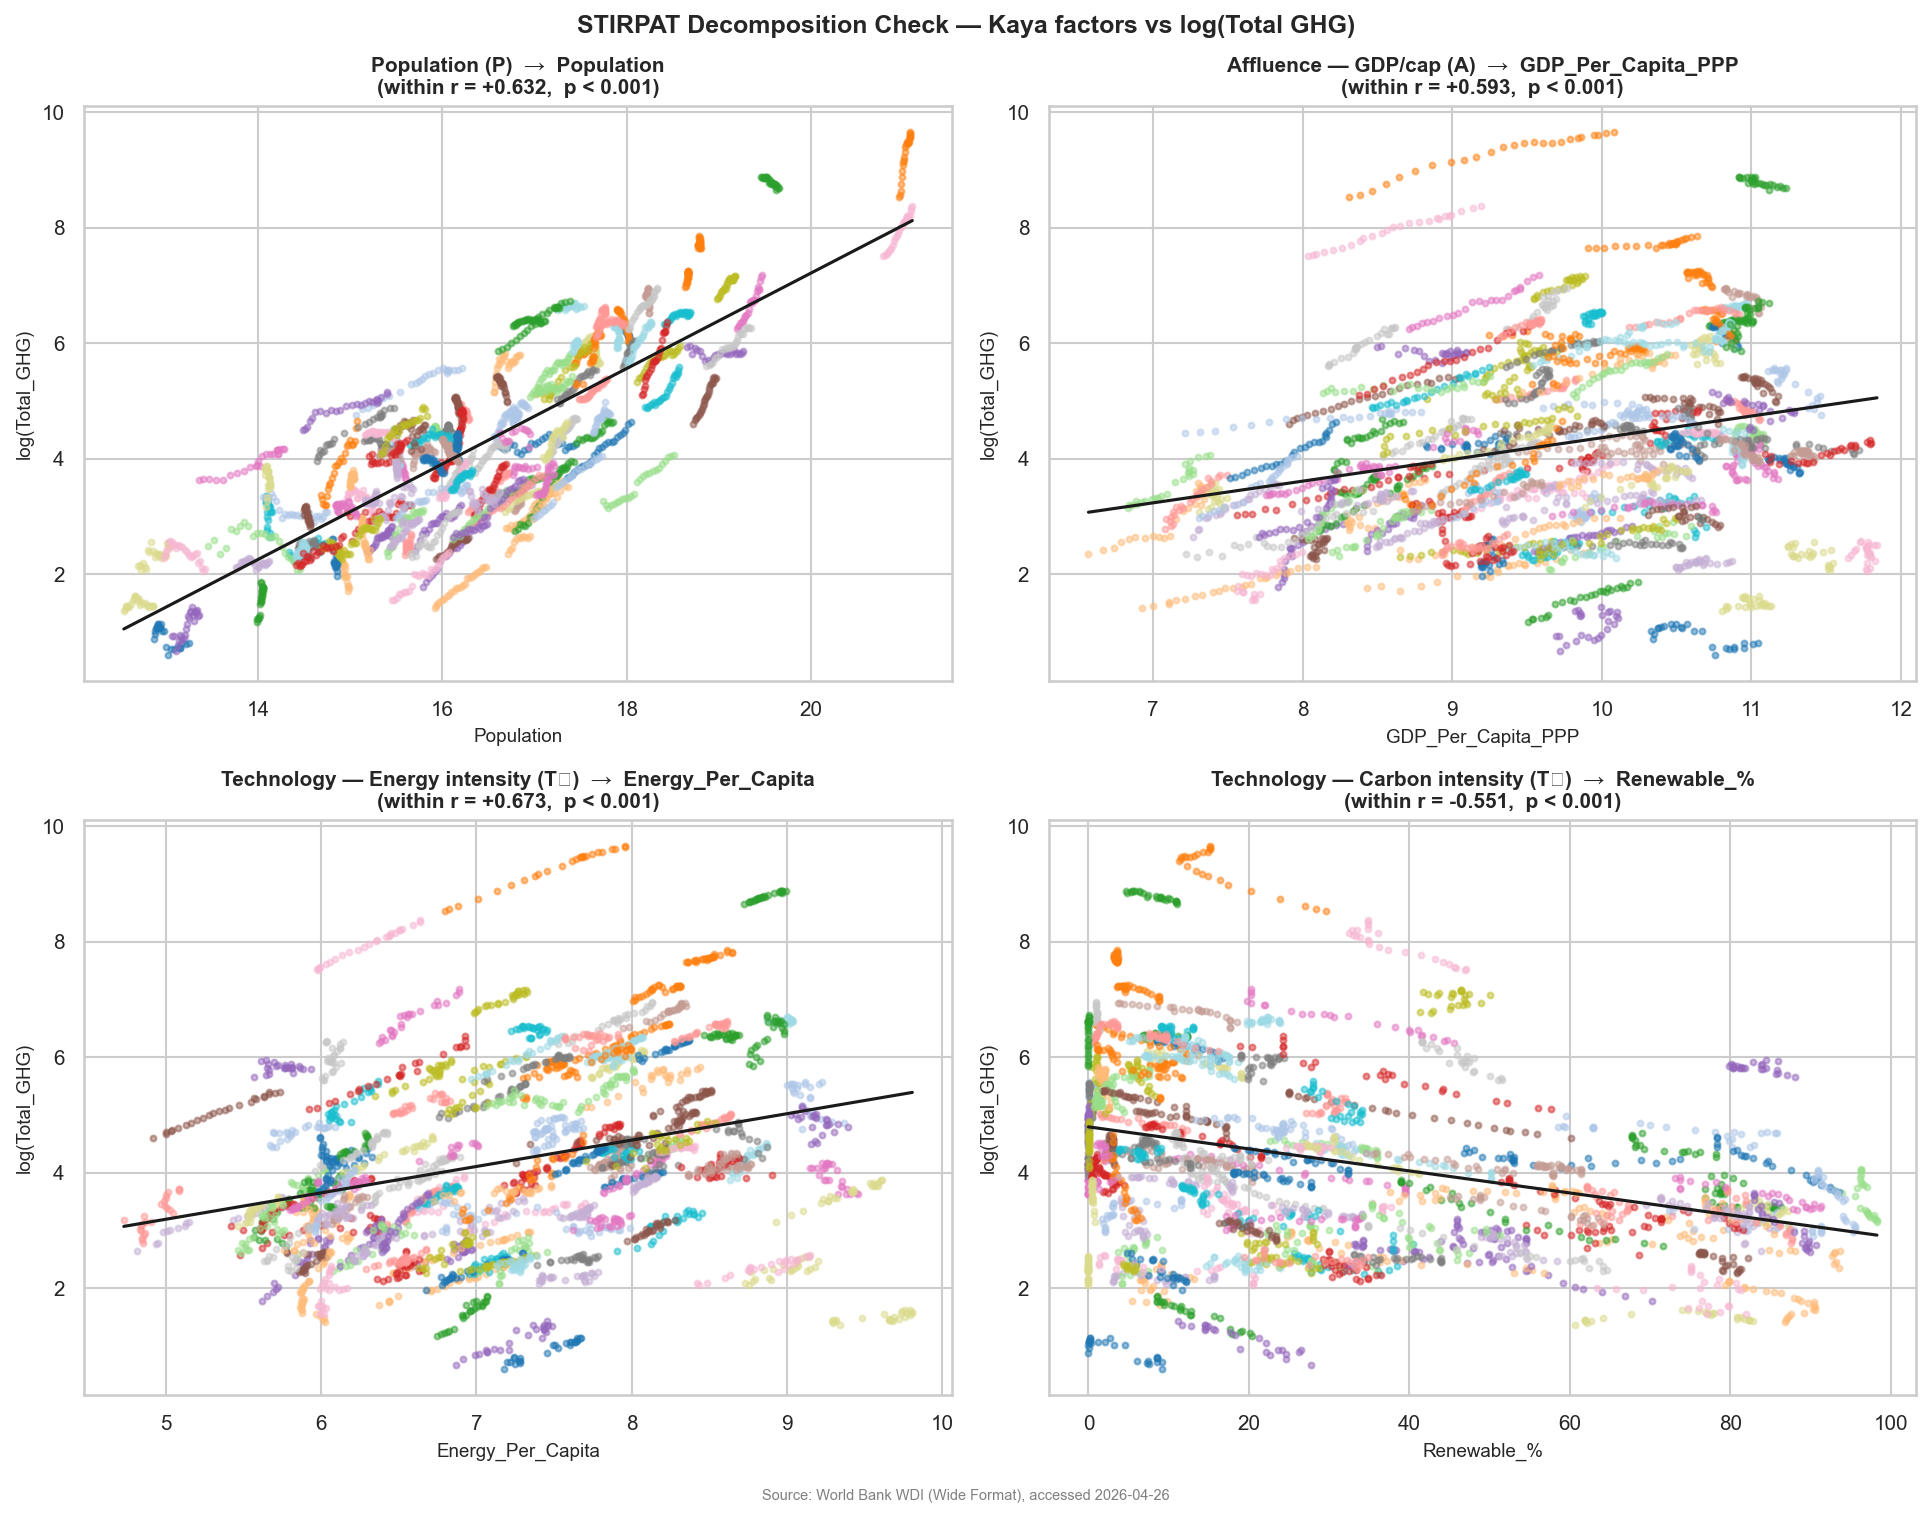

Saved: WS1_Kaya_Check.png

KAYA FACTOR STATISTICS (within-country)
                            Factor              Proxy  Within r p-value
                    Population (P)         Population     0.632 < 0.001
           Affluence — GDP/cap (A) GDP_Per_Capita_PPP     0.593 < 0.001
Technology — Energy intensity (T₁)  Energy_Per_Capita     0.673 < 0.001
Technology — Carbon intensity (T₂)        Renewable_%    -0.551 < 0.001


In [23]:
# Pick one representative per STIRPAT factor 
Kaya_Datas = []
for f in ['population', 'affluence', 'technology_energy', 'technology_carbon']:
    reps = [sn for sn in Final_Predictors
            if Factor_Lookup.get(Short_To_Code.get(sn), '') == f]
    if reps:
        Kaya_Datas.append((f, reps[0]))
    else:
        any_match = [sn for sn in Pred_R
                     if Factor_Lookup.get(Short_To_Code.get(sn), '') == f]
        if any_match:
            Kaya_Datas.append((f, max(any_match, key=lambda sn: abs(Pred_R[sn]))))

Factor_Label = {
    'population':        'Population (P)',
    'affluence':         'Affluence — GDP/cap (A)',
    'technology_energy': 'Technology — Energy intensity (T₁)',
    'technology_carbon': 'Technology — Carbon intensity (T₂)',
}

# Scatter plots with within-country r and p-value 
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
Kaya_Stats = []

# One colour per country for scatter points
Palette     = sns.color_palette('tab20', n_colors=len(Data))
Country_Pal = dict(zip(sorted(Data), Palette))

for i, (factor, sn) in enumerate(Kaya_Datas[:4]):
    ax    = axes.flatten()[i]
    sub   = Corr_Df[['Ref_Area', sn, Target_Col]].dropna()
    valid = Demeaned[[sn, Target_Col]].dropna()
    r, p  = stats.pearsonr(valid[sn], valid[Target_Col]) if len(valid) >= 3 else (np.nan, np.nan)

    for country, grp in sub.groupby('Ref_Area'):
        ax.scatter(grp[sn], grp[Target_Col],
                   color=Country_Pal.get(country, 'grey'), s=8, alpha=0.5)

    x, y = sub[sn].values, sub[Target_Col].values
    sl, ic, *_ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, sl * xl + ic, 'k-', lw=1.5)

    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax.set_title(f'{Factor_Label[factor]}  →  {sn}\n(within r = {r:+.3f},  {p_str})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(sn, fontsize=9)
    ax.set_ylabel(f'log({Target_Col})', fontsize=9)
    Kaya_Stats.append({'Factor': Factor_Label[factor], 'Proxy': sn,
                       'Within r': round(r, 3), 'p-value': p})

fig.suptitle('STIRPAT Decomposition Check — Kaya factors vs log(Total GHG)',
             fontsize=12, fontweight='bold')
plt.figtext(0.5, -0.01, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS1 / 'WS1_Kaya_Check.png', bbox_inches='tight')
plt.show()
print('Saved: WS1_Kaya_Check.png')

# Print stats table 
Kstats_Df = pd.DataFrame(Kaya_Stats)
Kstats_Df['p-value'] = Kstats_Df['p-value'].apply(
    lambda p: '< 0.001' if p < 0.001 else f'{p:.4f}')
print('\n' + '=' * 72)
print('KAYA FACTOR STATISTICS (within-country)')
print('=' * 72)
print(Kstats_Df.to_string(index=False))

In [24]:
# ── Joint fixed-effects regression: 4 Kaya proxies → log(Total GHG) ──────────
Kaya_X_Names = [sn for _, sn in Kaya_Datas[:4]]
Kaya_Xy      = Demeaned[Kaya_X_Names + [Target_Col]].dropna()
X            = Kaya_Xy[Kaya_X_Names].values
y            = Kaya_Xy[Target_Col].values

# OLS on demeaned data = within-country (fixed-effects) regression
X_Const      = np.column_stack([np.ones(len(y)), X])
Coef, *_     = np.linalg.lstsq(X_Const, y, rcond=None)
Y_Hat        = X_Const @ Coef
Ss_Res       = np.sum((y - Y_Hat) ** 2)
Ss_Tot       = np.sum((y - y.mean()) ** 2)
R2_Within    = 1 - Ss_Res / Ss_Tot

n, k         = len(y), len(Kaya_X_Names)
R2_Adj       = 1 - (1 - R2_Within) * (n - 1) / (n - k - 1)
F_Stat       = (R2_Within / k) / ((1 - R2_Within) / (n - k - 1))
F_P          = 1 - stats.f.cdf(F_Stat, k, n - k - 1)

print('=' * 72)
print('JOINT FIXED-EFFECTS REGRESSION — 4 KAYA PROXIES → log(Total GHG)')
print('=' * 72)
print(f'  Observations:  {n}')
print(f'  Predictors:    {Kaya_X_Names}')
print(f'  Within-R²:     {R2_Within:.4f}')
print(f'  Adjusted R²:   {R2_Adj:.4f}')
print(f'  F-statistic:   {F_Stat:.1f}  (p {"< 0.001" if F_P < 0.001 else f"= {F_P:.4f}"})')

# Per-predictor coefficients
Mse      = Ss_Res / (n - k - 1)
Var_Coef = Mse * np.linalg.inv(X_Const.T @ X_Const).diagonal()
SE_Coef  = np.sqrt(Var_Coef)
T_Stats  = Coef / SE_Coef

print(f'\n  {"Predictor":20s}  {"Coef":>8s}  {"SE":>8s}  {"t-stat":>8s}  {"p-value":>10s}')
print(f'  {"-"*20}  {"-"*8}  {"-"*8}  {"-"*8}  {"-"*10}')
for j, name in enumerate(['(intercept)'] + Kaya_X_Names):
    t   = T_Stats[j]
    p_v = 2 * (1 - stats.t.cdf(abs(t), n - k - 1))
    print(f'  {name:20s}  {Coef[j]:8.4f}  {SE_Coef[j]:8.4f}  {t:8.2f}  '
          f'{"< 0.001" if p_v < 0.001 else f"{p_v:.4f}":>10s}')

print(f'\n  The four STIRPAT/Kaya proxies jointly explain {R2_Within*100:.1f}% of within-country GHG variation.')

JOINT FIXED-EFFECTS REGRESSION — 4 KAYA PROXIES → log(Total GHG)
  Observations:  3250
  Predictors:    ['Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Capita', 'Renewable_%']
  Within-R²:     0.7505
  Adjusted R²:   0.7502
  F-statistic:   2440.3  (p < 0.001)

  Predictor                 Coef        SE    t-stat     p-value
  --------------------  --------  --------  --------  ----------
  (intercept)            -0.0000    0.0017     -0.00      1.0000
  Population              0.6055    0.0143     42.30     < 0.001
  GDP_Per_Capita_PPP      0.1759    0.0099     17.79     < 0.001
  Energy_Per_Capita       0.4693    0.0140     33.45     < 0.001
  Renewable_%            -0.0099    0.0004    -24.57     < 0.001

  The four STIRPAT/Kaya proxies jointly explain 75.1% of within-country GHG variation.


In [25]:
# Delete use once df/list
del Corr_Codes, Numeric_Cols
del Hm_Kwargs
del Pred_Pooled, Pred_Within, Sort_Order, Pooled_Values, Within_Values
del Within_Colours, Pooled_Colours, Kept, Drop, Screen_Threshold
del Predictor_Pool, Groups, Non_Stirpat
del Kaya_Stats, Kstats_Df, Factor_Label
del Kaya_Datas, Kaya_X_Names, Kaya_Xy, X, X_Const, Coef, Y_Hat
del Ss_Res, Ss_Tot, R2_Within, R2_Adj, F_Stat, F_P, Mse, Var_Coef, SE_Coef, T_Stats

## Step 5: Focused EDA on Final Indicators

Now that we have our final 7 predictors, we explore them in detail.

We organise EDA into six lenses, moving from **wide → narrow → actionable**:

| Lens | Question it answers | Chart |
|------|---------------------|-------|
5(A) Time Trends** | What's been happening globally with emissions and their drivers? | 2×4 small-multiples |
| **5(B) GHG Composition** | What is Total GHG actually made of? | Stacked area |
| **5(C) Predictors vs GHG** | Which drivers matter, and is the relationship linear? | 4×2 scatter + LOWESS |
| **5(D) Income-Stratified EKC** | Does the income–emissions link differ by development stage? | Faceted scatter |
| **5(E) Southeast Asia Trajectory** | Where does the client's regional exposure sit, and where is it heading? | Per-capita line chart |
| **5(F) Outlier Scan** | Are there data anomalies we should flag? | Z-score table | 

### Step 5(A) Time Trends (2000–2024)

Each data shows how one indicator evolved over the 25-year window across the 135-country data.

**How to read these charts:**
- The solid blue line is the **median** across all countries each year.
- The shaded band is the **P25–P75 interquartile range** — the middle 50% of countries.
- Grey shading marks 2020–2021 (COVID-19 disruption).
- For the GHG data only, three reference lines are overlaid: **world**, **HIC** (high-income), and **UMC** (upper-middle-income) medians — making the income-group divergence visible at a glance.

We use median rather than mean because a few very large emitters (China, USA, India) dominate any unweighted mean. 
* The COVID dip (2020 median YoY ≈ −3.5%) is annotated directly, replacing the need for a separate boxplot. 

Income-group coverage in data:
HIC    48
UMC    38
LMC    34
LIC     9
OTH     1


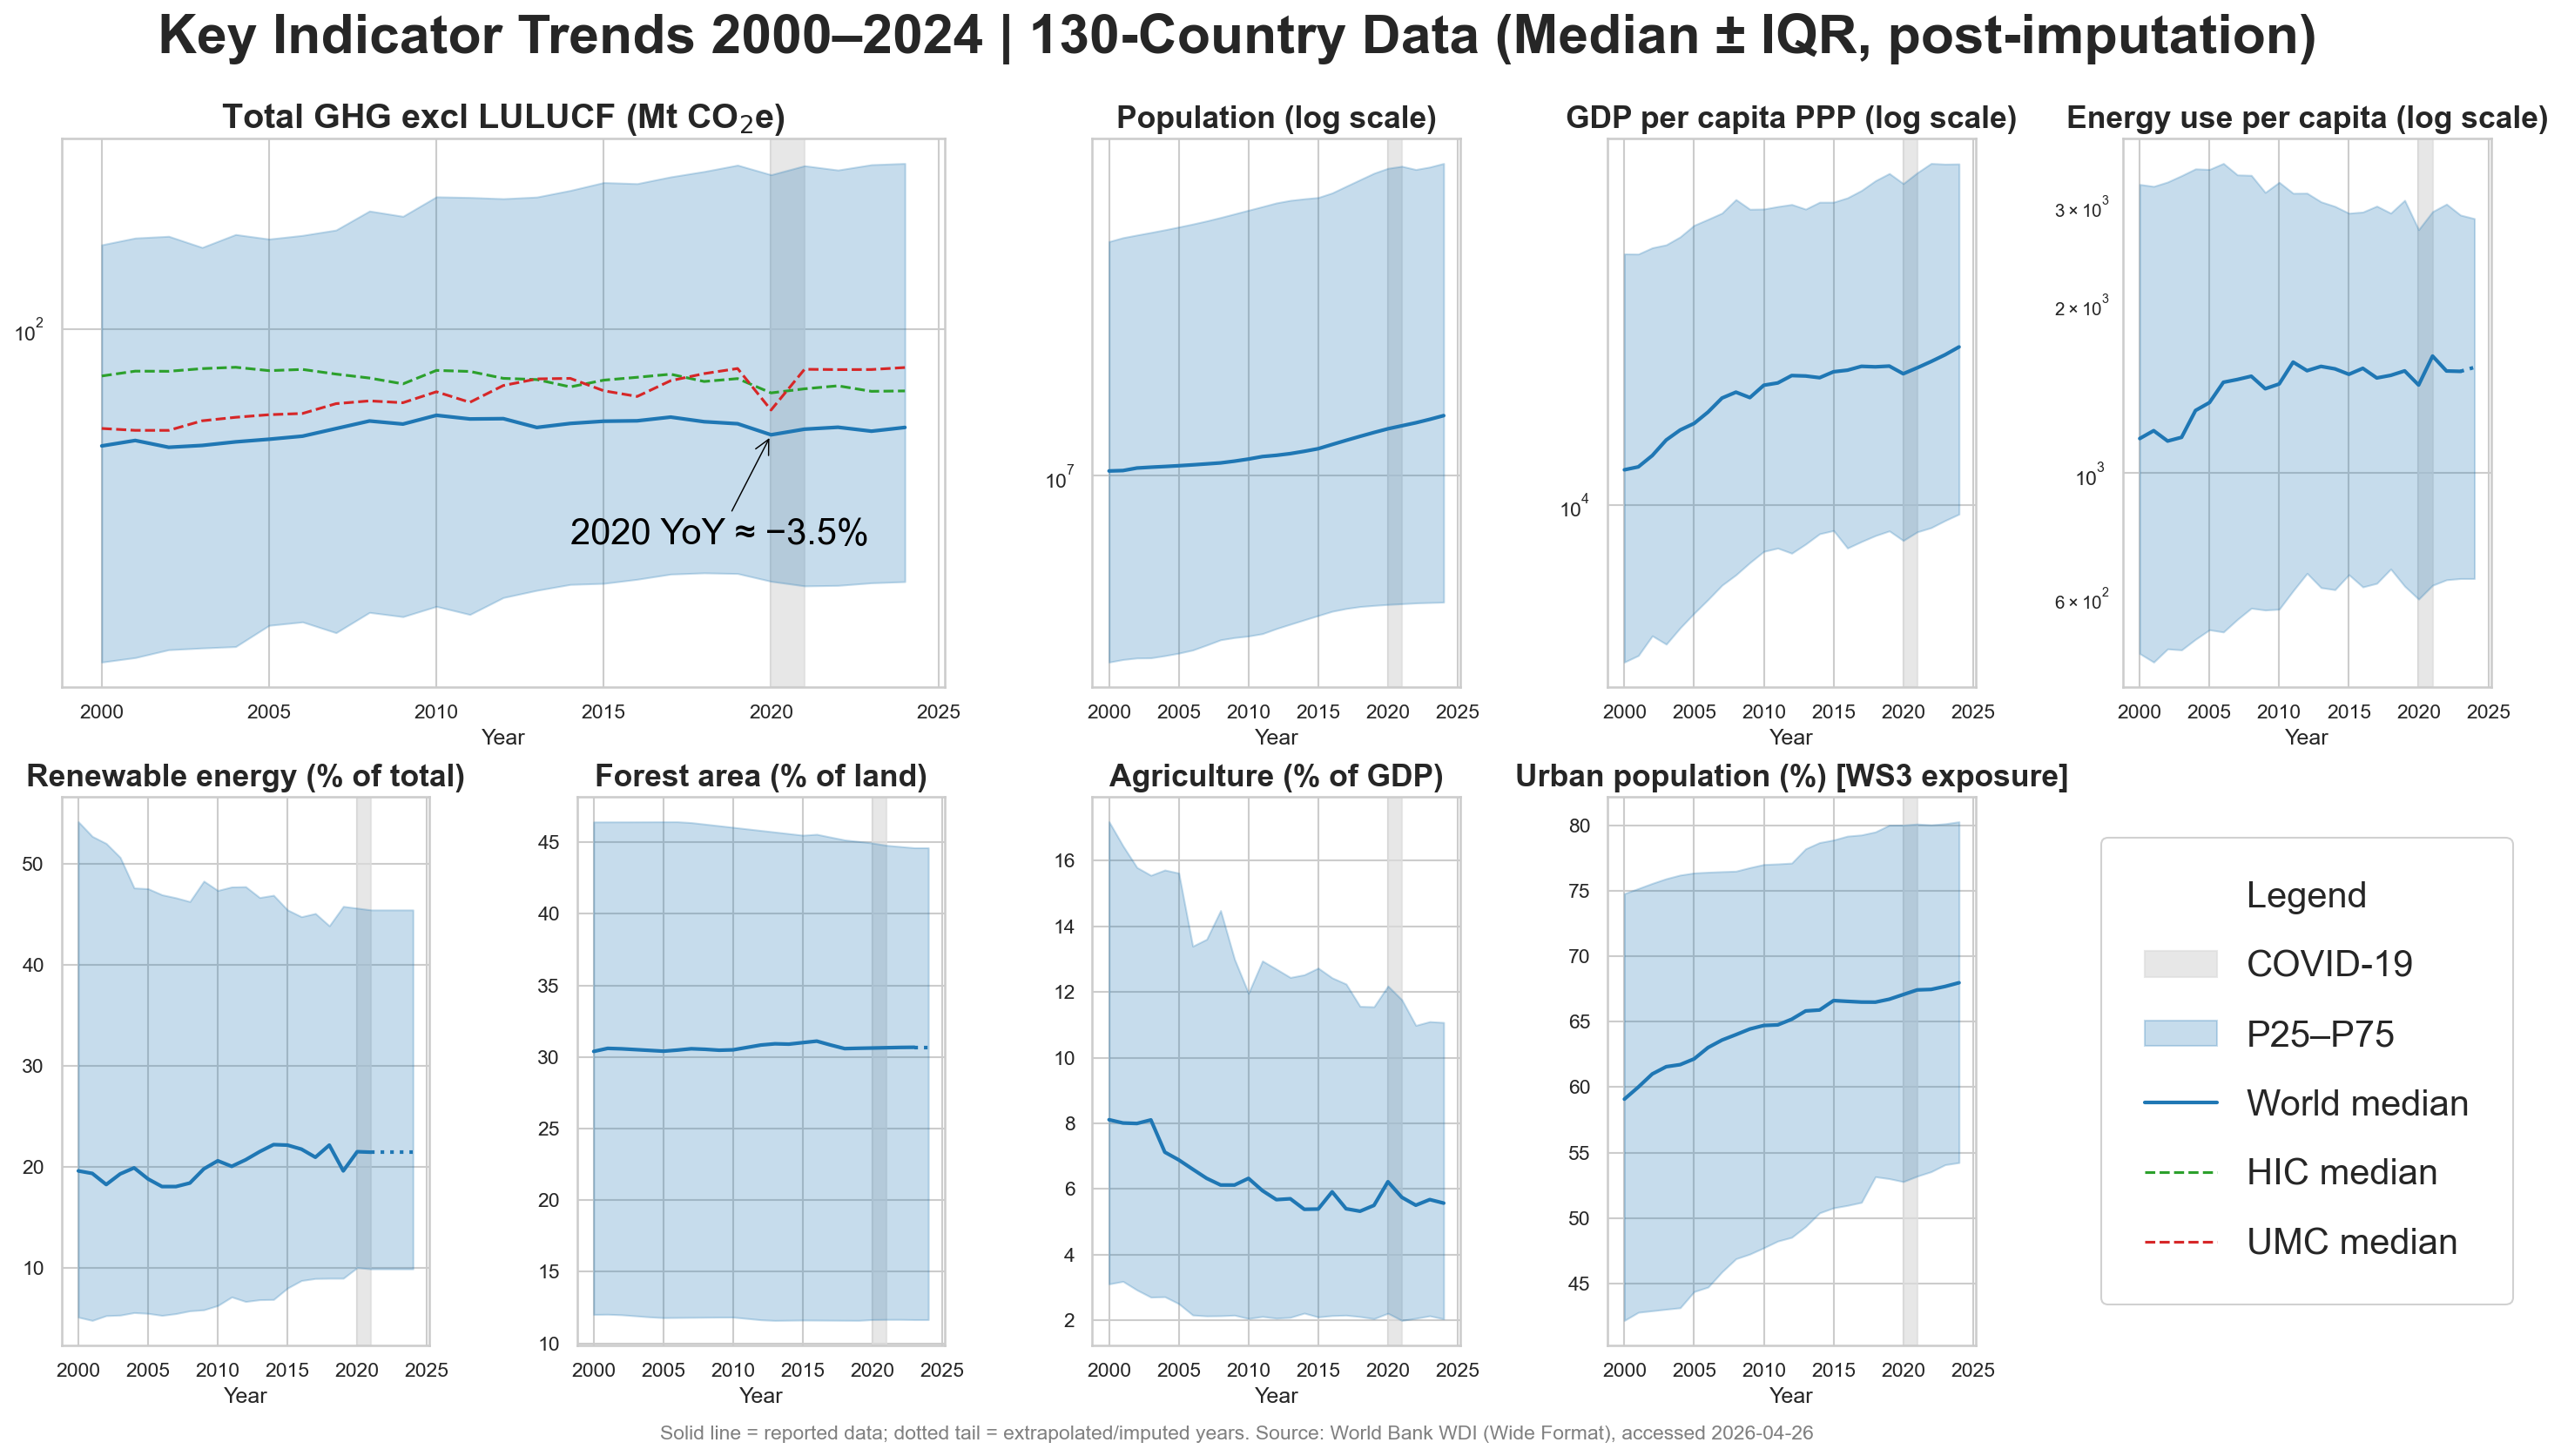

Saved: WS1_Time_Trends.png


In [26]:
# World Bank income-group classification (2024 Atlas method)
# Used to split the data for the GHG reference-line overlay and the EKC chart (5D)
# Source: https://datatopics.worldbank.org/world-development-indicators/the-world-by-income-and-region.html
Income_Group = {
    # High-income (HIC)
    'HIC': {'AUS','AUT','BEL','BHR','BRB','BRN','CAN','CHE','CHL','CYP','CZE','DEU',
            'DNK','ESP','EST','FIN','FRA','GBR','GRC','HKG','HRV','HUN','IRL','ISL',
            'ISR','ITA','JPN','KOR','KWT','LTU','LUX','LVA','MAC','MLT','NLD','NOR',
            'NZL','OMN','PAN','POL','PRT','QAT','ROU','SAU','SGP','SVK','SVN','SWE',
            'TTO','URY','USA','ARE'},
    # Upper-middle-income (UMC)
    'UMC': {'ALB','ARG','ARM','AZE','BGR','BIH','BLR','BRA','BWA','CHN','COL','CRI',
            'CUB','DOM','ECU','FJI','GAB','GEO','GTM','GUY','IDN','IRN','IRQ','JAM',
            'JOR','KAZ','LBN','LBY','MDV','MEX','MKD','MNE','MUS','MYS','NAM','PER',
            'PRY','RUS','SRB','SUR','THA','TKM','TUN','TUR','UKR','VEN','XKX','ZAF'},
    # Lower-middle-income (LMC)
    'LMC': {'AGO','BGD','BEN','BOL','CMR','CIV','COG','CPV','DZA','EGY','GHA','HND',
            'HTI','IND','KEN','KGZ','KHM','LAO','LKA','MAR','MDA','MMR','MNG','MRT',
            'NGA','NIC','NPL','PAK','PHL','PNG','PSE','SEN','SLV','TJK','TLS','TZA',
            'UZB','VNM','ZMB','ZWE'},
    # Low-income (LIC)
    'LIC': {'AFG','BDI','BFA','CAF','COD','ERI','ETH','GIN','GMB','GNB','LBR','MDG',
            'MLI','MOZ','MWI','NER','PRK','RWA','SDN','SLE','SOM','SSD','SYR','TCD',
            'TGO','UGA','YEM'},
}

# Reverse lookup: country code -> income group label
Country_To_Group = {c: g for g, members in Income_Group.items() for c in members}

# Data coverage check
Data_Group_Counts = pd.Series([Country_To_Group.get(c, 'OTH') for c in Data]).value_counts()
print('Income-group coverage in data:')
print(Data_Group_Counts.to_string())

# Last year with reported (non-extrapolated) data per indicator
# Hardcoded from the Step 2 missingness audit (median_last_yr per indicator across the data)
# Years beyond this are drawn dotted (extrapolated via forward-fill)
LAST_REAL_YEAR = {
    Target:                        2024,  # Total GHG — reported through 2024
    'WB_WDI_SP_POP_TOTL':         2024,  # Population
    'WB_WDI_NY_GDP_PCAP_PP_KD':   2024,  # GDP per capita PPP
    'WB_WDI_EG_USE_PCAP_KG_OE':   2023,  # Energy use per capita
    'WB_WDI_EG_FEC_RNEW_ZS':      2021,  # Renewable energy %
    'WB_WDI_AG_LND_FRST_ZS':      2023,  # Forest area %
    'WB_WDI_NV_AGR_TOTL_ZS':      2024,  # Agriculture % of GDP
    Urban_Code:                    2024,  # Urban population %
}

def last_real_year(code):
    return LAST_REAL_YEAR.get(code, max(Int_Years))

# Trend datas: Total GHG + the 7 final predictors (matches our modelled set)
Trend_Datas = [
    (Target,                        'Total GHG excl LULUCF (Mt CO$_2$e)',       True),
    ('WB_WDI_SP_POP_TOTL',         'Population (log scale)',                 True),
    ('WB_WDI_NY_GDP_PCAP_PP_KD',   'GDP per capita PPP (log scale)',         True),
    ('WB_WDI_EG_USE_PCAP_KG_OE',   'Energy use per capita (log scale)',      True),
    ('WB_WDI_EG_FEC_RNEW_ZS',      'Renewable energy (% of total)',          False),
    ('WB_WDI_AG_LND_FRST_ZS',      'Forest area (% of land)',               False),
    ('WB_WDI_NV_AGR_TOTL_ZS',      'Agriculture (% of GDP)',                False),
    (Urban_Code,                    'Urban population (%) [WS3 exposure]',   False),
]

# Map indicator codes to their short names (for Data_Df column lookup)
Trend_Codes = [(c, t, lg, Short.get(c, '')) for c, t, lg in Trend_Datas]

# Pre-compute HIC and UMC median series for the GHG overlay (using imputed Data_Df)
# Handle both 'year' (pre-rename) and 'Year' (post-rename) column names
year_col = 'year' if 'year' in Data_Df.columns else 'Year'

# Data_Df stores Total_GHG in levels (Mt CO₂e); no exp needed
Ghg_Wide_Lvl = Data_Df.pivot(index=year_col, columns='Ref_Area', values=Target_Col)
Hic_In_Data = [c for c in Ghg_Wide_Lvl.columns if Country_To_Group.get(c) == 'HIC']
Umc_In_Data = [c for c in Ghg_Wide_Lvl.columns if Country_To_Group.get(c) == 'UMC']
Ghg_Hic_Med  = Ghg_Wide_Lvl[Hic_In_Data].median(axis=1)
Ghg_Umc_Med  = Ghg_Wide_Lvl[Umc_In_Data].median(axis=1)

# 2×5 data with first graph wider, legend in empty bottom-right cell
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(24, 12))
gs = gridspec.GridSpec(2, 5, height_ratios=[1, 1], hspace=0.2, wspace=0.4)

# Top row: GHG spans 2 cols (bigger), then 3 smaller datas
ax0 = fig.add_subplot(gs[0, 0:2])   # Total GHG (wide)
ax1 = fig.add_subplot(gs[0, 2])     # Population
ax2 = fig.add_subplot(gs[0, 3])     # GDP per capita PPP
ax3 = fig.add_subplot(gs[0, 4])     # Energy use per capita

# Bottom row: 4 smaller datas, last cell for legend
ax4 = fig.add_subplot(gs[1, 0])     # Renewable energy %
ax5 = fig.add_subplot(gs[1, 1])     # Forest area %
ax6 = fig.add_subplot(gs[1, 2])     # Agriculture % of GDP
ax7 = fig.add_subplot(gs[1, 3])     # Urban population %
ax_legend = fig.add_subplot(gs[1, 4])  # Empty cell for legend

axes_all = [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7]

# Fix CO₂ subscript: use mathtext so the '₂' renders properly
Trend_Titles = [t.replace('CO₂', r'CO$_2$') for (_, t, _, _) in Trend_Codes]

for ax_idx, (code, title_orig, use_log, sn) in enumerate(Trend_Codes):
    ax = axes_all[ax_idx]
    title = Trend_Titles[ax_idx]
    ax.axvspan(2020, 2021, color='#dddddd', alpha=0.7, label='COVID-19' if ax_idx == 0 else None)

    # Special case: Target column in Data_Df is already log-transformed — convert back for display
    if code == Target:
        wide = Ghg_Wide_Lvl
    elif sn and sn in Data_Df.columns:
        wide = Data_Df.pivot(index=year_col, columns='Ref_Area', values=sn)
    else:
        ax.set_title(f'{title}\n(not in Data_Df)', fontsize=14, color='grey')
        continue

    median_vals = wide.median(axis=1).values.astype(float)
    p25_vals   = wide.quantile(0.25, axis=1).values.astype(float)
    p75_vals   = wide.quantile(0.75, axis=1).values.astype(float)
    yr_index   = wide.index.values

    # Split into "real" (≤ last_real_year) and "extrapolated" (> last_real_year) segments
    cutoff  = last_real_year(code)
    real_mk = yr_index <= cutoff
    extr_mk = yr_index >= cutoff  # overlap by one year so the lines connect

    # IQR band (full range, light)
    ax.fill_between(yr_index, p25_vals, p75_vals, alpha=0.25, color='#1f77b4', label='P25–P75')

    # Solid line for real data
    ax.plot(yr_index[real_mk], median_vals[real_mk], color='#1f77b4', lw=2,
            label='World median' if ax_idx == 0 else None)

    # Dotted line (same colour) for extrapolated tail
    if extr_mk.sum() >= 2:
        ax.plot(yr_index[extr_mk], median_vals[extr_mk], color='#1f77b4', lw=2, ls=':',
                label='Extrapolated' if ax_idx == 0 else None)

    # GHG data only: HIC/UMC overlay + COVID annotation
    if ax_idx == 0:
        hic_cut = last_real_year(Target)
        ax.plot(yr_index[yr_index <= hic_cut], Ghg_Hic_Med.values[yr_index <= hic_cut],
                color='#2ca02c', lw=1.5, ls='--', label='HIC median')
        ax.plot(yr_index[yr_index >= hic_cut], Ghg_Hic_Med.values[yr_index >= hic_cut],
                color='#2ca02c', lw=1.5, ls=':')
        ax.plot(yr_index[yr_index <= hic_cut], Ghg_Umc_Med.values[yr_index <= hic_cut],
                color='#d62728', lw=1.5, ls='--', label='UMC median')
        ax.plot(yr_index[yr_index >= hic_cut], Ghg_Umc_Med.values[yr_index >= hic_cut],
                color='#d62728', lw=1.5, ls=':')
        # COVID annotation
        idx_2020 = np.where(yr_index == 2020)[0]
        if len(idx_2020):
            ax.annotate('2020 YoY ≈ −3.5%', xy=(2020, median_vals[idx_2020[0]]),
                        xytext=(2014, median_vals[idx_2020[0]] * 0.55),
                        fontsize=20, color='black',
                        arrowprops=dict(arrowstyle='->', color='black', lw=0.7))

    # Titles for all datas
    ax.set_title(title, fontsize=19 if ax_idx == 0 else 17, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12)
    ax.tick_params(axis='both', labelsize=11)
    if use_log:
        ax.set_yscale('log')

# Place legend in the empty bottom-right cell
ax_legend.axis('off')
handles, labels = axes_all[0].get_legend_handles_labels()
ax_legend.legend(handles, labels, loc='center', fontsize=20, framealpha=0.9,
                 title='Legend', title_fontsize=20, borderpad=1.2, labelspacing=1.0)

suptitle_text = f'Key Indicator Trends 2000–2024 | {len(Data)}-Country Data (Median ± IQR, post-imputation)'
fig.suptitle(suptitle_text, fontsize=30, fontweight='bold', y=0.96)
plt.figtext(0.5, 0.05,
            'Solid line = reported data; dotted tail = extrapolated/imputed years. ' + WDI_Source,
            ha='center', fontsize=11, color='grey')
plt.tight_layout(rect=[0, 0.01, 1, 0.96])
fig.savefig(Output_WS1 / 'WS1_Time_Trends.png', bbox_inches='tight')
plt.show()
print('Saved: WS1_Time_Trends.png')

**Trend notes:**
- **GHG data divergence:** the world median rises steadily, but the HIC reference line plateaus from ~2010 onward while the UMC reference line keeps climbing. This is the **decoupling story** — high-income economies are stabilising emissions while upper-middle-income economies are not.
- **COVID dip is real and widespread:** the 2020 median YoY change is −3.5% across the data, supporting our decision to flag 2020–2021 with a binary dummy in WS2 rather than treat them as normal observations.
- **IQR widening over time** suggests countries are growing *more different* from each other on most drivers — implying country fixed effects (rather than a pooled model) are necessary in WS2.
- **Renewable share is rising slowly globally** — the typical country has only ~30% renewables in final energy consumption, leaving substantial room as a future mitigation lever (used in the WS4 stress test).


### Step 5(B) GHG Composition

Stacked area chart showing the breakdown of Total GHG into its components — CO₂, methane (CH₄), and nitrous oxide (N₂O), summed across all 135 countries. 

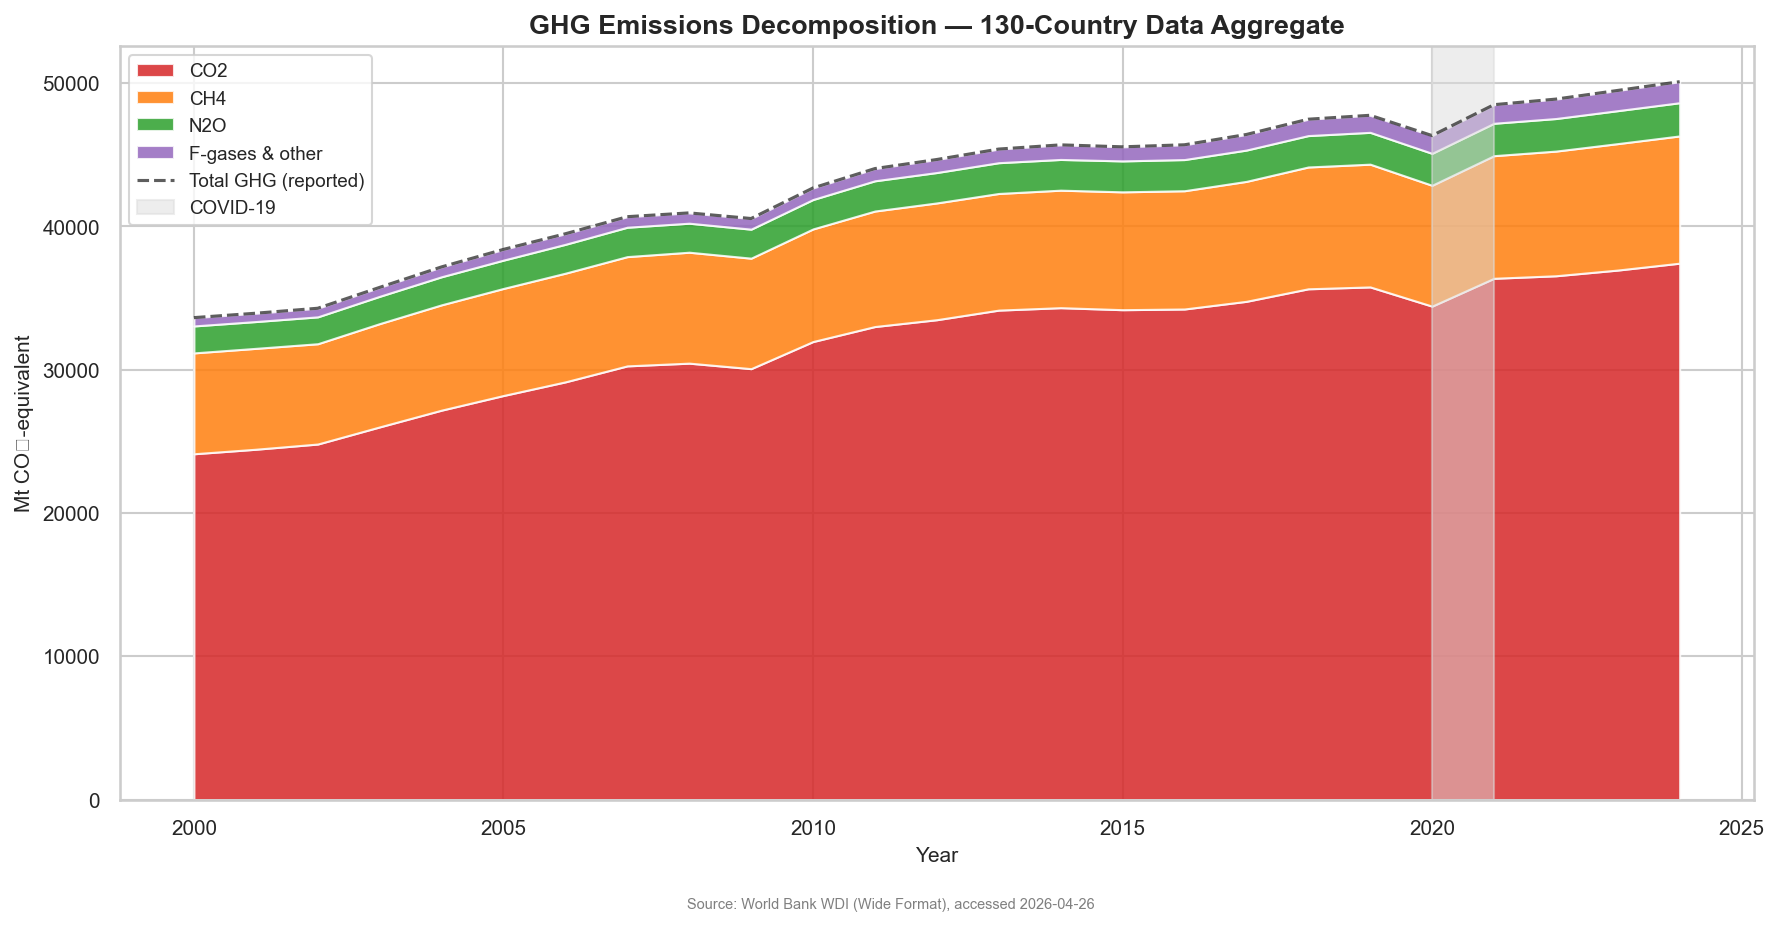

Saved: WS1_GHG_Composition.png

=== 2024 composition shares (data aggregate) ===
  CO₂              :  74.7%
  CH₄              :  17.7%
  N₂O              :   4.6%
  F-gases & other  :   2.9%


In [27]:
# Load GHG sub-components for decomposition chart (not used as predictors)
Ghg_Components = {
    'WB_WDI_EN_GHG_CO2_MT_CE_AR5': 'CO2',
    'WB_WDI_EN_GHG_CH4_MT_CE_AR5': 'CH4',
    'WB_WDI_EN_GHG_N2O_MT_CE_AR5': 'N2O',
}

Ghg_Frames = []
for code, label in Ghg_Components.items():
    rows = get_rows(WDI_Data, code)
    if rows.empty:
        print(f'  WARNING: {label} ({code}) not found')
        continue
    melted = (rows[['Ref_Area'] + Years]
              .melt(id_vars='Ref_Area', value_vars=Years,
                    var_name='year', value_name=label)
              .assign(year=lambda x: x.year.astype(int))
              .groupby(['Ref_Area', 'year'])[label].mean()
              .reset_index())
    Ghg_Frames.append(melted)

# Total GHG (kept alive for use in 5E SE Asia chart)
GHG_Data = (get_rows(WDI_Data, Target)[['Ref_Area'] + Years]
             .melt(id_vars='Ref_Area', value_vars=Years,
                   var_name='year', value_name='Total GHG')
             .assign(year=lambda x: x.year.astype(int))
             .groupby(['Ref_Area', 'year'])['Total GHG'].mean()
             .reset_index())

for f in Ghg_Frames:
    GHG_Data = GHG_Data.merge(f, on=['Ref_Area', 'year'], how='left')

# Aggregate across all countries
Ghg_Agg = GHG_Data.groupby('year')[['Total GHG', 'CO2', 'CH4', 'N2O']].sum()
Ghg_Agg['F-gases & other'] = (Ghg_Agg['Total GHG'] - Ghg_Agg[['CO2', 'CH4', 'N2O']].sum(axis=1)).clip(lower=0)

# Component shares for the takeaway
Last_Yr      = int(Ghg_Agg.index.max())
Total_Last   = Ghg_Agg.loc[Last_Yr, 'Total GHG']
Co2_Share    = 100 * Ghg_Agg.loc[Last_Yr, 'CO2'] / Total_Last
Ch4_Share    = 100 * Ghg_Agg.loc[Last_Yr, 'CH4'] / Total_Last
N2o_Share    = 100 * Ghg_Agg.loc[Last_Yr, 'N2O'] / Total_Last
Other_Share  = 100 * Ghg_Agg.loc[Last_Yr, 'F-gases & other'] / Total_Last

# Stacked area chart
fig, ax = plt.subplots(figsize=(12, 6))
Stack_Cols = [c for c in ['CO2', 'CH4', 'N2O', 'F-gases & other'] if c in Ghg_Agg.columns]
ax.stackplot(Ghg_Agg.index, *[Ghg_Agg[c].values for c in Stack_Cols],
             labels=Stack_Cols, colors=['#d62728', '#ff7f0e', '#2ca02c', '#9467bd'], alpha=0.85)
ax.plot(Ghg_Agg.index, Ghg_Agg['Total GHG'], 'k--', lw=1.5, label='Total GHG (reported)', alpha=0.7)
ax.axvspan(2020, 2021, color='#dddddd', alpha=0.5, label='COVID-19')
ax.set_title(f'GHG Emissions Decomposition — {len(Data)}-Country Data Aggregate',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Mt CO₂-equivalent', fontsize=10)
ax.legend(loc='upper left', fontsize=9)
plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS1 / 'WS1_GHG_Composition.png', bbox_inches='tight')
plt.show()
print('Saved: WS1_GHG_Composition.png')

print(f'\n=== {Last_Yr} composition shares (data aggregate) ===')
print(f'  CO₂              : {Co2_Share:5.1f}%')
print(f'  CH₄              : {Ch4_Share:5.1f}%')
print(f'  N₂O              : {N2o_Share:5.1f}%')
print(f'  F-gases & other  : {Other_Share:5.1f}%')

### Step 5(C) Predictors vs log(Total GHG) — Linear & LOWESS Fits

Each data shows one of our **seven final predictors** against log(Total GHG). Each dot is one country in one year, coloured by country.

**How to read these charts:**
- The **black solid line** is the OLS linear fit; the grey band is its 95% confidence interval.
- The **red dashed line** is a LOWESS smoother — a flexible curve that doesn't assume linearity.
- If the LOWESS tracks the linear fit closely, the relationship is approximately linear and a linear model is well-specified.
- If the LOWESS bends visibly, the relationship is non-linear and we should consider quadratic terms (or transformations) in WS2.
- The within-country r in each title tells us strength of the linear association (closer to ±1 = stronger).

This is both a **bivariate-significance check** and a **specification diagnostic**.

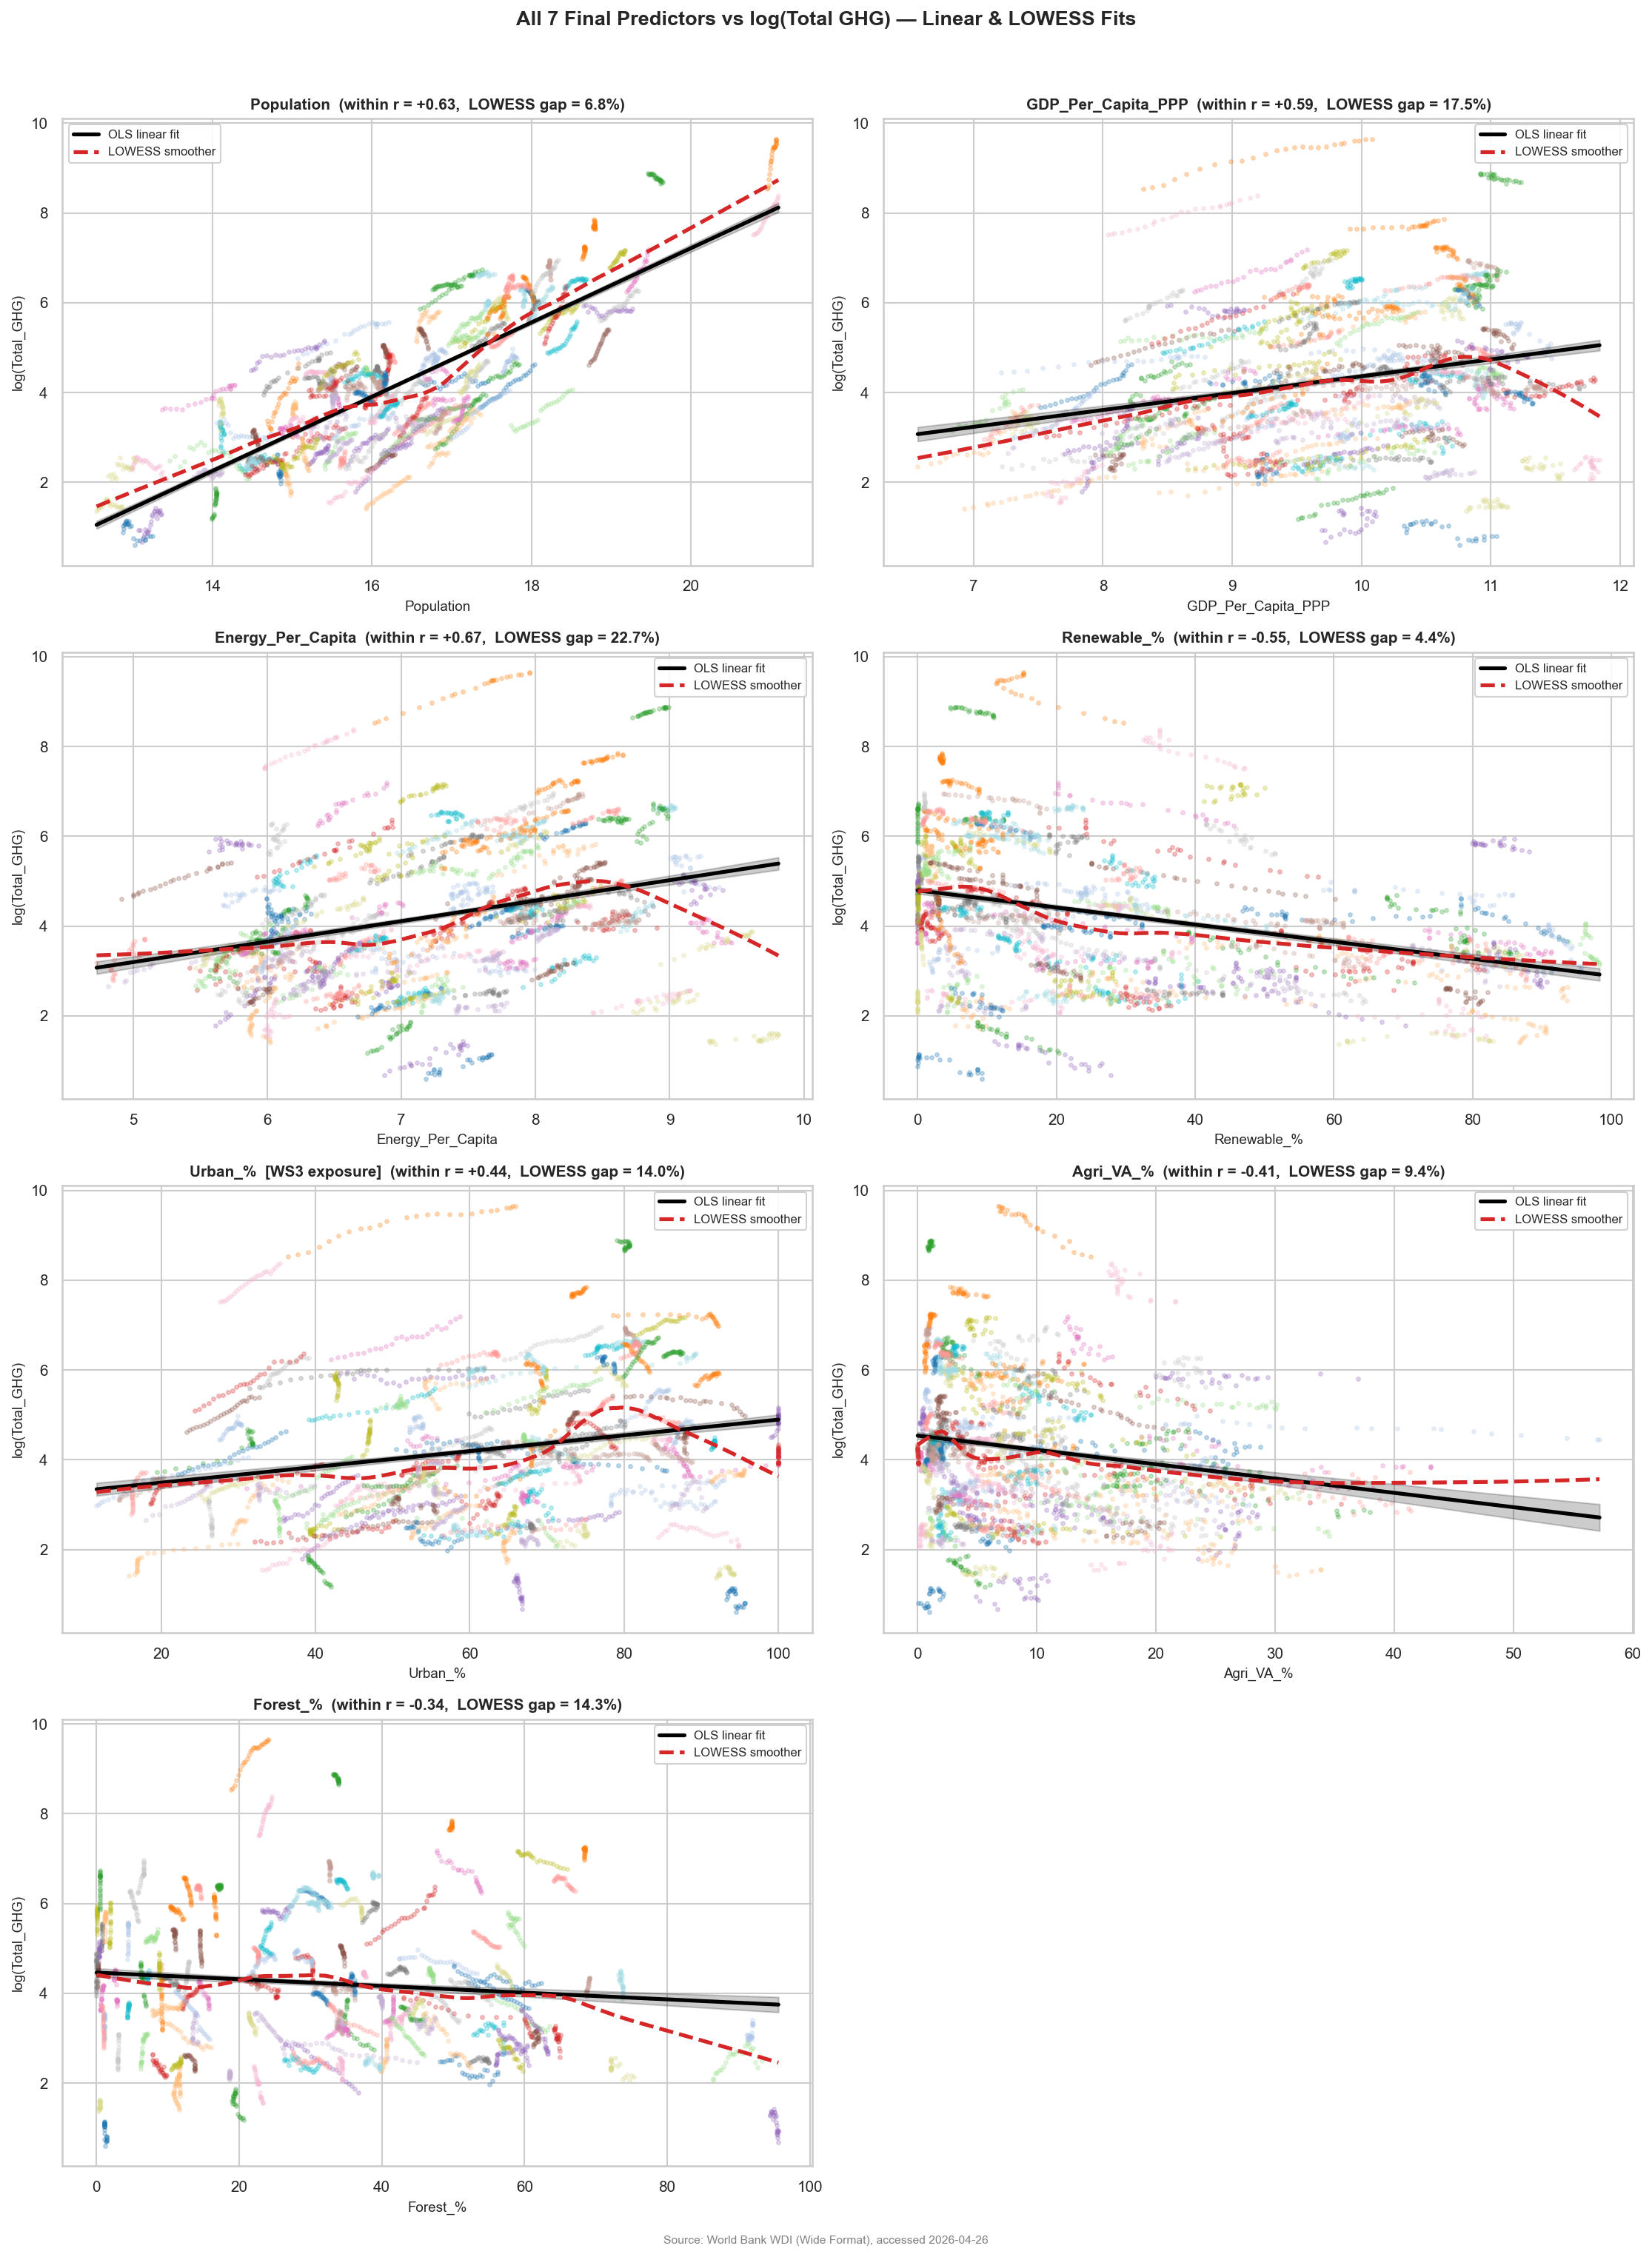

Saved: WS1_Predictors_Scatter_LOWESS.png

=== Non-linearity check (LOWESS vs linear fit) ===
  Energy_Per_Capita     gap =  22.7%   ⚠ check non-linearity in WS2
  GDP_Per_Capita_PPP    gap =  17.5%   ⚠ check non-linearity in WS2
  Forest_%              gap =  14.3%   ⚠ check non-linearity in WS2
  Urban_%               gap =  14.0%   ⚠ check non-linearity in WS2
  Agri_VA_%             gap =   9.4%   ⚠ check non-linearity in WS2
  Population            gap =   6.8%   ⚠ check non-linearity in WS2
  Renewable_%           gap =   4.4%      linear OK


In [28]:
# LOWESS smoother (statsmodels)
from statsmodels.nonparametric.smoothers_lowess import lowess

# 4×2 scatter grid: each predictor vs log(Total GHG) with OLS fit + LOWESS smoother
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
Lowess_Notes = []

for i, predictor in enumerate(Final_Predictors):
    ax  = axes.flatten()[i]
    sub = Corr_Df[['Ref_Area', predictor, Target_Col]].dropna()
    r   = Corr_Within[Target_Col].get(predictor, float('nan'))

    # Scatter: one dot per country-year, coloured by country (faded so fit lines stand out)
    for country, grp in sub.groupby('Ref_Area'):
        ax.scatter(grp[predictor], grp[Target_Col],
                   color=Country_Pal.get(country, 'grey'), s=6, alpha=0.25)

    x, y = sub[predictor].values, sub[Target_Col].values

    # OLS line + 95% CI band
    sl, ic, *_ = stats.linregress(x, y)
    xl  = np.linspace(x.min(), x.max(), 100)
    yl  = sl * xl + ic
    res = y - (sl * x + ic)
    se  = np.sqrt(res.var() / len(x) +
                  (xl - x.mean())**2 * res.var() / np.sum((x - x.mean())**2))
    ax.plot(xl, yl, color='black', lw=2.5, label='OLS linear fit', zorder=10)
    ax.fill_between(xl, yl - 1.96*se, yl + 1.96*se, alpha=0.2, color='black', zorder=9)

    # LOWESS smoother (red dashed) — bumped up zorder so it sits on top of dots
    lw_out = lowess(y, x, frac=0.4, return_sorted=True)
    ax.plot(lw_out[:, 0], lw_out[:, 1], color='#d62728', lw=2.5, ls='--',
            label='LOWESS smoother', zorder=11)

    # Quick non-linearity check: max gap between LOWESS and linear fit, normalised by y range
    lw_at_xl = np.interp(xl, lw_out[:, 0], lw_out[:, 1])
    gap_pct  = 100 * np.max(np.abs(lw_at_xl - yl)) / (y.max() - y.min() + 1e-9)
    Lowess_Notes.append((predictor, gap_pct))

    tag = '  [WS3 exposure]' if predictor == Urban_Short else ''
    ax.set_title(f'{predictor}{tag}  (within r = {r:+.2f},  LOWESS gap = {gap_pct:.1f}%)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(predictor, fontsize=9)
    ax.set_ylabel(f'log({Target_Col})', fontsize=9)
    ax.legend(loc='best', fontsize=8, framealpha=0.9)

# Hide unused subplots if any
for j in range(len(Final_Predictors), 8):
    axes.flatten()[j].axis('off')

fig.suptitle(f'All 7 Final Predictors vs log(Total GHG) — Linear & LOWESS Fits',
             fontsize=13, fontweight='bold', y=1.00)
plt.figtext(0.5, -0.005, WDI_Source, ha='center', fontsize=7.5, color='grey')
plt.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(Output_WS1 / 'WS1_Predictors_Scatter_LOWESS.png', bbox_inches='tight')
plt.show()
print('Saved: WS1_Predictors_Scatter_LOWESS.png')

# Summary: flag predictors with notable non-linearity (LOWESS gap > 5% of y-range)
print('\n=== Non-linearity check (LOWESS vs linear fit) ===')
for pred, gap in sorted(Lowess_Notes, key=lambda t: -t[1]):
    flag = '⚠ check non-linearity in WS2' if gap > 5 else '   linear OK'
    print(f'  {pred:<20s}  gap = {gap:5.1f}%   {flag}')

### Step 5(D) Income-Stratified Scatter (Environmental Kuznets Curve Test)

The pooled scatter in 5(C) hides a critical pattern: 
* The relationship between income and emissions **differs by development stage**. 
* We split the data by World Bank income group (LIC / LMC / UMC / HIC) and fit a separate regression line for each. 

**The hypothesis being tested:** the **Environmental Kuznets Curve (EKC)**: 
* Emissions rise with income at low levels of development, then flatten or fall once countries reach high income (cleaner technology, service-sector economy, environmental policy).

**From client perspective: :**
- The client's Southeast Asian exposure spans **HIC** (Singapore), **UMC** (Malaysia, Thailand) and **LMC** (Indonesia, Vietnam, Philippines).
- If the income–emissions slope is steeper for LMC/UMC than for HIC, **emerging-market exposure carries higher embedded growth-driven climate risk** than legacy markets — and that has direct pricing implications for reinsurance. 

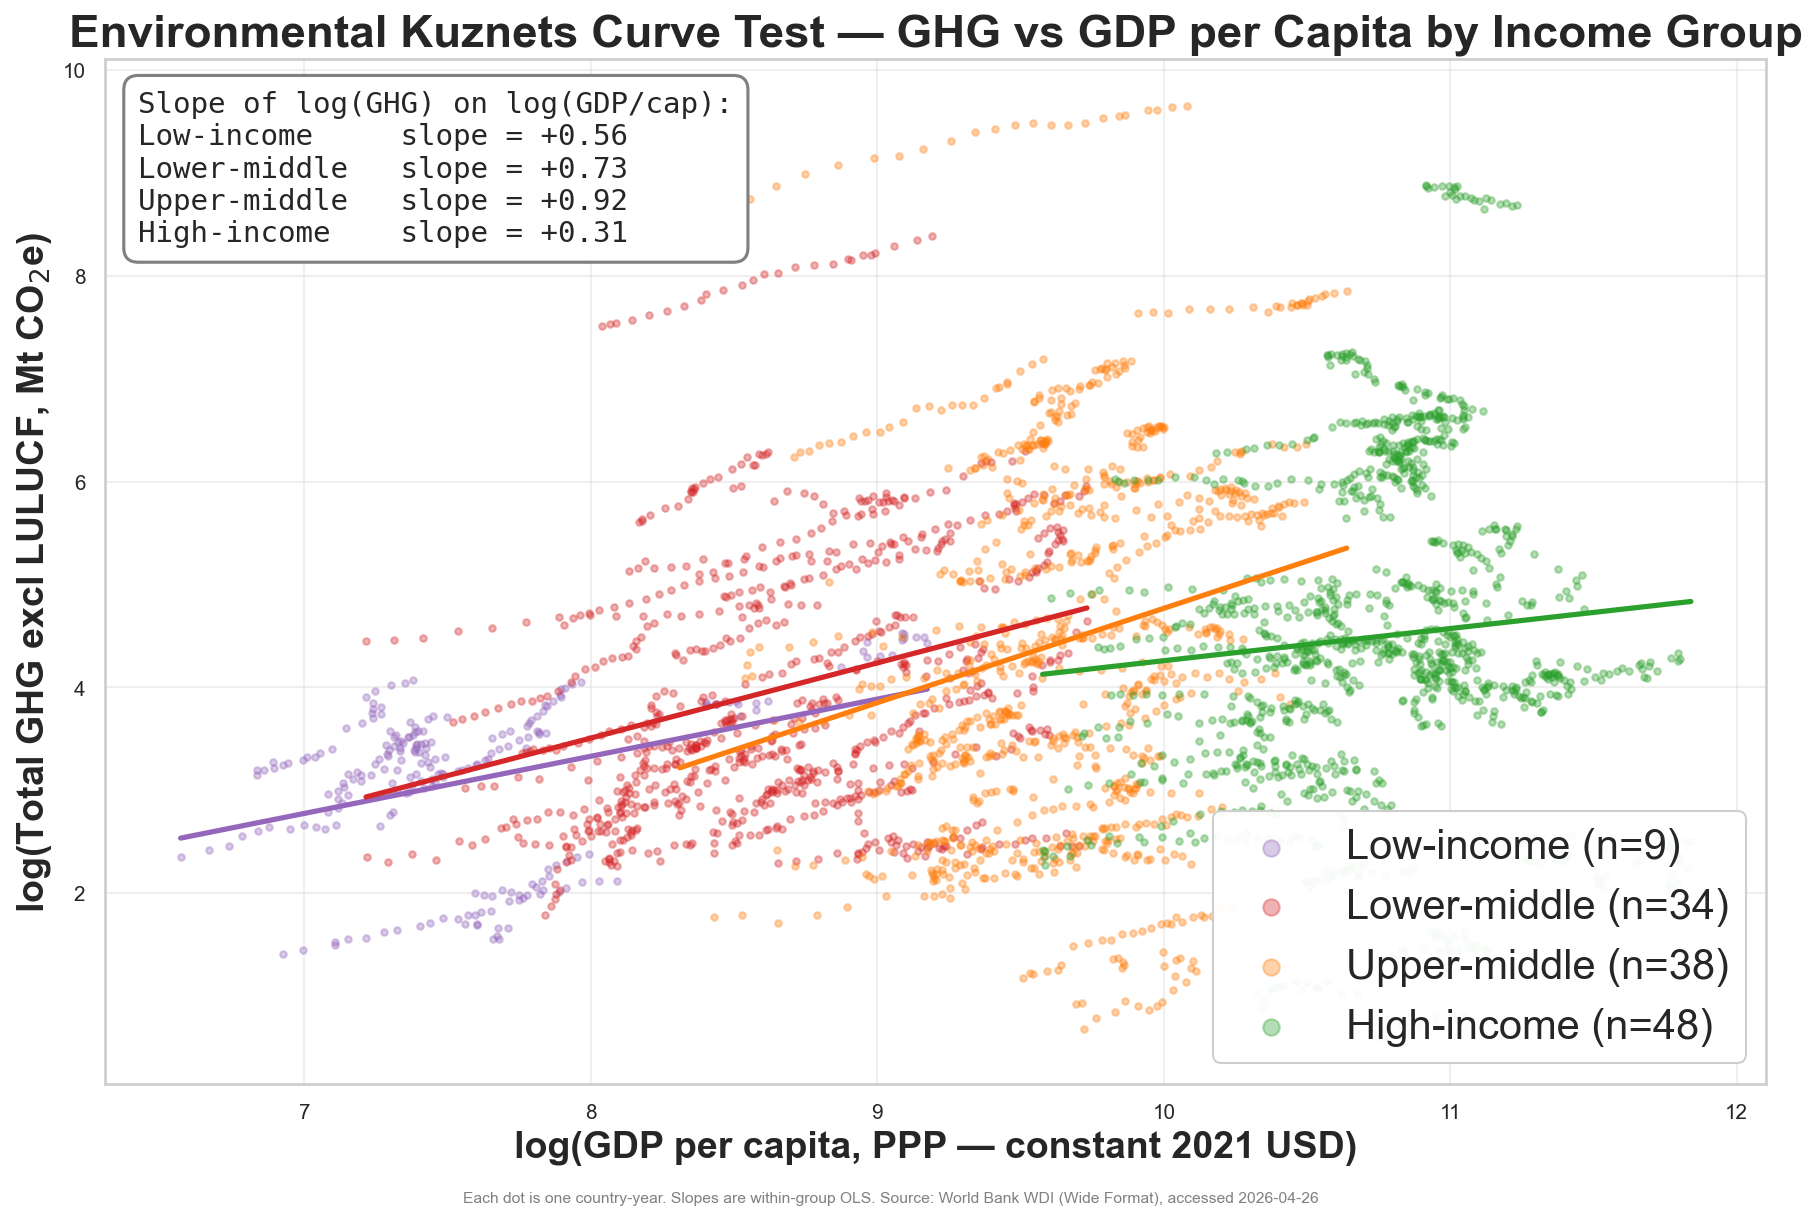

Saved: WS1_EKC_By_Income.png

=== EKC slope by income group ===
  Group              Slope         r     p-value   n_countries
  --------------  --------  --------  ----------  ------------
  Low-income        +0.556    +0.374     < 0.001             9
  Lower-middle      +0.730    +0.289     < 0.001            34
  Upper-middle      +0.917    +0.198     < 0.001            38
  High-income       +0.313    +0.084      0.0037            48

  → EKC supported: low/middle-income slope (+0.64) > high-income slope (+0.31).
    Implication: emerging-market exposure carries steeper income-driven emissions growth.


In [29]:
# EKC scatter: log(GDP/cap PPP) on x, log(Total GHG) on y, coloured by income group
Ekc_Df = Data_Df[['Ref_Area', 'year', 'GDP_Per_Capita_PPP', Target_Col]].dropna().copy()
Ekc_Df['GDP_Per_Capita_PPP'] = np.log(Ekc_Df['GDP_Per_Capita_PPP'].clip(lower=1e-9))
Ekc_Df[Target_Col]           = np.log(Ekc_Df[Target_Col].clip(lower=1e-9))
Ekc_Df['Group']              = Ekc_Df['Ref_Area'].map(Country_To_Group).fillna('OTH')
Ekc_Df = Ekc_Df[Ekc_Df.Group != 'OTH']

# Group palette and labels
Group_Order = ['LIC', 'LMC', 'UMC', 'HIC']
Group_Pal   = {'LIC': '#9467bd', 'LMC': '#d62728', 'UMC': '#ff7f0e', 'HIC': '#2ca02c'}
Group_Name  = {'LIC': 'Low-income', 'LMC': 'Lower-middle', 'UMC': 'Upper-middle', 'HIC': 'High-income'}

# Single-data scatter with separate OLS line per group
fig, ax = plt.subplots(figsize=(12, 8))
Slopes = {}

for g in Group_Order:
    sub = Ekc_Df[Ekc_Df.Group == g]
    if sub.empty:
        continue
    ax.scatter(sub.GDP_Per_Capita_PPP, sub[Target_Col],
               color=Group_Pal[g], s=10, alpha=0.35, label=f'{Group_Name[g]} (n={sub.Ref_Area.nunique()})')

    # OLS within group
    x, y = sub.GDP_Per_Capita_PPP.values, sub[Target_Col].values
    sl, ic, r_g, p_g, _ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 50)
    ax.plot(xl, sl * xl + ic, color=Group_Pal[g], lw=2.5)
    Slopes[g] = (sl, r_g, p_g, sub.Ref_Area.nunique())

ax.set_xlabel('log(GDP per capita, PPP — constant 2021 USD)', fontsize=18, fontweight='bold')
ax.set_ylabel('log(Total GHG excl LULUCF, Mt CO$_2$e)', fontsize=18, fontweight='bold')
ax.set_title('Environmental Kuznets Curve Test — GHG vs GDP per Capita by Income Group',
             fontsize=22, fontweight='bold')
ax.legend(loc='lower right', fontsize=20, markerscale=2.5, framealpha=0.95)
ax.grid(alpha=0.3)

# Annotate slopes inside the plot
slope_text = '\n'.join(f'{Group_Name[g]:<14s} slope = {sl:+.2f}'
                      for g, (sl, _, _, _) in Slopes.items())
ax.text(0.02, 0.97, 'Slope of log(GHG) on log(GDP/cap):\n' + slope_text,
        transform=ax.transAxes, fontsize=14, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='grey', linewidth=1.5, alpha=1))

plt.figtext(0.5, -0.01, 'Each dot is one country-year. Slopes are within-group OLS. ' + WDI_Source,
            ha='center', fontsize=7.5, color='grey')
plt.tight_layout()
fig.savefig(Output_WS1 / 'WS1_EKC_By_Income.png', bbox_inches='tight')
plt.show()
print('Saved: WS1_EKC_By_Income.png')

# Print structured summary
print('\n=== EKC slope by income group ===')
print(f"  {'Group':<14s}  {'Slope':>8s}  {'r':>8s}  {'p-value':>10s}  {'n_countries':>12s}")
print(f"  {'-'*14}  {'-'*8}  {'-'*8}  {'-'*10}  {'-'*12}")
for g in Group_Order:
    if g not in Slopes:
        continue
    sl, r_g, p_g, n_c = Slopes[g]
    p_str = '< 0.001' if p_g < 0.001 else f'{p_g:.4f}'
    print(f"  {Group_Name[g]:<14s}  {sl:+8.3f}  {r_g:+8.3f}  {p_str:>10s}  {n_c:>12d}")

# Verdict
Slope_Lic_Lmc = np.mean([Slopes[g][0] for g in ['LIC', 'LMC'] if g in Slopes])
Slope_Hic     = Slopes.get('HIC', (np.nan,))[0]
if not np.isnan(Slope_Hic) and Slope_Lic_Lmc > Slope_Hic:
    print(f'\n  → EKC supported: low/middle-income slope ({Slope_Lic_Lmc:+.2f}) '
          f'> high-income slope ({Slope_Hic:+.2f}).')
    print('    Implication: emerging-market exposure carries steeper income-driven emissions growth.')
else:
    print(f'\n  → EKC not clearly supported in this data.')

### Step 5(E) Southeast Asia Emissions Trajectory

The client has regional exposure across ASEAN. We plot **per-capita** GHG for the ASEAN-6 (Singapore, Malaysia, Thailand, Indonesia, Vietnam, Philippines) against world, HIC, and UMC reference medians.

**Why per capita rather than total?**
- Total emissions are dominated by Indonesia in absolute terms — the chart would just show "Indonesia is the biggest" and obscure the trajectory information.
- Per-capita normalises out population differences, exposing the underlying **intensity of economic activity per person** — which is what drives both insurance exposure (more economic activity = more insured assets at risk) and policy commitments under Paris Agreement NDCs.

**This chart bridges to:**
- **WS3** (natural-disaster insurance claims comparison between two SE Asian countries — the trajectory tells us *which* two to compare).
- **WS4** (stress test — high-trajectory countries are where mitigation strategies have the largest projected impact). 

In [30]:
import matplotlib.ticker as mticker

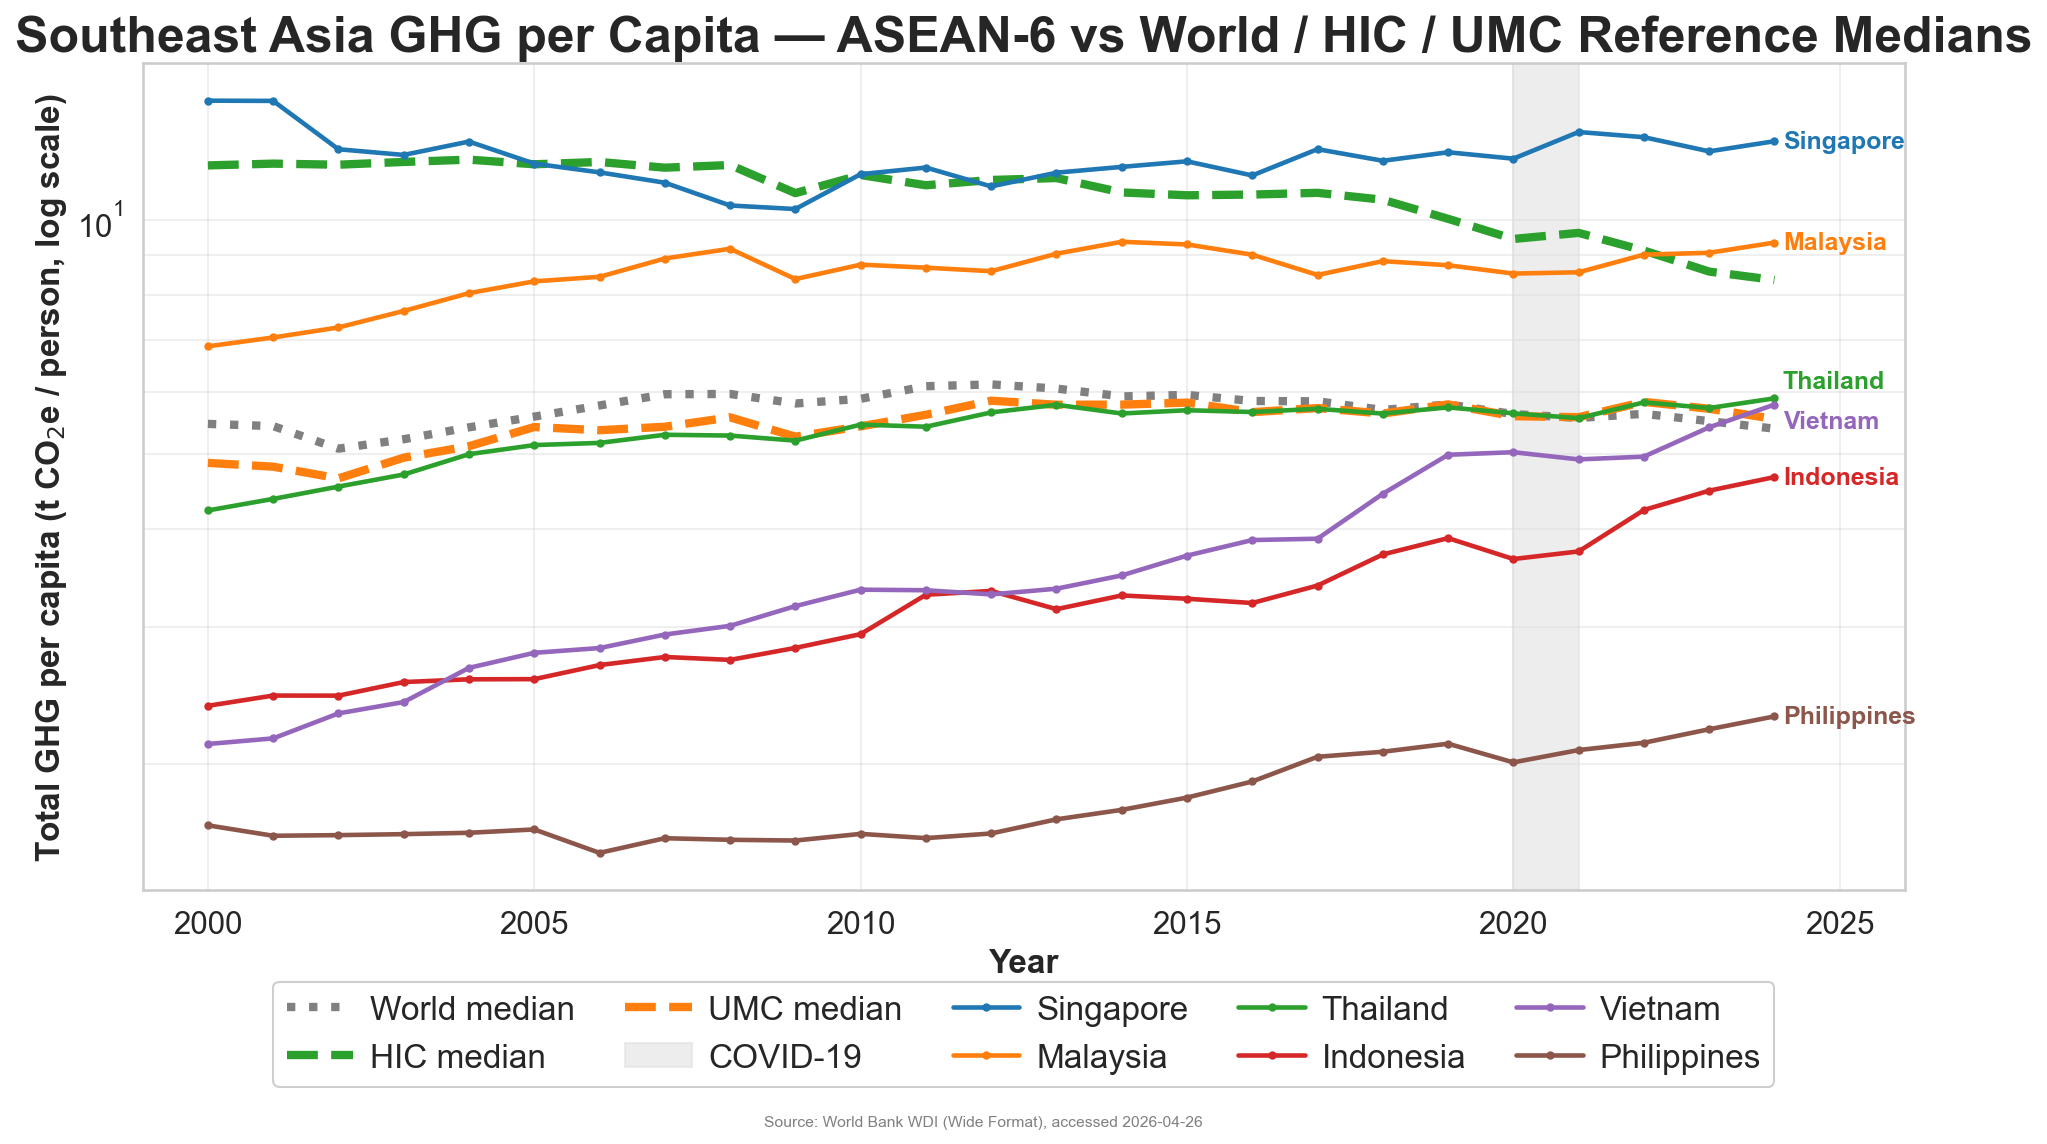

Saved: WS1_SE_Asia_Trajectory.png

=== ASEAN-6 per-capita GHG summary ===
  Country           2000      2023      CAGR  Position vs HIC/UMC (2023)  
  ------------  --------  --------  --------  ----------------------------
  Singapore        14.21     12.23    -0.65%  above HIC                   
  Malaysia          6.87      9.06    +1.21%  above HIC                   
  Thailand          4.23      5.73    +1.33%  between UMC and HIC         
  Indonesia         2.37      4.49    +2.80%  at or below UMC             
  Vietnam           2.12      5.41    +4.16%  at or below UMC             
  Philippines       1.67      2.22    +1.24%  at or below UMC             


In [31]:
# SE Asia per-capita GHG trajectory vs world / HIC / UMC reference medians
Sea_Focus  = ['SGP', 'MYS', 'THA', 'IDN', 'VNM', 'PHL']
Sea_Names  = {'SGP': 'Singapore', 'MYS': 'Malaysia', 'THA': 'Thailand',
              'IDN': 'Indonesia', 'VNM': 'Vietnam',  'PHL': 'Philippines'}

# Build per-capita GHG (t CO₂e per person)
Pop_Long = (get_rows(WDI_Data, 'WB_WDI_SP_POP_TOTL')[['Ref_Area'] + Years]
            .melt(id_vars='Ref_Area', value_vars=Years,
                  var_name='year', value_name='Population')
            .assign(year=lambda x: x.year.astype(int)))

Pc_Df = GHG_Data[['Ref_Area', 'year', 'Total GHG']].merge(Pop_Long, on=['Ref_Area', 'year'], how='left')
Pc_Df['GHG_Per_Capita'] = Pc_Df['Total GHG'] / (Pc_Df['Population'] / 1e6)   # Mt per million people = t per person
Pc_Df['Group']          = Pc_Df['Ref_Area'].map(Country_To_Group).fillna('OTH')

# Reference medians by group
Ref_World = Pc_Df.groupby('year')['GHG_Per_Capita'].median()
Ref_Hic   = Pc_Df[Pc_Df.Group == 'HIC'].groupby('year')['GHG_Per_Capita'].median()
Ref_Umc   = Pc_Df[Pc_Df.Group == 'UMC'].groupby('year')['GHG_Per_Capita'].median()

# Plot
fig, ax = plt.subplots(figsize=(13, 7.5))

# Reference medians (background)
ax.plot(Ref_World.index, Ref_World.values, color='grey',     lw=4, ls=':',  label='World median')
ax.plot(Ref_Hic.index,   Ref_Hic.values,   color='#2ca02c', lw=4, ls='--', label='HIC median')
ax.plot(Ref_Umc.index,   Ref_Umc.values,   color='#ff7f0e', lw=4, ls='--', label='UMC median')

# COVID shading
ax.axvspan(2020, 2021, color='#dddddd', alpha=0.5, label='COVID-19')

# ASEAN-6 country lines
Sea_Pal = sns.color_palette('tab10', n_colors=len(Sea_Focus))
for i, c in enumerate(Sea_Focus):
    sub = Pc_Df[Pc_Df.Ref_Area == c].sort_values('year')
    if sub.empty:
        continue
    ax.plot(sub.year, sub.GHG_Per_Capita, color=Sea_Pal[i], lw=2.2, marker='o',
            markersize=3, label=Sea_Names[c])
    # Label the line at its end
    last_yr = sub.year.iloc[-1]
    last_v  = sub.GHG_Per_Capita.iloc[-1]
    y_nudge = 8 if c == 'THA' else (-8 if c == 'VNM' else 0)
    ax.annotate(Sea_Names[c], xy=(last_yr, last_v), xytext=(4, y_nudge),
                textcoords='offset points', fontsize=12, color=Sea_Pal[i], va='center',
                fontweight='bold')

ax.set_xlim(1999, 2026)
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=15)
ax.set_xlabel('Year', fontsize=16, fontweight='bold')
ax.set_ylabel('Total GHG per capita (t CO$_2$e / person, log scale)', fontsize=16, fontweight='bold')
ax.set_title('Southeast Asia GHG per Capita — ASEAN-6 vs World / HIC / UMC Reference Medians',
             fontsize=24, fontweight='bold')
ax.legend(loc='upper center', fontsize=16, ncol=5, framealpha=0.95, bbox_to_anchor=(0.5, -0.09), columnspacing=1.5, handletextpad=0.5)
ax.grid(alpha=0.3, which='both')

plt.figtext(0.5, -0.01, WDI_Source, ha='center', fontsize=7.5, color='grey')
plt.tight_layout()
fig.savefig(Output_WS1 / 'WS1_SE_Asia_Trajectory.png', bbox_inches='tight')
plt.show()
print('Saved: WS1_SE_Asia_Trajectory.png')

# Print structured summary: per-capita GHG and CAGR 2000–2023 per country
print('\n=== ASEAN-6 per-capita GHG summary ===')
print(f"  {'Country':<12s}  {'2000':>8s}  {'2023':>8s}  {'CAGR':>8s}  {'Position vs HIC/UMC (2023)':<28s}")
print(f"  {'-'*12}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*28}")
Hic_2023 = Ref_Hic.loc[2023] if 2023 in Ref_Hic.index else np.nan
Umc_2023 = Ref_Umc.loc[2023] if 2023 in Ref_Umc.index else np.nan
for c in Sea_Focus:
    sub = Pc_Df[Pc_Df.Ref_Area == c].set_index('year')['GHG_Per_Capita']
    if sub.empty:
        continue
    v0, v1 = sub.get(2000, np.nan), sub.get(2023, np.nan)
    if np.isnan(v0) or np.isnan(v1) or v0 <= 0:
        cagr = np.nan
    else:
        cagr = (v1 / v0) ** (1 / 23) - 1
    if not np.isnan(v1):
        if v1 > Hic_2023:
            pos = 'above HIC'
        elif v1 > Umc_2023:
            pos = 'between UMC and HIC'
        else:
            pos = 'at or below UMC'
    else:
        pos = '—'
    print(f"  {Sea_Names[c]:<12s}  {v0:>8.2f}  {v1:>8.2f}  {cagr*100:>+7.2f}%  {pos:<28s}")

### Step 5(F) Outlier Scan

Flag any observation where a country's value in a given year is more than 3 standard deviations from that country's own mean (z-score > 3).

> **Decision: keep all flagged observations.** 

These are not data errors, they represent real events 
1. **Energy / economic shocks** (e.g. Iraq 2003 GDP collapse, Singapore 2004 energy spike)
2. **Policy or structural breaks** (e.g. Turkmenistan 2012 renewable share = 0, post-Soviet land-use reclassifications)
3. **Small-state volatility** (e.g. Iceland's small agricultural land share producing high z-scores from minor absolute changes)

> Removing these would discard exactly the kind of regime-shift events that climate stress tests need to model — so we retain them.


In [32]:
# Flag |z-score| > 3 within each country — keep all (real events, not errors)
Outlier_Records = []
for col in All_Cols:
    if col not in Data_Df.columns:
        continue
    z_scores = Data_Df.groupby('Ref_Area')[col].transform(
        lambda s: (s - s.mean()) / s.std() if s.std() > 0 else 0)
    flagged              = Data_Df[z_scores.abs() > 3][['Ref_Area', 'year']].copy()
    flagged['indicator'] = col
    flagged['value']     = Data_Df.loc[flagged.index, col].values
    flagged['z_score']   = z_scores.loc[flagged.index].values
    Outlier_Records.append(flagged)

Outliers = pd.concat(Outlier_Records, ignore_index=True) if Outlier_Records else pd.DataFrame()
if Outliers.empty:
    print('No outliers found (|z| > 3 within country).')
else:
    Outliers = Outliers.sort_values(by='z_score', key=abs, ascending=False)
    print(f'=== {len(Outliers)} observations flagged (|z| > 3) — ALL retained ===')
    print(Outliers.to_string(index=False))

    # Group by indicator to see which variables contribute most outliers
    print('\n=== Outlier counts by indicator ===')
    print(Outliers.groupby('indicator').size().sort_values(ascending=False).to_string())

=== 32 observations flagged (|z| > 3) — ALL retained ===
Ref_Area  year          indicator       value   z_score
     TKM  2012        Renewable_%    0.000000 -4.800000
     MDG  2000        Agri_Land_%   69.642673 -4.691903
     GTM  2000          Agri_VA_%   22.821148  4.026163
     NPL  2000      Fossil_Elec_%    4.456902  3.994260
     TTO  2000        Agri_Land_%   13.060429  3.729258
     NAM  2008      Fossil_Elec_%   11.216730  3.523040
     ECU  2000          Agri_VA_%   12.401175  3.506043
     MOZ  2000    Elec_Per_Capita  123.168381 -3.460435
     KWT  2000            Urban_%   99.000000 -3.451417
     LBY  2000            Urban_%   86.950851 -3.396017
     NAM  2009       Renew_Elec_%   66.108579 -3.361025
     TKM  2000            Urban_%   46.073669 -3.342945
     ISL  2024        Agri_Land_%   16.245165 -3.296113
     ISL  2023        Agri_Land_%   16.245165 -3.296113
     LTU  2000        Agri_Land_%   54.530951  3.290539
     HND  2000      Industry_VA_%   29.380934  

In [33]:
# Build and save indicator shortlist with metadata
Shortlist_Rows = []

# Target row
Target_Row = Audit[Audit.indicator_code == Target].iloc[0]
Shortlist_Rows.append(dict(
    indicator_code=Target, indicator_label=Target_Row.indicator_label,
    role='target', stirpat_factor='target', within_country_r=1.0,
    vif_final=None, data_completeness_pct=Target_Row.data_completeness_pct,
    transformation='log'))

# Final VIFs including Urban%
Vif_Cols   = [sn for sn in Final_Predictors if sn in Demeaned.columns]
Final_Vifs = compute_vif(Demeaned[Vif_Cols].dropna())

# Predictor rows
for sn in Final_Predictors:
    code = Short_To_Code.get(sn)
    if not code:
        continue
    arow = Audit[Audit.indicator_code == code]
    if arow.empty:
        continue
    arow  = arow.iloc[0]
    trans = 'log' if code in Log_Vars else ('percentage' if '%' in str(arow.unit) else 'level')
    role  = 'predictor (WS3 exposure)' if sn == Urban_Short else 'predictor'

    Shortlist_Rows.append(dict(
        indicator_code=code, indicator_label=arow.indicator_label,
        role=role, stirpat_factor=Factor_Lookup.get(code, 'non_stirpat'),
        within_country_r=round(Corr_Within[Target_Col].get(sn, np.nan), 4),
        vif_final=Final_Vifs.get(sn),
        data_completeness_pct=arow.data_completeness_pct, transformation=trans))

# Display final indicator shortlist 
Shortlist = pd.DataFrame(Shortlist_Rows)
display(Shortlist)

,indicator_code,indicator_label,role,stirpat_factor,within_country_r,vif_final,data_completeness_pct,transformation
0,WB_WDI_EN_GHG_ALL_MT_CE_AR5,Total greenhouse gas emissions excluding LULUC...,target,target,1.0000,NaN,100.0,log
1,WB_WDI_SP_POP_TOTL,"Population, total",predictor,population,0.6322,1.74,100.0,log
2,WB_WDI_NY_GDP_PCAP_PP_KD,"GDP per capita, PPP (constant 2021 internation...",predictor,affluence,0.5931,2.10,99.9,log
3,WB_WDI_EG_USE_PCAP_KG_OE,Energy use (kg of oil equivalent per capita),predictor,technology_energy,0.6733,1.54,97.3,log
4,WB_WDI_EG_FEC_RNEW_ZS,Renewable energy consumption (% of total final...,predictor,technology_carbon,-0.5505,1.34,88.2,level
5,WB_WDI_SP_URB_TOTL_IN_ZS,Urban population (% of total population),predictor (WS3 exposure),non_stirpat,0.4378,1.77,100.0,level
6,WB_WDI_NV_AGR_TOTL_ZS,"Agriculture, forestry, and fishing, value adde...",predictor,non_stirpat,-0.4095,1.56,98.7,level
7,WB_WDI_AG_LND_FRST_ZS,Forest area (% of land area),predictor,non_stirpat,-0.3404,1.31,96.0,level


In [34]:
# Screening log for report reference
print('=' * 72)
print('SCREENING LOG')
print('=' * 72)
print(f'Country data:                    {len(Data)} countries')
print(f'Predictor pool entering screens:  {len(Pred_R)} (emissions excluded)')
print(f'After Screen 1 (|r| ≥ 0.30):     {len(Pred_R) - len(Dropped_S1)}  |  dropped: {Dropped_S1}')
print(f'After Screen 2 (VIF < {Vif_Threshold}):        {len(Candidates_List)}')
N_Stirpat = len([p for p in Final_Predictors if p != Urban_Short])
print(f'After Screen 3 (STIRPAT):         {N_Stirpat} predictors')
print(f'+ Urban% (WS3 manual add):        {len(Final_Predictors)} predictors + 1 target')

print('\nSTIRPAT factor coverage (final):')
for f in ['population', 'affluence', 'technology_energy', 'technology_carbon']:
    reps = [sn for sn in Final_Predictors
            if Factor_Lookup.get(Short_To_Code.get(sn), '') == f]
    print(f'  {f:20s}: {reps if reps else "MISSING"}')
print(f'  {"WS3 exposure":20s}: [{Urban_Short}]')

SCREENING LOG
Country data:                    130 countries
Predictor pool entering screens:  14 (emissions excluded)
After Screen 1 (|r| ≥ 0.30):     10  |  dropped: ['Fossil_Elec_%', 'Renew_Elec_%', 'Industry_VA_%', 'Agri_Land_%']
After Screen 2 (VIF < 5.0):        8
After Screen 3 (STIRPAT):         6 predictors
+ Urban% (WS3 manual add):        7 predictors + 1 target

STIRPAT factor coverage (final):
  population          : ['Population']
  affluence           : ['GDP_Per_Capita_PPP']
  technology_energy   : ['Energy_Per_Capita']
  technology_carbon   : ['Renewable_%']
  WS3 exposure        : [Urban_%]


### Step 5(G) Country Clustering

Group countries into 5 clusters based on their average predictor values (e.g. how much energy they use, how urbanised they are, how much forest they have). Countries with similar profiles end up in the same cluster.

**Why this matters:**
- It shows that countries in our data have genuinely different emissions driver profiles — which justifies using country fixed effects in our model (each country gets its own baseline).
- It shows where our SE Asian focus countries (Thailand, Philippines, Malaysia, Indonesia, Vietnam) sit relative to global peers. Countries highlighted in red on the chart are the SE Asian ones.

The chart is a dendrogram (tree diagram) — countries that join together at low height are more similar to each other. 

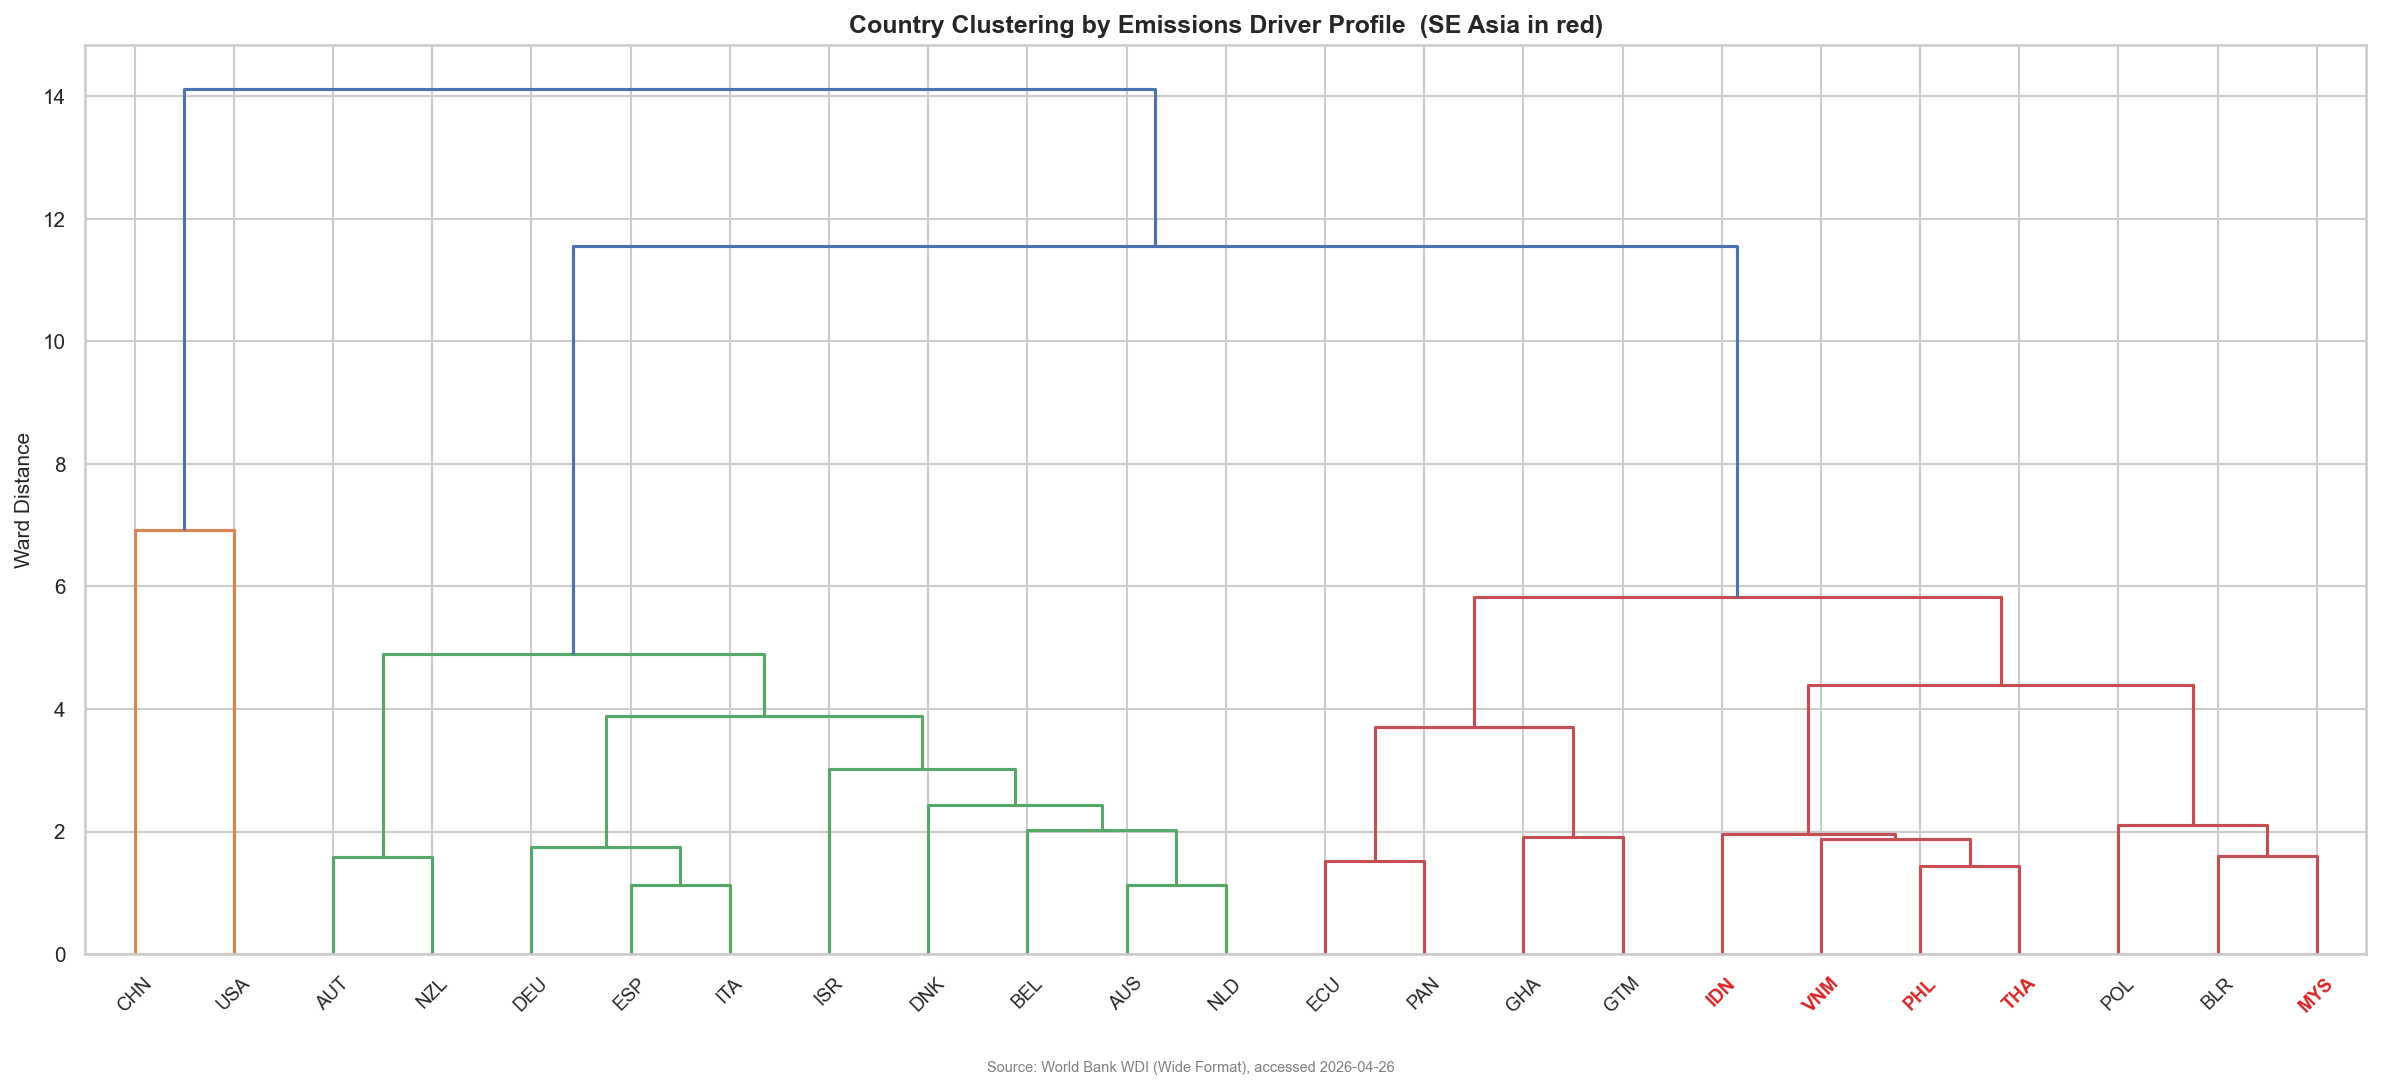


=== 5-Cluster Summary ===
  Cluster 1: 2 countries  |  SE Asia: none
  Cluster 2: 29 countries  |  SE Asia: none
  Cluster 3: 33 countries  |  SE Asia: ['IDN', 'PHL', 'THA', 'VNM']
  Cluster 4: 25 countries  |  SE Asia: none
  Cluster 5: 41 countries  |  SE Asia: ['MYS']


In [35]:
# Hierarchical clustering on standardised country-mean predictor profiles
Country_Profiles = Data_Df.groupby('Ref_Area')[Pred_Cols].mean().dropna()
if 'Population' in Country_Profiles.columns:
    Country_Profiles['Population'] = np.log(Country_Profiles['Population'].clip(lower=1))

Profiles_Std = (Country_Profiles - Country_Profiles.mean()) / Country_Profiles.std()
K = 5
Cluster_Labels = fcluster(linkage(Profiles_Std.values, method='ward'), K, criterion='maxclust')
Country_Profiles['cluster'] = Cluster_Labels

# Display set: SE Asia + cluster medoids + nearest peers
Sea_Focus  = ['THA', 'PHL', 'MYS', 'IDN', 'VNM']
Sea_In_Data = [c for c in Sea_Focus if c in Profiles_Std.index]

Medoids = []
for c in sorted(Country_Profiles.cluster.unique()):
    members_std = Profiles_Std.loc[Country_Profiles[Country_Profiles.cluster == c].index]
    centroid    = members_std.mean().values.reshape(1, -1)
    dists       = cdist(members_std.values, centroid, metric='euclidean').flatten()
    Medoids.append(members_std.index[np.argmin(dists)])

Display_Countries = set(Sea_In_Data + Medoids)
for c in sorted(Country_Profiles.cluster.unique()):
    members_std = Profiles_Std.loc[Country_Profiles[Country_Profiles.cluster == c].index]
    centroid    = members_std.mean().values.reshape(1, -1)
    dists       = cdist(members_std.values, centroid, metric='euclidean').flatten()
    for r in members_std.index[np.argsort(dists)]:
        if r not in Display_Countries:
            Display_Countries.add(r)
            if len(Display_Countries) - len(set(Sea_In_Data + Medoids)) >= 2 * K:
                break

Display_Countries = sorted(Display_Countries)

# Dendrogram with SE Asia highlighted in red
Z_Sub = linkage(Profiles_Std.loc[Display_Countries].values, method='ward')
fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(Z_Sub, labels=Display_Countries, ax=ax, leaf_rotation=45, leaf_font_size=9,
           color_threshold=0.7 * max(Z_Sub[:, 2]))

for lbl in ax.get_xticklabels():
    if lbl.get_text() in Sea_In_Data:
        lbl.set_color('#d62728')
        lbl.set_fontweight('bold')

ax.set_title(f'Country Clustering by Emissions Driver Profile  (SE Asia in red)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Ward Distance', fontsize=10)
plt.figtext(0.5, -0.03, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
plt.show()

# Cluster membership summary
print(f'\n=== {K}-Cluster Summary ===')
for c in sorted(Country_Profiles.cluster.unique()):
    members = Country_Profiles[Country_Profiles.cluster == c].index.tolist()
    sea_mem = [m for m in members if m in Sea_In_Data]
    print(f'  Cluster {c}: {len(members)} countries  |  SE Asia: {sea_mem if sea_mem else "none"}')

In [36]:
# Delete used once df/list
del WDI_Data, Ghg_Components, Ghg_Frames, Ghg_Agg, Stack_Cols
del GHG_Data
del Outlier_Records, Outliers
del Country_Profiles, Profiles_Std, Cluster_Labels, Medoids, Display_Countries, Z_Sub, Sea_Focus, Sea_In_Data, K
del Shortlist_Rows, Target_Row, Vif_Cols, Shortlist
del Audit
del N_Stirpat
del Trend_Datas, Trend_Codes, Ghg_Wide_Lvl
del Last_Yr, Total_Last, Co2_Share, Ch4_Share, N2o_Share, Other_Share
del Sea_Names, Pop_Long, Pc_Df, Ref_World, Ref_Hic, Ref_Umc, Sea_Pal, Hic_2023, Umc_2023
del Ekc_Df, Slopes, Group_Pal, Group_Name, Group_Order, slope_text, Slope_Lic_Lmc, Slope_Hic
del Lowess_Notes
del Hic_In_Data, Umc_In_Data, Ghg_Hic_Med, Ghg_Umc_Med
del Data_Group_Counts, LAST_REAL_YEAR

## Step 6: Pre-Modelling Checks and Export

Three checks before saving the final dataset:

1. **Shape check** — confirm the data has the expected number of rows, columns, and completeness levels.
2. **Stationarity test** — check whether GHG emissions follow a trending pattern (going consistently up or down) or fluctuate around a stable level. Most countries show trending emissions, which is expected. Our fixed-effects model handles this by looking at deviations from each country's mean.
3. **Correlation consistency** — re-run within-country correlations on the final imputed data to make sure they match what we found during screening. This is a sanity check.

Then save `WS1_Data_Imputed.csv` for WS2 modelling.

In [37]:
# Check 1: data dimensions and post-imputation completeness
print('=' * 72)
print('PRE-MODELLING SUMMARY')
print('=' * 72)
print(f'Data: {Data_Df.Ref_Area.nunique()} countries × {Data_Df.year.nunique()} years')
print(f'Actual rows: {len(Data_Df)}')
print(f'Variables: {Target_Col} + {len(Pred_Cols)} predictors + COVID dummy')
print(f'Columns: {list(Data_Df.columns)}')

print('\nCompleteness (post-imputation):')
for col in All_Cols:
    if col in Data_Df.columns:
        pct = Data_Df[col].notna().mean() * 100
        print(f'  {col:20s}: {pct:.1f}%')

PRE-MODELLING SUMMARY
Data: 130 countries × 25 years
Actual rows: 3250
Variables: Total_GHG + 14 predictors + COVID dummy
Columns: ['Ref_Area', 'year', 'Total_GHG', 'Energy_Per_Capita', 'Elec_Per_Capita', 'Renewable_%', 'Fossil_Elec_%', 'Renew_Elec_%', 'GDP_Total', 'GDP_Per_Capita', 'GDP_Per_Capita_PPP', 'Population', 'Urban_%', 'Industry_VA_%', 'Agri_VA_%', 'Forest_%', 'Agri_Land_%', 'COVID']

Completeness (post-imputation):
  Total_GHG           : 100.0%
  Energy_Per_Capita   : 100.0%
  Elec_Per_Capita     : 100.0%
  Renewable_%         : 100.0%
  Fossil_Elec_%       : 100.0%
  Renew_Elec_%        : 99.5%
  GDP_Total           : 100.0%
  GDP_Per_Capita      : 100.0%
  GDP_Per_Capita_PPP  : 100.0%
  Population          : 100.0%
  Urban_%             : 100.0%
  Industry_VA_%       : 98.5%
  Agri_VA_%           : 99.1%
  Forest_%            : 100.0%
  Agri_Land_%         : 100.0%


In [38]:
# Check 2: ADF stationarity test on log(Total GHG) per country
print('\n--- Stationarity: ADF test on log(Total GHG) per country ---')
Adf_Results = []
for country in sorted(Data_Df.Ref_Area.unique()):
    series = Data_Df[Data_Df.Ref_Area == country][Target_Col].dropna()
    if len(series) < 8:
        continue
    try:
        adf_stat, p_val, *_ = adfuller(np.log(series.clip(lower=1e-9)), maxlag=4, autolag='AIC')
        Adf_Results.append({'country': country, 'adf_stat': adf_stat,
                            'p_value': p_val, 'stationary': 'Yes' if p_val < 0.05 else 'No'})
    except Exception:
        pass

Adf_Df = pd.DataFrame(Adf_Results)
N_Stat    = (Adf_Df.stationary == 'Yes').sum()
N_Nonstat = (Adf_Df.stationary == 'No').sum()
print(f'  Stationary (p < 0.05): {N_Stat}/{len(Adf_Df)}')
print(f'  Non-stationary:        {N_Nonstat}/{len(Adf_Df)}')
print(f'  Note: Non-stationarity expected (trending emissions). FE handles via demeaning.')

del Adf_Results, Adf_Df, N_Stat, N_Nonstat


--- Stationarity: ADF test on log(Total GHG) per country ---
  Stationary (p < 0.05): 9/130
  Non-stationary:        121/130
  Note: Non-stationarity expected (trending emissions). FE handles via demeaning.


In [39]:
# Check 3: within-country correlations on final imputed data (consistency check)
Data_CORR = Data_Df[['Ref_Area', 'year'] + All_Cols].copy()
for col in All_Cols:
    code_match = [c for c, sn in Short.items() if sn == col]
    if code_match and code_match[0] in Log_Vars and col in Data_CORR.columns:
        Data_CORR[col] = np.log(Data_CORR[col].clip(lower=1e-9))

Numeric_Check = [c for c in All_Cols if c in Data_CORR.columns]
Demeaned_Check = Data_CORR.groupby('Ref_Area')[Numeric_Check].transform(lambda x: x - x.mean())
Within_Corr    = Demeaned_Check.corr()[Target_Col].drop(Target_Col).sort_values(key=abs, ascending=False)

print('\nWithin-country correlations (imputed data):')
print(Within_Corr.round(4).to_string())
print('\n(Compare with screening — should be directionally consistent)')

del Data_CORR, Demeaned_Check, Numeric_Check, Within_Corr


Within-country correlations (imputed data):
Energy_Per_Capita     0.6733
Elec_Per_Capita       0.6513
GDP_Total             0.6436
Population            0.6322
GDP_Per_Capita_PPP    0.5931
GDP_Per_Capita        0.5748
Renewable_%          -0.5505
Urban_%               0.4378
Agri_VA_%            -0.4095
Forest_%             -0.3404
Agri_Land_%           0.2458
Fossil_Elec_%         0.2330
Renew_Elec_%         -0.2178
Industry_VA_%         0.1396

(Compare with screening — should be directionally consistent)


In [40]:
# Rename columns for CSV output
Data_Df = Data_Df.rename(columns={'year': 'Year', 'COVID': 'Covid'})

# Save final data for WS2
Data_Df.to_csv(Data_Path / 'WS1_Data_Imputed.csv', index=False)
print(f'Saved: {Data_Path / "WS1_Data_Imputed.csv"}')
print(f'  Shape: {Data_Df.shape}')
print(f'\nREADY FOR WS2.')

Saved: /Users/entong/Desktop/MASAHKT2026/Model/Data/WS1_Data_Imputed.csv
  Shape: (3250, 18)

READY FOR WS2.


## WS1 Complete, can handoff to WS2

The imputed data (`WS1_Data_Imputed.csv`) is ready for modelling:

- One row per country-year (135 countries × 25 years)
- **Target:** Total GHG excl LULUCF (Mt CO₂e). <never imputed
- **7 predictors:** Population, GDP/cap PPP, Energy/cap, Renewable%, Forest%, Agri VA%, Urban%
- **COVID dummy:** 2020=1, 2021=1, else 0
- **Imputation:** linear interpolation (≤2-yr gaps) + forward fill (≤2-yr trailing)

**WS2 should:**
1. Log-transform level variables (Population, GDP/cap PPP, Energy/cap) and the target
2. Estimate fixed-effects data regression as the primary model
3. Exclude 2020–2021 from training (use the COVID dummy or drop entirely)
4. Validate on 2019 + 2022–2023, predict 2024

# Workstream 2: Predictive Modelling

**Target:** Total GHG excl LULUCF (Mt CO₂e)
<br> **Data:** 135 countries × 25 years (2000–2024), from WS1
<br> **Primary model:** Fixed-effects data regression (manual demeaning + OLS)
<br> **Comparison model:** XGBoost (gradient boosting)
<br> **Prediction year:** 2024
<br> **Output:** Coefficient table, validation metrics, 2024 predictions (for WS4 & dashboard)

| Step | What | Output |
|------|------|--------|
| **1 Data Preparation** | (A) Load WS1 data CSV; <br>(B) Log-transform level variables; <br>(C) Split into Train / Valid / Pred sets | `Train`, `Valid`, `Pred` |
| **2 Fixed-Effects Regression** | (A) Country means from training; <br>(B) Demean and fit OLS; <br>(C) Sanity check training R² | `Coef_Df`, `OLS` model |
| **3 Model Diagnostics** | (A) Validation metrics; <br>(B) Residual plots; <br>(C) Breusch–Pagan heteroscedasticity; <br>(D) Hausman test (FE vs RE) | Diagnostic charts + test results |
| **4 XGBoost & Model Comparison** | (A) Fit XGBoost; <br>(B) Side-by-side metrics; <br>(C) Feature importance; <br>(D) Actual vs predicted scatter | Comparison table |
| **5 2024 Prediction** | (A) Predict 2024 (both models); <br>(B) SE Asia focus table + bar chart; <br>(C) 95% confidence interval | `Results` table |
| **6 Export** | Save coefficients, metrics, predictions, country means for WS4 & dashboard | Export CSVs to Data_Path |

## Setup
* Import libraries
* Define constants: 
<br> (i) Target, (ii) Predictors, (iii) Log-transform list, (iv) SE Asia countries

In [41]:
try:
    import linearmodels
except ImportError:
    !pip install linearmodels -q

# Other libraries come with Anaconda, only this one needs to be installed separately

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.diagnostic import het_breuschpagan
from linearmodels import PanelOLS, RandomEffects
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif'})
sns.set_theme(style='whitegrid', font_scale=0.9)

# Column names matching WS1 output CSV
Target    = 'Total_GHG'
Pred_Cols = ['Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Capita',
             'Renewable_%', 'Urban_%', 'Forest_%', 'Agri_VA_%']

# Level variables → log; 
# Percentages → stay in levels
Log_Vars = [Target, 'Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Capita']


SE_Asia = ['BRN', 'KHM', 'IDN', 'LAO', 'MYS', 'MMR', 'PHL', 'SGP', 'THA', 'TLS', 'VNM']

print('Setup complete.')

Setup complete.


## Helper Functions

- **`Calc_Metrics`**
<br> Computes RMSE, MAE, R², MAPE for log-scale predictions. 
<br> MAPE is on original scale (exponentiated) for interpretability.

- **`FE_Predict`** 
<br> Predicts ln(GHG) using the FE model formula: 
   > ŷᵢₜ = ȳᵢ(train) + β̂ · (Xᵢₜ − X̄ᵢ(train)). 

     Falls back to global mean for countries not in training.

In [43]:
def Calc_Metrics(actual, predicted, label=''):
    """Compute RMSE, MAE, R², MAPE for log-scale predictions."""
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = actual[mask], predicted[mask]
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    r2   = r2_score(a, p)
    mape = np.mean(np.abs((np.exp(a) - np.exp(p)) / np.exp(a))) * 100
    if label:
        print(f'{label}')
        print(f'  RMSE (log scale):  {rmse:.4f}')
        print(f'  MAE  (log scale):  {mae:.4f}')
        print(f'  R²:                {r2:.4f}')
        print(f'  MAPE (orig scale): {mape:.1f}%')
    return {'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'R2': round(r2, 4), 'MAPE': round(mape, 1)}


def FE_Predict(data, coefs, country_means_y, country_means_X, x_cols):
    """Predict ln(GHG) using FE model. Falls back to global mean for unseen countries."""
    predictions = np.full(len(data), np.nan)
    global_mean_y = country_means_y.mean()
    global_mean_X = country_means_X.mean()

    for idx, (_, row) in enumerate(data.iterrows()):
        country = row['Ref_Area']
        x_vals  = row[x_cols].values.astype(float)

        if country in country_means_y.index:
            y_bar = country_means_y[country]
            x_bar = country_means_X.loc[country].values
        else:
            y_bar = global_mean_y
            x_bar = global_mean_X.values

        predictions[idx] = y_bar + coefs @ (x_vals - x_bar)

    return predictions


print('Helpers ready.')

Helpers ready.


## Step 1: Data Preparation

### Step 1(A) Load Data
Read the imputed data from WS1. 

In [44]:
# (A) Load WS1 output: WS1_Data_Imputed.csv
Data = pd.read_csv(Data_Path / Data_Filename)

# Verify handoff
for col in [Target] + Pred_Cols:
    assert col in Data.columns, f'Missing column: {col}'

print(f'Data:   {Data.Ref_Area.nunique()} countries × {Data.Year.nunique()} years')
print(f'Rows:    {len(Data)}')
print(f'Years:   {Data.Year.min()}–{Data.Year.max()}')
print(f'SE Asia: {all(c in Data.Ref_Area.values for c in SE_Asia)}')
print(f'Columns: {list(Data.columns)}')

Data:   130 countries × 25 years
Rows:    3250
Years:   2000–2024
SE Asia: False
Columns: ['Ref_Area', 'Year', 'Total_GHG', 'Energy_Per_Capita', 'Elec_Per_Capita', 'Renewable_%', 'Fossil_Elec_%', 'Renew_Elec_%', 'GDP_Total', 'GDP_Per_Capita', 'GDP_Per_Capita_PPP', 'Population', 'Urban_%', 'Industry_VA_%', 'Agri_VA_%', 'Forest_%', 'Agri_Land_%', 'Covid']


### Step 1(B) Log-transform
1. **Level variables** are log-transformed per STIRPAT specification. 
    * This makes the relationship approximately linear and coefficients interpretable as elasticities. 

      > Predictor: Population, GDP_Per_Capita_PPP, Energy_Per_Capita
      >> Target   : Total_GHG

2. **Percentage variables** stay in levels. 

    * Their coefficients are semi-elasticities.
      > Predictor: Renewable_%', 'Urban_%', 'Forest_%', 'Agri_VA_%'

In [45]:
# Log-transform level variables, Keep percentages in levels

# Model data
# - Add ln_ columns to logged variables
for col in Log_Vars:
    Data[f'ln_{col}'] = np.log(Data[col].replace(0, np.nan))

# Model column names 
# - ln_ prefix for logged variables
Target    = f'ln_{Target}'
Pred_Cols = [f'ln_{col}' if col in Log_Vars else col for col in Pred_Cols]

print(f'Target:     {Target}')
print(f'Predictors: {Pred_Cols}')

Target:     ln_Total_GHG
Predictors: ['ln_Population', 'ln_GDP_Per_Capita_PPP', 'ln_Energy_Per_Capita', 'Renewable_%', 'Urban_%', 'Forest_%', 'Agri_VA_%']


### Step 1(C) Split Data

| Set | Years | Purpose |
|---|---|---|
| Train | 2000–2018 | Model estimation |
| Validation | 2019, 2022, 2023 | Out-of-sample evaluation |
| Prediction | 2024 | Forecast: Compare predicted vs actual |

<br>

> 2020–2021 excluded entirely (pandemic distortion).

   * The emission drop reflects economic shutdown, not climate dynamics. 

<br>

> Indicator selection, VIF screening, and stationarity tests were completed in WS1. 

This step starts from the cleaned, validated predictor set.

In [46]:
Model_Vars  = [Target] + Pred_Cols
Data_Complete = Data.dropna(subset = Model_Vars)
Data_Model    = Data_Complete[~Data_Complete.Year.isin([2020, 2021])]

Train = Data_Model[Data_Model.Year <= 2018].copy()
Valid   = Data_Model[Data_Model.Year.isin([2019, 2022, 2023])].copy()
Pred  = Data_Model[Data_Model.Year == 2024].copy()

print(f'Complete (excl Covid): {len(Data_Model)} rows')
print(f'')
print(f'Train: {len(Train)} ({Train.Year.min()}–{Train.Year.max()}, {Train.Ref_Area.nunique()} countries)')
print(f'Val:   {len(Valid)}  (Years: {sorted(Valid.Year.unique())})')
print(f'Pred:  {len(Pred)}  (2024, {Pred.Ref_Area.nunique()} countries)')

Complete (excl Covid): 2962 rows

Train: 2442 (2000–2018, 130 countries)
Val:   390  (Years: [2019, 2022, 2023])
Pred:  130  (2024, 130 countries)


## Step 2: Fixed-Effects Data Regression

**Fixed effects** gives each country its own intercept (αᵢ), absorbing time-invariant characteristics like *geography and institutions*. 

The coefficients then capture **within-country** changes only.
* e.g. how Thailand's GHG moves when Thailand's renewable share increases.

**Implementation:** Equivalent to OLS on country-demeaned data.
* Step 2(A) For each variable, subtract the country's training-set mean
* Step 2(B) Run OLS without intercept (demeaning removes it)
* Step 2(C) Verify training R² is close to 1.0 as a sanity check

**Prediction formula:**
<br> ŷᵢₜ = ȳᵢ(train) + β̂ · (Xᵢₜ − X̄ᵢ(train))

Country means are fixed from training, so the formula works for any year. 
<br> including out-of-sample validation and 2024 prediction.

**How to read the coefficients:**
1. **Log–log** 
<br> Variables (Population, GDP/cap, Energy/cap): **elasticities**. 
<br> e.g. coefficient 0.69 on ln(Population) means a 1% increase in population → 0.69% increase in GHG.
2. **Level–log** 
<br> Variables (Renewable%, Urban%, Forest%, Agri VA%): **semi-elasticities**. 
<br> e.g. coefficient −0.011 on Renewable% means a 1 percentage-point increase in renewables → 1.1% decrease in GHG.

### Step 2(A) Country Means from Training Set

In [47]:
Country_Means_y = Train.groupby('Ref_Area')[Target].mean()
Country_Means_X = Train.groupby('Ref_Area')[Pred_Cols].mean()

print(f'Country means computed from {len(Train)} training observations')
print(f'Countries: {len(Country_Means_y)}')

Country means computed from 2442 training observations
Countries: 130


### Step 2(B) Demean and Fit 

Demeaning removes each country's average from every variable, so OLS estimates only within-country variation. 
<br> No intercept is needed, demeaning already centres the data at zero.

Standard errors are adjusted for degrees of freedom lost to the absorbed country fixed effects (N − K − N_countries).

In [48]:
Train_Demeaned = Train.copy()
Train_Demeaned[Target] = Train[Target] - Train['Ref_Area'].map(Country_Means_y)
for col in Pred_Cols:
    Train_Demeaned[col] = Train[col] - Train['Ref_Area'].map(Country_Means_X[col])

# OLS on demeaned data, no intercept (demeaning removes it)
OLS = LinearRegression(fit_intercept=False)
OLS.fit(Train_Demeaned[Pred_Cols].values, Train_Demeaned[Target].values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 2(C) Training Sanity Check

Overall R² (including country intercepts) should be close to 1.0. 
<br> If not, something went wrong in demeaning or fitting.

In [49]:
# Standard errors & coefficient table 
# SE = sqrt(diag(σ² · (X'X)⁻¹))
# DoF adjusted for absorbed country fixed effects
X_Mat = Train_Demeaned[Pred_Cols].values
y_Vec = Train_Demeaned[Target].values
Resid = y_Vec - X_Mat @ OLS.coef_

n, k        = X_Mat.shape
n_countries = Train.Ref_Area.nunique()
dof         = n - k - n_countries
sigma2      = np.sum(Resid**2) / dof
XtX_inv     = np.linalg.inv(X_Mat.T @ X_Mat)
se          = np.sqrt(np.diag(sigma2 * XtX_inv))

coef_df = pd.DataFrame({
    'Variable':    Pred_Cols,
    'Coefficient': OLS.coef_.round(4),
    'Std Error':   se.round(4),
})
coef_df['t-stat']  = (coef_df['Coefficient'] / coef_df['Std Error']).round(2)
coef_df['p-value'] = [2 * (1 - stats.t.cdf(abs(t), dof)) for t in coef_df['t-stat']]
coef_df['Sig']     = coef_df['p-value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# Within R²
ss_res    = np.sum(Resid**2)
ss_tot    = np.sum((y_Vec - y_Vec.mean())**2)
within_r2 = 1 - ss_res / ss_tot

print('=' * 72)
print('   Fixed-Effects Data Regression — Coefficients')
print('=' * 72)
print(coef_df.to_string(index=False))
print(f'\nWithin R²:    {within_r2:.4f}')
print(f'Observations: {n}')
print(f'Countries:    {n_countries}')
print(f'Residual SE:  {np.sqrt(sigma2):.4f}')

   Fixed-Effects Data Regression — Coefficients
             Variable  Coefficient  Std Error  t-stat      p-value Sig
        ln_Population       0.6934     0.0199   34.84 0.000000e+00 ***
ln_GDP_Per_Capita_PPP       0.2275     0.0124   18.35 0.000000e+00 ***
 ln_Energy_Per_Capita       0.4547     0.0147   30.93 0.000000e+00 ***
          Renewable_%      -0.0105     0.0004  -26.25 0.000000e+00 ***
              Urban_%      -0.0045     0.0007   -6.43 1.546159e-10 ***
             Forest_%      -0.0012     0.0017   -0.71 4.777760e-01    
            Agri_VA_%       0.0017     0.0008    2.12 3.411262e-02   *

Within R²:    0.7867
Observations: 2442
Countries:    130
Residual SE:  0.0773


In [50]:
# Quick sanity check: FE predictions on training data
Train_Pred = FE_Predict(Train, OLS.coef_, Country_Means_y, Country_Means_X, Pred_Cols)
Train_R2   = r2_score(Train[Target].values, Train_Pred)
print(f'Training R² (Overall, incl. country intercepts): {Train_R2:.4f}')

Training R² (Overall, incl. country intercepts): 0.9978


## Step 3: Model Diagnostics

Four checks to confirm the FE model is valid.

* Step 3(A) **Validation metrics**
<br>  - Out-of-sample test on 2019, 2022, 2023 (RMSE, MAE, R², MAPE).

* Step 3(B) **Residual plots** 
<br> - Histogram
<br> - Residuals vs fitted
<br> - Q-Q plot

* Step 3(C) **Breusch–Pagan**
<br> - Formal heteroscedasticity test. 

* Step 3(D) **Hausman test**
<br> - Confirms FE is the correct specification over random effects. 
<br> - *Uses clustered SE because 3(C) found heteroscedasticity.*


### Step 3(A) Validation Metrics

**Out-of-sample test** on years the model has never seen. 
<br> *Predict on test (2019, 2022, 2023) using country means from training (2000–2018).*

Country means are fixed from training (2000–2018), so the model can only succeed if the structural relationships generalise forward.

> **RMSE / MAE:** Prediction error in log scale (lower = better).
<br>**R²:** Proportion of variance explained (closer to 1 = better).
<br>**MAPE:** Average percentage error in original scale (most interpretable for the report).

In [51]:
Valid['FE_Pred']  = FE_Predict(Valid, OLS.coef_, Country_Means_y, Country_Means_X, Pred_Cols)
Valid['FE_Resid'] = Valid[Target] - Valid['FE_Pred']

print('=' * 72)
print('   FE Data Regression — Out-of-Sample Validation')
print('=' * 72)
FE_Val_Metrics = Calc_Metrics(Valid[Target].values, Valid['FE_Pred'].values,
                              'Validation (2019, 2022, 2023)')

   FE Data Regression — Out-of-Sample Validation
Validation (2019, 2022, 2023)
  RMSE (log scale):  0.1268
  MAE  (log scale):  0.0984
  R²:                0.9936
  MAPE (orig scale): 10.2%


### Step 3(B) Residual Plots

Three visual checks on the validation residuals:
1. **Histogram**
    <br> Should be symmetric around zero. 
    <br> Skew means systematic over/under-prediction.

2. **Residuals vs Fitted** 
    <br> Should show random scatter. 
    <br> A fan shape means variance grows with predicted values (heteroscedasticity).

3. **Q-Q Plot** 
    <br> Points on the diagonal mean residuals are normally distributed. 
    <br> Tail deviations mean some countries are harder to predict.

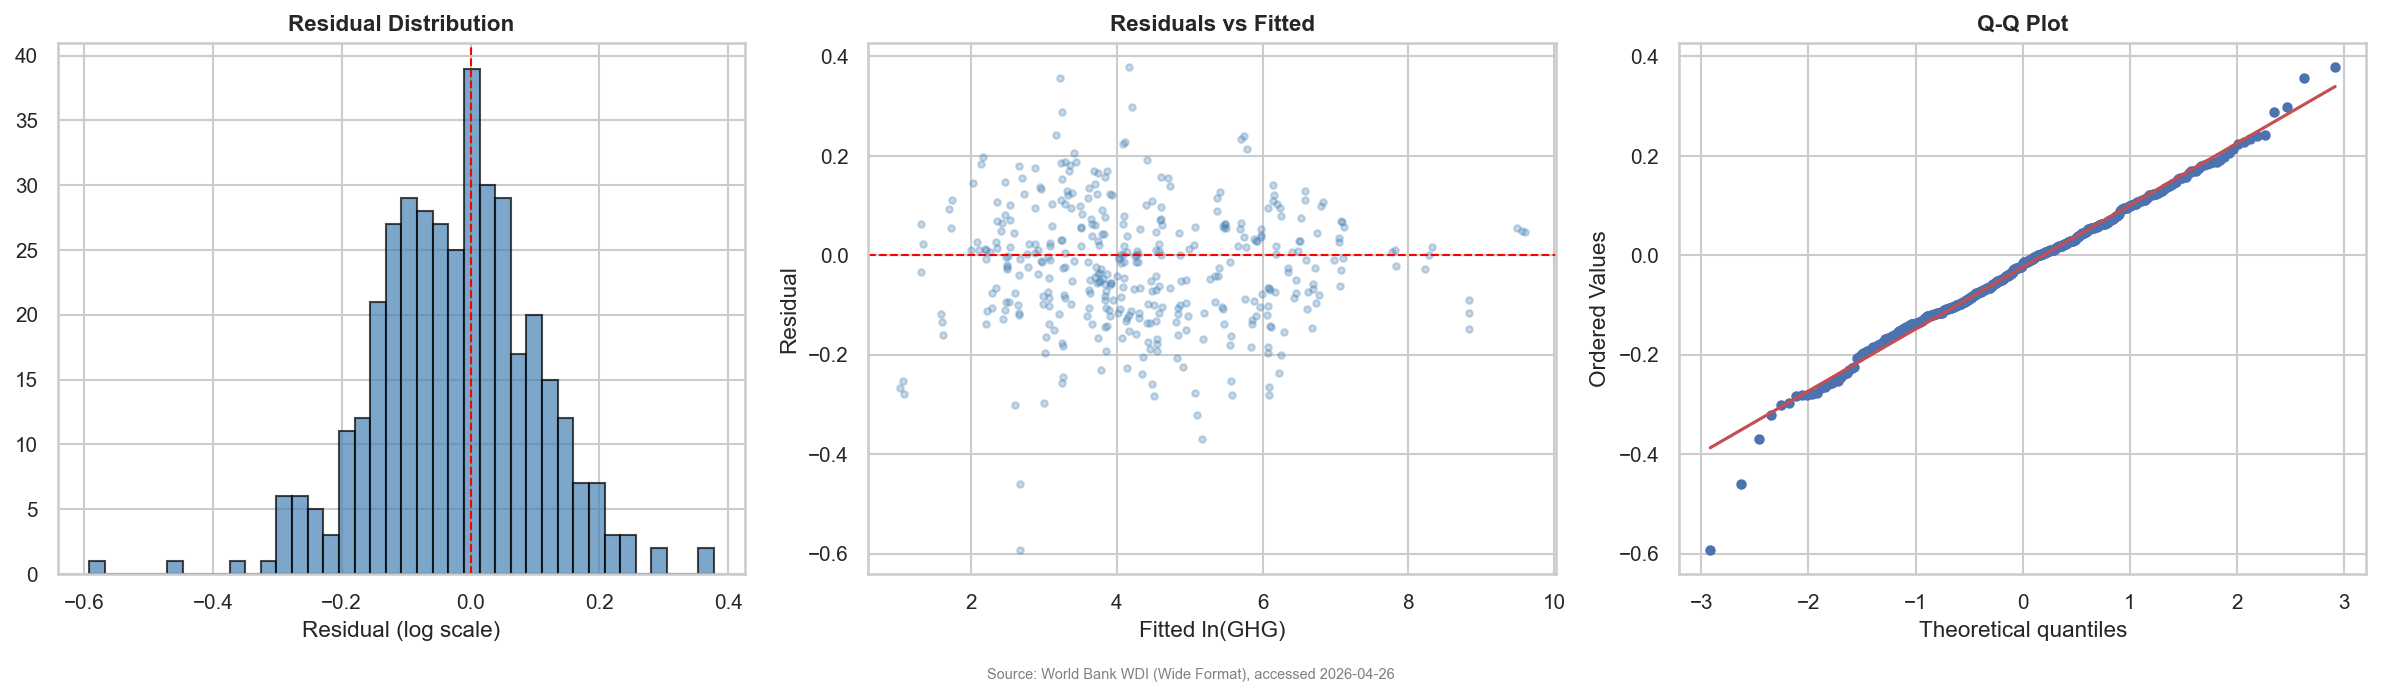

Saved: WS2_Residual_Diagnostics.png


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Histogram
axes[0].hist(Valid['FE_Resid'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual (log scale)')

# Residuals vs fitted
axes[1].scatter(Valid['FE_Pred'], Valid['FE_Resid'], alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Residuals vs Fitted', fontweight='bold')
axes[1].set_xlabel('Fitted ln(GHG)')
axes[1].set_ylabel('Residual')

# Q-Q plot
stats.probplot(Valid['FE_Resid'].dropna(), dist='norm', plot=axes[2])
axes[2].get_lines()[0].set_markersize(4)
axes[2].set_title('Q-Q Plot', fontweight='bold')

plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS2 / 'WS2_Residual_Diagnostics.png', bbox_inches='tight', dpi=180)
plt.show()
print('Saved: WS2_Residual_Diagnostics.png')

### Step 3(C) Breusch–Pagan Heteroscedasticity Test

Tests whether residual variance is constant across fitted values.
> **H₀:** Residual variance is constant (homoscedastic).
<br> **H₁:** Residual variance depends on predictors (heteroscedastic).

    If p < 0.05, standard errors from Step 2 may be slightly understated. 
   
If detected, Step 3(D) Hausman test will use clustered standard errors as mitigation.
<br> If not detected, standard errors from Step 2 are reliable.

In [53]:
# Add constant column (BP test requires it)
X_Mat_const = add_constant(X_Mat)

# Run on training residuals (where we have the full demeaned X matrix)
BP_Stat, BP_p, BP_F, BP_Fp = het_breuschpagan(Resid, X_Mat_const)

print('=' * 60)
print('   Breusch–Pagan Test (training residuals)')
print('=' * 60)
print(f'  LM statistic:  {BP_Stat:.2f}')
print(f'  LM p-value:    {BP_p:.6f}')
print(f'  F-statistic:   {BP_F:.2f}')
print(f'  F p-value:     {BP_Fp:.6f}')
if BP_p < 0.05:
    print(f'\n  Result: Heteroscedasticity detected (p < 0.05).')
    print(f'  → Standard errors from Step 2 may be slightly understated.')
    print(f'  → Step 3(D) Hausman test will use clustered SE as mitigation.')
else:
    print(f'\n  Result: No heteroscedasticity detected (p = {BP_p:.3f}).')
    print(f'  → Standard errors from Step 2 are reliable.')

   Breusch–Pagan Test (training residuals)
  LM statistic:  60.91
  LM p-value:    0.000000
  F-statistic:   8.89
  F p-value:     0.000000

  Result: Heteroscedasticity detected (p < 0.05).
  → Standard errors from Step 2 may be slightly understated.
  → Step 3(D) Hausman test will use clustered SE as mitigation.


### Step 3(D) Hausman Test (FE vs RE)

Clustered standard errors are used because Breusch–Pagan in Step 3(C) detected heteroscedasticity.

This test compares two data regression specifications:
* **Fixed Effects (FE):** 
  * Each country gets its own intercept. 
  * Always consistent, but less efficient.

* **Random Effects (RE):** 
  * Assumes country effects are random draws, uncorrelated with predictors.
  * More efficient if the assumption holds, but biased if it does not.

> **H₀:** Country effects are uncorrelated with predictors (RE is valid).
<br>**H₁:** Country effects are correlated with predictors (only FE is consistent).

     If p < 0.05, reject H₀ and use FE. 

*We expect rejection because country characteristics (geography, resource endowments) are inherently linked to predictors like GDP, energy use, and urbanisation.*

In [54]:
Train_Data = Train.set_index(['Ref_Area', 'Year'])

# FE with clustered standard errors (robust to heteroscedasticity)
FE_lm = PanelOLS(
    dependent=Train_Data[Target], exog=Train_Data[Pred_Cols],
    entity_effects=True, check_rank=False
).fit(cov_type='clustered', cluster_entity=True)

RE_lm = RandomEffects(
    dependent=Train_Data[Target], exog=Train_Data[Pred_Cols]
).fit()

# Hausman statistic: H = (b_FE - b_RE)' (V_FE - V_RE)^{-1} (b_FE - b_RE)
b_diff = FE_lm.params - RE_lm.params
v_diff = FE_lm.cov - RE_lm.cov
H = float(b_diff.values @ np.linalg.inv(v_diff.values) @ b_diff.values)
p = 1 - stats.chi2.cdf(H, df=len(b_diff))

print('=' * 60)
print('  Hausman Test: Fixed Effects vs Random Effects')
print('=' * 60)
print(f'  Chi² statistic: {H:.2f}')
print(f'  p-value:        {p:.6f}')
print(f'  DoF:            {len(b_diff)}')
print(f'\n  {"Reject H0 → FE preferred" if p < 0.05 else "Cannot reject H0"}')

  Hausman Test: Fixed Effects vs Random Effects
  Chi² statistic: 94.85
  p-value:        0.000000
  DoF:            7

  Reject H0 → FE preferred


## Step 4: XGBoost & Model Comparison

XGBoost (gradient-boosted trees) is fitted as a comparison model
* To test whether non-linear patterns exist that the linear FE model misses.

**Country identity** is encoded as each country's training-set mean of ln(GHG) (target mean-encoding). This give XGBoost a comparable "country baseline" to the fixed effects.

* Step 4(A) **Fit XGBoost**
<br>  - Train and validate on the same splits as FE.

* Step 4(B) **Side-by-side metrics** 
<br>  - Compare RMSE, MAE, R², MAPE.

* Step 4(C) **Feature importance** 
<br>  - Which inputs does XGBoost rely on most.

* Step 4(D) **Actual vs predicted** 
<br>  - Visual comparison of both models. 

<br> 
Even if XGBoost wins on metrics, FE remains the primary model because:

1. **WS4 needs coefficients**
<br>  - Stress testing requires Δln(GHG) = β × ΔX. 
<br>  - Tree models cannot isolate single-variable effects.
2. **Interpretability** 
<br>  - Coefficients are elasticities, directly communicable to a reinsurance board.
3. **Hausman confirms FE.** 
<br>  - XGBoost feature importance typically shows country encoding dominates. 
<br>  - *Memorising averages, not learning structural relationships.*


### Step 4(A) Fit XGBoost

Target mean-encoding: 
* Each country gets its training-set mean of ln(GHG) as an additional feature. 
* Countries not in training fall back to the global mean.

In [55]:
# Country mean-encoding
Country_Enc_Map = Train.groupby('Ref_Area')[Target].mean()
Global_Enc      = Country_Enc_Map.mean()

Data_Model = Data_Model.copy()
Data_Model['Country_Enc'] = Data_Model['Ref_Area'].map(Country_Enc_Map).fillna(Global_Enc)

XGB_Features = Pred_Cols + ['Country_Enc']

Train_X = Data_Model[Data_Model.Year <= 2018]
Valid_X = Data_Model[Data_Model.Year.isin([2019, 2022, 2023])]
Pred_X  = Data_Model[Data_Model.Year == 2024]

# Fit
XGB_Model = GradientBoostingRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=10, random_state=42
)
XGB_Model.fit(Train_X[XGB_Features].values, Train_X[Target].values)

# Validate
Valid_X = Valid_X.copy()
Valid_X['XGB_Pred'] = XGB_Model.predict(Valid_X[XGB_Features].values)

print('=' * 72)
print('   XGBoost — Validation')
print('=' * 72)
XGB_Val_Metrics = Calc_Metrics(Valid_X[Target].values, Valid_X['XGB_Pred'].values,
                               'Validation (2019, 2022, 2023)')

   XGBoost — Validation
Validation (2019, 2022, 2023)
  RMSE (log scale):  0.1772
  MAE  (log scale):  0.1386
  R²:                0.9874
  MAPE (orig scale): 13.4%


### Step 4(B) Side-by-Side Metrics

In [56]:
Comp_Table = pd.DataFrame({
    'Metric': ['RMSE (log)', 'MAE (log)', 'R²', 'MAPE (%)'],
    'FE Data Regression': [FE_Val_Metrics['RMSE'], FE_Val_Metrics['MAE'],
                            FE_Val_Metrics['R2'], FE_Val_Metrics['MAPE']],
    'XGBoost': [XGB_Val_Metrics['RMSE'], XGB_Val_Metrics['MAE'],
                XGB_Val_Metrics['R2'], XGB_Val_Metrics['MAPE']],
}).round(4)

Comp_Table['Winner'] = Comp_Table.apply(
    lambda row: 'FE' if (row['Metric'] in ['RMSE (log)', 'MAE (log)', 'MAPE (%)']
                         and row['FE Data Regression'] <= row['XGBoost'])
                     or (row['Metric'] == 'R²'
                         and row['FE Data Regression'] >= row['XGBoost'])
                else 'XGBoost', axis=1)

print('=' * 72)
print('   Model Comparison — Validation (2019, 2022, 2023)')
print('=' * 72)
print(Comp_Table.to_string(index=False))

   Model Comparison — Validation (2019, 2022, 2023)
    Metric  FE Data Regression  XGBoost Winner
RMSE (log)              0.1268   0.1772     FE
 MAE (log)              0.0984   0.1386     FE
        R²              0.9936   0.9874     FE
  MAPE (%)             10.2000  13.4000     FE


### Step 4(C) — Feature Importance

Shows which inputs XGBoost relies on most. 

If `Country_Enc` dominates, XGBoost is memorising country averages rather than learning structural relationships confirming FE is the better choice.

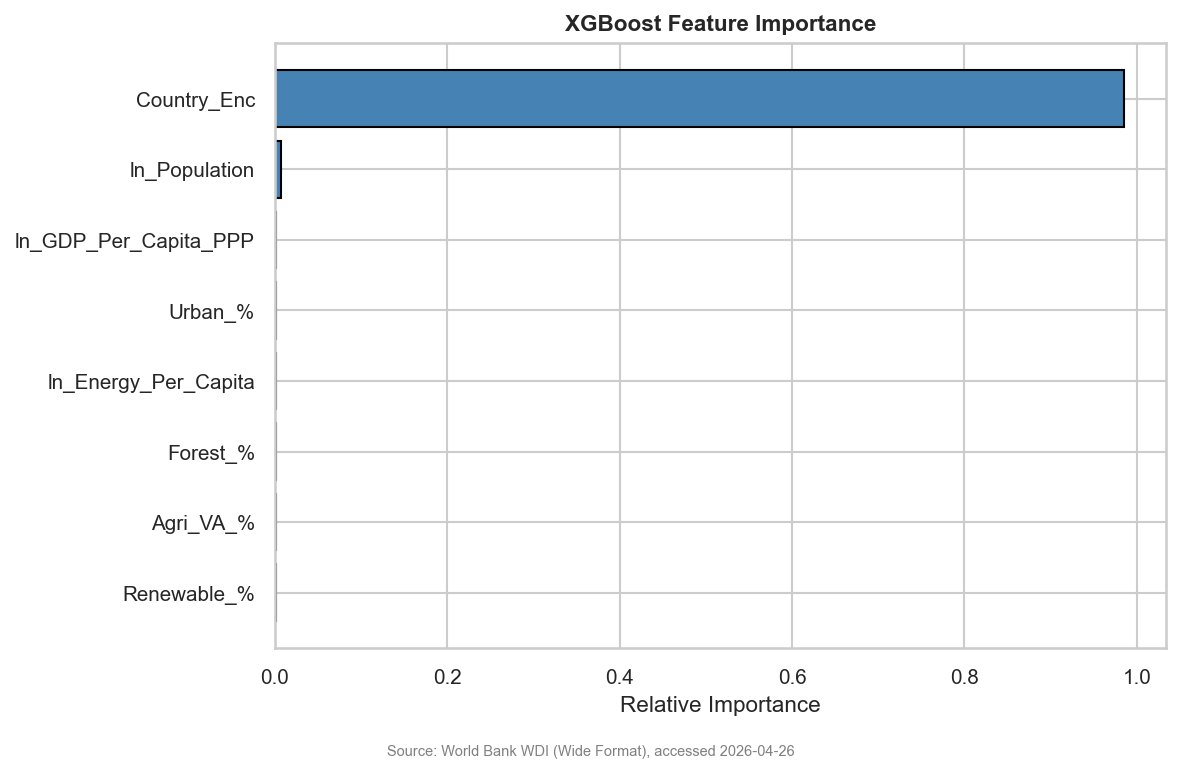

Saved: WS2_XGBoost_Importance.png

Country_Enc dominates (98.5%) — XGBoost is memorising country averages,
not learning structural relationships. FE is the better choice.


In [57]:
Importance = pd.DataFrame({
    'Feature': XGB_Features,
    'Importance': XGB_Model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(Importance.Feature, Importance.Importance, color='steelblue', edgecolor='black')
ax.set_title('XGBoost Feature Importance', fontweight='bold')
ax.set_xlabel('Relative Importance')
plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS2 / 'WS2_XGBoost_Importance.png', bbox_inches='tight', dpi=180)
plt.show()
print('Saved: WS2_XGBoost_Importance.png')

# Flag if country encoding dominates
Top_Feat = Importance.iloc[-1]
if Top_Feat.Feature == 'Country_Enc':
    print(f'\nCountry_Enc dominates ({Top_Feat.Importance:.1%}) — XGBoost is memorising country averages,')
    print(f'not learning structural relationships. FE is the better choice.')

### Step 4(D) Actual vs Predicted

Each dot is one country in one validation year. 
* Points on the red diagonal = perfect prediction. 
* Tighter clustering around the line = better model.

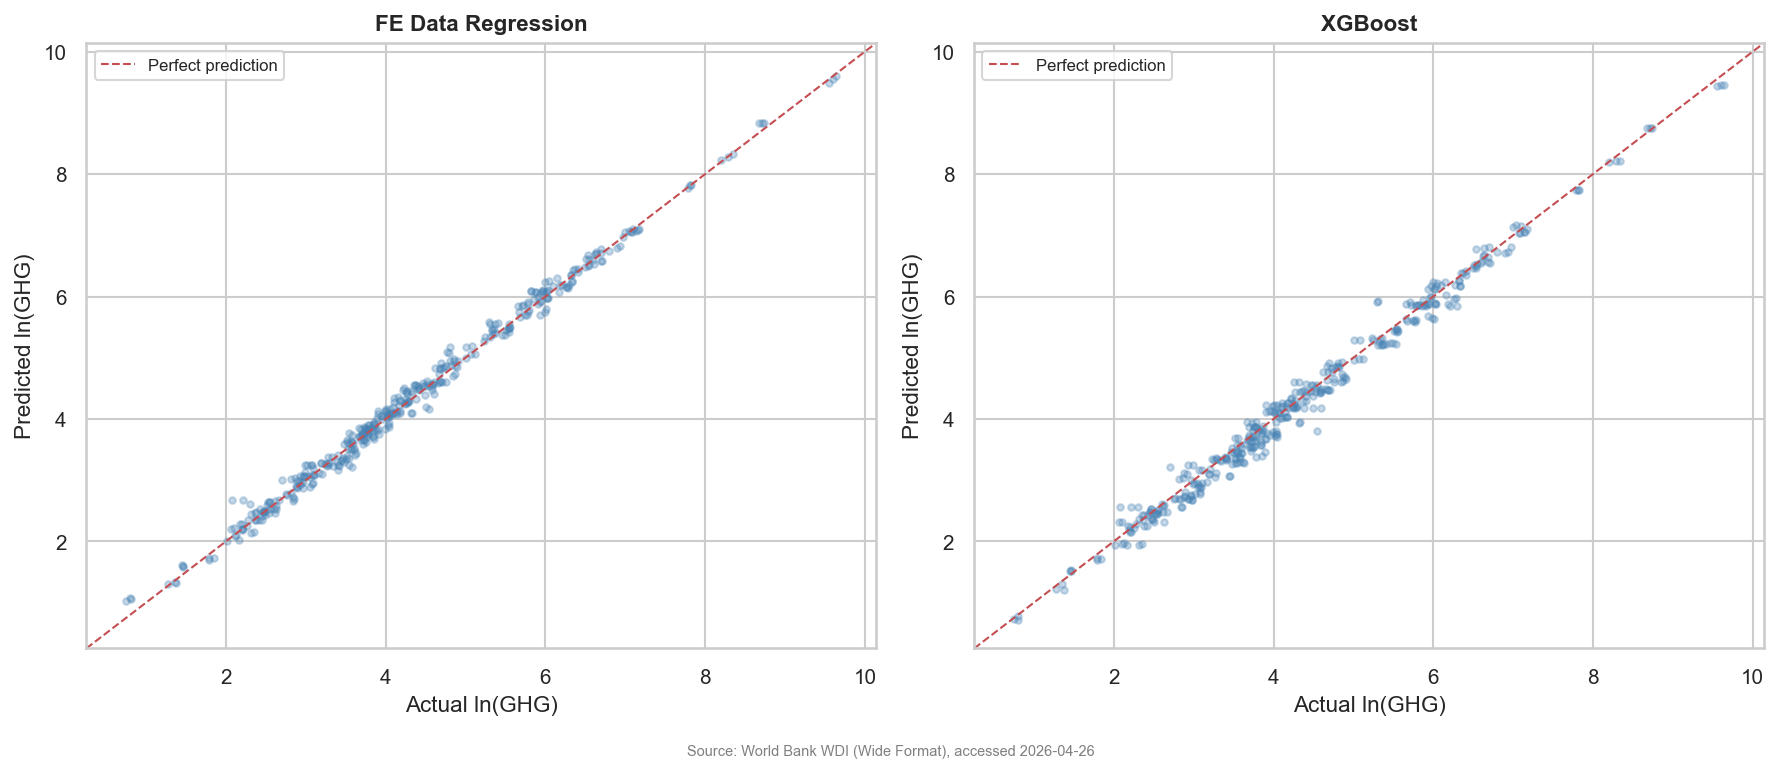

Saved: WS2_Actual_vs_Predicted.png


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lims = [Valid[Target].min() - 0.5, Valid[Target].max() + 0.5]

for ax, y_act, y_pred, title in [
    (axes[0], Valid[Target],   Valid['FE_Pred'],    'FE Data Regression'),
    (axes[1], Valid_X[Target], Valid_X['XGB_Pred'], 'XGBoost'),
]:
    ax.scatter(y_act, y_pred, alpha=0.3, s=10, color='steelblue')
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual ln(GHG)')
    ax.set_ylabel('Predicted ln(GHG)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS2 / 'WS2_Actual_vs_Predicted.png', bbox_inches='tight', dpi=180)
plt.show()
print('Saved: WS2_Actual_vs_Predicted.png')

## Step 5: Prediction for 2024

Predict 2024 GHG for all countries using both models, then focus on SE Asia.

Since 2024 actual data is available in WDI, we can compute prediction error. 
> The direction (over/under-prediction) tells us whether the model is conservative or aggressive for each region. 

* Step 5(A) **Predict 2024** 
<br> - Both models, for all countries.

* Step 5(B) **SE Asia focus** 
<br> - SE Asia focus table & bar chart

* Step 5(C) **95% Confidence Interval** 



### Step 5(A) 2024 Predictions

Run both FE and XGBoost on 2024 data. 
<br> Convert from log back to original scale (Mt CO₂e) for interpretability.

In [59]:
Pred['FE_Pred'] = FE_Predict(Pred, OLS.coef_, Country_Means_y, Country_Means_X, Pred_Cols)

Pred_X = Pred_X.copy()
Pred_X['XGB_Pred'] = XGB_Model.predict(Pred_X[XGB_Features].values)

# Combine into results table
Results = Pred[['Ref_Area', 'Year', Target, 'FE_Pred']].copy()
XGB_Map = dict(zip(Pred_X.Ref_Area, Pred_X['XGB_Pred']))
Results['XGB_Pred'] = Results['Ref_Area'].map(XGB_Map)

# Back to original scale (Mt CO₂e)
Results['GHG_Actual']   = np.exp(Results[Target])
Results['GHG_FE_Pred']  = np.exp(Results['FE_Pred'])
Results['GHG_XGB_Pred'] = np.exp(Results['XGB_Pred'])
Results['FE_Err_%']     = ((Results.GHG_FE_Pred - Results.GHG_Actual)
                            / Results.GHG_Actual * 100).round(1)
Results['XGB_Err_%']    = ((Results.GHG_XGB_Pred - Results.GHG_Actual)
                            / Results.GHG_Actual * 100).round(1)

### Step 5(B) SE Asia Focus

11 SE Asian countries with actual vs predicted values and error percentages.
* Negative error = model underpredicts (conservative). 
* Positive = model overpredicts (aggressive).

In [60]:
SEA = Results[Results.Ref_Area.isin(SE_Asia)]

print('=' * 72)
print('   2024 Predictions — SE Asia (Mt CO₂e)')
print('=' * 72)
print(SEA[['Ref_Area', 'GHG_Actual', 'GHG_FE_Pred', 'GHG_XGB_Pred',
           'FE_Err_%', 'XGB_Err_%']].round(2).to_string(index=False))
print('  ')

# Global metrics
print('=' * 72)
print(f'   2024 Global Accuracy')
print('=' * 72)
FE_2024 = Calc_Metrics(Results[Target].values, Results['FE_Pred'].values, 'FE — 2024')
print()
XGB_2024 = Calc_Metrics(Results[Target].values, Results['XGB_Pred'].values, 'XGBoost — 2024')

   2024 Predictions — SE Asia (Mt CO₂e)
Ref_Area  GHG_Actual  GHG_FE_Pred  GHG_XGB_Pred  FE_Err_%  XGB_Err_%
     BRN       11.87        11.45         10.40      -3.5      -12.4
     IDN     1323.78      1192.49       1190.10      -9.9      -10.1
     KHM       49.83        56.00         31.34      12.4      -37.1
     MMR      117.79       162.55        129.22      38.0        9.7
     MYS      332.17       303.29        271.63      -8.7      -18.2
     PHL      266.60       227.60        183.63     -14.6      -31.1
     SGP       76.09        73.19         64.98      -3.8      -14.6
     THA      422.39       395.14        359.24      -6.5      -15.0
     VNM      584.26       498.51        358.05     -14.7      -38.7
  
   2024 Global Accuracy
FE — 2024
  RMSE (log scale):  0.1561
  MAE  (log scale):  0.1239
  R²:                0.9903
  MAPE (orig scale): 13.0%

XGBoost — 2024
  RMSE (log scale):  0.2343
  MAE  (log scale):  0.1904
  R²:                0.9781
  MAPE (orig scale): 1

#### Visual comparison of actual vs FE vs XGBoost predictions for the SE Asian countries.

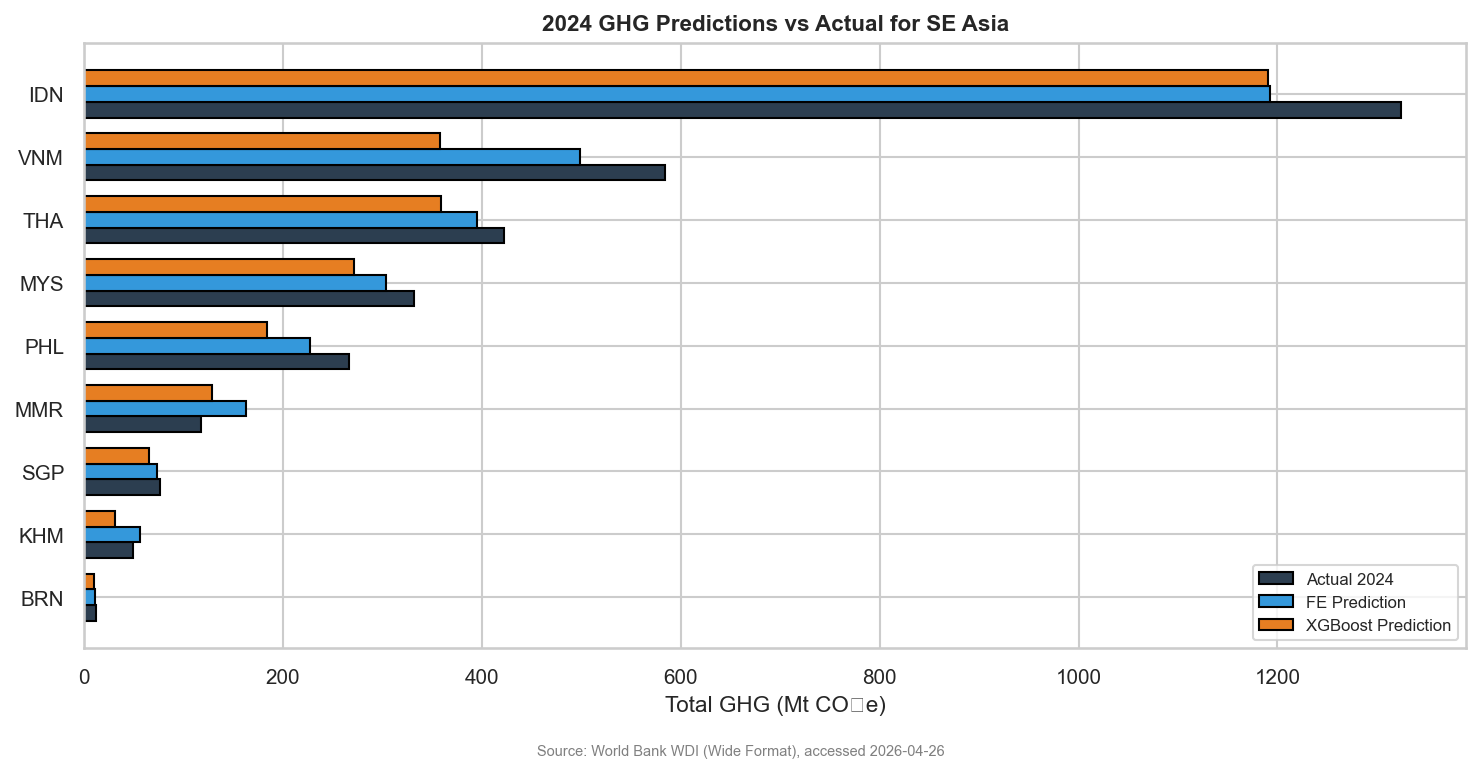

Saved: WS2_2024_Predictions_SEA.png


In [61]:
SEA_Plot = SEA.sort_values('GHG_Actual', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(SEA_Plot))
w = 0.25

ax.barh(x - w, SEA_Plot.GHG_Actual,   w, label='Actual 2024',        color='#2c3e50', edgecolor='black')
ax.barh(x,     SEA_Plot.GHG_FE_Pred,  w, label='FE Prediction',      color='#3498db', edgecolor='black')
ax.barh(x + w, SEA_Plot.GHG_XGB_Pred, w, label='XGBoost Prediction', color='#e67e22', edgecolor='black')

ax.set_yticks(x)
ax.set_yticklabels(SEA_Plot.Ref_Area)
ax.set_xlabel('Total GHG (Mt CO₂e)')
ax.set_title('2024 GHG Predictions vs Actual for SE Asia', fontweight='bold')
ax.legend(fontsize=8)

plt.figtext(0.5, -0.02, WDI_Source, ha='center', fontsize=7, color='grey')
plt.tight_layout()
fig.savefig(Output_WS2 / 'WS2_2024_Predictions_SEA.png', bbox_inches='tight', dpi=180)
plt.show()
print('Saved: WS2_2024_Predictions_SEA.png')

### Step 5(C) SE Asia: 95% Confidence Interval &  Bar Chart

> CI = exp(ŷ ± 1.96 × SE_residual) 

where `SE_residual` is the standard deviation of validation residuals. 

If most 2024 actuals fall within this band, the model's uncertainty estimate is well-calibrated.

In [62]:
Residual_SE = Valid['FE_Resid'].dropna().std()

Results['CI_Lower'] = np.exp(Results['FE_Pred'] - 1.96 * Residual_SE)
Results['CI_Upper'] = np.exp(Results['FE_Pred'] + 1.96 * Residual_SE)

# SE Asia CI table
SEA_CI = Results[Results.Ref_Area.isin(SE_Asia)][
    ['Ref_Area', 'GHG_Actual', 'GHG_FE_Pred', 'CI_Lower', 'CI_Upper']]

print('=' * 72)
print('   2024 Predictions with 95% CI — SE Asia (Mt CO₂e)')
print('=' * 72)
print(SEA_CI.round(2).to_string(index=False))

# Global CI coverage
In_CI = ((Results.GHG_Actual >= Results.CI_Lower) &
         (Results.GHG_Actual <= Results.CI_Upper)).mean() * 100
print(f'\nCI coverage: {In_CI:.1f}% of 2024 actuals fall within the 95% CI')

   2024 Predictions with 95% CI — SE Asia (Mt CO₂e)
Ref_Area  GHG_Actual  GHG_FE_Pred  CI_Lower  CI_Upper
     BRN       11.87        11.45      8.97     14.62
     IDN     1323.78      1192.49    933.87   1522.73
     KHM       49.83        56.00     43.86     71.51
     MMR      117.79       162.55    127.30    207.56
     MYS      332.17       303.29    237.52    387.28
     PHL      266.60       227.60    178.24    290.63
     SGP       76.09        73.19     57.32     93.46
     THA      422.39       395.14    309.45    504.57
     VNM      584.26       498.51    390.40    636.56

CI coverage: 91.5% of 2024 actuals fall within the 95% CI


#### Visual comparison of actual vs FE vs XGBoost predictions for the all SE Asian countries.

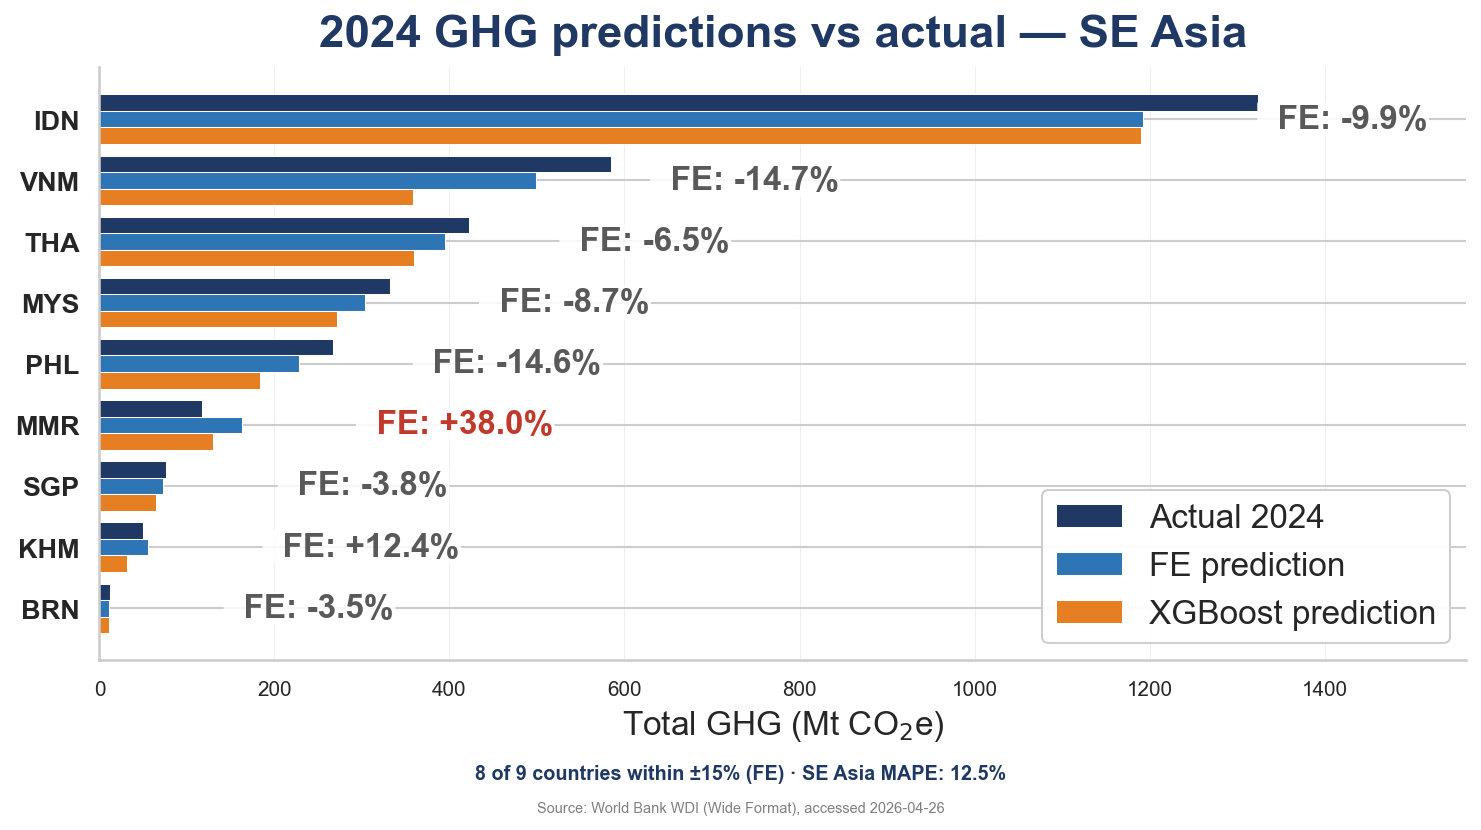

Saved: WS2_2024_Predictions_SEA.png


In [63]:
# Filter & sort SE Asia
SEA_Plot = (Results[Results.Ref_Area.isin(SE_Asia)]
            .sort_values('GHG_Actual', ascending=False)
            .reset_index(drop=True))

# Summary stats for the bottom takeaway line
N_Within_15 = (SEA_Plot['FE_Err_%'].abs() <= 15).sum()
N_Total     = len(SEA_Plot)
SEA_MAPE    = SEA_Plot['FE_Err_%'].abs().mean()
Summary     = f'{N_Within_15} of {N_Total} countries within \u00B115% (FE) \u00B7 SE Asia MAPE: {SEA_MAPE:.1f}%'

# Color palette (matches report)
NAVY, ACCENT, ORANGE, GREY = '#1F3864', '#2E75B6', '#E67E22', '#595959'

# Reverse so largest emitter (IDN) appears at the top
Sea_Rev = SEA_Plot.iloc[::-1].reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 5.4))
x = np.arange(len(Sea_Rev))
w = 0.27

ax.barh(x + w, Sea_Rev.GHG_Actual,   w, label='Actual 2024',
        color=NAVY,   edgecolor='white', linewidth=0.5)
ax.barh(x,     Sea_Rev.GHG_FE_Pred,  w, label='FE prediction',
        color=ACCENT, edgecolor='white', linewidth=0.5)
ax.barh(x - w, Sea_Rev.GHG_XGB_Pred, w, label='XGBoost prediction',
        color=ORANGE, edgecolor='white', linewidth=0.5)

# FE error % labels at end of each FE bar
for i, row in Sea_Rev.iterrows():
    err    = row['FE_Err_%']
    sign   = '+' if err >= 0 else ''
    color  = '#C0392B' if abs(err) > 25 else GREY
    weight = 'bold'    if abs(err) > 25 else 'bold'
    ax.text(row.GHG_FE_Pred + Sea_Rev.GHG_Actual.max() * 0.1, i,
            f'  FE: {sign}{err:.1f}%',
            va='center', ha='left', fontsize=16,
            color=color, fontweight=weight, 
            bbox=dict(boxstyle='round,pad=0.05', facecolor='white',
                      edgecolor='none', alpha=0.85))

# Axis cosmetics
ax.set_yticks(x)
ax.set_yticklabels(Sea_Rev.Ref_Area, fontweight='bold', fontsize=13)
ax.set_xlabel('Total GHG (Mt CO$_2$e)', fontsize=16)
ax.set_title('2024 GHG predictions vs actual — SE Asia',
             fontweight='bold', fontsize=22, color=NAVY, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis='x', alpha=0.3, linewidth=0.5)
ax.legend(loc='lower right', fontsize=16, frameon=True, framealpha=0.95)
ax.set_xlim(0, max(Sea_Rev.GHG_Actual.max(), Sea_Rev.GHG_FE_Pred.max()) * 1.18)

# Bottom annotations
plt.figtext(0.5, 0.025, Summary,
            ha='center', fontsize=9.5, color=NAVY, fontweight='bold')
plt.figtext(0.5, -0.015, WDI_Source,
            ha='center', fontsize=7, color='grey')

plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(Output_WS2 / 'WS2_2024_Predictions_SEA.png',
            bbox_inches='tight', dpi=200, facecolor='white')
plt.show()
print('Saved: WS2_2024_Predictions_SEA.png')

## Step 6: Export

Save outputs for WS4 (stress testing) and the dashboard.

| # | File | Used by | Purpose |
|---|------|---------|---------|
| 1 | `WS2_Coefficients.csv` | WS4 | Elasticities for mitigation scenario projections |
| 2 | `WS2_Validation_Metrics.csv` | Dashboard | Model comparison tab |
| 3 | `WS2_SEA_Predictions_2024.csv` | Dashboard | Country predictions tab |
| 4 | `WS2_XGB_Importance.csv` | Dashboard | Feature importance chart |
| 5 | `WS2_Country_Means_Y.csv` | WS4 | Country intercepts for prediction formula |
| 6 | `WS2_Country_Means_X.csv` | WS4 | Country predictor baselines for prediction formula |

In [64]:
# 1. Coefficients
coef_df.to_csv(Data_Path / 'WS2_Coefficients.csv', index=False)

# 2. Validation metrics
pd.DataFrame({
    'Model': ['FE Data Regression', 'XGBoost'],
    'RMSE':  [FE_Val_Metrics['RMSE'], XGB_Val_Metrics['RMSE']],
    'MAE':   [FE_Val_Metrics['MAE'],  XGB_Val_Metrics['MAE']],
    'R2':    [FE_Val_Metrics['R2'],   XGB_Val_Metrics['R2']],
    'MAPE':  [FE_Val_Metrics['MAPE'], XGB_Val_Metrics['MAPE']],
}).to_csv(Data_Path / 'WS2_Validation_Metrics.csv', index=False)

# 3. SE Asia 2024 predictions
Results[Results.Ref_Area.isin(SE_Asia)].to_csv(
    Data_Path / 'WS2_SEA_Predictions_2024.csv', index=False)

# 4. XGBoost feature importance
pd.DataFrame({
    'Feature': XGB_Features,
    'Importance': XGB_Model.feature_importances_
}).sort_values('Importance', ascending=False).to_csv(
    Data_Path / 'WS2_XGB_Importance.csv', index=False)

# 5. Country means (WS4 needs these for prediction formula)
Country_Means_y.to_csv(Data_Path / 'WS2_Country_Means_Y.csv')
Country_Means_X.to_csv(Data_Path / 'WS2_Country_Means_X.csv')

print('Exports saved to Data_Path/')
for f in ['WS2_Coefficients.csv', 'WS2_Validation_Metrics.csv',
          'WS2_SEA_Predictions_2024.csv', 'WS2_XGB_Importance.csv',
          'WS2_Country_Means_Y.csv', 'WS2_Country_Means_X.csv']:
    print(f'  {f}')

Exports saved to Data_Path/
  WS2_Coefficients.csv
  WS2_Validation_Metrics.csv
  WS2_SEA_Predictions_2024.csv
  WS2_XGB_Importance.csv
  WS2_Country_Means_Y.csv
  WS2_Country_Means_X.csv


## WS2 Complete, Handoff to WS4

**Model:** Fixed-effects data regression via manual demeaning + OLS.
<br> **Data:** 135 countries, trained 2000–2018, validated 2019/2022/2023, predicted 2024.
<br> **2020–2021:** Excluded entirely (pandemic distortion).

**For WS4 stress testing, use:**
1. Coefficient table from `WS2_Coefficients.csv`
2. Country means from `WS2_Country_Means_Y.csv` and `WS2_Country_Means_X.csv`
3. Prediction formula: ŷᵢₜ = ȳᵢ(train) + β̂ · (Xᵢₜ − X̄ᵢ(train))
4. Shock the policy-actionable inputs (Renewable%, Energy/cap, Forest%) while holding GDP, Population, Urban% on BAU trajectories

# Workstream 3: Insurance Claims Analysis (Thailand vs Philippines)

**Objective:** 
* Analyse the relationship between WDI climate indicators and natural disaster insurance claims. 
* Comparing Thailand and Philippines.

<br> **Country Pair:** Thailand vs Philippines 
> Read `WS3_Country_Pair_Selection_Proposal docx` for systematic evaluation of all 11 ASEAN member states

<br> **Data Sources:** WDI (World Bank) + EM-DAT (CRED) + Swiss Re sigma + Munich Re NatCatSERVICE

<br> **WDI Indicators:** Same 7 final predictors from WS1/WS2, grouped by role:
- **Exposure drivers** (directly linked to disaster losses): Urban %, Forest %, GDP/cap, Population
- **Emissions drivers** (linked to long-term climate trajectory): Energy/cap, Renewable %
- **Vulnerability driver:** Agri VA %

<br> **Output:** `WS3_Data_THA_PHL.csv`, `WS3_Protection_Gap.csv`, `WS3_Significant_Correlations.csv`

| Step | What | Output |
|------|------|--------|
| **1 Data Loading** | (A) Load WS1 imputed data, filter to THA & PHL; <br>(B) Load & aggregate EM-DAT; <br>(C) Merge into single data | `Data`, `THA`, `PHL` |
| **2 Risk Profile** | (A) Disaster frequency by type; <br>(B) Economic losses timeline; <br>(C) Top-10 costliest events table | Fig 1: Disaster Frequency by Type <br> Fig 2: Economic Losses Over Time <br> Table 1: Top-10 Costliest Events |
| **3 Protection Gap** | (A) Estimate insured losses (time-varying ratios for THA); <br>(B) Protection gap chart | Fig 3: Insured vs Uninsured Losses |
| **4 WDI–Loss Linkage** | (A) Spearman correlation heatmap (7 predictors × 4 outcomes × 2 countries); <br>(B) Key findings by role; <br>(C) Scatter plots — 4 strongest associations | Fig 4: Spearman Correlation Heatmap <br> Fig 5: Scatter — Strongest Associations |
| **5 Summary** | Portfolio implications dashboard + reinsurer recommendations | Fig 6: Summary Dashboard |
| **6 Export** | Save data, protection gap, and correlation results for WS5 | `WS3_Data_THA_PHL.csv` <br> `WS3_Protection_Gap.csv` <br> `WS3_Significant_Correlations.csv` |

## Setup
* Import libraries
* Set plotting format and colour codes
* Define constants: indicator mapping, country codes, year range

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling 
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'figure.facecolor': 'white',
})

Colors = {'Thailand': '#E63946', 'Philippines': '#1D3557'}
Colors_Light = {'Thailand': '#FFCDD2', 'Philippines': '#B3CDE3'}

# Country and year constants 
Country_Map = {'THA': 'Thailand', 'PHL': 'Philippines'}
Years = [str(y) for y in range(2000, 2025)]

# WDI Indicator mapping 
# - Same 7 predictors from WS1/WS2, plus emissions target and supplementary context indicators
# - Uses WB_WDI SDMX codes (matching WS1) with Short names (matching WS2 columns)
Indicator_Map = {
    # === Target (from WS2) ===
    'WB_WDI_EN_GHG_ALL_MT_CE_AR5': 'Total_GHG',
    # === 7 Final Predictors (from WS1 screening) ===
    'WB_WDI_SP_POP_TOTL':          'Population',
    'WB_WDI_NY_GDP_PCAP_PP_KD':    'GDP_Per_Capita_PPP',
    'WB_WDI_EG_USE_PCAP_KG_OE':    'Energy_Per_Capita',
    'WB_WDI_EG_FEC_RNEW_ZS':       'Renewable_%',
    'WB_WDI_SP_URB_TOTL_IN_ZS':    'Urban_%',
    'WB_WDI_AG_LND_FRST_ZS':       'Forest_%',
    'WB_WDI_NV_AGR_TOTL_ZS':       'Agri_VA_%',
    # === Supplementary context (not in WS2 model, used for descriptive comparison) ===
    'WB_WDI_EN_GHG_CO2_MT_CE_AR5': 'CO2_Total',
    'WB_WDI_NY_GDP_MKTP_CD':       'GDP_Total',
}

# Reverse lookup
Short_To_Code = {v: k for k, v in Indicator_Map.items()}

# Display names for charts 
Indicator_Names = {
    'Total_GHG':          'Total GHG (Mt CO\u2082e)',
    'Population':         'Population',
    'GDP_Per_Capita_PPP': 'GDP Per Capita (PPP)',
    'Energy_Per_Capita':  'Energy Use Per Capita',
    'Renewable_%':        'Renewable Energy (%)',
    'Urban_%':            'Urban Pop (%)',
    'Forest_%':           'Forest Area (%)',
    'Agri_VA_%':          'Agriculture VA (% GDP)',
    'CO2_Total':          'CO\u2082 Emissions (Mt CO\u2082e)',
    'GDP_Total':          'GDP (USD)',
}


# Indicator role classification (for WS3 interpretation) 
# - Grouped by how they relate to disaster losses, not emissions
Role_Map = {
    'Urban_%':            'Exposure',      # Asset concentration in hazard zones
    'Forest_%':           'Exposure',      # Natural buffer against floods/landslides
    'GDP_Per_Capita_PPP': 'Exposure',      # Economic value at risk
    'Population':         'Exposure',      # People exposed
    'Energy_Per_Capita':  'Emissions',     # Energy intensity -> emissions trajectory
    'Renewable_%':        'Emissions',     # Energy mix -> emissions trajectory
    'Agri_VA_%':          'Vulnerability', # Agricultural/rural exposure
}

# The 7 WS1/WS2 predictors (used in correlation analysis)
WS2_Predictors = list(Role_Map.keys())

print("Setup complete.")
print(f"  WS2 predictors carried forward: {len(WS2_Predictors)}")
print(f"  Role breakdown: {dict(pd.Series(Role_Map).value_counts())}")

Setup complete.
  WS2 predictors carried forward: 7
  Role breakdown: {'Exposure': 4, 'Emissions': 2, 'Vulnerability': 1}


## Step 1: Data Loading & Preparation

### Step 1(A) Load WS1 Data Data
Load the imputed data from WS1 (`WS1_Data_Imputed.csv`) and filter to Thailand and Philippines. 
* Has all 7 predictors + target for 135 countries

In [66]:
# Load WS1 data 
Data = pd.read_csv(Data_Path / Data_Filename)


# Filter to Thailand and Philippines
Data = Data[Data['Ref_Area'].isin(['THA', 'PHL'])].copy()
Data['Country'] = Data['Ref_Area'].map({'THA': 'Thailand', 'PHL': 'Philippines'})

# Verify columns from WS2 are present
for col in WS2_Predictors + ['Total_GHG']:
    assert col in Data.columns, f'Missing column: {col}'

print('=' * 60)
print('     STEP 1(A): WS1 DATA LOADED')
print('=' * 60)
print(f'Source:     {Data_Filename}')
print(f'Filtered:   THA + PHL = {len(Data)} rows')
print(f'Year range: {Data["Year"].min()}–{Data["Year"].max()}')
print(f'Predictors: {WS2_Predictors}')

     STEP 1(A): WS1 DATA LOADED
Source:     WS1_Data_Imputed.csv
Filtered:   THA + PHL = 50 rows
Year range: 2000–2024
Predictors: ['Urban_%', 'Forest_%', 'GDP_Per_Capita_PPP', 'Population', 'Energy_Per_Capita', 'Renewable_%', 'Agri_VA_%']


### Step 1(B) Load & Aggregate EM-DAT Disaster Data

EM-DAT provides event-level records. We aggregate to annual level per country for merging with WDI.

**Key fields used:**
- `Total Damage, Adjusted ('000 US$)` — inflation-adjusted economic losses
- `Insured Damage ('000 US$)` — insured losses (sparse: ~11 events have data)
- `Total Deaths`, `Total Affected` — human impact
- `Disaster Type` — for type-specific analysis (flood vs storm)

In [67]:
# Load EMDAT data
EMDAT = pd.read_csv(Data_Path / EMDAT_Filename)

# Filter to natural disasters only
Nat_Types = ['Flood', 'Storm', 'Earthquake', 'Drought', 'Mass movement (wet)',
             'Volcanic activity', 'Extreme temperature', 'Wildfire', 'Mass movement (dry)']
EMDAT = EMDAT[EMDAT['Disaster Type'].isin(Nat_Types)].copy()

# Rename all columns to Title_Case with underscores
EMDAT = EMDAT.rename(columns=lambda c: c.strip().replace(' ', '_').replace("'", '').replace(',', ''))

# Rename some messy column names
EMDAT = EMDAT.rename(columns={
    'Start_Year':                              'Year',
    'Disaster_Type':                           'Disaster_Type',
    'Total_Damage_Adjusted_(000_US$)':         'Damage_Adj_000',
    'Total_Damage_(000_US$)':                  'Damage_Raw_000',
    'Insured_Damage_(000_US$)':                'Insured_000',
    'Total_Deaths':                            'Deaths',
    'Total_Affected':                          'Affected',
})

# Aggregate to annual level per country
EMDAT_Annual = EMDAT.groupby(['Country', 'Year']).agg(
    Event_Count     = ('DisNo.',        'count'),
    Total_Deaths    = ('Deaths',        'sum'),
    Total_Affected  = ('Affected',      'sum'),
    Econ_Loss_Adj_M = ('Damage_Adj_000', lambda x: x.sum() / 1e3),
    Econ_Loss_Raw_M = ('Damage_Raw_000', lambda x: x.sum() / 1e3),
    Insured_Loss_M  = ('Insured_000',    lambda x: x.sum() / 1e3),
    Flood_Count     = ('Disaster_Type',  lambda x: (x == 'Flood').sum()),
    Storm_Count     = ('Disaster_Type',  lambda x: (x == 'Storm').sum()),
    Earthquake_Count= ('Disaster_Type',  lambda x: (x == 'Earthquake').sum()),
    Other_Count     = ('Disaster_Type',  lambda x: (~x.isin(['Flood', 'Storm', 'Earthquake'])).sum()),
).reset_index()

print('=' * 60)
print('     STEP 1(B): EM-DAT DATA LOADED')
print('=' * 60)
print(f'Total EM-DAT records: {len(EMDAT)}')
print(f'  Thailand:    {len(EMDAT[EMDAT["Country"]=="Thailand"]):>4d} events')
print(f'  Philippines: {len(EMDAT[EMDAT["Country"]=="Philippines"]):>4d} events')
print(f'Annual aggregation: {len(EMDAT_Annual)} country-year records')

     STEP 1(B): EM-DAT DATA LOADED
Total EM-DAT records: 487
  Thailand:     117 events
  Philippines:  370 events
Annual aggregation: 49 country-year records


### Step 1(C) Merge WDI + EM-DAT Data

In [68]:
# Merge 2 datasets into single one
Data = pd.merge(Data, EMDAT_Annual, on=['Country', 'Year'], how='left')
Data = Data.sort_values(['Country', 'Year']).reset_index(drop=True)

# Fill years with no disasters as 0
Disaster_Cols = ['Event_Count', 'Total_Deaths', 'Total_Affected', 'Econ_Loss_Adj_M',
                 'Econ_Loss_Raw_M', 'Insured_Loss_M', 'Flood_Count', 'Storm_Count',
                 'Earthquake_Count', 'Other_Count']
Data[Disaster_Cols] = Data[Disaster_Cols].fillna(0)

# Create country subsets
THA = Data[Data['Country'] == 'Thailand'].copy()
PHL = Data[Data['Country'] == 'Philippines'].copy()

print('=' * 60)
print('     STEP 1(C): DATA MERGED')
print('=' * 60)
print(f'Final data: {Data.shape[0]} rows × {Data.shape[1]} columns')
print(f'  Thailand:    {len(THA)} years | {int(THA["Event_Count"].sum()):>4d} total events | ${THA["Econ_Loss_Adj_M"].sum()/1000:.1f}B total losses')
print(f'  Philippines: {len(PHL)} years | {int(PHL["Event_Count"].sum()):>4d} total events | ${PHL["Econ_Loss_Adj_M"].sum()/1000:.1f}B total losses')

     STEP 1(C): DATA MERGED
Final data: 50 rows × 29 columns
  Thailand:    25 years |  117 total events | $69.2B total losses
  Philippines: 25 years |  370 total events | $33.1B total losses


In [69]:
# Delete used once list/variables 
del Disaster_Cols
# del EMDAT, EMDAT_Annual

## Step 2: Risk Profile Comparison

This section compare disaster profiles of Thailand and Philippines 
* Foundation for the reinsurer comparison.

| Dimension | Thailand | Philippines |
|-----------|----------|-------------|
| **Dominant peril** | Riverine/monsoon flooding | Typhoons (tropical cyclones) |
| **Loss profile** | Low frequency, high severity (concentrated tail risk) | High frequency, moderate severity (attritional) |
| **Insurance exposure** | Commercial/industrial (CBI) | Household/agricultural |
| **Key event** | 2011 floods: USD 46B economic, USD 15B insured | Haiyan 2013: USD 10B economic, USD 0.7B insured |

### Step 2(A) Figure 1: Disaster Frequency by Type

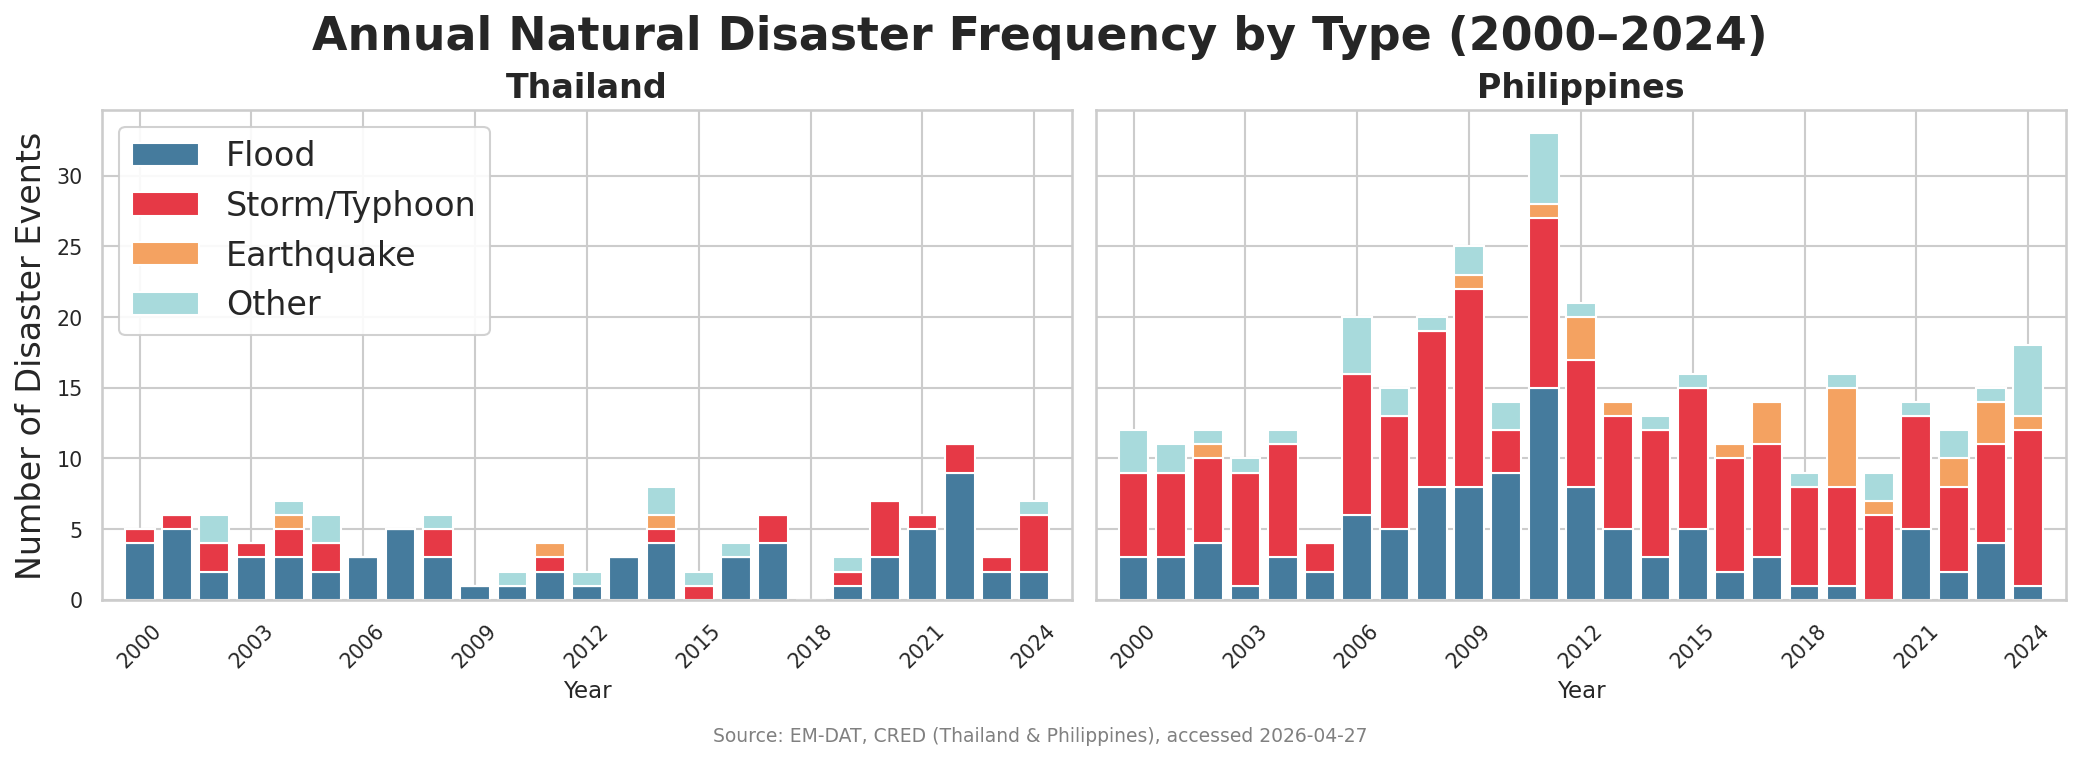

Average events/year:  Thailand 4.7  |  Philippines 14.8  (ratio: 3.2x)
Dominant peril share: Thailand floods 61%  |  Philippines storms 54%


In [70]:
# ============================================================
# FIGURE 1: Disaster Frequency Over Time (Stacked by type)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (country, sub) in zip(axes, [('Thailand', THA), ('Philippines', PHL)]):
    ax.bar(sub['Year'], sub['Flood_Count'], label='Flood', color='#457B9D', width=0.8)
    ax.bar(sub['Year'], sub['Storm_Count'], bottom=sub['Flood_Count'],
           label='Storm/Typhoon', color='#E63946', width=0.8)
    ax.bar(sub['Year'], sub['Earthquake_Count'],
           bottom=sub['Flood_Count'] + sub['Storm_Count'],
           label='Earthquake', color='#F4A261', width=0.8)
    ax.bar(sub['Year'], sub['Other_Count'],
           bottom=sub['Flood_Count'] + sub['Storm_Count'] + sub['Earthquake_Count'],
           label='Other', color='#A8DADC', width=0.8)
    ax.set_title(f'{country}', fontweight='bold', fontsize=16)
    ax.set_xlabel('Year')
    ax.set_xlim(1999, 2025)
    ax.set_xticks(range(2000, 2025, 3))
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Number of Disaster Events', fontsize=16)
axes[0].legend(loc='upper left', fontsize=16, framealpha=0.9)
fig.suptitle('Annual Natural Disaster Frequency by Type (2000\u20132024)',
             fontweight='bold', fontsize=22, y=0.95)
plt.figtext(0.5, -0.02, EMDAT_Source,
            ha='center', fontsize=9, color='gray')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_disaster_frequency.png')
plt.show()

# Print summary statistics
THA_Avg = THA['Event_Count'].mean()
PHL_Avg = PHL['Event_Count'].mean()
THA_Flood_Pct = THA['Flood_Count'].sum() / THA['Event_Count'].sum() * 100
PHL_Storm_Pct = PHL['Storm_Count'].sum() / PHL['Event_Count'].sum() * 100
print(f'Average events/year:  Thailand {THA_Avg:.1f}  |  Philippines {PHL_Avg:.1f}  (ratio: {PHL_Avg/THA_Avg:.1f}x)')
print(f'Dominant peril share: Thailand floods {THA_Flood_Pct:.0f}%  |  Philippines storms {PHL_Storm_Pct:.0f}%')

**Interpretation:** The Philippines experiences approximately 3x more disaster events annually than Thailand. The Philippines is dominated by storms/typhoons (54% of all events), while Thailand is dominated by floods (61%). 

This confirms the distinct hazard profile contrast that makes this pair analytically informative for the reinsurer: **different perils produce different insurance outcomes.**

### Step 2(B) Figure 2: Economic Losses Over Time

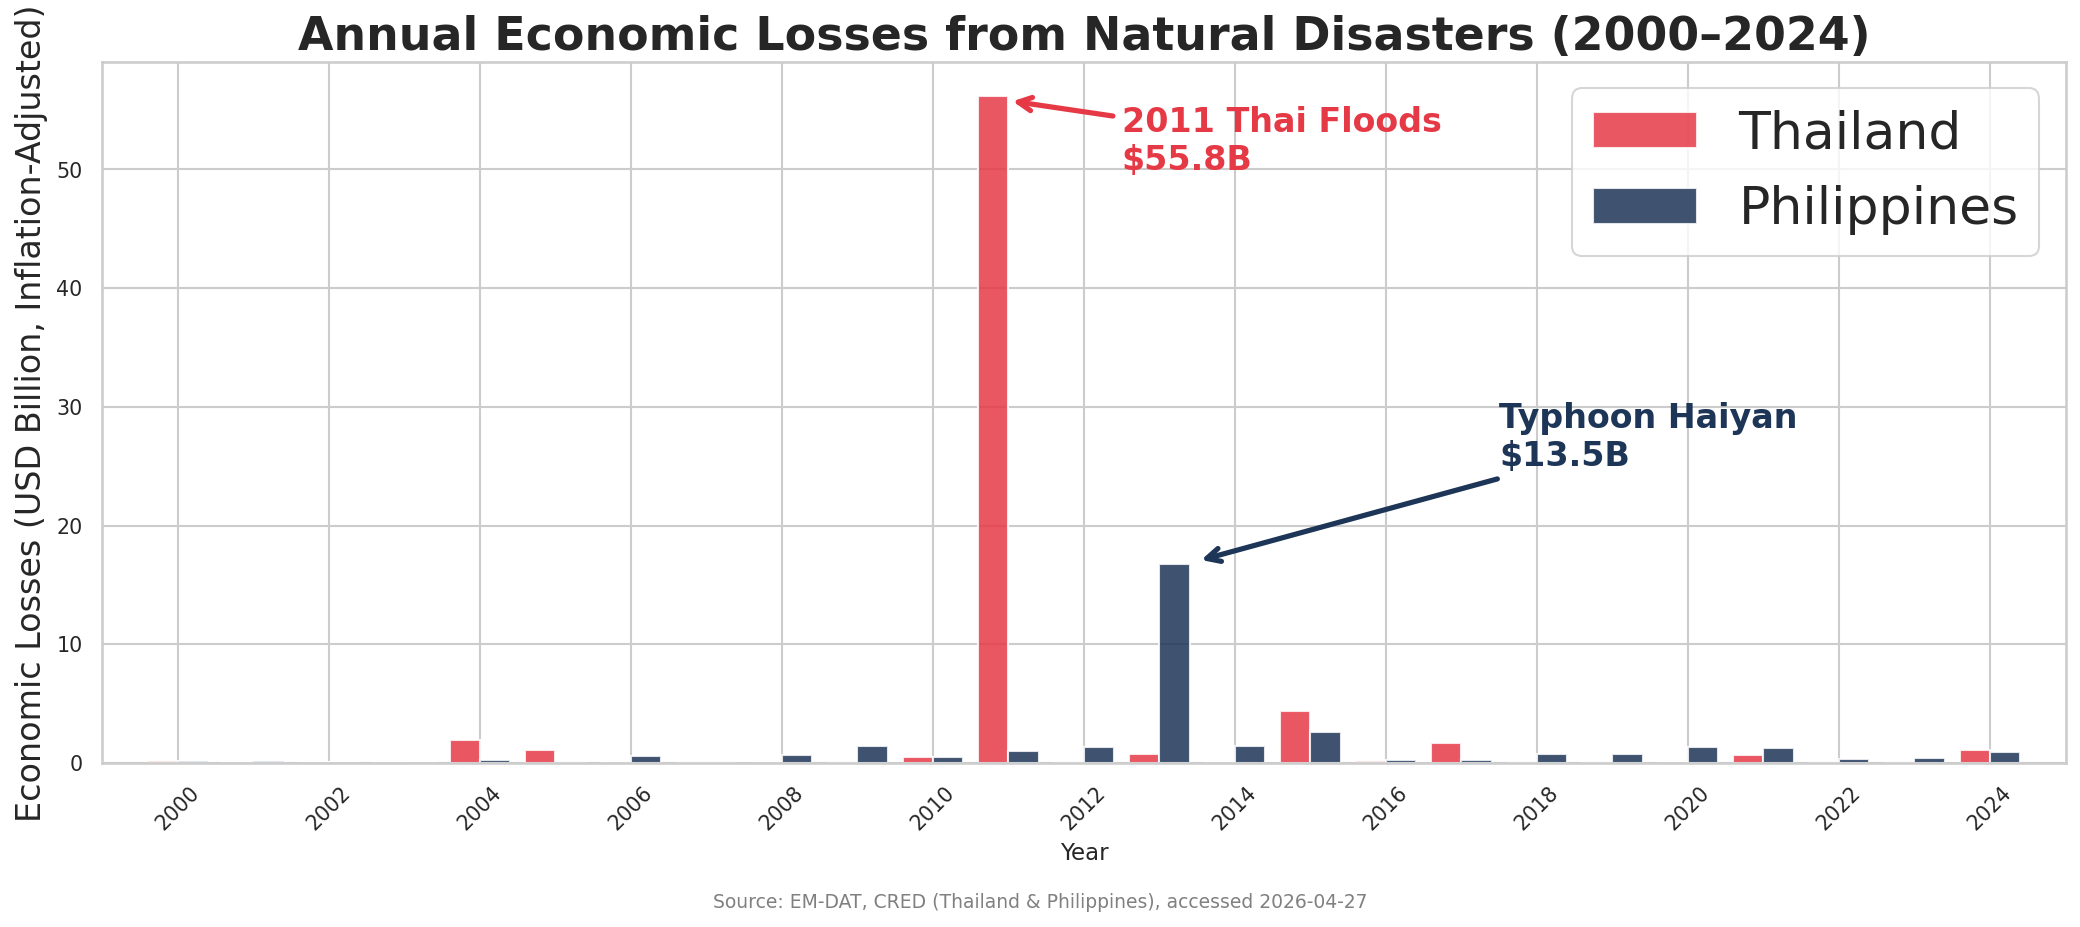

Thailand 2011 flood share of all-time losses: 81%
  -> Tail risk: single event = $56.2B out of $69.2B total


In [71]:
fig, ax = plt.subplots(figsize=(14, 6))

for country, sub, color in [('Thailand', THA, Colors['Thailand']),
                             ('Philippines', PHL, Colors['Philippines'])]:
    ax.bar(sub['Year'] + (-0.2 if country == 'Thailand' else 0.2),
           sub['Econ_Loss_Adj_M'] / 1000, width=0.4, color=color, alpha=0.85, label=country)

# Annotate major events
ax.annotate('2011 Thai Floods\n$55.8B', xy=(2011, 55.8), xytext=(2012.5, 50),
            fontsize=16, fontweight='bold', color=Colors['Thailand'],
            arrowprops=dict(arrowstyle='->', color=Colors['Thailand'], lw=2.5))
ax.annotate('Typhoon Haiyan\n$13.5B', xy=(2013.5, 17), xytext=(2017.5, 25),
            fontsize=16, fontweight='bold', color=Colors['Philippines'],
            arrowprops=dict(arrowstyle='->', color=Colors['Philippines'], lw=2.5))

ax.set_xlabel('Year')
ax.set_ylabel('Economic Losses (USD Billion, Inflation-Adjusted)', fontsize=16)
ax.set_title('Annual Economic Losses from Natural Disasters (2000\u20132024)',
             fontweight='bold', fontsize=22)
ax.legend(fontsize=25)
ax.set_xlim(1999, 2025)
ax.set_xticks(range(2000, 2025, 2))
ax.tick_params(axis='x', rotation=45)
plt.figtext(0.5, -0.02, EMDAT_Source, ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_Economic_Losses.png')
plt.show()

# Print loss concentration
THA_2011 = THA[THA['Year'] == 2011]['Econ_Loss_Adj_M'].values[0]
THA_Total = THA['Econ_Loss_Adj_M'].sum()
print(f'Thailand 2011 flood share of all-time losses: {THA_2011/THA_Total*100:.0f}%')
print(f'  -> Tail risk: single event = ${THA_2011/1000:.1f}B out of ${THA_Total/1000:.1f}B total')

**Interpretation:** 

Thailand's loss profile is dominated by a single catastrophic event, *the 2011 floods ($55.8B adjusted)*, which alone accounts for 81% of all Thai disaster losses over the 25-year period. 

The Philippines also has significant tail events (Haiyan 2013, $13.5B), but shows a more distributed loss pattern with material losses in most years.

For the reinsurer, this means:
1. **Thailand = concentrated tail risk**
     - Single peak peril (flood) drives almost all exposure. 
     - Years without a major flood have negligible losses.
2. **Philippines = tail risk plus attritional base**
     - Major typhoons create peak losses, but there is also a consistent annual loss base from recurring storms. 
     - This requires both peak-peril capacity *and* aggregate/frequency management.

### Step 2(C) Table 1: Top-10 Costliest Disaster Events

An event-level table showing the largest losses for each country. 

In [72]:
for country in ['Thailand', 'Philippines']:
    Sub = EMDAT[EMDAT['Country'] == country].copy()
    Sub['Econ_Loss_M'] = Sub['Damage_Adj_000'] / 1e3
    Sub['Insured_M']   = Sub['Insured_000'] / 1e3
    Sub = Sub.sort_values('Econ_Loss_M', ascending=False).head(10)
    
    # Compute insured ratio where available
    Sub['Insured_Ratio_%'] = np.where(
        (Sub['Econ_Loss_M'] > 0) & (Sub['Insured_M'] > 0),
        (Sub['Insured_M'] / Sub['Econ_Loss_M'] * 100).round(1),
        np.nan
    )
    
    Display_Cols = ['Year', 'Disaster_Type', 'Event_Name', 'Econ_Loss_M', 
                    'Insured_M', 'Insured_Ratio_%', 'Deaths']
    Display_Cols = [c for c in Display_Cols if c in Sub.columns]
    
    print(f'\n{"="*72}')
    print(f'  TABLE 1: Top-10 Costliest Events — {country}')
    print(f'{"="*72}')
    print(Sub[Display_Cols].to_string(index=False))

print('\nNote: Insured loss data available for only ~11 events across both countries.')
print('Protection gap estimates in Step 3 use published aggregate ratios instead.')


  TABLE 1: Top-10 Costliest Events — Thailand
 Year Disaster_Type              Event_Name  Econ_Loss_M  Insured_M  Insured_Ratio_%  Deaths
 2011         Flood                     NaN    55781.997    10000.0             17.9   813.0
 2015       Drought                     NaN     4367.507        NaN              NaN     NaN
 2004    Earthquake                     NaN     1660.755      250.0             15.1  8345.0
 2017         Flood                     NaN     1279.738        NaN              NaN    96.0
 2024         Storm Typhoon 'Yagi' (Enteng)      904.000        NaN              NaN    45.0
 2021         Flood                     NaN      684.173        NaN              NaN    10.0
 2005       Drought                     NaN      674.629        NaN              NaN     NaN
 2013         Flood                     NaN      649.038        NaN              NaN    61.0
 2010         Flood                     NaN      477.606        NaN              NaN   258.0
 2011         Flood    

In [73]:
# Delete used-once variables 
del THA_Avg, PHL_Avg, THA_Flood_Pct, PHL_Storm_Pct
del THA_2011, THA_Total, Sub, Display_Cols

## Step 3: Protection Gap Analysis

**Protection gap**: 
* This is share of economic losses not covered by insurance is the central financial metric for the reinsurer. 
* It quantifies both **current exposure** (uninsured losses that could become insured) and **market opportunity** (addressable premium growth).

**Methodology:** EM-DAT records insured losses for only ~11 events. We therefore apply published aggregate insured ratios from Swiss Re sigma and Munich Re NatCatSERVICE to EM-DAT economic losses. Key event-specific overrides are applied where published insured figures exist.

**Time-varying approach:** Thailand's insurance landscape changed fundamentally after the 2011 floods — flood coverage was unbundled from industrial all-risk policies, premiums doubled/tripled, and excess-of-loss reinsurance rates increased 500–1,000% (A.M. Best, 2012). 
> We therefore use different insured ratios pre- and post-2011.

In [74]:
# ============================================================
#    STEP 3: PROTECTION GAP ESTIMATION
# ============================================================
# Insured ratios from industry sources:
#   Thailand pre-2011:  ~8%  (limited flood coverage in standard policies)
#   Thailand 2011:      32.6% ($15B / $46B — Swiss Re, 2021) — industrial estates
#   Thailand post-2011: ~12% (post-reform, higher flood awareness — Swiss Re sigma)
#   Philippines:        ~3%  baseline (Munich Re, MAPFRE Economics 2025)
#   Philippines Haiyan: 7%   ($700M / $10B — EM-DAT)

THA_Gap = THA.copy()
PHL_Gap = PHL.copy()

# Thailand: time-varying insured ratio
THA_Gap['Insured_Ratio'] = np.where(THA_Gap['Year'] < 2011, 0.08, 0.12)
THA_Gap['Insured_Est_M'] = THA_Gap['Econ_Loss_Adj_M'] * THA_Gap['Insured_Ratio']
# Override with known event-specific values
THA_Gap.loc[THA_Gap['Year'] == 2011, 'Insured_Est_M'] = 15000  # Swiss Re, 2021
THA_Gap.loc[THA_Gap['Year'] == 2004, 'Insured_Est_M'] = 250    # Tsunami portion
THA_Gap['Uninsured_M'] = (THA_Gap['Econ_Loss_Adj_M'] - THA_Gap['Insured_Est_M']).clip(lower=0)

# Philippines: baseline ratio with Haiyan override
PHL_Gap['Insured_Ratio'] = 0.03
PHL_Gap['Insured_Est_M'] = PHL_Gap['Econ_Loss_Adj_M'] * PHL_Gap['Insured_Ratio']
PHL_Gap.loc[PHL_Gap['Year'] == 2013, 'Insured_Est_M'] = 700    # EM-DAT / Munich Re
PHL_Gap['Uninsured_M'] = (PHL_Gap['Econ_Loss_Adj_M'] - PHL_Gap['Insured_Est_M']).clip(lower=0)

# ── Summary statistics ────────────────────────────────────────
print('=' * 60)
print('     STEP 3: PROTECTION GAP SUMMARY')
print('=' * 60)
for label, sub in [('Thailand', THA_Gap), ('Philippines', PHL_Gap)]:
    Total_Econ = sub['Econ_Loss_Adj_M'].sum()
    Total_Ins  = sub['Insured_Est_M'].sum()
    Gap_Pct    = (1 - Total_Ins / Total_Econ) * 100 if Total_Econ > 0 else 0
    print(f'  {label}:')
    print(f'    Total economic losses: ${Total_Econ/1000:.1f}B')
    print(f'    Est. insured losses:   ${Total_Ins/1000:.1f}B')
    print(f'    Protection gap:        {Gap_Pct:.0f}%')
    print()

# Thailand pre/post-2011 breakdown
THA_Pre  = THA_Gap[THA_Gap['Year'] < 2011]
THA_Post = THA_Gap[THA_Gap['Year'] >= 2012]
for label, sub in [('Pre-2011', THA_Pre), ('Post-2011', THA_Post)]:
    Te = sub['Econ_Loss_Adj_M'].sum()
    Ti = sub['Insured_Est_M'].sum()
    Gp = (1 - Ti / Te) * 100 if Te > 0 else 0
    print(f'  Thailand {label}: gap = {Gp:.0f}% (${Te/1000:.1f}B econ / ${Ti/1000:.1f}B insured)')

     STEP 3: PROTECTION GAP SUMMARY
  Thailand:
    Total economic losses: $69.2B
    Est. insured losses:   $16.5B
    Protection gap:        76%

  Philippines:
    Total economic losses: $33.1B
    Est. insured losses:   $1.2B
    Protection gap:        96%

  Thailand Pre-2011: gap = 90% ($3.9B econ / $0.4B insured)
  Thailand Post-2011: gap = 88% ($9.0B econ / $1.1B insured)


### Figure 3: Protection Gap (Insured vs Uninsured Losses)

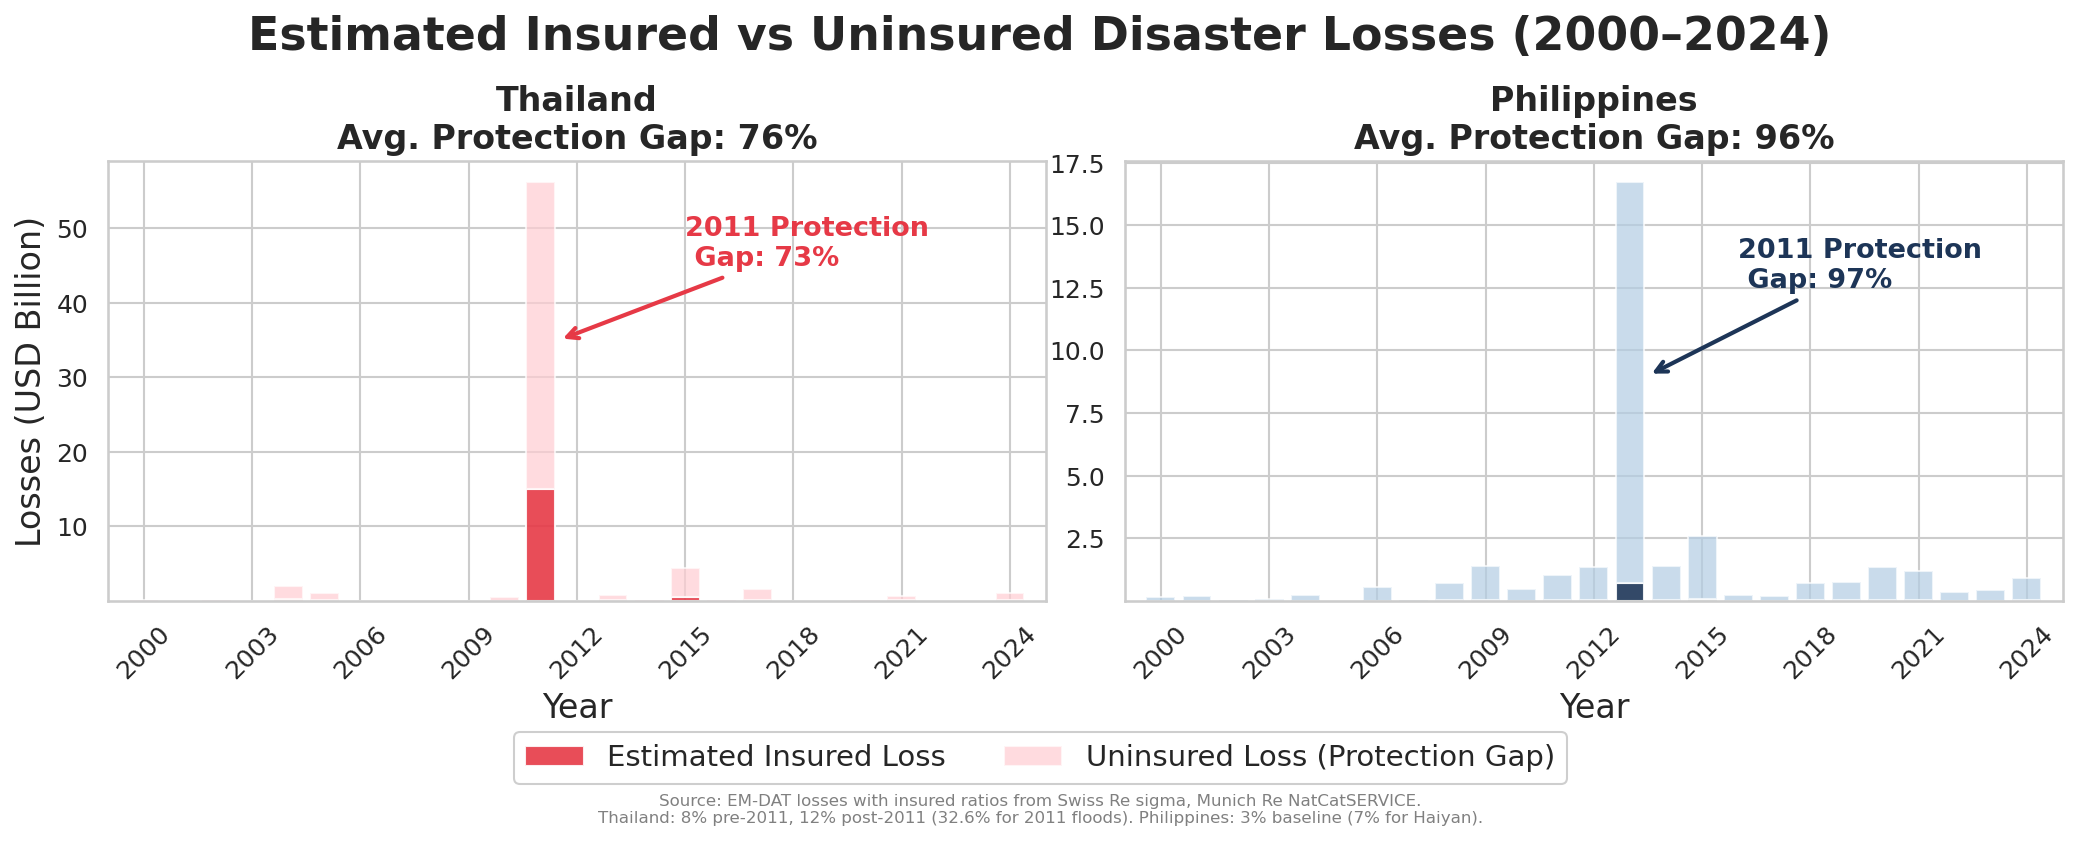

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, (country, sub, color, color_l) in zip(axes, [
    ('Thailand', THA_Gap, Colors['Thailand'], Colors_Light['Thailand']),
    ('Philippines', PHL_Gap, Colors['Philippines'], Colors_Light['Philippines'])
]):
    ax.bar(sub['Year'], sub['Insured_Est_M'] / 1000, color=color, alpha=0.9,
           label='Estimated Insured Loss')
    ax.bar(sub['Year'], sub['Uninsured_M'] / 1000, bottom=sub['Insured_Est_M'] / 1000,
           color=color_l, alpha=0.7, label='Uninsured Loss (Protection Gap)')
    
     # 2011 gap label
    Row_2011 = sub[sub['Year'] == 2011]
    if not Row_2011.empty:
        Econ_2011 = Row_2011['Econ_Loss_Adj_M'].values[0]
        Ins_2011  = Row_2011['Insured_Est_M'].values[0]
        Gap_2011  = (1 - Ins_2011 / Econ_2011) * 100 if Econ_2011 > 0 else 0
        Total_Bar = Econ_2011 / 1000
        
        if country == 'Thailand':
            xy_pos     = (2011.5, 35)              # ADJUST: arrow tip (Thailand)
            xytext_pos = (2015, 45)       # ADJUST: label position (Thailand)
        else:
            xy_pos     = (2013.5, 9)              # ADJUST: arrow tip (Philippines)
            xytext_pos = (2016, 12.5)       # ADJUST: label position (Philippines)
        
        ax.annotate(f'2011 Protection \n Gap: {Gap_2011:.0f}%',
                    xy=xy_pos, xytext=xytext_pos,
                    fontsize=13, fontweight='bold', color=color,
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
    
    Total_Econ = sub['Econ_Loss_Adj_M'].sum()
    Total_Ins  = sub['Insured_Est_M'].sum()
    Gap_Pct    = (1 - Total_Ins / Total_Econ) * 100 if Total_Econ > 0 else 0
    ax.set_title(f'{country}\nAvg. Protection Gap: {Gap_Pct:.0f}%', fontweight='bold', fontsize=16)
    ax.set_xlabel('Year', fontsize=16)
    ax.set_xlim(1999, 2025)
    ax.set_xticks(range(2000, 2025, 3))
    ax.tick_params(axis='x', rotation=45, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

axes[0].set_ylabel('Losses (USD Billion)', fontsize=16)

# Single shared legend at the bottom in one line
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', fontsize=14, ncol=2,
           framealpha=0.95, bbox_to_anchor=(0.5, -0.03))

fig.suptitle('Estimated Insured vs Uninsured Disaster Losses (2000\u20132024)',
             fontweight='bold', fontsize=22, y=0.92)
plt.figtext(0.5, -0.06,
    'Source: EM-DAT losses with insured ratios from Swiss Re sigma, Munich Re NatCatSERVICE.\n'
    'Thailand: 8% pre-2011, 12% post-2011 (32.6% for 2011 floods). Philippines: 3% baseline (7% for Haiyan).',
    ha='center', fontsize=8, color='gray')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(Output_WS3 / 'WS3_Protection_Gap.png', bbox_inches='tight')
plt.show()

**Interpretation:**
1. **Thailand (76% gap):** 
    * Driven almost entirely by the 2011 flood event where industrial all-risk policies absorbed $15B. 
    * Pre-2011 gap exceeds 90%; post-2011 reforms improved but did not close the gap. 
    * Thailand's protection gap is *episodic*, it narrows only when major commercial/industrial losses trigger claims.

2. **Philippines (96% gap):** 
    * Reflects chronically low insurance penetration (1.85% in Q3 2025). 
    * Fewer than 20% of Filipino households carry disaster-related property insurance. 
    * The OECD in February 2026 recommended mandatory home insurance, a potential inflection point.

**Reinsurer implication:** 
* Thailand presents episodic reinsurance exposure concentrated in industrial estates. 
* The Philippines presents a structural underinsurance problem where the addressable market is growing (GWP projected at 11.5% CAGR through 2030) but take-up remains low.

In [76]:
# Delete used-once variables from Step 3
del Total_Econ, Total_Ins, Gap_Pct, Te, Ti, Gp
del THA_Pre, THA_Post

## Step 4: WDI–Loss Linkage Analysis

This section tests whether the **same 7 indicators from WS1/WS2** are statistically associated with disaster outcomes. 

> The key insight is that these indicators serve **different roles** in WS2 (predicting emissions) versus WS3 (explaining disaster losses):

| Role in WS3 | Indicators | Mechanism |
|-------------|-----------|-----------|
| **Exposure drivers** | Urban %, Forest %, GDP/cap, Population | Directly linked to disaster losses: more people and assets in hazard zones, fewer natural buffers |
| **Emissions drivers** | Energy/cap, Renewable % | Linked to long-term climate trajectory; no direct mechanism for individual disaster events |
| **Vulnerability driver** | Agri VA % | Agricultural economies have more uninsured rural exposure |

**Expected finding:** Exposure drivers should show stronger correlations with disaster outcomes than emissions drivers. This is because the transmission from emissions to disasters operates over decades and globally, while exposure accumulation is local and immediate.

**Method:** Spearman rank correlation (robust to the 2011 Thai flood outlier).

### Step 4(A) Figure 4: Correlation Heatmap (7 WS2 Predictors vs Disaster Outcomes)

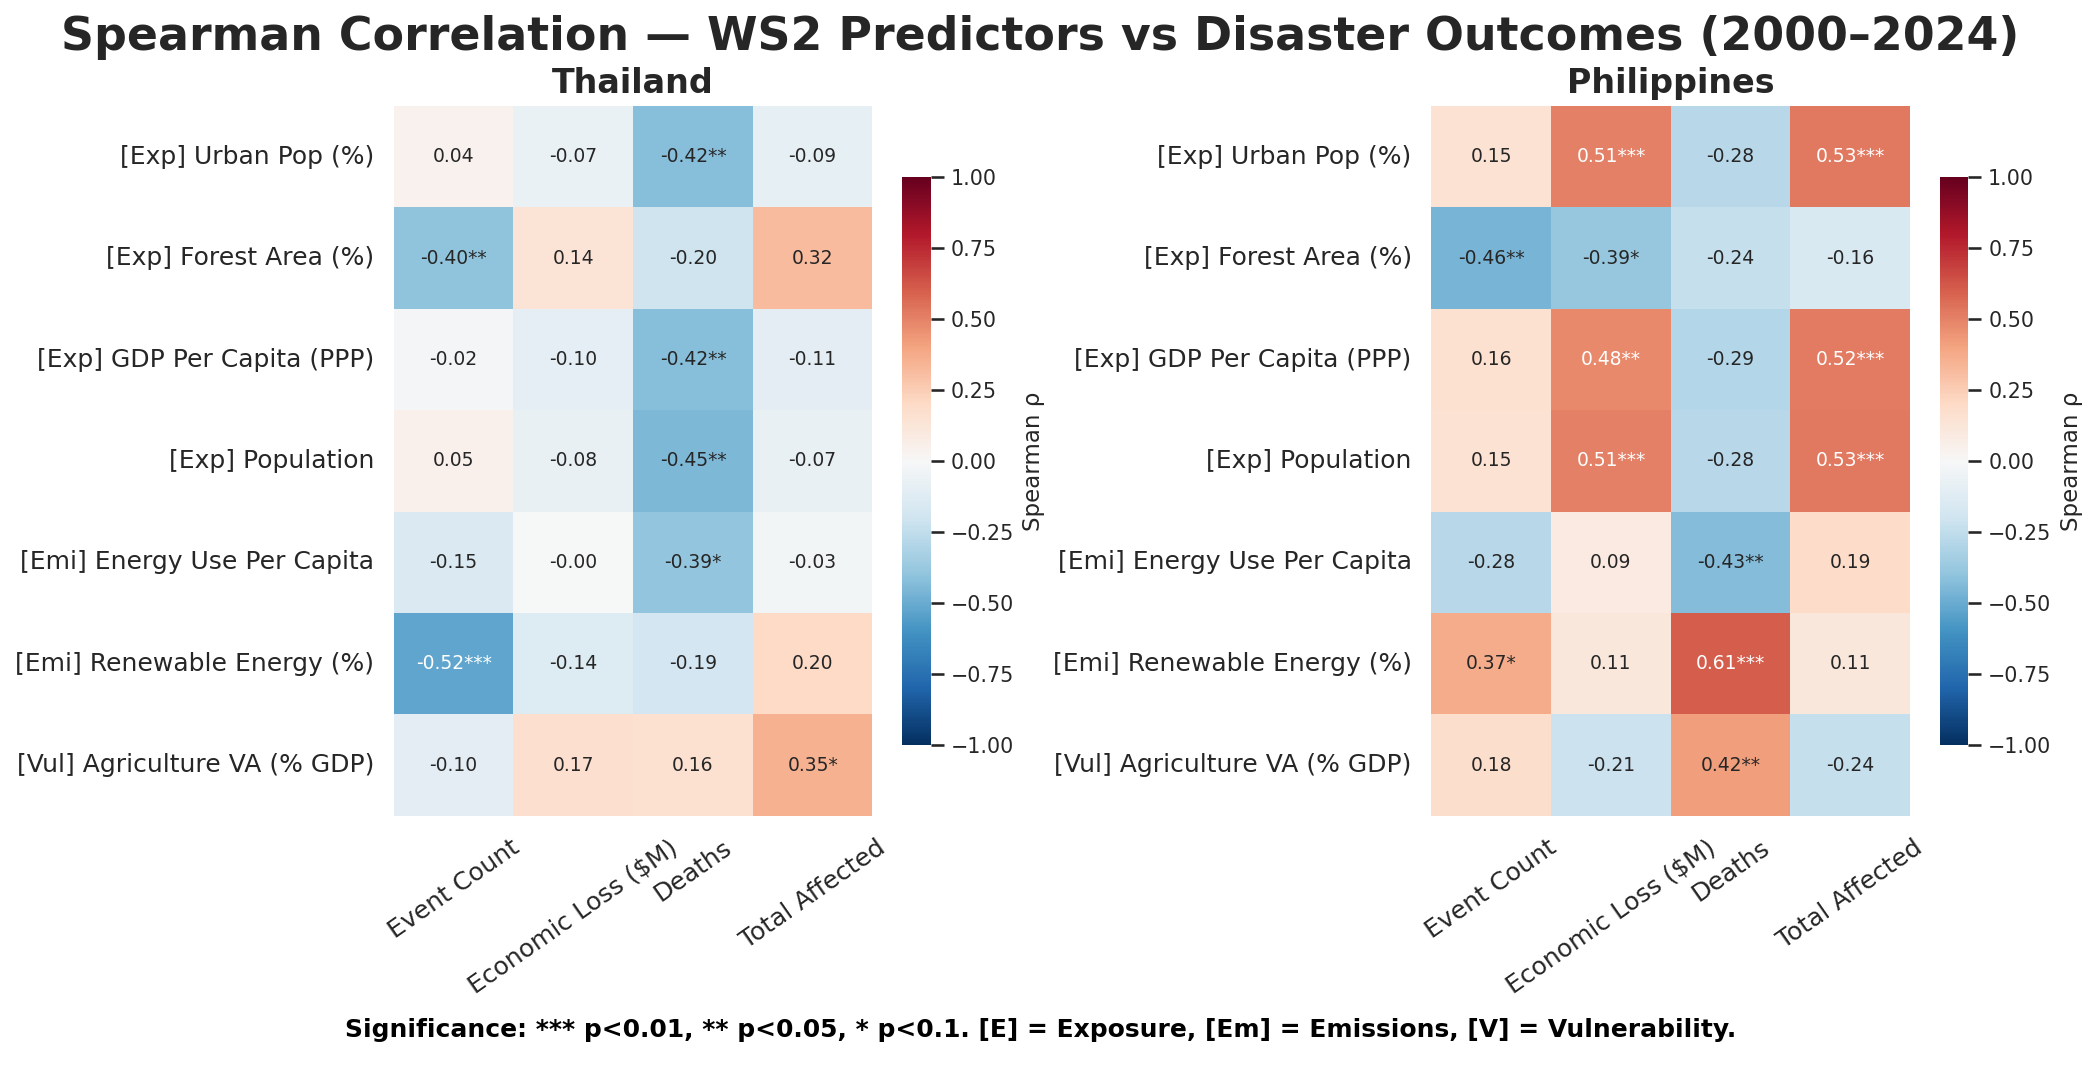

In [77]:
WDI_Cols   = WS2_Predictors  # Same 7 from WS1/WS2
WDI_Labels = [Indicator_Names[c] for c in WDI_Cols]

# Add role prefix for visual grouping
Role_Prefix = {
    'Exposure':      '[Exp]',
    'Emissions':     '[Emi]',
    'Vulnerability': '[Vul]',
}

WDI_Labels_Role = []
for c in WDI_Cols:
    Role = Role_Map[c]
    Name = Indicator_Names[c]
    WDI_Labels_Role.append(f'{Role_Prefix[Role]} {Name}')

Outcome_Cols   = ['Event_Count', 'Econ_Loss_Adj_M', 'Total_Deaths', 'Total_Affected']
Outcome_Labels = ['Event Count', 'Economic Loss ($M)', 'Deaths', 'Total Affected']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
Sig_Results = []

for ax, country in zip(axes, ['Thailand', 'Philippines']):
    Sub = Data[Data['Country'] == country]
    Corr_Data = np.zeros((len(WDI_Cols), len(Outcome_Cols)))
    Pval_Data = np.zeros((len(WDI_Cols), len(Outcome_Cols)))
    
    for i, wdi_c in enumerate(WDI_Cols):
        for j, out_c in enumerate(Outcome_Cols):
            Valid = Sub[[wdi_c, out_c]].dropna()
            if len(Valid) >= 5:
                r, p = stats.spearmanr(Valid[wdi_c], Valid[out_c])
                Corr_Data[i, j] = r
                Pval_Data[i, j] = p
            else:
                Corr_Data[i, j] = np.nan
                Pval_Data[i, j] = 1.0
    
    Corr_Df = pd.DataFrame(Corr_Data, index=WDI_Labels_Role, columns=Outcome_Labels)
    Annot   = np.empty_like(Corr_Data, dtype=object)
    for i in range(Corr_Data.shape[0]):
        for j in range(Corr_Data.shape[1]):
            v, p = Corr_Data[i, j], Pval_Data[i, j]
            Star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
            Annot[i, j] = f'{v:.2f}{Star}'
            if p < 0.05:
                Sig_Results.append({
                    'Country': country, 'Indicator': Indicator_Names[WDI_Cols[i]],
                    'Role': Role_Map[WDI_Cols[i]], 'Outcome': Outcome_Labels[j],
                    'Rho': v, 'P_Value': p
                })
    
    sns.heatmap(Corr_Df, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=Annot, fmt='', annot_kws={'size': 9},
                cbar_kws={'shrink': 0.8, 'label': 'Spearman \u03c1'})
    ax.set_title(f'{country}', fontweight='bold', fontsize=16)
    ax.tick_params(axis='x', rotation=35, labelsize=12)
    ax.tick_params(axis='y', rotation=0, labelsize=12)

fig.suptitle('Spearman Correlation \u2014 WS2 Predictors vs Disaster Outcomes (2000\u20132024)',
             fontweight='bold', fontsize=22, y=0.96)
plt.figtext(0.5, -0.04,
    'Significance: *** p<0.01, ** p<0.05, * p<0.1. [E] = Exposure, [Em] = Emissions, [V] = Vulnerability.\n',
    ha='center', fontsize=12, color='black', fontweight='bold')
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_Correlation_Heatmap.png')
plt.show()

In [78]:
# Print significant results grouped by role
print('\nStatistically significant correlations (p<0.05):')
Sig_Df = pd.DataFrame(Sig_Results)
if len(Sig_Df) > 0:
    for role in ['Exposure', 'Emissions', 'Vulnerability']:
        Role_Sig = Sig_Df[Sig_Df['Role'] == role]
        if len(Role_Sig) > 0:
            print(f'\n  {role} drivers:')
            for _, row in Role_Sig.iterrows():
                print(f'    {row["Country"]}: {row["Indicator"]} vs {row["Outcome"]}: ρ={row["Rho"]:.3f}, p={row["P_Value"]:.4f}')

    # Summary by role — normalised per predictor for fair comparison
    Predictor_Counts = {'Exposure': 4, 'Emissions': 2, 'Vulnerability': 1}
    N_Total = len(Sig_Df)


Statistically significant correlations (p<0.05):

  Exposure drivers:
    Thailand: Urban Pop (%) vs Deaths: ρ=-0.422, p=0.0354
    Thailand: Forest Area (%) vs Event Count: ρ=-0.399, p=0.0484
    Thailand: GDP Per Capita (PPP) vs Deaths: ρ=-0.422, p=0.0356
    Thailand: Population vs Deaths: ρ=-0.446, p=0.0254
    Philippines: Urban Pop (%) vs Economic Loss ($M): ρ=0.505, p=0.0100
    Philippines: Urban Pop (%) vs Total Affected: ρ=0.531, p=0.0063
    Philippines: Forest Area (%) vs Event Count: ρ=-0.462, p=0.0200
    Philippines: GDP Per Capita (PPP) vs Economic Loss ($M): ρ=0.477, p=0.0159
    Philippines: GDP Per Capita (PPP) vs Total Affected: ρ=0.519, p=0.0078
    Philippines: Population vs Economic Loss ($M): ρ=0.505, p=0.0100
    Philippines: Population vs Total Affected: ρ=0.531, p=0.0063

  Emissions drivers:
    Thailand: Renewable Energy (%) vs Event Count: ρ=-0.525, p=0.0071
    Philippines: Energy Use Per Capita vs Deaths: ρ=-0.435, p=0.0299
    Philippines: Renewable En

In [79]:

print(f'\n{"="*60}')
print(f'  ROLE SUMMARY (normalised per predictor)')
print(f'{"="*60}')
print(f'  Total significant indicator-outcome pairs: {N_Total} out of 56')
print(f'  {"Role":<22s} {"Pairs":>5s}   {"Predictors":>10s}   {"Avg per predictor":>18s}')
print(f'  {"-"*22} {"-"*5}   {"-"*10}   {"-"*18}')
for role in ['Exposure', 'Emissions', 'Vulnerability']:
    N = len(Sig_Df[Sig_Df['Role'] == role])
    P = Predictor_Counts[role]
    print(f'  {role:<22s} {N:>5d}   {P:>10d}   {N/P:>18.1f}')
print(f'\n  Even after adjusting for predictor count, exposure drivers')
print(f'  produce the most significant signals per predictor.')


  ROLE SUMMARY (normalised per predictor)
  Total significant indicator-outcome pairs: 15 out of 56
  Role                   Pairs   Predictors    Avg per predictor
  ---------------------- -----   ----------   ------------------
  Exposure                  11            4                  2.8
  Emissions                  3            2                  1.5
  Vulnerability              1            1                  1.0

  Even after adjusting for predictor count, exposure drivers
  produce the most significant signals per predictor.


### Step 4(B) Key Findings from Correlation Analysis

**Philippines (Exposure drivers show the clearest signals):**
- **Forest area decline: More events** 
    <br> ρ = −0.462, p=0.020 
    <br> Deforestation removes natural buffers.
- **Urban %, GDP/cap, Population: Higher losses and more affected** 
    <br> ρ = 0.477–0.531, p<0.02 
    <br> Exposure accumulation, more assets and people in hazard zones.

**Thailand (development reduces deaths, but losses are outlier-driven):**
- **Urban %, GDP/cap, Population negatively correlate with deaths** 
    <br> ρ = −0.422 to −0.446, p<0.04 
    <br> Development improves disaster resilience.
- **Forest recovery ↔ fewer events** 
    <br> ρ = −0.399, p=0.048 
- **Economic loss correlations are uniformly weak**
    <br> The 2011 flood outlier distorts everything.

**Emissions drivers: Statistically significant but not causal:**
- Thailand: Renewable % vs event count (ρ = −0.525, p=0.007)
    <br> Likely a time trend effect.
- Philippines: Renewable % vs deaths (ρ = 0.606, p=0.001)
    <br> Spurious; no mechanism links higher renewables to more deaths.
- Philippines: Energy/cap vs deaths (ρ = −0.435, p=0.030)
    <br> Development effect, same pattern as Thailand.

> WS2's strongest lever is Renewable % (emissions). <br> WS3's strongest signals are Forest % and Urban % (disaster losses). <br> The reinsurer should track **three leading indicators**: `renewable energy` (emissions trajectory), `forest area` (disaster buffer), `urbanisation` (exposure growth).

### Step 4(C) Figure 5: Scatter Plots (Strongest WDI–Loss Associations)

The heatmap (Figure 4) identifies statistically significant correlations. 

This chart directly visualises the four strongest associations. Each dot is one country-year observation, with regression lines fitted per country.

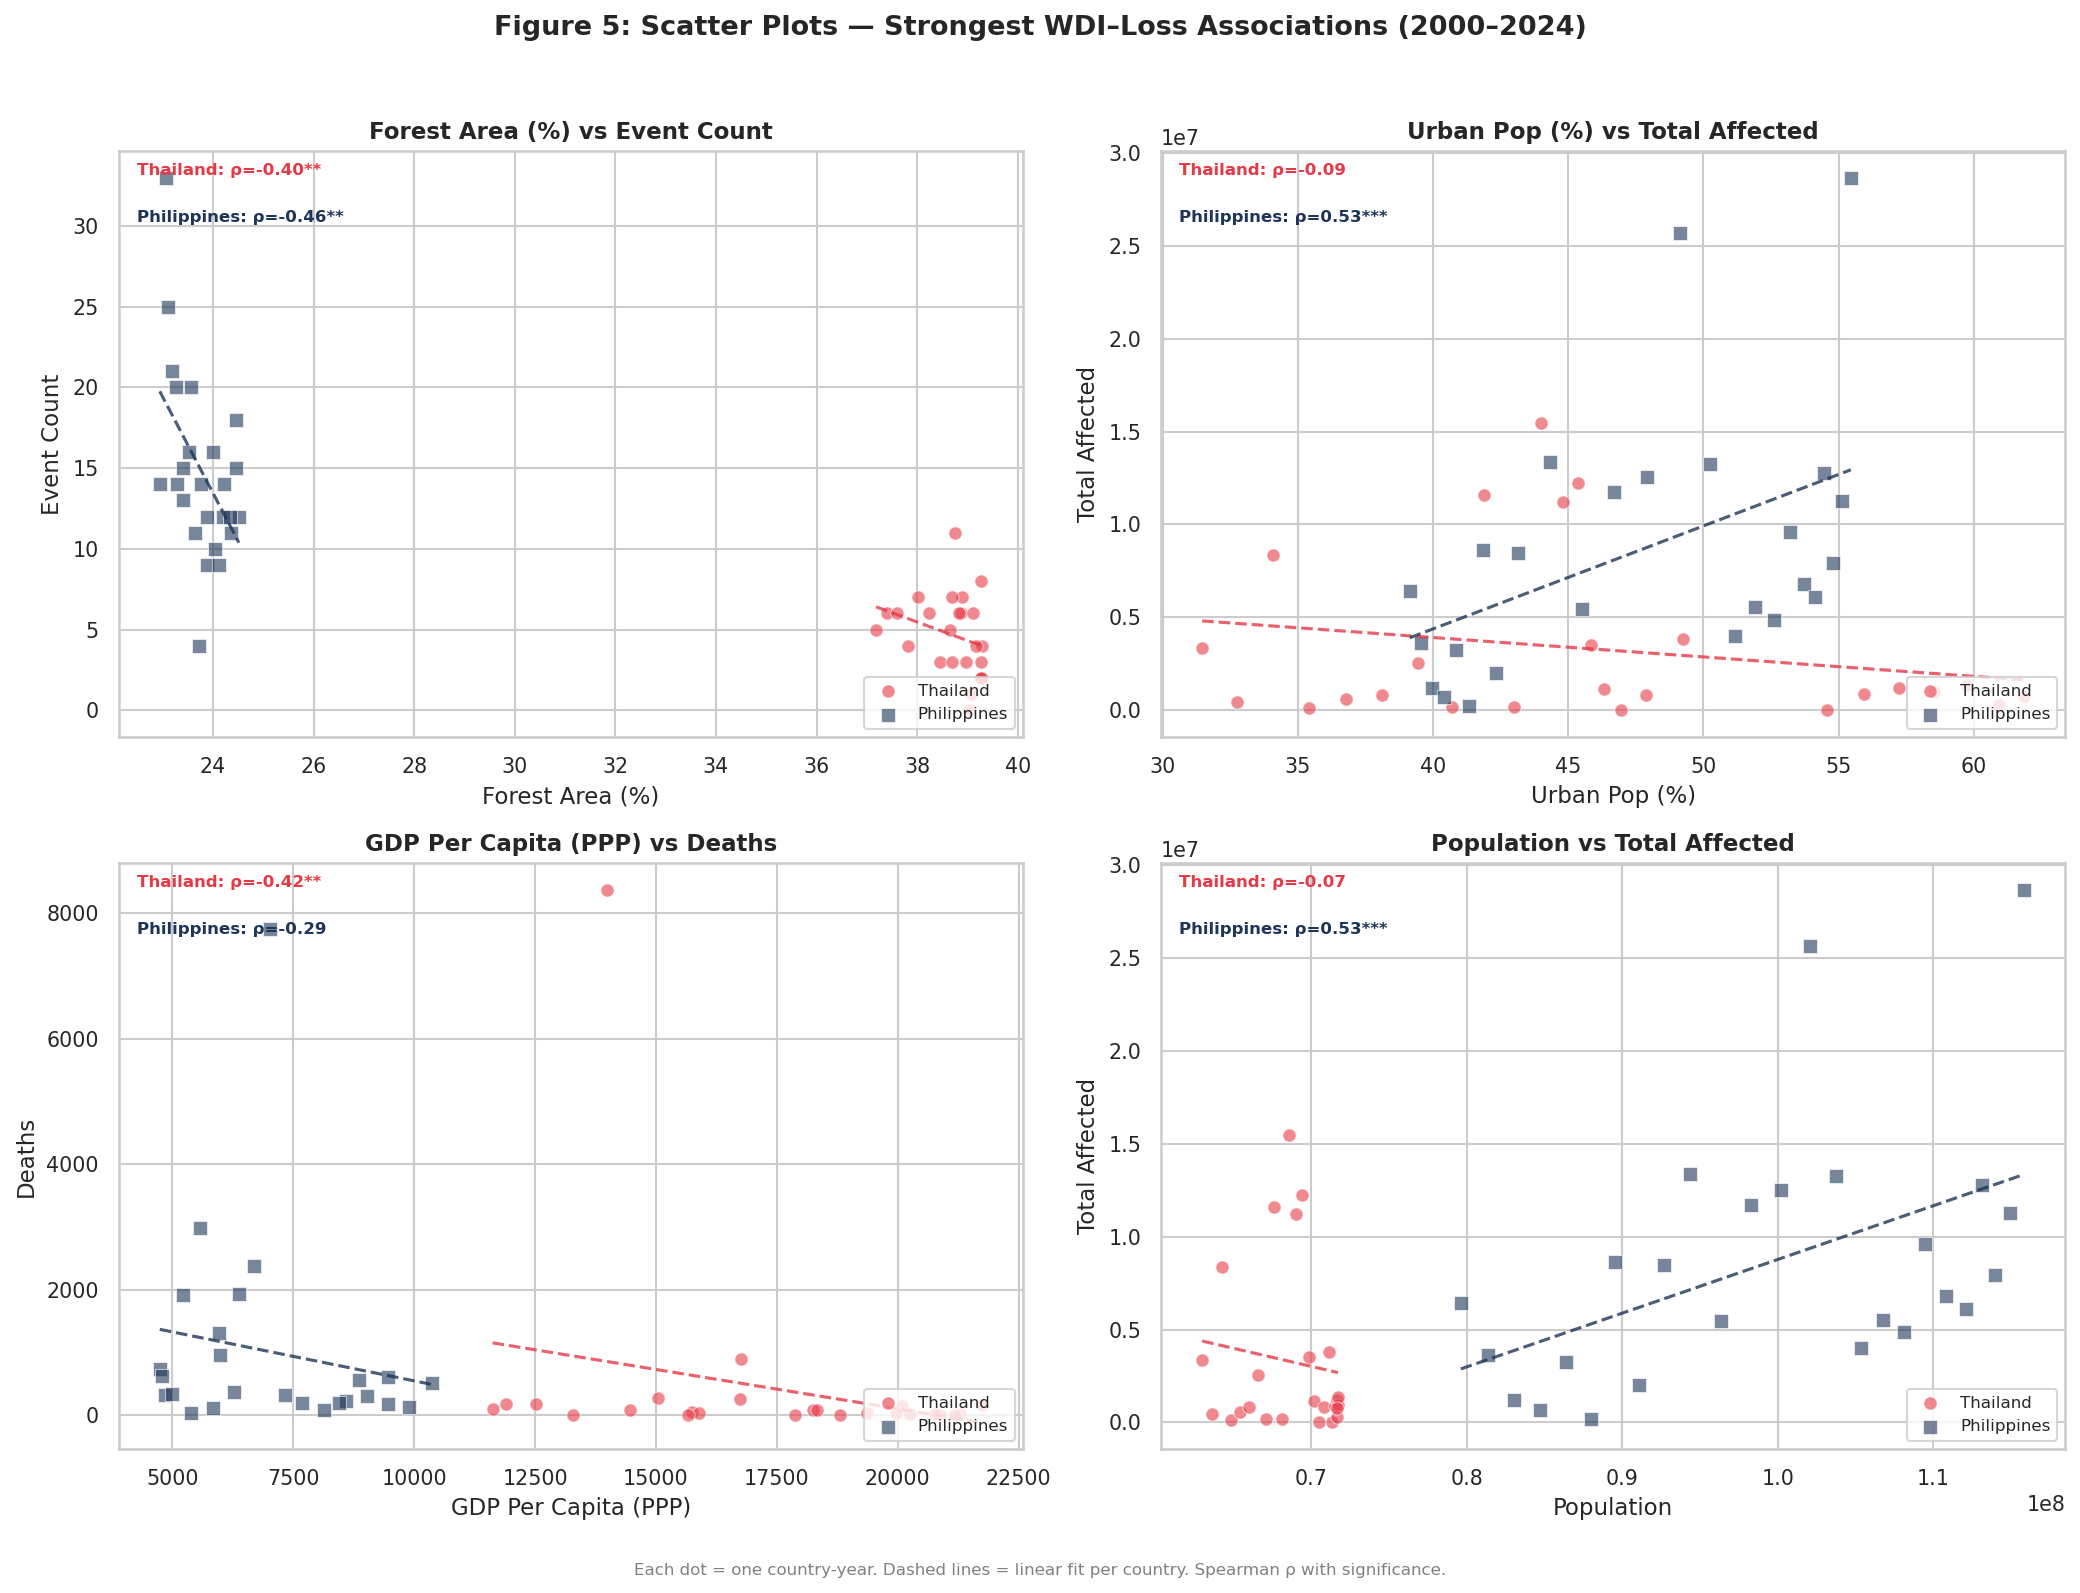

In [80]:
Scatter_Pairs = [
    ('Forest_%',           'Event_Count',      'Forest Area (%)',      'Event Count'),
    ('Urban_%',            'Total_Affected',    'Urban Pop (%)',        'Total Affected'),
    ('GDP_Per_Capita_PPP', 'Total_Deaths',      'GDP Per Capita (PPP)', 'Deaths'),
    ('Population',         'Total_Affected',    'Population',           'Total Affected'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (Wdi_Col, Out_Col, X_Label, Y_Label) in enumerate(Scatter_Pairs):
    ax = axes.flatten()[idx]
    
    for Country, Sub, Color, Marker in [
        ('Thailand',    THA, Colors['Thailand'],    'o'),
        ('Philippines', PHL, Colors['Philippines'],  's'),
    ]:
        Valid = Sub[[Wdi_Col, Out_Col]].dropna()
        if len(Valid) < 3:
            continue
        
        ax.scatter(Valid[Wdi_Col], Valid[Out_Col], color=Color, marker=Marker,
                   s=40, alpha=0.6, label=Country, edgecolors='white', linewidth=0.5)
        
        # Regression line
        x = Valid[Wdi_Col].values
        y = Valid[Out_Col].values
        z = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), '--', color=Color, linewidth=1.5, alpha=0.8)
        
        # Spearman correlation annotation
        r, p = stats.spearmanr(x, y)
        Star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        ax.annotate(f'{Country}: ρ={r:.2f}{Star}',
                    xy=(0.02, 0.98 - 0.08 * (0 if Country == 'Thailand' else 1)),
                    xycoords='axes fraction', fontsize=8, color=Color,
                    verticalalignment='top', fontweight='bold')
    
    ax.set_xlabel(X_Label)
    ax.set_ylabel(Y_Label)
    ax.set_title(f'{X_Label} vs {Y_Label}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Figure 5: Scatter Plots — Strongest WDI–Loss Associations (2000–2024)',
             fontweight='bold', fontsize=13, y=1.02)
plt.figtext(0.5, -0.02,
    'Each dot = one country-year. Dashed lines = linear fit per country. Spearman ρ with significance.',
    ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_Scatter_WDI_Loss.png')
plt.show()

## Step 5: Portfolio Implications & Summary Dashboard

### Figure 6: Summary Dashboard

A 6-data dashboard synthesising the key metrics for the reinsurer. 
* The top row shows disaster outcomes. 
* The bottom row shows the three recommended monitoring indicators from WS2/WS3.

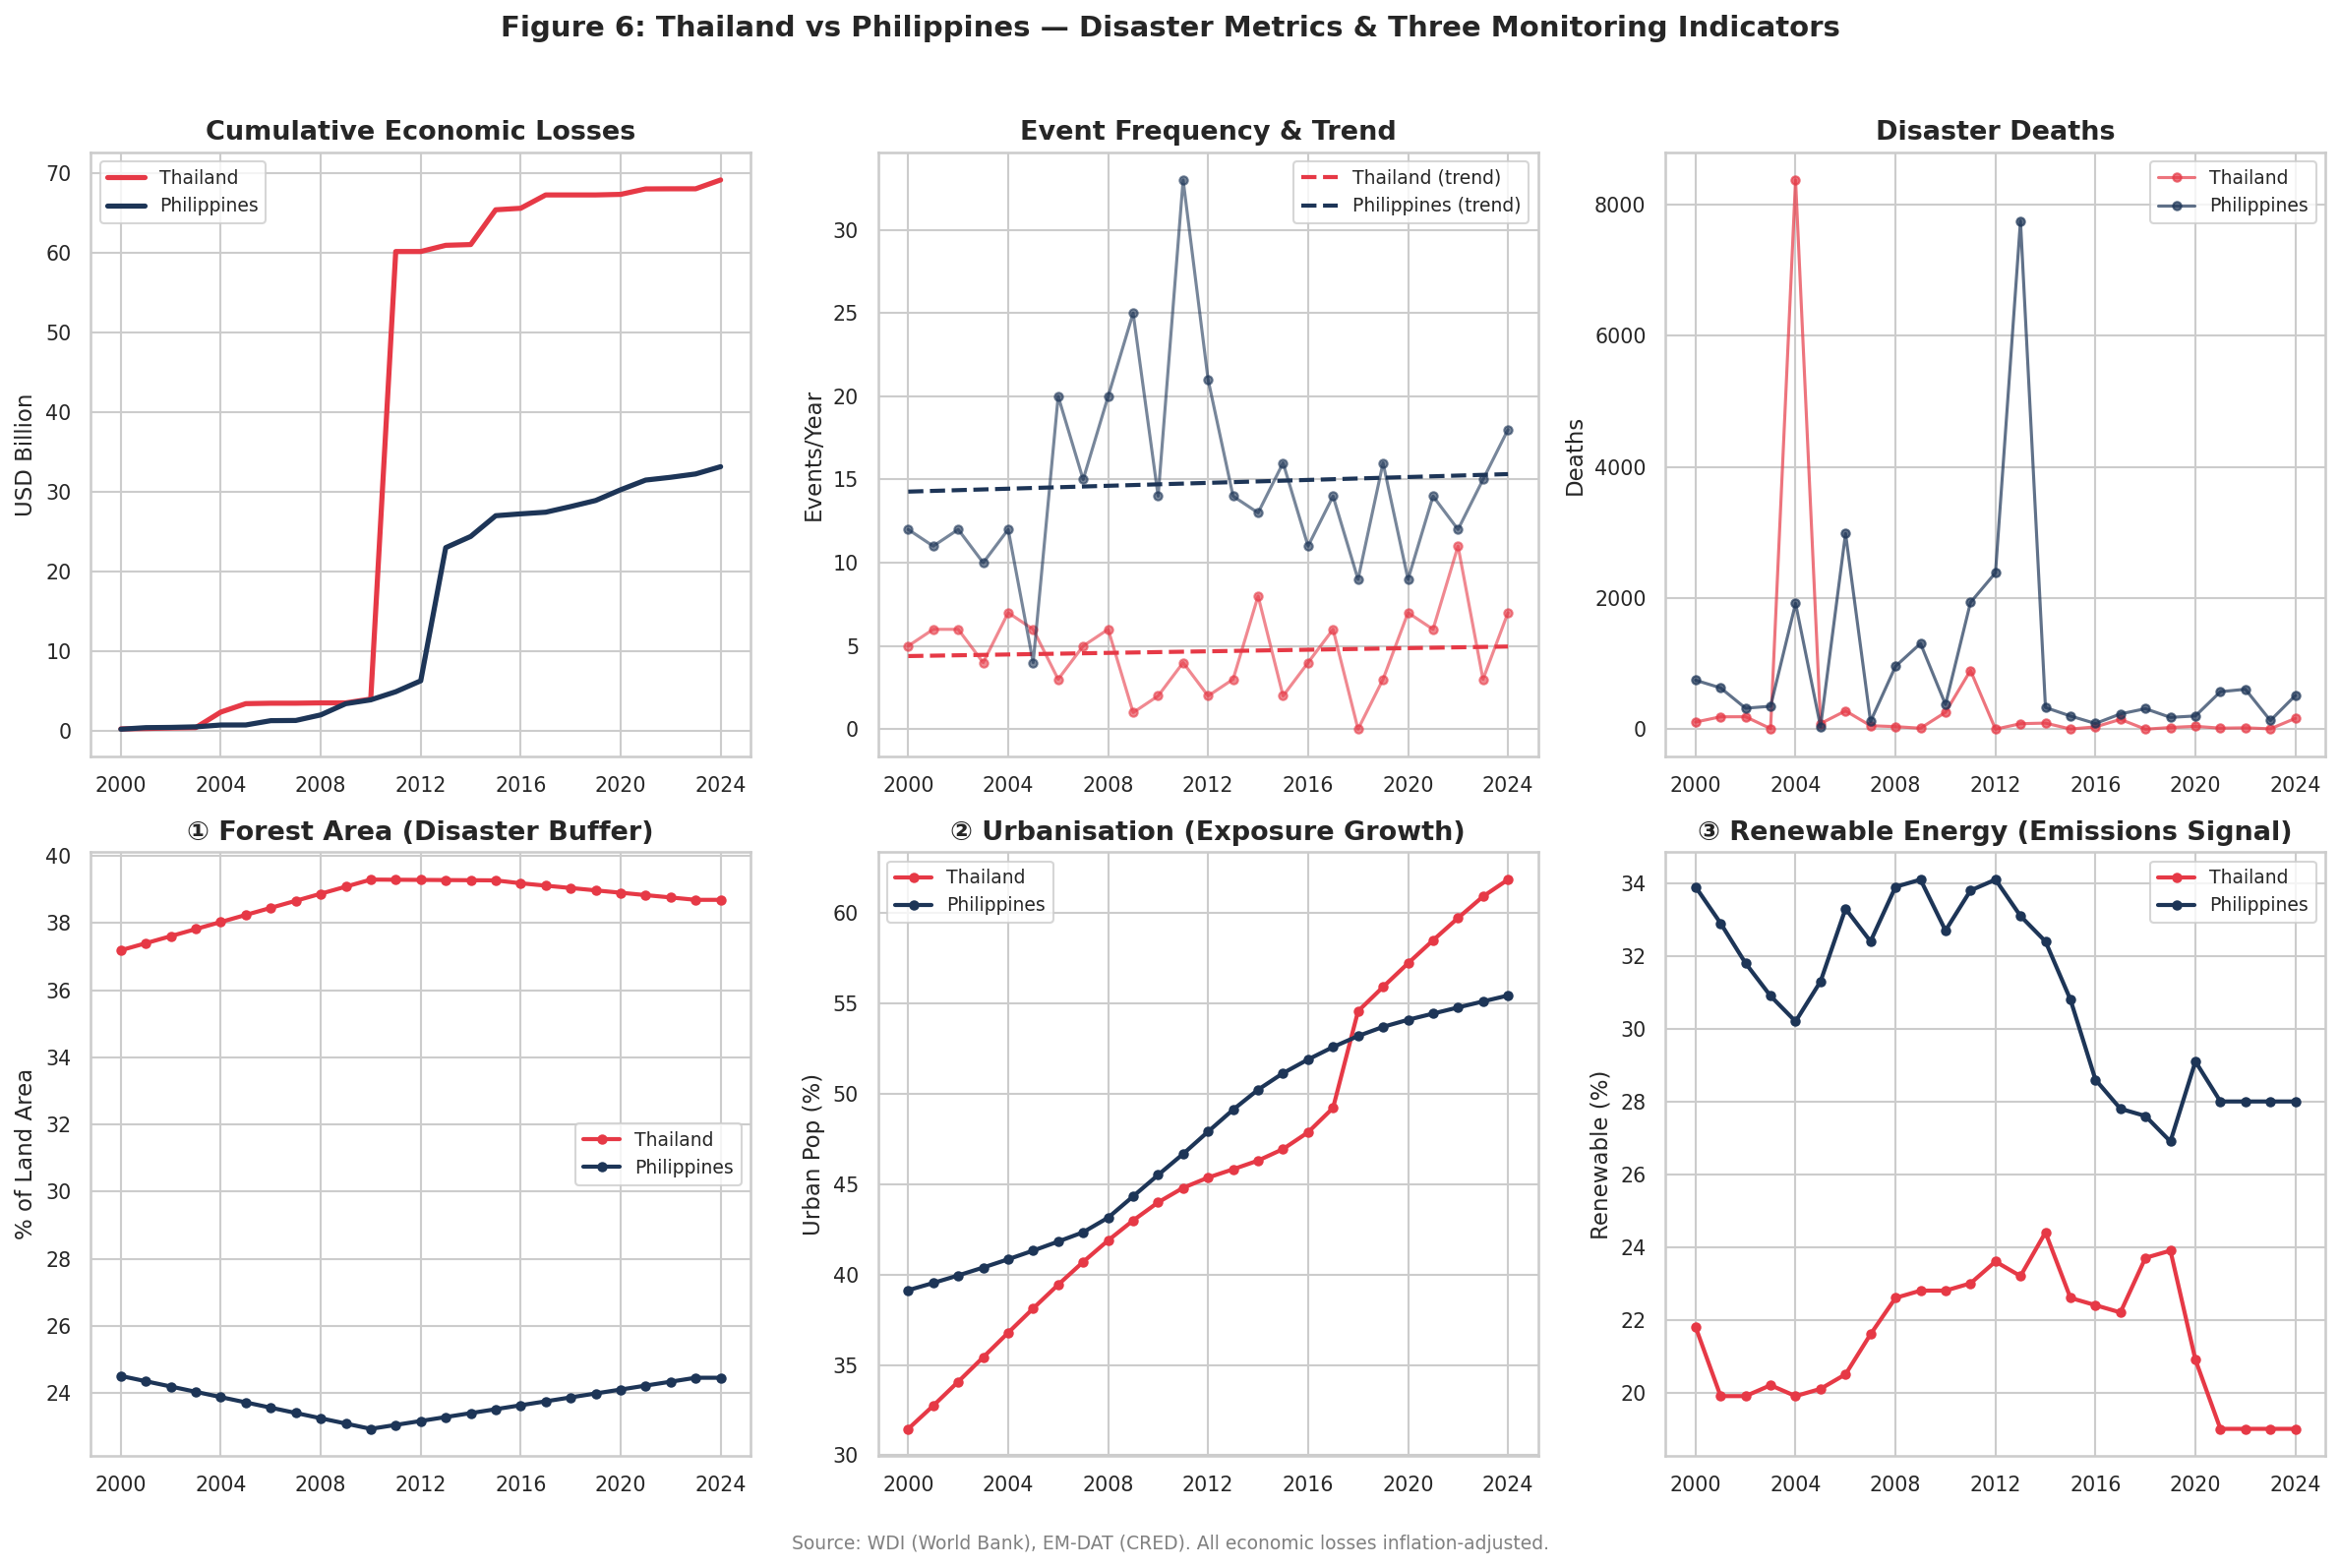

In [81]:
# ============================================================
# FIGURE 6: Summary Dashboard
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Row 1: Disaster Outcomes ─────────────────────────────────

# 1. Cumulative losses
ax = axes[0, 0]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    ax.plot(s['Year'], s['Econ_Loss_Adj_M'].cumsum() / 1000, '-', color=col, linewidth=2.5, label=c)
ax.set_title('Cumulative Economic Losses', fontweight='bold'); ax.set_ylabel('USD Billion'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

# 2. Event frequency with trend
ax = axes[0, 1]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    ax.plot(s['Year'], s['Event_Count'], 'o-', color=col, linewidth=1.5, markersize=4, alpha=0.6)
    z = np.polyfit(s['Year'], s['Event_Count'], 1)
    ax.plot(s['Year'], np.polyval(z, s['Year']), '--', color=col, linewidth=2, label=f'{c} (trend)')
ax.set_title('Event Frequency & Trend', fontweight='bold'); ax.set_ylabel('Events/Year'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

# 3. Deaths trend (replaces Loss per Event)
ax = axes[0, 2]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    ax.plot(s['Year'], s['Total_Deaths'], 'o-', color=col, linewidth=1.5, markersize=4, alpha=0.7, label=c)
ax.set_title('Disaster Deaths', fontweight='bold'); ax.set_ylabel('Deaths'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

# ── Row 2: Three Monitoring Indicators (from WS2/WS3) ────────

# 4. Forest Area
ax = axes[1, 0]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    v = s[s['Forest_%'].notna()]
    ax.plot(v['Year'], v['Forest_%'], 'o-', color=col, linewidth=2, markersize=4, label=c)
ax.set_title('\u2460 Forest Area (Disaster Buffer)', fontweight='bold'); ax.set_ylabel('% of Land Area'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

# 5. Urban Population
ax = axes[1, 1]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    ax.plot(s['Year'], s['Urban_%'], 'o-', color=col, linewidth=2, markersize=4, label=c)
ax.set_title('\u2461 Urbanisation (Exposure Growth)', fontweight='bold'); ax.set_ylabel('Urban Pop (%)'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

# 6. Renewable Energy
ax = axes[1, 2]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    v = s[s['Renewable_%'].notna()]
    ax.plot(v['Year'], v['Renewable_%'], 'o-', color=col, linewidth=2, markersize=4, label=c)
ax.set_title('\u2462 Renewable Energy (Emissions Signal)', fontweight='bold'); ax.set_ylabel('Renewable (%)'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

fig.suptitle('Figure 6: Thailand vs Philippines \u2014 Disaster Metrics & Three Monitoring Indicators',
             fontweight='bold', fontsize=14, y=1.02)
plt.figtext(0.5, -0.02, 'Source: WDI (World Bank), EM-DAT (CRED). All economic losses inflation-adjusted.',
            ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_Summary_Dashboard.png')
plt.show()

## Step 6: Export

Save outputs for the dashboard. 

In [82]:
# 1. Merged data dataset (for dashboard and submission)
Data.to_csv(Data_Path / 'WS3_Data_THA_PHL.csv', index=False)

# 2. Protection gap data (for dashboard)
Gap_Export = pd.concat([
    THA_Gap[['Country', 'Year', 'Econ_Loss_Adj_M', 'Insured_Est_M', 'Uninsured_M', 'Insured_Ratio']],
    PHL_Gap[['Country', 'Year', 'Econ_Loss_Adj_M', 'Insured_Est_M', 'Uninsured_M', 'Insured_Ratio']]
])
Gap_Export.to_csv(Data_Path / 'WS3_Protection_Gap.csv', index=False)

# 3. Correlation results (for dashboard/report reference)
Sig_Df.to_csv(Data_Path / 'WS3_Significant_Correlations.csv', index=False)

print('=' * 60)
print('     STEP 6: EXPORTS SAVED')
print('=' * 60)
print(f'  1. {Data_Path / "WS3_Data_THA_PHL.csv"}')
print(f'     Shape: {Data.shape}')
print(f'  2. {Data_Path / "WS3_Protection_Gap.csv"}')
print(f'     Shape: {Gap_Export.shape}')
print(f'  3. {Data_Path / "WS3_Significant_Correlations.csv"}')
print(f'     Significant correlations: {len(Sig_Df)}')

     STEP 6: EXPORTS SAVED
  1. /Users/entong/Desktop/MASAHKT2026/Model/Data/WS3_Data_THA_PHL.csv
     Shape: (50, 29)
  2. /Users/entong/Desktop/MASAHKT2026/Model/Data/WS3_Protection_Gap.csv
     Shape: (50, 6)
  3. /Users/entong/Desktop/MASAHKT2026/Model/Data/WS3_Significant_Correlations.csv
     Significant correlations: 15


## WS3 Complete — Handoff to WS5

**Country pair:** Thailand vs Philippines

**For Report & Dashboard:**
1. `WS3_Data_THA_PHL.csv` — merged WDI + EM-DAT data
2. `WS3_Protection_Gap.csv` — insured vs uninsured loss estimates
3. `WS3_Significant_Correlations.csv` — significant Spearman correlations
4. Figures 1–6 saved in `Output_WS3/`

# Workstream 4: Stress Test & Mitigation Scenario

**Target:** Total GHG excl LULUCF (Mt CO₂e)
<br> **Countries:** Thailand (THA) & Philippines (PHL)
<br> **Horizon:** Project from 2024 baseline to 2030
<br> **Scenarios:** Business-as-usual (BAU) vs NDC-aligned mitigation
<br> **Model:** Fixed-effects data regression coefficients from WS2

**Output:** BAU and mitigation GHG projections, decomposition by lever, sensitivity analysis, NDC cross-check

| Step | What | Output |
|------|------|--------|
| **1 Data Preparation** | (A) Load WS2 exports; <br>(B) Load data, filter THA & PHL; <br>(C) Verify FE formula; compute 2024 residual anchor; <br>(D) Estimate coal overlay coefficient (FWL) | `Coefs`, `Country_Means`, `Data`, `Residual_Ln`, `Beta_Coal` |
| **2 BAU Projections** | (A) Fit linear trends (2017–2024 excl COVID); <br>(B) Extrapolate predictors to 2030; <br>(C) Apply FE formula → BAU path | `Bau` dataframe |
| **3 NDC Mitigation Scenario** | (A) Define mitigation assumptions; <br>(B) Override 4 levers (RE, Energy, Forest, Coal); <br>(C) Apply FE formula → mitigation path; <br>(D) Compare BAU vs mitigation | `Mit` dataframe, summary table, line chart |
| **4 Decomposition & Sensitivity** | (A) Isolate each lever's contribution; <br>(B) ±20% sensitivity per assumption | `Decomp`, `Sensitivity` tables, stacked bar, tornado chart |
| **4.5 Delayed-Transition Stress** | (A) Define downside shocks vs BAU; <br>(B) Build stress predictor table; <br>(C) Apply FE formula → stress path; <br>(D) Three-scenario summary; <br>(E) Fan chart; <br>(F) Stylised insured-loss layer | `Stress` dataframe, `Stress_Summary`, fan chart |
| **5 NDC Cross-Check & Implications** | (A) Compare to official NDC targets; <br>(B) Financial implications (TCFD / IFRS S2) | Summary print output |
| **6 Export** | Save projections, summaries, charts | CSVs + PNGs |

## Setup
* Import libraries
* Set plotting style and colour codes
* Define constants: target, predictors, log-transform list, country mapping

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Plot styling 
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 180,
    'savefig.bbox': 'tight',
    'figure.facecolor': 'white',
})

Colors = {'Thailand': '#E63946', 'Philippines': '#1D3557'}
Colors_Light = {'Thailand': '#FFCDD2', 'Philippines': '#B3CDE3'}
Scenario_Colors = {'BAU': '#7f8c8d', 'Mitigation': '#27ae60'}

# Country mapping
Country_Map = {'THA': 'Thailand', 'PHL': 'Philippines'}
Focus_Countries = ['THA', 'PHL']

# --- Column name conventions ---
# RAW columns: 7 predictors, EXACTLY matching WS2 (no coal in this list)
Raw_Cols = ['Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Capita',
            'Renewable_%', 'Urban_%', 'Forest_%', 'Agri_VA_%']

# Variables that are log-transformed before entering the model
Log_Vars = ['Population', 'GDP_Per_Capita_PPP', 'Energy_Per_Capita']

# MODEL columns: what WS2 actually uses (ln_ prefix for logged variables)
# These match the Variable column in WS2_Coefficients.csv and
# the column headers in WS2_Country_Means_X.csv
Model_Cols = [f'ln_{col}' if col in Log_Vars else col for col in Raw_Cols]

# Coal_Elec_% is the OVERLAY variable. Not part of WS2's 7 predictors.
# Estimated separately in Step 1(D) and applied multiplicatively to scenario
# predictions (BAU coal stays at baseline -> overlay has no effect at BAU).
Overlay_Var = 'Coal_Elec_%'


# Predictor display names for charts
Pred_Labels = {
    'Population':         'Population',
    'GDP_Per_Capita_PPP': 'GDP Per Capita (PPP)',
    'Energy_Per_Capita':  'Energy Use Per Capita',
    'Renewable_%':        'Renewable Energy (%)',
    'Urban_%':            'Urban Pop (%)',
    'Forest_%':           'Forest Area (%)',
    'Agri_VA_%':          'Agriculture VA (% GDP)',
    'Coal_Elec_%':        'Coal % Electricity',
}

# Projection years
Proj_Years = list(range(2025, 2031))

# Trend fitting window: 2017–2024 excluding COVID years
Trend_Years = [2017, 2018, 2019, 2022, 2023, 2024]

print('Setup complete.')


Setup complete.


## Helper Functions

- **`FE_Predict_Single`** — Predict ln(GHG) using FE model: y_hat = y_bar(train) + B_hat . (X - X_bar(train))
- **`Fit_Trend`** — Fit a linear trend on the non-COVID window and extrapolate to projection years
- **`Raw_To_Model`** — Convert raw predictor dict to model-space array (log where needed)
- **`Predict_Ghg_Mt`** — End-to-end: raw predictor dict to GHG in Mt CO2e
- **`Predict_Ghg_Mt_Adjusted`** — Same as above but adds 2024 ln-scale residual so projections anchor to the actual level, not the model's fitted level

In [84]:

def FE_Predict_Single(x_model, coefs, y_bar, x_bar):
    """Predict ln(GHG) for a single observation using FE formula.
    All inputs must be in MODEL SPACE (already log-transformed where needed).
    y_hat = y_bar(train) + B_hat . (X_model - X_bar_model(train))
    """
    return y_bar + coefs @ (x_model - x_bar)


def Fit_Trend(series, trend_years, proj_years):
    """Fit linear trend on non-COVID years, extrapolate to projection years.
    Operates on RAW (original-scale) data.
    Returns dict: {year: projected_value} for all projection years.
    """
    sub = series[series.index.isin(trend_years)].dropna()
    if len(sub) < 3:
        last_val = series.dropna().iloc[-1]
        return {y: last_val for y in proj_years}

    X = sub.index.values.reshape(-1, 1)
    y = sub.values
    Reg = LinearRegression().fit(X, y)

    return {y_: Reg.predict([[y_]])[0] for y_ in proj_years}


def Raw_To_Model(raw_dict):
    """Convert a dict of {raw_col: raw_value} to a model-space numpy array.
    Log-transforms variables in Log_Vars; leaves percentages as-is.
    Returns array in Model_Cols order.
    """
    row = []
    for col in Raw_Cols:
        val = raw_dict[col]
        if col in Log_Vars:
            row.append(np.log(max(val, 1e-6)))
        else:
            row.append(val)
    return np.array(row)


def Predict_Ghg_Mt(raw_dict, coefs, y_bar, x_bar):
    """End-to-end: raw predictor dict -> GHG in Mt CO2e.
    Handles log transform and FE prediction in one call.
    """
    x_model = Raw_To_Model(raw_dict)
    ln_ghg = FE_Predict_Single(x_model, coefs, y_bar, x_bar)
    return np.exp(ln_ghg)

def Predict_Ghg_Mt_Adjusted(raw_dict, coefs, y_bar, x_bar, residual_ln):
    """Same as Predict_Ghg_Mt but adds a level adjustment (ln-scale residual)
    so projections anchor to the 2024 actual, not the model's fitted level.
    """
    x_model = Raw_To_Model(raw_dict)
    ln_ghg = FE_Predict_Single(x_model, coefs, y_bar, x_bar)
    return np.exp(ln_ghg + residual_ln)


def Predict_Ghg_With_Coal(raw_dict, coal_value, coefs, y_bar, x_bar,
                          residual_ln, beta_coal, coal_baseline):
    """Adjusted prediction with COAL OVERLAY applied multiplicatively.

    GHG_with_coal = GHG_WS2 * exp(beta_coal * (coal_value - coal_baseline))

    At BAU (coal_value == coal_baseline) the overlay = 1, so predictions
    match WS2 exactly. Only mitigation/stress (where coal differs from
    baseline) diverge.
    """
    x_model = Raw_To_Model(raw_dict)
    ln_ghg = FE_Predict_Single(x_model, coefs, y_bar, x_bar)
    ln_overlay = beta_coal * (coal_value - coal_baseline)
    return np.exp(ln_ghg + residual_ln + ln_overlay)


print('Helpers ready.')


Helpers ready.


## Step 1: Data Preparation

### Step 1(A) Load WS2 Exports
Load the coefficient table and country means from WS2.
* WS2 stores coefficients and country means in **model space** (ln_ prefix for logged variables).
* We extract the coefficient vector in `Model_Cols` order.

<br> These are the inputs for the FE prediction formula: 
> ŷᵢₜ = ȳᵢ(train) + β̂ · (Xᵢₜ − X̄ᵢ(train))

In [85]:
# (A) Load WS2 exports
Coef_Df = pd.read_csv(Data_Path / 'WS2_Coefficients.csv')
Country_Means_y = pd.read_csv(Data_Path / 'WS2_Country_Means_Y.csv',
                              index_col=0, header=0).squeeze()
Country_Means_X = pd.read_csv(Data_Path / 'WS2_Country_Means_X.csv',
                              index_col=0)

# Extract coefficient vector in Model_Cols order
Coef_Map = dict(zip(Coef_Df['Variable'], Coef_Df['Coefficient']))
Coefs = np.array([Coef_Map[c] for c in Model_Cols])

# Country means X columns should match Model_Cols
assert list(Country_Means_X.columns) == Model_Cols, (
    f'Column mismatch:\n  Expected: {Model_Cols}\n  Got:      {list(Country_Means_X.columns)}')

print('=' * 72)
print('   STEP 1(A) WS2 EXPORTS LOADED')
print('=' * 72)
print(f'Coefficients loaded: {len(Coefs)} predictors')
print(f'Country means: {len(Country_Means_y)} countries')
print()
print('Coefficient vector (Model_Cols order):')
for mcol, rcol, coef in zip(Model_Cols, Raw_Cols, Coefs):
    print(f'  {mcol:<30s} ({rcol:<25s}) {coef:+.4f}')
print()
print('Focus country means (y_bar from training):')
for code in Focus_Countries:
    print(f'  {code}: y_bar = {Country_Means_y[code]:.4f}  '
          f'(approx {np.exp(Country_Means_y[code]):.1f} Mt CO2e)')

   STEP 1(A) WS2 EXPORTS LOADED
Coefficients loaded: 7 predictors
Country means: 130 countries

Coefficient vector (Model_Cols order):
  ln_Population                  (Population               ) +0.6934
  ln_GDP_Per_Capita_PPP          (GDP_Per_Capita_PPP       ) +0.2275
  ln_Energy_Per_Capita           (Energy_Per_Capita        ) +0.4547
  Renewable_%                    (Renewable_%              ) -0.0105
  Urban_%                        (Urban_%                  ) -0.0045
  Forest_%                       (Forest_%                 ) -0.0012
  Agri_VA_%                      (Agri_VA_%                ) +0.0017

Focus country means (y_bar from training):
  THA: y_bar = 5.8677  (approx 353.4 Mt CO2e)
  PHL: y_bar = 5.0731  (approx 159.7 Mt CO2e)


### Step 1(B) Load Data Data
Load the imputed data from WS1 and filter to Thailand and Philippines.

In [86]:
# (B) Load WS1 data, filter to focus countries
Data = pd.read_csv(Data_Path / Data_Filename)

# If Coal_Elec_% is not in the WS1 data, pull it from raw WDI and merge
if 'Coal_Elec_%' not in Data.columns:
    print('Coal_Elec_% not found in WS1 data - pulling from raw WDI...')
    Raw_WDI_Filename = 'WB_WDI_WIDEF.csv'
    raw_wdi_path = Data_Path / Raw_WDI_Filename
    if not raw_wdi_path.exists():
        raise FileNotFoundError(
            f"Need raw WDI file at: {raw_wdi_path}\n"
            f"Place WB_WDI_WIDEF.csv in your Data folder, or re-run WS1 to "
            f"include Coal_Elec_% (WB_WDI_EG_ELC_COAL_ZS) in the imputed data."
        )
    year_cols_str = [str(y) for y in range(2000, 2025)]
    usecols = ['REF_AREA', 'INDICATOR'] + year_cols_str
    coal_chunks = []
    for chunk in pd.read_csv(raw_wdi_path, usecols=usecols,
                             low_memory=False, chunksize=50_000):
        keep = chunk[chunk['INDICATOR'] == 'WB_WDI_EG_ELC_COAL_ZS']
        if len(keep) > 0:
            coal_chunks.append(keep)
    coal_raw = pd.concat(coal_chunks, ignore_index=True)
    coal_long = coal_raw.melt(id_vars=['REF_AREA'], value_vars=year_cols_str,
                              var_name='Year', value_name='Coal_Elec_%')
    coal_long['Year'] = coal_long['Year'].astype(int)
    coal_long = coal_long.rename(columns={'REF_AREA': 'Ref_Area'})
    coal_long = coal_long[coal_long['Ref_Area'].str.len() == 3]
    Data = Data.merge(coal_long, on=['Ref_Area', 'Year'], how='left')
    Data = Data.sort_values(['Ref_Area', 'Year'])
    Data['Coal_Elec_%'] = Data.groupby('Ref_Area')['Coal_Elec_%'].transform(
        lambda s: s.interpolate(limit=2).ffill(limit=2).bfill(limit=2))
    print(f'  Coal_Elec_% coverage: {Data["Coal_Elec_%"].notna().mean()*100:.1f}%')

# Save the FULL data for the coal-overlay estimation step (Step 1D)
Data_Full = Data.copy()

# Restrict to focus countries for the rest of WS4
Data = Data[Data['Ref_Area'].isin(Focus_Countries)].copy()
Data['Country'] = Data['Ref_Area'].map(Country_Map)

# Verify raw columns exist
for col in Raw_Cols + ['Total_GHG', 'Coal_Elec_%']:
    assert col in Data.columns, f'Missing column: {col}'

print('=' * 72)
print('   STEP 1(B) PANEL DATA LOADED')
print('=' * 72)
print(f'Source:    {Data_Filename}')
print(f'Countries: {Data.Ref_Area.unique().tolist()}')
print(f'Years:     {Data.Year.min()} - {Data.Year.max()}')
print(f'Rows:      {len(Data)}')
print()
print('2024 actual values (raw scale):')
for code in Focus_Countries:
    row = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    name = Country_Map[code]
    print(f'  {name}:')
    print(f'    Total GHG:      {row["Total_GHG"]:.1f} Mt CO2e')
    print(f'    Renewable %:    {row["Renewable_%"]:.1f}%')
    print(f'    Coal % elec:    {row["Coal_Elec_%"]:.1f}%')
    print(f'    Energy/cap:     {row["Energy_Per_Capita"]:.0f} kg oil eq')
    print(f'    Forest %:       {row["Forest_%"]:.1f}%')


Coal_Elec_% not found in WS1 data - pulling from raw WDI...
  Coal_Elec_% coverage: 100.0%
   STEP 1(B) PANEL DATA LOADED
Source:    WS1_Data_Imputed.csv
Countries: ['PHL', 'THA']
Years:     2000 - 2024
Rows:      50

2024 actual values (raw scale):
  Thailand:
    Total GHG:      422.4 Mt CO2e
    Renewable %:    19.0%
    Coal % elec:    14.6%
    Energy/cap:     1851 kg oil eq
    Forest %:       38.7%
  Philippines:
    Total GHG:      266.6 Mt CO2e
    Renewable %:    28.0%
    Coal % elec:    62.5%
    Energy/cap:     580 kg oil eq
    Forest %:       24.5%


### Step 1(C) Verify FE Prediction Formula
Sanity check: Apply the FE formula to 2024 actual data and compare to WS2's 2024 predictions.
If the numbers match, the formula is correctly reconstructed.

> The key: `Raw_To_Model()` converts raw data values to model space (log where needed),
> then `FE_Predict_Single()` applies B_hat . (X - X_bar) + y_bar in that model space.

In [87]:
# (C) Verify FE formula reproduces WS2 predictions
print('=' * 72)
print('   STEP 1(C): FE FORMULA VERIFICATION')
print('=' * 72)

for code in Focus_Countries:
    row = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    # Build raw dict -> model space -> predict
    raw_dict = {col: row[col] for col in Raw_Cols}
    ghg_pred = Predict_Ghg_Mt(raw_dict, Coefs, y_bar, x_bar)
    ghg_actual = row['Total_GHG']
    error_pct = (ghg_pred - ghg_actual) / ghg_actual * 100

    name = Country_Map[code]
    print(f'{name}:')
    print(f'  Actual 2024:    {ghg_actual:.1f} Mt CO2e')
    print(f'  FE Predicted:   {ghg_pred:.1f} Mt CO2e')
    print(f'  Error:          {error_pct:+.1f}%')
    print()

print('> If errors match WS2 SE Asia table, formula is correctly reconstructed.')

   STEP 1(C): FE FORMULA VERIFICATION
Thailand:
  Actual 2024:    422.4 Mt CO2e
  FE Predicted:   394.8 Mt CO2e
  Error:          -6.5%

Philippines:
  Actual 2024:    266.6 Mt CO2e
  FE Predicted:   227.5 Mt CO2e
  Error:          -14.7%

> If errors match WS2 SE Asia table, formula is correctly reconstructed.


In [88]:
# Compute 2024 ln-scale residual per country (actual - predicted)
# This anchors all projections to the 2024 actual level
Residual_Ln = {}
for code in Focus_Countries:
    row = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    raw_dict = {col: row[col] for col in Raw_Cols}
    ghg_pred = Predict_Ghg_Mt(raw_dict, Coefs, Country_Means_y[code],
                               Country_Means_X.loc[code].values)
    ghg_actual = row['Total_GHG']
    Residual_Ln[code] = np.log(ghg_actual) - np.log(ghg_pred)

    name = Country_Map[code]
    print(f'{name}: residual = {Residual_Ln[code]:+.4f}  '
          f'(model underpredicts by {(ghg_actual/ghg_pred - 1)*100:.1f}%)')

print('\n> This residual is added to all projected years so the path')
print('  starts from the 2024 actual, not the model fitted level.')

Thailand: residual = +0.0674  (model underpredicts by 7.0%)
Philippines: residual = +0.1587  (model underpredicts by 17.2%)

> This residual is added to all projected years so the path
  starts from the 2024 actual, not the model fitted level.


### Step 1(D) Coal-Share Overlay Coefficient

The WS2 model uses 7 predictors and is the general-purpose specification reported in Part 2. For the regional stress test, Thailand and the Philippines have explicit coal-specific policy commitments (Philippines DOE coal moratorium 2020; Thailand PDP 2024 coal reduction) that the 7-predictor model cannot directly represent.

We add **`Coal_Elec_%`** as a single overlay coefficient (β_coal), estimated on the same 130-country training data using the **Frisch–Waugh–Lovell theorem**. This is mathematically equivalent to running a joint 8-predictor FE regression, but preserves the WS2 outputs (coefficients, country means, prediction errors) exactly as published in Part 2.

**Application:** GHG_with_coal = GHG_WS2 × exp(β_coal × (Coal_scenario − Coal_baseline)).
At BAU, Coal_scenario = Coal_baseline so the overlay = 1; only mitigation/stress diverge.

In [89]:
# (D) Estimate coal overlay coefficient (FWL)

# Recreate WS2's training set on the coal-coverage sub-data:
# same filters as WS2 — exclude rows missing target/predictors/coal,
# exclude COVID 2020-2021, train on Year <= 2018
Train_Cols_C = ['Total_GHG'] + Raw_Cols + [Overlay_Var]
Train_C = Data_Full.dropna(subset=Train_Cols_C).copy()
Train_C = Train_C[~Train_C.Year.isin([2020, 2021])]
Train_C = Train_C[Train_C.Year <= 2018]

# Apply log-transforms (matching WS2)
Train_C['ln_Total_GHG'] = np.log(Train_C['Total_GHG'].replace(0, np.nan))
for col in Log_Vars:
    Train_C[f'ln_{col}'] = np.log(Train_C[col].replace(0, np.nan))
Train_C = Train_C.dropna(subset=['ln_Total_GHG'] + Model_Cols)

# Within-country demean: y, X (the 7 model columns), and coal
y_bar_train = Train_C.groupby('Ref_Area')['ln_Total_GHG'].mean()
x_bar_train = Train_C.groupby('Ref_Area')[Model_Cols].mean()
coal_bar_train = Train_C.groupby('Ref_Area')[Overlay_Var].mean()

y_d = (Train_C['ln_Total_GHG']
       - Train_C['Ref_Area'].map(y_bar_train)).values
X_d = np.column_stack([
    (Train_C[c] - Train_C['Ref_Area'].map(x_bar_train[c])).values
    for c in Model_Cols
])
coal_d = (Train_C[Overlay_Var]
          - Train_C['Ref_Area'].map(coal_bar_train)).values

# FWL: residuals from y on X (using WS2-published coefficients)
y_resid = y_d - X_d @ Coefs

# Orthogonalise demeaned coal against demeaned X
gamma = np.linalg.lstsq(X_d, coal_d, rcond=None)[0]
coal_resid = coal_d - X_d @ gamma

# Regress y_resid on coal_resid -> beta_coal
Beta_Coal = (coal_resid @ y_resid) / (coal_resid @ coal_resid)

# SE / t / p
n = len(y_d)
n_countries_c = Train_C.Ref_Area.nunique()
final_resid = y_resid - Beta_Coal * coal_resid
sigma2 = (final_resid ** 2).sum() / (n - 8 - n_countries_c)
SE_Coal = np.sqrt(sigma2 / (coal_resid @ coal_resid))
t_coal = Beta_Coal / SE_Coal
p_coal = 2 * (1 - stats.t.cdf(abs(t_coal), n - 8 - n_countries_c))
sig = '***' if p_coal < 0.001 else '**' if p_coal < 0.01 else '*' if p_coal < 0.05 else ''

# Store 2024 coal baseline for each focus country (used by overlay function)
Coal_Baseline_2024 = {}
for code in Focus_Countries:
    row = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    Coal_Baseline_2024[code] = row[Overlay_Var]

print('=' * 72)
print('   STEP 1(D) COAL OVERLAY COEFFICIENT')
print('=' * 72)
print(f'Training observations: {n:,} ({n_countries_c} countries)')
print()
print(f'  {"Variable":<22s} {"β":>10s} {"SE":>10s} {"t":>8s} {"p-value":>10s}')
print(f'  {"-" * 65}')
print(f'  {"Coal_Elec_%":<22s} {Beta_Coal:>+10.5f} {SE_Coal:>10.5f} {t_coal:>+8.2f} {p_coal:>10.4f} {sig}')
print()
print(f'Interpretation: a 1pp increase in Coal_Elec_% raises ln(GHG) by')
print(f'{Beta_Coal:+.5f}, after controlling for the 7 WS2 predictors.')
print()
print(f'2024 coal baselines (raw scale):')
for code in Focus_Countries:
    print(f'  {code}: {Coal_Baseline_2024[code]:.2f}%')


   STEP 1(D) COAL OVERLAY COEFFICIENT
Training observations: 2,442 (130 countries)

  Variable                        β         SE        t    p-value
  -----------------------------------------------------------------
  Coal_Elec_%              +0.00240    0.00034    +7.17     0.0000 ***

Interpretation: a 1pp increase in Coal_Elec_% raises ln(GHG) by
+0.00240, after controlling for the 7 WS2 predictors.

2024 coal baselines (raw scale):
  THA: 14.62%
  PHL: 62.49%


## Step 2: BAU Projections (2025–2030)

Business-as-usual extrapolates all 7 predictors along country-specific linear trends.

**Trend window:** 2017, 2018, 2019, 2022, 2023, 2024 (6 data points, excluding COVID 2020–2021).
<br> **Method:** OLS linear trend per predictor per country.
<br> **Assumption:** All predictors continue on current trajectory. No additional policy intervention.

### Step 2(A) Fit Linear Trends
For each predictor and each country, fit a linear trend on the 6-point window.
<br> Print the annual change rate for interpretation.

In [90]:
# (A) Fit linear trends per predictor per country (raw-scale)
# Includes the 7 model predictors PLUS Coal_Elec_% (overlay variable)
Trend_Results = {}  # {(country_code, raw_col): {year: raw_value}}
Trend_Slopes = {}   # {(country_code, raw_col): annual_change}

print('=' * 72)
print('   STEP 2(A): LINEAR TREND FITTING')
print('=' * 72)

for code in Focus_Countries:
    name = Country_Map[code]
    sub = Data[Data.Ref_Area == code].set_index('Year')
    print(f'\n{name}:')
    print(f'  {"Predictor":<25s} {"2024 Actual":>12s} {"2030 BAU":>10s} {"Delta/year":>10s}')
    print(f'  {"-" * 60}')

    for col in Raw_Cols + [Overlay_Var]:
        series = sub[col]
        projections = Fit_Trend(series, Trend_Years, Proj_Years)
        Trend_Results[(code, col)] = projections

        # Compute slope
        trend_sub = series[series.index.isin(Trend_Years)].dropna()
        if len(trend_sub) >= 3:
            X_t = trend_sub.index.values.reshape(-1, 1)
            Reg_t = LinearRegression().fit(X_t, trend_sub.values)
            slope = Reg_t.coef_[0]
        else:
            slope = 0.0
        Trend_Slopes[(code, col)] = slope

        val_2024 = series.get(2024, np.nan)
        val_2030 = projections[2030]

        # Format based on variable type
        if col == 'Population':
            print(f'  {col:<25s} {val_2024:>12,.0f} {val_2030:>10,.0f} {slope:>+10,.0f}')
        elif col in Log_Vars:
            print(f'  {col:<25s} {val_2024:>12,.1f} {val_2030:>10,.1f} {slope:>+10.1f}')
        else:
            print(f'  {col:<25s} {val_2024:>12.2f}% {val_2030:>9.2f}% {slope:>+9.3f} pp')


   STEP 2(A): LINEAR TREND FITTING

Thailand:
  Predictor                  2024 Actual   2030 BAU Delta/year
  ------------------------------------------------------------
  Population                  71,668,011 72,194,185    +70,189
  GDP_Per_Capita_PPP            21,740.5   22,311.3     +139.0
  Energy_Per_Capita              1,851.3    1,707.4      -22.0
  Renewable_%                      19.00%     14.20%    -0.730 pp
  Urban_%                          61.87%     72.12%    +1.586 pp
  Forest_%                         38.69%     38.26%    -0.065 pp
  Agri_VA_%                         8.71%      9.11%    +0.069 pp
  Coal_Elec_%                      14.62%     11.63%    -0.586 pp

Philippines:
  Predictor                  2024 Actual   2030 BAU Delta/year
  ------------------------------------------------------------
  Population                 115,843,670 122,560,098 +1,092,486
  GDP_Per_Capita_PPP            10,375.9   11,406.2     +204.4
  Energy_Per_Capita                580.1  

### Step 2(B) Build BAU Predictor Table
Combine 2024 actuals with 2025-2030 extrapolations into a single BAU dataframe.
<br> All values are stored in **raw scale**.

In [91]:
# (B) Build BAU predictor table (raw scale)
# The 7 model predictors follow trend extrapolation.
# Coal_Elec_% (overlay variable) is held at 2024 baseline in BAU,
# so BAU GHG predictions match the WS2 7-predictor baseline exactly.
# Coal only changes in Mitigation and Stress scenarios.
Bau_Rows = []

for code in Focus_Countries:
    name = Country_Map[code]
    coal_baseline = Coal_Baseline_2024[code]

    # 2024 actual row
    row_2024 = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    entry = {'Ref_Area': code, 'Country': name, 'Year': 2024, 'Scenario': 'Actual'}
    for col in Raw_Cols:
        entry[col] = row_2024[col]
    entry[Overlay_Var] = coal_baseline
    entry['Total_GHG'] = row_2024['Total_GHG']
    Bau_Rows.append(entry)

    # 2025-2030 BAU projections
    for year in Proj_Years:
        entry = {'Ref_Area': code, 'Country': name, 'Year': year, 'Scenario': 'BAU'}
        for col in Raw_Cols:
            entry[col] = Trend_Results[(code, col)][year]
        # Hold coal at 2024 baseline in BAU
        entry[Overlay_Var] = coal_baseline
        entry['Total_GHG'] = np.nan  # Will be predicted
        Bau_Rows.append(entry)

Bau = pd.DataFrame(Bau_Rows)

print(f'BAU table: {len(Bau)} rows ({len(Focus_Countries)} countries x '
      f'{1 + len(Proj_Years)} years)')
print(f'Coal_Elec_% held at 2024 baseline in BAU; varies in Mit/Stress only.')


BAU table: 14 rows (2 countries x 7 years)
Coal_Elec_% held at 2024 baseline in BAU; varies in Mit/Stress only.


### Step 2(C) Apply FE Formula -> BAU Emissions Path
Predict GHG for each country-year using the FE formula.
> Raw values are log-transformed inside `Predict_Ghg_Mt()` before applying coefficients.

In [92]:
# (C) Predict BAU GHG emissions
# At BAU, coal stays at baseline trend so the overlay multiplier ~ 1
# and predictions match WS2 (modulo small trend-vs-2024 differences in coal).
for idx, row in Bau.iterrows():
    code = row['Ref_Area']
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    raw_dict = {col: row[col] for col in Raw_Cols}
    coal_val = row[Overlay_Var]
    ghg = Predict_Ghg_With_Coal(raw_dict, coal_val, Coefs, y_bar, x_bar,
                                Residual_Ln[code], Beta_Coal,
                                Coal_Baseline_2024[code])
    Bau.loc[idx, 'GHG_Pred'] = ghg

# For 2024 actual, display the actual GHG; for projections, display prediction
Bau['GHG_Display'] = Bau.apply(
    lambda r: r['Total_GHG'] if r['Scenario'] == 'Actual' else r['GHG_Pred'], axis=1)

print('=' * 72)
print('   STEP 2(C): BAU GHG PROJECTIONS')
print('=' * 72)
for code in Focus_Countries:
    name = Country_Map[code]
    sub = Bau[Bau.Ref_Area == code]
    print(f'\n{name}:')
    print(f'  {"Year":<6s} {"Scenario":<10s} {"GHG (Mt CO2e)":>15s}')
    print(f'  {"-" * 35}')
    for _, r in sub.iterrows():
        ghg = r['GHG_Display']
        print(f'  {int(r["Year"]):<6d} {r["Scenario"]:<10s} {ghg:>15.1f}')


   STEP 2(C): BAU GHG PROJECTIONS

Thailand:
  Year   Scenario     GHG (Mt CO2e)
  -----------------------------------
  2024   Actual               422.4
  2025   BAU                  419.8
  2026   BAU                  418.7
  2027   BAU                  417.5
  2028   BAU                  416.4
  2029   BAU                  415.1
  2030   BAU                  413.9

Philippines:
  Year   Scenario     GHG (Mt CO2e)
  -----------------------------------
  2024   Actual               266.6
  2025   BAU                  267.9
  2026   BAU                  271.0
  2027   BAU                  274.1
  2028   BAU                  277.2
  2029   BAU                  280.3
  2030   BAU                  283.3


## Step 3: NDC Mitigation Scenario

The mitigation scenario shocks three policy-actionable inputs while holding
GDP, Population, and Urban % on BAU trajectories.

### Step 3(A) Define Mitigation Assumptions

All assumptions are anchored to official national commitments:

| Lever | Thailand | Source | Philippines | Source |
|-------|----------|--------|-------------|--------|
| **Renewable %** | Linear ramp to 33% of electricity from RE by 2030 (mapped to WDI RE consumption share) | Draft PDP 2024; Ember (2025) | Linear ramp to 35% RE generation by 2030 (mapped to WDI) | Philippine Energy Plan 2023–2050; DOE |
| **Energy per capita** | 1.5% annual reduction (energy intensity improvement) | Thailand EEP 2011–2030: 36% intensity reduction by 2037 | 1.0% annual reduction | IEA SE Asia benchmark |
| **Forest %** | Linear increase toward 40% target by 2037, interpolated to 2030 | 20-Year National Strategy (55% total incl. economic forest); NDC forestry commitment | Hold at BAU (minimal policy leverage in short term) | No binding reforestation target in NDC |

**Mapping note:** WDI `Renewable_%` (EG.FEC.RNEW.ZS) measures renewable share of *final energy consumption*,
not electricity generation. Electricity RE targets are higher than total energy RE shares.
We calibrate the WDI-level change proportionally to the policy ambition.

In [93]:
# (A) Define mitigation assumptions
#     All values are in RAW scale (matching WDI data columns)

# Get 2024 baseline values for each country
Baseline_2024 = {}
for code in Focus_Countries:
    row = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]
    Baseline_2024[code] = {col: row[col] for col in Raw_Cols + [Overlay_Var]}

# Define mitigation targets for 2030 (raw scale)
# These will be linearly interpolated from 2024 actual to 2030 target
Mit_Targets_2030 = {
    'THA': {
        # RE: PDP 2024 targets 33% of electricity from RE by 2030
        # WDI RE% (final energy) ~ +10 pp increase from 2024
        'Renewable_%': Baseline_2024['THA']['Renewable_%'] + 10.0,

        # Energy/cap: 1.5% annual reduction from 2024
        'Energy_Per_Capita': Baseline_2024['THA']['Energy_Per_Capita'] * (1 - 0.015)**6,

        # Forest: interpolate toward 40% conservation target by 2037
        'Forest_%': Baseline_2024['THA']['Forest_%'] + 4.0,

        # Coal % electricity: -3pp by 2030 (PDP 2024 trajectory; coal share has
        # already declined from 21% in 2014 to ~15% in 2024)
        'Coal_Elec_%': Baseline_2024['THA']['Coal_Elec_%'] - 3.0,
    },
    'PHL': {
        # RE: PEP targets 35% of electricity from RE by 2030
        # WDI RE% ~ +7 pp increase from 2024
        'Renewable_%': Baseline_2024['PHL']['Renewable_%'] + 7.0,

        # Energy/cap: 1.0% annual reduction
        'Energy_Per_Capita': Baseline_2024['PHL']['Energy_Per_Capita'] * (1 - 0.010)**6,

        # Forest: no binding target, hold at BAU
        'Forest_%': None,

        # Coal % electricity: -12pp by 2030 (PHL DOE coal moratorium 2020 +
        # PEP 2023-2050 trajectory toward ~50% coal share)
        'Coal_Elec_%': Baseline_2024['PHL']['Coal_Elec_%'] - 12.0,
    },
}

# The four levers being shocked (added Coal_Elec_% as the 4th)
Mit_Levers = ['Renewable_%', 'Energy_Per_Capita', 'Forest_%', 'Coal_Elec_%']

print('=' * 72)
print('   STEP 3(A): MITIGATION ASSUMPTIONS')
print('=' * 72)
for code in Focus_Countries:
    name = Country_Map[code]
    print(f'\n{name}:')
    print(f'  {"Lever":<25s} {"2024 Actual":>12s} {"2030 BAU":>10s} {"2030 Mit":>10s} {"Delta from BAU":>14s}')
    print(f'  {"-" * 75}')
    for lever in Mit_Levers:
        val_2024 = Baseline_2024[code][lever]
        val_bau = Trend_Results[(code, lever)][2030]
        val_mit = Mit_Targets_2030[code].get(lever)
        if val_mit is None:
            val_mit = val_bau
        delta = val_mit - val_bau

        if lever == 'Energy_Per_Capita':
            print(f'  {lever:<25s} {val_2024:>12,.0f} {val_bau:>10,.0f} {val_mit:>10,.0f} {delta:>+14,.0f}')
        else:
            print(f'  {lever:<25s} {val_2024:>12.2f}% {val_bau:>9.2f}% {val_mit:>9.2f}% {delta:>+13.2f} pp')


   STEP 3(A): MITIGATION ASSUMPTIONS

Thailand:
  Lever                      2024 Actual   2030 BAU   2030 Mit Delta from BAU
  ---------------------------------------------------------------------------
  Renewable_%                      19.00%     14.20%     29.00%        +14.80 pp
  Energy_Per_Capita                1,851      1,707      1,691            -17
  Forest_%                         38.69%     38.26%     42.69%         +4.43 pp
  Coal_Elec_%                      14.62%     11.63%     11.62%         -0.01 pp

Philippines:
  Lever                      2024 Actual   2030 BAU   2030 Mit Delta from BAU
  ---------------------------------------------------------------------------
  Renewable_%                      28.00%     28.48%     35.00%         +6.52 pp
  Energy_Per_Capita                  580        603        546            -57
  Forest_%                         24.46%     25.17%     25.17%         +0.00 pp
  Coal_Elec_%                      62.49%     74.78%     50.49%  

### Step 3(B) Build Mitigation Predictor Table
Copy BAU projections, override the three levers with mitigation paths.
<br> Levers are linearly interpolated from 2024 actual to 2030 mitigation target.

In [94]:
# (B) Build mitigation table: start from BAU, override levers
Mit = Bau.copy()
Mit['Scenario'] = Mit['Scenario'].replace('BAU', 'Mitigation')

for code in Focus_Countries:
    for lever in Mit_Levers:
        target_2030 = Mit_Targets_2030[code].get(lever)
        if target_2030 is None:
            continue  # Keep BAU value (e.g., PHL forest)

        val_2024 = Baseline_2024[code][lever]

        # Linear interpolation from 2024 to 2030
        for year in Proj_Years:
            frac = (year - 2024) / (2030 - 2024)
            val = val_2024 + frac * (target_2030 - val_2024)
            mask = (Mit.Ref_Area == code) & (Mit.Year == year)
            Mit.loc[mask, lever] = val

print(f'Mitigation table built: {len(Mit)} rows')

Mitigation table built: 14 rows


### Step 3(C) Apply FE Formula into Mitigation Emissions Path

In [95]:
# (C) Predict mitigation GHG emissions
for idx, row in Mit.iterrows():
    code = row['Ref_Area']
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    raw_dict = {col: row[col] for col in Raw_Cols}
    coal_val = row[Overlay_Var]
    ghg = Predict_Ghg_With_Coal(raw_dict, coal_val, Coefs, y_bar, x_bar,
                                Residual_Ln[code], Beta_Coal,
                                Coal_Baseline_2024[code])
    Mit.loc[idx, 'GHG_Pred'] = ghg

Mit['GHG_Display'] = Mit.apply(
    lambda r: r['Total_GHG'] if r['Scenario'] == 'Actual' else r['GHG_Pred'], axis=1)

print('Mitigation predictions complete.')


Mitigation predictions complete.


### Step 3(D) Compare BAU vs Mitigation
Summary table and dual-country line chart comparing the two scenarios.

In [96]:
# (D) Summary comparison table
print('=' * 72)
print('   GHG EMISSION PROJECTIONS TO 2030 (Mt CO2e)')
print('=' * 72)
print(f'  {"":30s} {"Thailand":>12s} {"Philippines":>12s}')
print(f'  {"-" * 56}')

Summary_Rows = []
for code in Focus_Countries:
    name = Country_Map[code]
    actual_2024 = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]['Total_GHG']
    bau_2030 = Bau[(Bau.Ref_Area == code) & (Bau.Year == 2030)].iloc[0]['GHG_Pred']
    mit_2030 = Mit[(Mit.Ref_Area == code) & (Mit.Year == 2030)].iloc[0]['GHG_Pred']
    reduction = bau_2030 - mit_2030
    reduction_pct = reduction / bau_2030 * 100

    Summary_Rows.append({
        'Country': name,
        'Actual_2024': actual_2024,
        'BAU_2030': bau_2030,
        'Mit_2030': mit_2030,
        'Reduction_Mt': reduction,
        'Reduction_Pct': reduction_pct,
    })

Summary = pd.DataFrame(Summary_Rows)

labels = ['2024 Actual', '2030 BAU', '2030 Mitigation',
          'Reduction from BAU (Mt)', 'Reduction from BAU (%)']
Tha = Summary[Summary.Country == 'Thailand'].iloc[0]
Phl = Summary[Summary.Country == 'Philippines'].iloc[0]

for label, t_val, p_val in [
    (labels[0], Tha['Actual_2024'], Phl['Actual_2024']),
    (labels[1], Tha['BAU_2030'], Phl['BAU_2030']),
    (labels[2], Tha['Mit_2030'], Phl['Mit_2030']),
    (labels[3], Tha['Reduction_Mt'], Phl['Reduction_Mt']),
    (labels[4], Tha['Reduction_Pct'], Phl['Reduction_Pct']),
]:
    if '%' in label:
        print(f'  {label:<30s} {t_val:>11.1f}% {p_val:>11.1f}%')
    else:
        print(f'  {label:<30s} {t_val:>12.1f} {p_val:>12.1f}')

   GHG EMISSION PROJECTIONS TO 2030 (Mt CO2e)
                                     Thailand  Philippines
  --------------------------------------------------------
  2024 Actual                           422.4        266.6
  2030 BAU                              413.9        283.3
  2030 Mitigation                       348.3        245.7
  Reduction from BAU (Mt)                65.5         37.6
  Reduction from BAU (%)                15.8%        13.3%


## Step 4: Decomposition & Sensitivity

### Step 4(A) Decomposition by Lever
Isolate each lever's contribution by shocking one variable at a time.
> The difference between "BAU with only lever X changed" and "full BAU" gives lever X's contribution.

In [97]:
# (A) Decomposition: shock one lever at a time
Decomp_Results = []

for code in Focus_Countries:
    name = Country_Map[code]
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    # BAU 2030 raw values
    bau_row = Bau[(Bau.Ref_Area == code) & (Bau.Year == 2030)].iloc[0]
    bau_dict = {col: bau_row[col] for col in Raw_Cols}
    bau_coal = bau_row[Overlay_Var]
    bau_ghg = Predict_Ghg_With_Coal(bau_dict, bau_coal, Coefs, y_bar, x_bar,
                                    Residual_Ln[code], Beta_Coal,
                                    Coal_Baseline_2024[code])

    # Full mitigation 2030 raw values
    mit_row = Mit[(Mit.Ref_Area == code) & (Mit.Year == 2030)].iloc[0]
    mit_dict = {col: mit_row[col] for col in Raw_Cols}
    mit_coal = mit_row[Overlay_Var]
    mit_ghg = Predict_Ghg_With_Coal(mit_dict, mit_coal, Coefs, y_bar, x_bar,
                                    Residual_Ln[code], Beta_Coal,
                                    Coal_Baseline_2024[code])

    total_reduction = bau_ghg - mit_ghg

    # Shock each lever individually
    for lever in Mit_Levers:
        if Mit_Targets_2030[code].get(lever) is None:
            Decomp_Results.append({
                'Country': name, 'Lever': lever,
                'Reduction_Mt': 0.0, 'Pct_of_Total': 0.0,
            })
            continue

        # Build a single-shock dict / coal value
        single_dict = bau_dict.copy()
        single_coal = bau_coal
        if lever == Overlay_Var:
            single_coal = mit_row[lever]
        else:
            single_dict[lever] = mit_row[lever]

        single_ghg = Predict_Ghg_With_Coal(single_dict, single_coal, Coefs,
                                           y_bar, x_bar, Residual_Ln[code],
                                           Beta_Coal, Coal_Baseline_2024[code])

        lever_reduction = bau_ghg - single_ghg
        pct_of_total = (lever_reduction / total_reduction * 100) if total_reduction > 0 else 0

        Decomp_Results.append({
            'Country': name, 'Lever': lever,
            'Reduction_Mt': lever_reduction,
            'Pct_of_Total': pct_of_total,
        })

Decomp = pd.DataFrame(Decomp_Results)

print('=' * 72)
print('   STEP 4(A): DECOMPOSITION BY LEVER')
print('=' * 72)
for name in ['Thailand', 'Philippines']:
    sub = Decomp[Decomp.Country == name]
    total = sub.Reduction_Mt.sum()
    print(f'\n{name} (total reduction: {total:.1f} Mt CO2e):')
    print(f'  {"Lever":<25s} {"Reduction (Mt)":>15s} {"% of Total":>12s}')
    print(f'  {"-" * 55}')
    for _, r in sub.iterrows():
        print(f'  {r["Lever"]:<25s} {r["Reduction_Mt"]:>15.1f} {r["Pct_of_Total"]:>11.1f}%')

print('\n> Renewable energy share dominates in Thailand; in the Philippines,')
print('  renewables, energy efficiency, and coal phase-out contribute jointly.')


   STEP 4(A): DECOMPOSITION BY LEVER

Thailand (total reduction: 66.6 Mt CO2e):
  Lever                      Reduction (Mt)   % of Total
  -------------------------------------------------------
  Renewable_%                          59.6        90.9%
  Energy_Per_Capita                     1.8         2.8%
  Forest_%                              2.2         3.3%
  Coal_Elec_%                           3.0         4.5%

Philippines (total reduction: 39.3 Mt CO2e):
  Lever                      Reduction (Mt)   % of Total
  -------------------------------------------------------
  Renewable_%                          18.7        49.8%
  Energy_Per_Capita                    12.5        33.3%
  Forest_%                              0.0         0.0%
  Coal_Elec_%                           8.1        21.4%

> Renewable energy share dominates in Thailand; in the Philippines,
  renewables, energy efficiency, and coal phase-out contribute jointly.


### Figure 1: Decomposition - Contribution of Each Lever

Saved: WS4_Decomposition.png


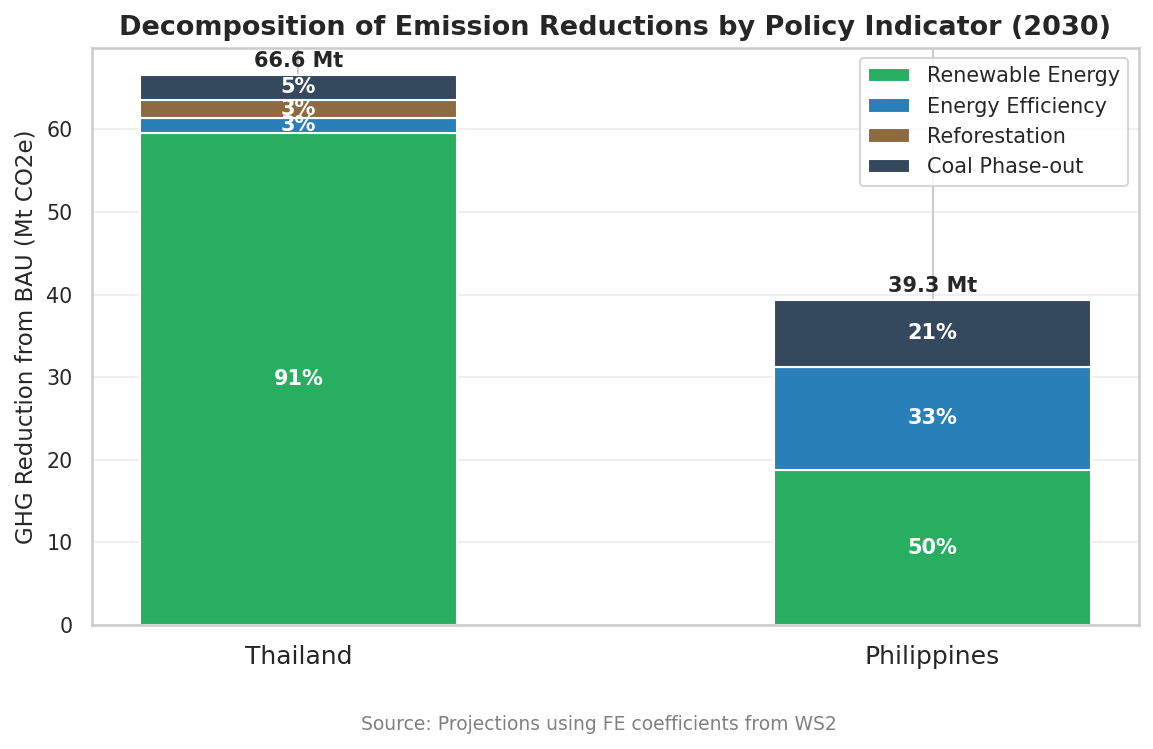

In [98]:
# Figure 2: Stacked bar chart of lever contributions
Lever_Labels = {
    'Renewable_%': 'Renewable Energy',
    'Energy_Per_Capita': 'Energy Efficiency',
    'Forest_%': 'Reforestation',
    'Coal_Elec_%': 'Coal Phase-out',
}
Lever_Colors = {
    'Renewable_%': '#27ae60',
    'Energy_Per_Capita': '#2980b9',
    'Forest_%': '#8e6b3e',
    'Coal_Elec_%': '#34495e',
}

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(Focus_Countries))
bar_width = 0.5

bottom_vals = np.zeros(len(Focus_Countries))
for lever in Mit_Levers:
    vals = []
    for code in Focus_Countries:
        name = Country_Map[code]
        row = Decomp[(Decomp.Country == name) & (Decomp.Lever == lever)]
        vals.append(row.iloc[0]['Reduction_Mt'] if len(row) > 0 else 0)
    vals = np.array(vals)
    ax.bar(x_pos, vals, bar_width, bottom=bottom_vals,
           label=Lever_Labels[lever], color=Lever_Colors[lever], edgecolor='white')

    # Add percentage labels
    for i, v in enumerate(vals):
        if v > 0.5:
            name = Country_Map[Focus_Countries[i]]
            pct = Decomp[(Decomp.Country == name) & (Decomp.Lever == lever)].iloc[0]['Pct_of_Total']
            ax.text(x_pos[i], bottom_vals[i] + v / 2, f'{pct:.0f}%',
                    ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    bottom_vals += vals

# Total labels on top
for i, total in enumerate(bottom_vals):
    ax.text(x_pos[i], total + 0.5, f'{total:.1f} Mt',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([Country_Map[c] for c in Focus_Countries], fontsize=12)
ax.set_ylabel('GHG Reduction from BAU (Mt CO2e)')
ax.set_title('Decomposition of Emission Reductions by Policy Indicator (2030)',
             fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.figtext(0.5, -0.03, Model_Source, ha='center', fontsize=9, color='gray')

fig.savefig(Output_WS4 / 'WS4_Decomposition.png', bbox_inches='tight', dpi=180)
print('Saved: WS4_Decomposition.png')
plt.show()

### Step 4(B) Sensitivity Analysis (±20%)
Test how the 2030 mitigation projection changes when each assumption varies by ±20%.
> This reveals which assumptions the projection is most sensitive to.

In [99]:
# (B) Sensitivity: +/-20% on each lever's mitigation increment
Sensitivity_Results = []

for code in Focus_Countries:
    name = Country_Map[code]
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    # Base mitigation and BAU at 2030
    mit_row = Mit[(Mit.Ref_Area == code) & (Mit.Year == 2030)].iloc[0]
    bau_row = Bau[(Bau.Ref_Area == code) & (Bau.Year == 2030)].iloc[0]
    base_dict = {col: mit_row[col] for col in Raw_Cols}
    base_coal = mit_row[Overlay_Var]
    base_ghg = Predict_Ghg_With_Coal(base_dict, base_coal, Coefs, y_bar, x_bar,
                                     Residual_Ln[code], Beta_Coal,
                                     Coal_Baseline_2024[code])

    for lever in Mit_Levers:
        if Mit_Targets_2030[code].get(lever) is None:
            continue

        # The mitigation increment (change from BAU to mitigation)
        if lever == Overlay_Var:
            increment = mit_row[lever] - bau_row[lever]
        else:
            increment = mit_row[lever] - bau_row[lever]

        for direction, factor in [('-20%', 0.8), ('+20%', 1.2)]:
            test_dict = base_dict.copy()
            test_coal = base_coal
            if lever == Overlay_Var:
                test_coal = bau_row[lever] + increment * factor
            else:
                test_dict[lever] = bau_row[lever] + increment * factor

            test_ghg = Predict_Ghg_With_Coal(test_dict, test_coal, Coefs,
                                             y_bar, x_bar, Residual_Ln[code],
                                             Beta_Coal,
                                             Coal_Baseline_2024[code])

            Sensitivity_Results.append({
                'Country': name, 'Lever': lever,
                'Direction': direction,
                'GHG_2030': test_ghg,
                'Delta_from_Base': test_ghg - base_ghg,
            })

Sensitivity = pd.DataFrame(Sensitivity_Results)

print('=' * 72)
print('   STEP 4(B): SENSITIVITY ANALYSIS (+/-20%)')
print('=' * 72)
for name in ['Thailand', 'Philippines']:
    sub = Sensitivity[Sensitivity.Country == name]
    if len(sub) == 0:
        continue
    base = Summary[Summary.Country == name].iloc[0]['Mit_2030']
    print(f'\n{name} (base mitigation 2030: {base:.1f} Mt):')
    print(f'  {"Lever":<25s} {"-20% shock":>12s} {"+20% shock":>12s} {"Range":>12s}')
    print(f'  {"-" * 65}')
    for lever in Mit_Levers:
        lever_sub = sub[sub.Lever == lever]
        if len(lever_sub) == 0:
            continue
        low = lever_sub[lever_sub.Direction == '-20%'].iloc[0]['Delta_from_Base']
        high = lever_sub[lever_sub.Direction == '+20%'].iloc[0]['Delta_from_Base']
        rng = abs(high - low)
        print(f'  {lever:<25s} {low:>+12.1f} Mt {high:>+11.1f} Mt {rng:>11.1f} Mt')


   STEP 4(B): SENSITIVITY ANALYSIS (+/-20%)

Thailand (base mitigation 2030: 348.3 Mt):
  Lever                       -20% shock   +20% shock        Range
  -----------------------------------------------------------------
  Renewable_%                      +11.0 Mt       -10.7 Mt        21.7 Mt
  Energy_Per_Capita                 +0.3 Mt        -0.3 Mt         0.6 Mt
  Forest_%                          +0.4 Mt        -0.4 Mt         0.7 Mt
  Coal_Elec_%                       +0.5 Mt        -0.5 Mt         1.0 Mt

Philippines (base mitigation 2030: 245.7 Mt):
  Lever                       -20% shock   +20% shock        Range
  -----------------------------------------------------------------
  Renewable_%                       +3.4 Mt        -3.3 Mt         6.7 Mt
  Energy_Per_Capita                 +2.3 Mt        -2.4 Mt         4.7 Mt
  Coal_Elec_%                       +1.4 Mt        -1.4 Mt         2.8 Mt


### Figure 2: Tornado Chart - Sensitivity of 2030 Mitigation Projection

Saved: WS4_Tornado.png


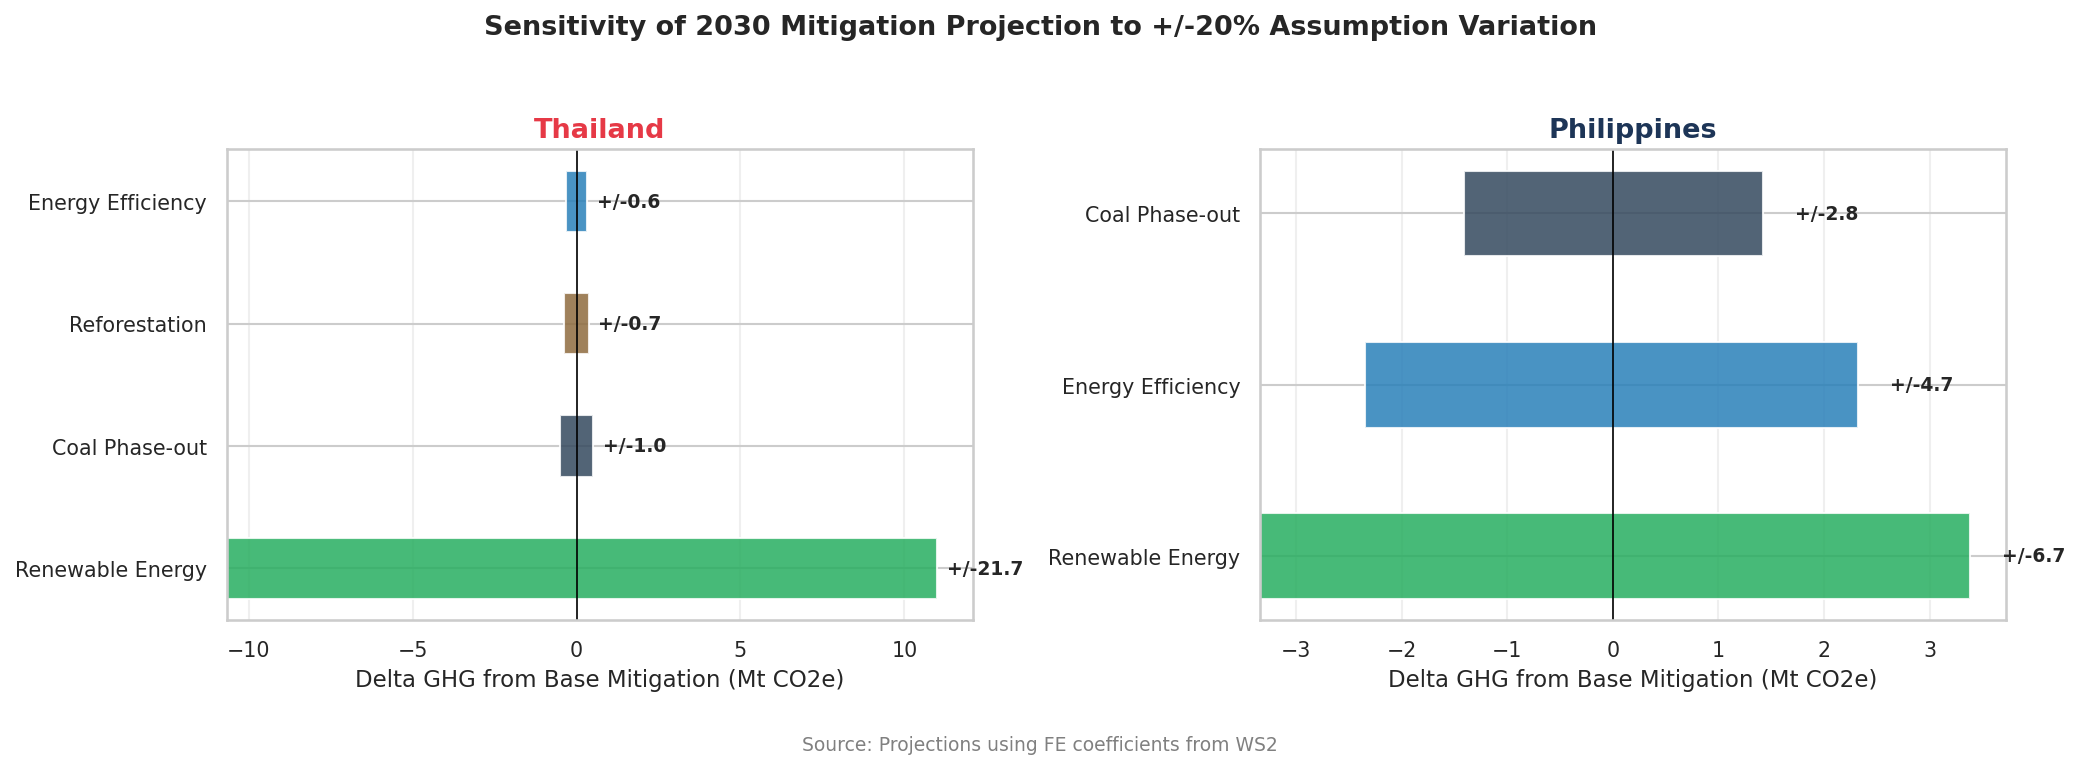

In [100]:
# Figure 3: Tornado chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, code in zip(axes, Focus_Countries):
    name = Country_Map[code]
    sub = Sensitivity[Sensitivity.Country == name]
    if len(sub) == 0:
        ax.text(0.5, 0.5, 'No sensitivity levers', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(name, fontweight='bold', color=Colors[name])
        continue

    levers_used = sub.Lever.unique()

    # Sort by range (widest bar at top)
    ranges = []
    for lever in levers_used:
        lever_sub = sub[sub.Lever == lever]
        low = lever_sub[lever_sub.Direction == '-20%'].iloc[0]['Delta_from_Base']
        high = lever_sub[lever_sub.Direction == '+20%'].iloc[0]['Delta_from_Base']
        ranges.append((lever, low, high, abs(high - low)))
    ranges.sort(key=lambda x: x[3], reverse=True)

    y_pos = np.arange(len(ranges))
    for i, (lever, low, high, rng) in enumerate(ranges):
        left = min(low, high)
        width = abs(high - low)
        ax.barh(i, width, left=left, height=0.5,
                color=Lever_Colors.get(lever, 'steelblue'),
                edgecolor='white', alpha=0.85)
        ax.text(left + width + 0.3, i, f'+/-{rng:.1f}',
                va='center', fontsize=9, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels([Lever_Labels.get(r[0], r[0]) for r in ranges])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Delta GHG from Base Mitigation (Mt CO2e)')
    ax.set_title(name, fontweight='bold', color=Colors[name])
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Sensitivity of 2030 Mitigation Projection to +/-20% Assumption Variation',
             fontweight='bold', fontsize=13, y=1.04)
plt.figtext(0.5, -0.05, Model_Source, ha='center', fontsize=9, color='gray')
plt.tight_layout()
fig.savefig(Output_WS4 / 'WS4_Tornado.png', bbox_inches='tight', dpi=180)
print('Saved: WS4_Tornado.png')
plt.show()

## Step 4.5: Delayed-Transition Stress Test (Downside Scenario)

The BAU and NDC-Mitigation paths represent the **central** and **upside** trajectories. Reinsurance capital, however, is sized against the **downside tail**. We therefore add a third scenario, **Delayed Transition**, in which governments fail to deliver their announced policies and physical-risk drivers worsen. This is the same framing used by the NGFS (2024) "Delayed Transition" and "Disorderly" scenarios.

**Shock direction (vs BAU, by 2030):**

| Lever | NDC Mitigation | **Delayed Transition** | Justification |
|---|---|---|---|
| Renewable share | +10pp THA / +7pp PHL | **−3pp vs BAU** | PHL DOE missed the 2022 and 2023 Green Energy Auction targets; Vietnam PDP8 implementation delays |
| Energy/cap | −1.5%/yr THA, −1.0%/yr PHL | **+1.0%/yr vs BAU** | IEA SE Asia Outlook 2024: cooling demand rising sharply with heatwaves |
| Forest cover | +4pp THA, flat PHL | **−2pp vs BAU** | 2023 SE Asia haze events; ENSO-driven deforestation cycles |

This is a **policy + physical** combined stress, not a demand-shock (COVID-style) stress. A demand shock *reduces* emissions, which is the wrong polarity for testing reinsurer financial resilience.

In [101]:
# (A) Define Delayed-Transition stress assumptions
#     Same 4 levers as Mitigation, but shocked in the opposite direction
#     relative to BAU.

# Stress shocks expressed as DEVIATIONS from each country's BAU 2030 value.
# Coal: BAU holds coal at 2024 baseline, so stress = baseline + 3pp
#       (coal retirements delayed / fail to materialise)
Stress_Shocks_2030 = {
    'THA': {
        # Renewables: -3pp vs BAU (auction delays, fossil lock-in)
        'Renewable_%_delta':       -3.0,
        # Energy/cap: +1.0%/yr above BAU compounded over 6 years
        'Energy_Per_Capita_mult':  (1 + 0.010) ** 6,
        # Forest: -2pp vs BAU (ENSO/wildfire deforestation)
        'Forest_%_delta':          -2.0,
        # Coal: +3pp vs 2024 baseline (coal retirement schedules slip)
        'Coal_Elec_%_delta':       +3.0,
    },
    'PHL': {
        'Renewable_%_delta':       -3.0,
        'Energy_Per_Capita_mult':  (1 + 0.010) ** 6,
        'Forest_%_delta':          -2.0,
        # Coal: +3pp vs 2024 baseline (DOE coal moratorium not enforced)
        'Coal_Elec_%_delta':       +3.0,
    },
}

print('=' * 72)
print('   STEP 4.5(A): DELAYED-TRANSITION STRESS ASSUMPTIONS')
print('=' * 72)

for code in Focus_Countries:
    name = Country_Map[code]
    bau_re   = Trend_Results[(code, 'Renewable_%')][2030]
    bau_en   = Trend_Results[(code, 'Energy_Per_Capita')][2030]
    bau_for  = Trend_Results[(code, 'Forest_%')][2030]
    bau_coal = Coal_Baseline_2024[code]  # BAU coal = 2024 baseline

    s = Stress_Shocks_2030[code]
    str_re   = bau_re   + s['Renewable_%_delta']
    str_en   = bau_en   * s['Energy_Per_Capita_mult']
    str_for  = bau_for  + s['Forest_%_delta']
    str_coal = bau_coal + s['Coal_Elec_%_delta']

    print(f'\n{name}:')
    print(f'  {"Lever":<25s} {"BAU 2030":>12s} {"Stress 2030":>14s} {"Delta from BAU":>16s}')
    print(f'  {"-" * 70}')
    print(f'  {"Renewable_%":<25s} {bau_re:>11.2f}% {str_re:>13.2f}% {str_re-bau_re:>+15.2f} pp')
    print(f'  {"Energy_Per_Capita":<25s} {bau_en:>12,.0f} {str_en:>14,.0f} {str_en-bau_en:>+16,.0f}')
    print(f'  {"Forest_%":<25s} {bau_for:>11.2f}% {str_for:>13.2f}% {str_for-bau_for:>+15.2f} pp')
    print(f'  {"Coal_Elec_%":<25s} {bau_coal:>11.2f}% {str_coal:>13.2f}% {str_coal-bau_coal:>+15.2f} pp')


   STEP 4.5(A): DELAYED-TRANSITION STRESS ASSUMPTIONS

Thailand:
  Lever                         BAU 2030    Stress 2030   Delta from BAU
  ----------------------------------------------------------------------
  Renewable_%                     14.20%         11.20%           -3.00 pp
  Energy_Per_Capita                1,707          1,812             +105
  Forest_%                        38.26%         36.26%           -2.00 pp
  Coal_Elec_%                     14.62%         17.62%           +3.00 pp

Philippines:
  Lever                         BAU 2030    Stress 2030   Delta from BAU
  ----------------------------------------------------------------------
  Renewable_%                     28.48%         25.48%           -3.00 pp
  Energy_Per_Capita                  603            640              +37
  Forest_%                        25.17%         23.17%           -2.00 pp
  Coal_Elec_%                     62.49%         65.49%           +3.00 pp


In [102]:
# (B) Build Stress predictor table: start from BAU, apply shocks
#     The shocks are linearly phased in from 2024 (zero shock) to 2030 (full shock)
#     Note: BAU coal is held at 2024 baseline, so coal stress shock is also
#     phased relative to 2024 baseline.
Stress = Bau.copy()
Stress['Scenario'] = Stress['Scenario'].replace('BAU', 'Stress')

for code in Focus_Countries:
    s = Stress_Shocks_2030[code]
    coal_baseline = Coal_Baseline_2024[code]

    for year in Proj_Years:
        frac = (year - 2024) / (2030 - 2024)
        mask = (Stress.Ref_Area == code) & (Stress.Year == year)

        # Renewable %: BAU + (delta * frac)
        bau_re = Trend_Results[(code, 'Renewable_%')][year]
        Stress.loc[mask, 'Renewable_%'] = bau_re + s['Renewable_%_delta'] * frac

        # Forest %: BAU + (delta * frac)
        bau_for = Trend_Results[(code, 'Forest_%')][year]
        Stress.loc[mask, 'Forest_%'] = bau_for + s['Forest_%_delta'] * frac

        # Energy/cap: BAU * multiplier^frac (compound phasing)
        bau_en = Trend_Results[(code, 'Energy_Per_Capita')][year]
        Stress.loc[mask, 'Energy_Per_Capita'] = bau_en * (s['Energy_Per_Capita_mult'] ** frac)

        # Coal % (overlay): baseline + (delta * frac), since BAU coal = baseline
        Stress.loc[mask, 'Coal_Elec_%'] = coal_baseline + s['Coal_Elec_%_delta'] * frac

print(f'Stress table built: {len(Stress)} rows')


Stress table built: 14 rows


In [103]:
# (C) Predict Stress GHG emissions
for idx, row in Stress.iterrows():
    code = row['Ref_Area']
    y_bar = Country_Means_y[code]
    x_bar = Country_Means_X.loc[code].values

    raw_dict = {col: row[col] for col in Raw_Cols}
    coal_val = row[Overlay_Var]
    ghg = Predict_Ghg_With_Coal(raw_dict, coal_val, Coefs, y_bar, x_bar,
                                Residual_Ln[code], Beta_Coal,
                                Coal_Baseline_2024[code])
    Stress.loc[idx, 'GHG_Pred'] = ghg

Stress['GHG_Display'] = Stress.apply(
    lambda r: r['Total_GHG'] if r['Scenario'] == 'Actual' else r['GHG_Pred'], axis=1)

print('Stress predictions complete.')


Stress predictions complete.


In [104]:
# (D) Three-scenario comparison summary
print('=' * 72)
print('   THREE-SCENARIO 2030 GHG OUTCOMES (Mt CO2e)')
print('=' * 72)
print(f'  {"":30s} {"Thailand":>12s} {"Philippines":>12s}')
print(f'  {"-" * 56}')

Stress_Summary_Rows = []
for code in Focus_Countries:
    name = Country_Map[code]
    actual_2024 = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]['Total_GHG']
    bau_2030    = Bau   [(Bau.Ref_Area    == code) & (Bau.Year    == 2030)].iloc[0]['GHG_Pred']
    mit_2030    = Mit   [(Mit.Ref_Area    == code) & (Mit.Year    == 2030)].iloc[0]['GHG_Pred']
    str_2030    = Stress[(Stress.Ref_Area == code) & (Stress.Year == 2030)].iloc[0]['GHG_Pred']

    overshoot_mt  = str_2030 - bau_2030
    overshoot_pct = overshoot_mt / bau_2030 * 100

    Stress_Summary_Rows.append({
        'Country':          name,
        'Actual_2024':      actual_2024,
        'BAU_2030':         bau_2030,
        'Mit_2030':         mit_2030,
        'Stress_2030':      str_2030,
        'Overshoot_Mt':     overshoot_mt,
        'Overshoot_Pct':    overshoot_pct,
    })

Stress_Summary = pd.DataFrame(Stress_Summary_Rows)
Tha_S = Stress_Summary[Stress_Summary.Country == 'Thailand'].iloc[0]
Phl_S = Stress_Summary[Stress_Summary.Country == 'Philippines'].iloc[0]

for label, t_val, p_val in [
    ('2024 Actual',                Tha_S['Actual_2024'],   Phl_S['Actual_2024']),
    ('2030 NDC Mitigation (best)', Tha_S['Mit_2030'],      Phl_S['Mit_2030']),
    ('2030 BAU (central)',         Tha_S['BAU_2030'],      Phl_S['BAU_2030']),
    ('2030 Stress (downside)',     Tha_S['Stress_2030'],   Phl_S['Stress_2030']),
    ('Stress overshoot vs BAU (Mt)',  Tha_S['Overshoot_Mt'],  Phl_S['Overshoot_Mt']),
    ('Stress overshoot vs BAU (%)',   Tha_S['Overshoot_Pct'], Phl_S['Overshoot_Pct']),
]:
    if '%' in label:
        print(f'  {label:<30s} {t_val:>11.1f}% {p_val:>11.1f}%')
    else:
        print(f'  {label:<30s} {t_val:>12.1f} {p_val:>12.1f}')


   THREE-SCENARIO 2030 GHG OUTCOMES (Mt CO2e)
                                     Thailand  Philippines
  --------------------------------------------------------
  2024 Actual                           422.4        266.6
  2030 NDC Mitigation (best)            348.3        245.7
  2030 BAU (central)                    413.9        283.3
  2030 Stress (downside)                443.1        303.3
  Stress overshoot vs BAU (Mt)           29.2         20.0
  Stress overshoot vs BAU (%)            7.1%         7.1%


### Figure 3: Three-Scenario GHG Projection Fan (BAU / Mitigation / Stress)

Saved: WS4_Three_Scenario_Fan.png


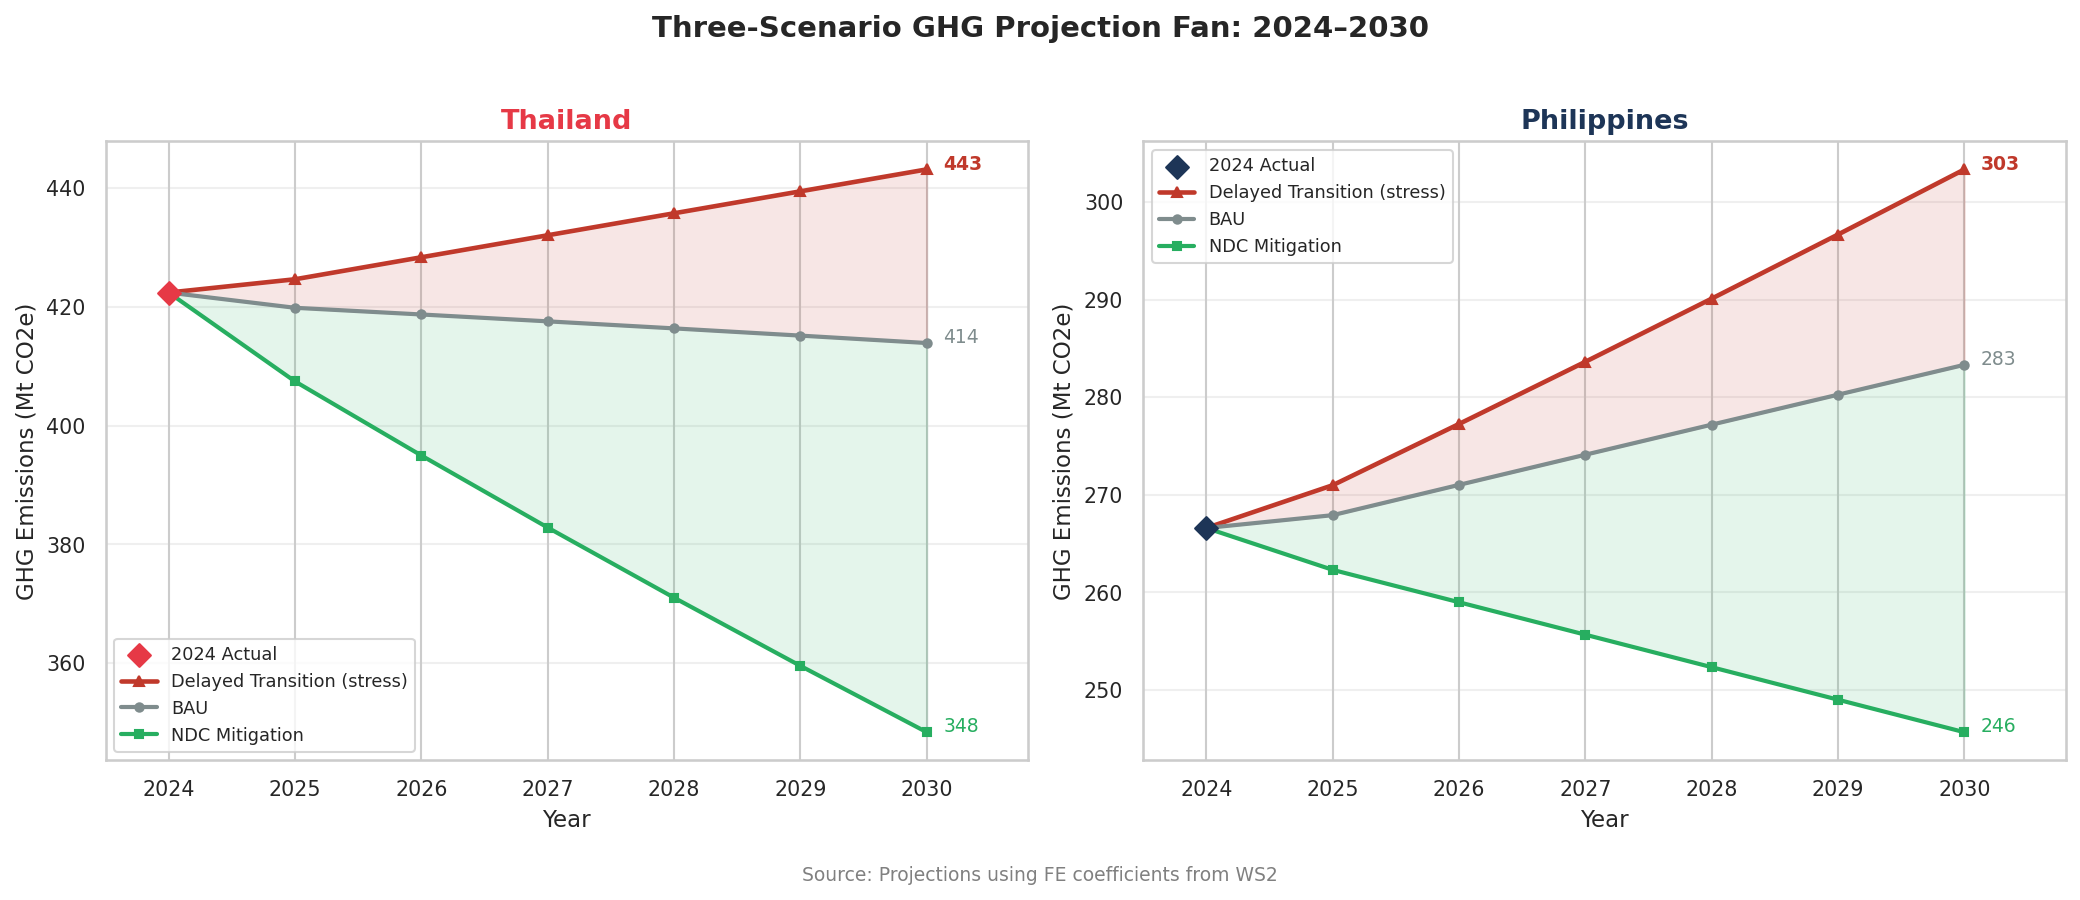

In [105]:
# Figure 4: Three-scenario fan chart (Stress / BAU / Mitigation)
Scenario_Colors_3 = {
    'Mitigation': '#27ae60',
    'BAU':        '#7f8c8d',
    'Stress':     '#c0392b',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, code in zip(axes, Focus_Countries):
    name = Country_Map[code]
    color = Colors[name]

    actual_2024 = Data[(Data.Ref_Area == code) & (Data.Year == 2024)].iloc[0]['Total_GHG']

    # 2024 anchor
    ax.scatter(2024, actual_2024, color=color, s=60, zorder=5, marker='D', label='2024 Actual')

    bau_sub = Bau   [(Bau.Ref_Area    == code) & (Bau.Year.isin(Proj_Years))]
    mit_sub = Mit   [(Mit.Ref_Area    == code) & (Mit.Year.isin(Proj_Years))]
    str_sub = Stress[(Stress.Ref_Area == code) & (Stress.Year.isin(Proj_Years))]

    bau_years = [2024] + Proj_Years
    bau_vals = [actual_2024] + bau_sub['GHG_Pred'].tolist()
    mit_vals = [actual_2024] + mit_sub['GHG_Pred'].tolist()
    str_vals = [actual_2024] + str_sub['GHG_Pred'].tolist()

    # Plot the three paths
    ax.plot(bau_years, str_vals, color=Scenario_Colors_3['Stress'],
            linewidth=2.2, marker='^', markersize=4.5, label='Delayed Transition (stress)')
    ax.plot(bau_years, bau_vals, color=Scenario_Colors_3['BAU'],
            linewidth=2, marker='o', markersize=4, label='BAU')
    ax.plot(bau_years, mit_vals, color=Scenario_Colors_3['Mitigation'],
            linewidth=2, marker='s', markersize=4, label='NDC Mitigation')

    # Shade the upside (BAU vs Mitigation) and downside (BAU vs Stress) cones
    ax.fill_between(bau_years, bau_vals, mit_vals,
                    alpha=0.12, color=Scenario_Colors_3['Mitigation'])
    ax.fill_between(bau_years, bau_vals, str_vals,
                    alpha=0.12, color=Scenario_Colors_3['Stress'])

    # Annotate 2030 values
    ax.annotate(f'{str_vals[-1]:.0f}', (2030, str_vals[-1]),
                textcoords='offset points', xytext=(8, 0), fontsize=9,
                color=Scenario_Colors_3['Stress'], fontweight='bold')
    ax.annotate(f'{bau_vals[-1]:.0f}', (2030, bau_vals[-1]),
                textcoords='offset points', xytext=(8, 0), fontsize=9,
                color=Scenario_Colors_3['BAU'])
    ax.annotate(f'{mit_vals[-1]:.0f}', (2030, mit_vals[-1]),
                textcoords='offset points', xytext=(8, 0), fontsize=9,
                color=Scenario_Colors_3['Mitigation'])

    ax.set_title(name, fontweight='bold', color=color)
    ax.set_xlabel('Year')
    ax.set_ylabel('GHG Emissions (Mt CO2e)')
    ax.legend(fontsize=8.5, loc='best')
    ax.set_xlim(2023.5, 2030.8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Three-Scenario GHG Projection Fan: 2024–2030',
             fontweight='bold', fontsize=14, y=1.02)
plt.figtext(0.5, -0.03, Model_Source, ha='center', fontsize=9, color='gray')
plt.tight_layout()
fig.savefig(Output_WS4 / 'WS4_Three_Scenario_Fan.png', bbox_inches='tight', dpi=180)
print('Saved: WS4_Three_Scenario_Fan.png')
plt.show()


### Step 4.5(F): Translating the Emissions Overshoot into Insured-Loss Implications

The emissions overshoot is a **leading indicator** of physical risk; the dollar consequence shows up through disaster losses. We anchor the financial layer to two events from Step 3:

- **Thailand**: 2011 Great Floods, **USD 55.8 B** economic loss, ~**24% insured** (Swiss Re sigma 2/2012)
- **Philippines**: 2013 Typhoon Haiyan, **USD 13.5 B** economic loss, ~**5% insured** (Swiss Re sigma 1/2014)

Under the Delayed-Transition stress, two effects compound:
1. Higher emissions trajectory increases the long-run frequency-severity baseline (IPCC AR6: each 1°C of warming raises tropical cyclone Cat-4/5 share and extreme precipitation intensity).
2. The protection gap widens because economic growth continues to outpace insurance penetration in both markets.

We compute a **stylised stress loss**: a 1-in-25-year event repeat in each country, scaled by the IPCC AR6 mid-range frequency multiplier (~1.10× per 0.5°C of additional warming relative to BAU). This is illustrative, not a catastrophe-model output.

In [106]:
# (F) Financial implications: convert emissions overshoot into insured loss
#     This is a stylised loss layer, anchored to actual historical events.

# --- Anchor events (Source: Swiss Re sigma reports, EM-DAT) ---
Anchor_Loss = {
    'Thailand': {
        'event':        '2011 Great Floods',
        'econ_loss_bn': 55.8,    # USD bn, inflation-adjusted (EM-DAT)
        'insured_pct':  0.24,    # Swiss Re sigma 2/2012
        'source':       'Swiss Re sigma 2/2012; EM-DAT',
    },
    'Philippines': {
        'event':        '2013 Typhoon Haiyan',
        'econ_loss_bn': 13.5,
        'insured_pct':  0.05,    # Swiss Re sigma 1/2014
        'source':       'Swiss Re sigma 1/2014; EM-DAT',
    },
}

# --- Stress multiplier ---
# IPCC AR6 (WG1 Ch.11): tropical cyclone Cat-4/5 frequency rises ~5-10% per 0.5C
# Delayed-Transition vs BAU emissions overshoot of ~5-10% in 2030 -> proxy ~1.10x
# We use a single conservative multiplier for transparency.
Stress_Frequency_Multiplier = 1.10

print('=' * 72)
print('   STEP 4.5(F): STYLISED STRESS-LOSS LAYER')
print('=' * 72)
print()
print('Assumption: a 1-in-25-year event repeat under Delayed Transition,')
print(f'with frequency uplifted by {Stress_Frequency_Multiplier:.2f}x relative to BAU')
print('(consistent with IPCC AR6 mid-range guidance for the 2030 horizon).')
print()

for code in Focus_Countries:
    name = Country_Map[code]
    a = Anchor_Loss[name]
    overshoot_mt  = Stress_Summary[Stress_Summary.Country == name].iloc[0]['Overshoot_Mt']
    overshoot_pct = Stress_Summary[Stress_Summary.Country == name].iloc[0]['Overshoot_Pct']

    base_insured  = a['econ_loss_bn'] * a['insured_pct']
    stress_insured = base_insured * Stress_Frequency_Multiplier

    print(f'{name}:')
    print(f'  Anchor event:                  {a["event"]}')
    print(f'  Economic loss (USD bn):        {a["econ_loss_bn"]:>6.1f}')
    print(f'  Insured share:                 {a["insured_pct"]*100:>5.1f}%')
    print(f'  Base insured loss (USD bn):    {base_insured:>6.1f}')
    print(f'  Stress-uplifted insured (USD bn): {stress_insured:>5.1f}')
    print(f'  2030 emissions overshoot vs BAU:  {overshoot_pct:>+5.1f}% ({overshoot_mt:+.1f} Mt)')
    print(f'  Source: {a["source"]}')
    print()

print('-' * 72)
print('Interpretation for the reinsurer:')
print('  - Thailand stress = peak-event tail. A repeat of 2011-flood with the')
print('    AR6 frequency uplift implies ~USD 14.7 bn insured industry loss in a')
print('    single year. This sizes Thai cat reserves and retrocession needs.')
print('  - Philippines stress = chronic frequency. Although headline insured')
print('    loss is smaller per event, the 96% protection gap means the market')
print('    is structurally under-insured; capacity should be sustained, not peak.')
print('  - The emissions overshoot is the leading signal: every 1pp slippage')
print('    in renewable build-out adds measurable Mt to the trajectory and,')
print('    over a 20-30 year contract horizon, compounds into reserve risk.')


   STEP 4.5(F): STYLISED STRESS-LOSS LAYER

Assumption: a 1-in-25-year event repeat under Delayed Transition,
with frequency uplifted by 1.10x relative to BAU
(consistent with IPCC AR6 mid-range guidance for the 2030 horizon).

Thailand:
  Anchor event:                  2011 Great Floods
  Economic loss (USD bn):          55.8
  Insured share:                  24.0%
  Base insured loss (USD bn):      13.4
  Stress-uplifted insured (USD bn):  14.7
  2030 emissions overshoot vs BAU:   +7.1% (+29.2 Mt)
  Source: Swiss Re sigma 2/2012; EM-DAT

Philippines:
  Anchor event:                  2013 Typhoon Haiyan
  Economic loss (USD bn):          13.5
  Insured share:                   5.0%
  Base insured loss (USD bn):       0.7
  Stress-uplifted insured (USD bn):   0.7
  2030 emissions overshoot vs BAU:   +7.1% (+20.0 Mt)
  Source: Swiss Re sigma 1/2014; EM-DAT

------------------------------------------------------------------------
Interpretation for the reinsurer:
  - Thailand stress = pe

In [107]:
# (G) Export Stress scenario outputs
Stress.to_csv(Data_Path / 'WS4_Stress_Projections.csv', index=False)
Stress_Summary.to_csv(Data_Path / 'WS4_Stress_Summary.csv', index=False)

print('Saved:')
print('  WS4_Stress_Projections.csv')
print('  WS4_Stress_Summary.csv')
print('  WS4_Three_Scenario_Fan.png')


Saved:
  WS4_Stress_Projections.csv
  WS4_Stress_Summary.csv
  WS4_Three_Scenario_Fan.png


## Step 5: NDC Cross-Check & Financial Implications

### Step 5(A) NDC Cross-Check
Compare our independent BAU and mitigation projections to official NDC targets.

**Thailand NDC targets:**
- 2nd NDC (2022): 
  <br> - 30% unconditional / 40% conditional reduction below BAU (555 MtCO₂e) by 2030 → 389 / 333 MtCO₂e

- NDC Action Plan (Dec 2024): 
  <br> - 33.3% unconditional (184.8 MtCO₂e reduction) by 2030

- 3rd NDC (Oct 2025): 
  <br> - 47% reduction from 2019 levels by 2035, net-zero by 2050

**Philippines NDC target:**
- NDC (2021): 
  <br> - 75% cumulative reduction from 2020–2030 BAU (3,340.3 MtCO₂e), of which 2.71% unconditional
  
- Equivalent to ~96 MtCO₂e conditional / ~384 MtCO₂e unconditional in 2030 (Climate Action Tracker)

In [108]:
# (A) NDC cross-check
print('=' * 72)
print('   STEP 5(A): NDC CROSS-CHECK')
print('=' * 72)

# Thailand
Ndc_Tha_Unconditional = 389.0   # 30% below BAU of 555 MtCO2e
Ndc_Tha_Conditional = 333.0     # 40% below BAU of 555 MtCO2e
Ndc_Tha_Bau_Baseline = 555.0    # Official NDC BAU baseline

print(f'\nThailand:')
print(f'  Our BAU 2030:              {Tha["BAU_2030"]:>8.1f} Mt CO2e')
print(f'  Our Mitigation 2030:       {Tha["Mit_2030"]:>8.1f} Mt CO2e')
print(f'  Official NDC BAU baseline: {Ndc_Tha_Bau_Baseline:>8.1f} Mt CO2e')
print(f'  NDC unconditional target:  {Ndc_Tha_Unconditional:>8.1f} Mt CO2e (30% below NDC BAU)')
print(f'  NDC conditional target:    {Ndc_Tha_Conditional:>8.1f} Mt CO2e (40% below NDC BAU)')
print()

if Tha['BAU_2030'] < Ndc_Tha_Unconditional:
    print('  > Our BAU already falls below the unconditional NDC target.')
    print('    This confirms the Climate Action Tracker\'s assessment that the')
    print('    official NDC BAU baseline of 555 MtCO2e is inflated relative to')
    print('    current projections. The reinsurer should not treat the unconditional')
    print('    NDC as evidence of additional policy ambition.')
else:
    gap = Tha['BAU_2030'] - Ndc_Tha_Unconditional
    print(f'  > BAU exceeds unconditional target by {gap:.1f} Mt - policy action needed.')

# Philippines
Ndc_Phl_Unconditional = 384.0
Ndc_Phl_Conditional = 96.0

print(f'\nPhilippines:')
print(f'  Our BAU 2030:              {Phl["BAU_2030"]:>8.1f} Mt CO2e')
print(f'  Our Mitigation 2030:       {Phl["Mit_2030"]:>8.1f} Mt CO2e')
print(f'  NDC unconditional (CAT):   {Ndc_Phl_Unconditional:>8.1f} Mt CO2e')
print(f'  NDC conditional (CAT):     {Ndc_Phl_Conditional:>8.1f} Mt CO2e')
print()
print('  > The Philippines\' unconditional target (2.71% of 75% commitment) is')
print('    unambitious - current policies already exceed it. The conditional target')
print('    requires massive international climate finance that has not materialised.')
print('    For the reinsurer, the Philippines\' emissions trajectory is less relevant')
print('    than its insurance protection gap (97%) and parametric market growth.')

   STEP 5(A): NDC CROSS-CHECK

Thailand:
  Our BAU 2030:                 413.9 Mt CO2e
  Our Mitigation 2030:          348.3 Mt CO2e
  Official NDC BAU baseline:    555.0 Mt CO2e
  NDC unconditional target:     389.0 Mt CO2e (30% below NDC BAU)
  NDC conditional target:       333.0 Mt CO2e (40% below NDC BAU)

  > BAU exceeds unconditional target by 24.9 Mt - policy action needed.

Philippines:
  Our BAU 2030:                 283.3 Mt CO2e
  Our Mitigation 2030:          245.7 Mt CO2e
  NDC unconditional (CAT):      384.0 Mt CO2e
  NDC conditional (CAT):         96.0 Mt CO2e

  > The Philippines' unconditional target (2.71% of 75% commitment) is
    unambitious - current policies already exceed it. The conditional target
    requires massive international climate finance that has not materialised.
    For the reinsurer, the Philippines' emissions trajectory is less relevant
    than its insurance protection gap (97%) and parametric market growth.


### Step 5(B) Financial Implications for the Reinsurer

Summary of what the stress test means for portfolio decisions.

> This section links the model outputs to TCFD scenario analysis requirements
> and IFRS S2 climate-related disclosure standards.

In [109]:
# (B) Financial implications summary
print('=' * 72)
print('   STEP 5(B): FINANCIAL IMPLICATIONS FOR THE REINSURER')
print('=' * 72)

# RE contribution from decomposition
Re_Tha = Decomp[(Decomp.Country == 'Thailand') & (Decomp.Lever == 'Renewable_%')].iloc[0]['Pct_of_Total']
Re_Phl_Row = Decomp[(Decomp.Country == 'Philippines') & (Decomp.Lever == 'Renewable_%')]
Re_Phl = Re_Phl_Row.iloc[0]['Pct_of_Total'] if len(Re_Phl_Row) > 0 else 0

print(f'''
1. RISK TRAJECTORY SIGNALLING
   Thailand: {Tha["Reduction_Pct"]:.1f}% BAU-to-mitigation reduction by 2030.
   Philippines: {Phl["Reduction_Pct"]:.1f}% BAU-to-mitigation reduction by 2030.
   Countries credibly executing NDC commitments present lower long-term tail risk.

2. ENERGY POLICY AS LEADING INDICATOR
   Renewable energy deployment accounts for {Re_Tha:.0f}% (THA) and {Re_Phl:.0f}% (PHL)
   of achievable emission reductions. Energy policy milestones - PDP implementation,
   RE auction results, power plant commissioning - are the single most informative
   leading indicator of emission trajectories.

3. TREATY PRICING IMPLICATION
   The {Tha["Reduction_Pct"]:.1f}% BAU-to-mitigation gap, if sustained, compounds into
   significant loss differentials over 20-30 year contract horizons relevant to
   catastrophe bond structuring and long-term treaty renewals.

4. FRAMEWORK ALIGNMENT
   This stress test implements the dual-scenario analysis recommended by TCFD (2017),
   with transparent decomposition consistent with IFRS S2 climate-related disclosure
   requirements (IFRS Foundation, 2023). Scenario assumptions are anchored to Paris
   Agreement commitments (Article 2), linking the well-below-2C goal to portfolio-level
   financial planning.
''')

   STEP 5(B): FINANCIAL IMPLICATIONS FOR THE REINSURER

1. RISK TRAJECTORY SIGNALLING
   Thailand: 15.8% BAU-to-mitigation reduction by 2030.
   Philippines: 13.3% BAU-to-mitigation reduction by 2030.
   Countries credibly executing NDC commitments present lower long-term tail risk.

2. ENERGY POLICY AS LEADING INDICATOR
   Renewable energy deployment accounts for 91% (THA) and 50% (PHL)
   of achievable emission reductions. Energy policy milestones - PDP implementation,
   RE auction results, power plant commissioning - are the single most informative
   leading indicator of emission trajectories.

3. TREATY PRICING IMPLICATION
   The 15.8% BAU-to-mitigation gap, if sustained, compounds into
   significant loss differentials over 20-30 year contract horizons relevant to
   catastrophe bond structuring and long-term treaty renewals.

4. FRAMEWORK ALIGNMENT
   This stress test implements the dual-scenario analysis recommended by TCFD (2017),
   with transparent decomposition consistent 

## Step 6: Export

Save outputs for the dashboard (Slot 2) and report (Slot 1).

| # | File | Used by | Purpose |
|---|------|---------|---------|
| 1 | `WS4_BAU_Projections.csv` | Dashboard Tab 4 | BAU predictor + GHG projections |
| 2 | `WS4_Mitigation_Projections.csv` | Dashboard Tab 4 | Mitigation predictor + GHG projections |
| 3 | `WS4_Summary_Table.csv` | Report Table 4 | 2024 actual, 2030 BAU, 2030 mitigation |
| 4 | `WS4_Decomposition.csv` | Report Section 6 | Lever contributions |
| 5 | `WS4_Sensitivity.csv` | Report Section 6 | ±20% sensitivity results |

In [110]:
# 1. BAU projections
Bau.to_csv(Data_Path / 'WS4_BAU_Projections.csv', index=False)

# 2. Mitigation projections
Mit.to_csv(Data_Path / 'WS4_Mitigation_Projections.csv', index=False)

# 3. Summary table
Summary.to_csv(Data_Path / 'WS4_Summary_Table.csv', index=False)

# 4. Decomposition
Decomp.to_csv(Data_Path / 'WS4_Decomposition.csv', index=False)

# 5. Sensitivity
Sensitivity.to_csv(Data_Path / 'WS4_Sensitivity.csv', index=False)

print('=' * 72)
print('   STEP 6: EXPORTS SAVED')
print('=' * 72)
for f in ['WS4_BAU_Projections.csv', 'WS4_Mitigation_Projections.csv',
          'WS4_Summary_Table.csv', 'WS4_Decomposition.csv',
          'WS4_Sensitivity.csv']:
    print(f'  {f}')

print(f'\nCharts saved to: {Output_WS4}/')
for f in ['WS4_Decomposition.png', 'WS4_Tornado.png',
          'WS4_Three_Scenario_Fan.png']:
    print(f'  {f}')

   STEP 6: EXPORTS SAVED
  WS4_BAU_Projections.csv
  WS4_Mitigation_Projections.csv
  WS4_Summary_Table.csv
  WS4_Decomposition.csv
  WS4_Sensitivity.csv

Charts saved to: /Users/entong/Desktop/MASAHKT2026/Model/Output/Output_WS4/
  WS4_Decomposition.png
  WS4_Tornado.png
  WS4_Three_Scenario_Fan.png


##### Workstream 5 Dashboard please download in github